# Maricopa County IPEDS → CIP → SOC Longitudinal Alignment

**Purpose:** prepare a clean, Ferris-ready table comparing the postsecondary training pipeline with occupation employment at three points: **2014, 2019, and 2025**.

## What is settled
- [x] Geography = **Maricopa County**
- [x] IPEDS completion years = **2014, 2019, 2025**
- [x] Employment source = **Lightcast occupation tables for Maricopa County**
- [x] Employment points = **2014 Jobs, 2019 Jobs, 2025 Jobs**
- [x] 2014/2019 CIP 2010 codes harmonized using `Crosswalk.csv`
- [x] Detailed CIP → detailed SOC relationships come from the Master workbook
- [x] Main sectors = **Healthcare and Manufacturing**
- [x] Occupation selection = **5-star occupations**
- [x] Repeated SOCs in the Master are treated as CIP→SOC relationships, not duplicate employment records

## Still waiting / discussion items
- [ ] **Semiconductor definition** — intentionally excluded until the team confirms it
- [ ] Decide which training measure Ferris wants to feature: related completions vs. allocated sensitivity measure
- [ ] Decide whether the completions-to-jobs ratio belongs in the final report
- [ ] Decide whether to use the exploratory training LQ-style measure
- [ ] Build final visualizations only **after the table and measure are approved**

> **Important interpretation:** IPEDS completers are graduates from related programs. They are not verified entrants into a particular occupation. A single CIP can map to multiple SOCs. Therefore, the notebook does **not** call a difference between completions and employment a “shortage.”

## 1. Setup — change only `COMPUTER`

Use `"WORK"`, `"W"`, or `1` at work. Use `"PERSONAL"`, `"P"`, or `2` at home.

In [3]:
from pathlib import Path
from collections import defaultdict
import pandas as pd

# Define BASE_FOLDER using raw string (r"...") for Windows paths
BASE_FOLDER = Path(r"C:\Users\301533\Documents\Walmart\IPEDS\Files")

# 1. Reset IPEDS map using a list for each year to handle multi-part files
IPEDS_FILE_MAP = defaultdict(list)

# 2. Inspect ALL CSV files in your folder (captures both 9242026-* and 9202026-* files)
ipeds_files = list(BASE_FOLDER.glob("*.csv"))

for file in ipeds_files:
    try:
        df = pd.read_csv(file, nrows=5)
        # Check for year column regardless of case
        year_col = next((c for c in df.columns if c.strip().lower() == "year"), None)
        
        if year_col:
            # Extract year value from first row
            yr_val = int(df[year_col].iloc[0])
            IPEDS_FILE_MAP[yr_val].append(file)
            print(f"Mapped Year {yr_val} -> {file.name}")
    except Exception as e:
        print(f"Could not read {file.name}: {e}")

# Convert back to standard dict
IPEDS_FILE_MAP = dict(IPEDS_FILE_MAP)
print("\nUpdated IPEDS_FILE_MAP:", IPEDS_FILE_MAP)

Mapped Year 2025 -> CSV_9202026-120.csv
Mapped Year 2019 -> CSV_9242026-150.csv
Mapped Year 2019 -> CSV_9242026-307.csv
Mapped Year 2014 -> CSV_9242026-348.csv
Mapped Year 2019 -> CSV_9242026-710.csv
Mapped Year 2014 -> usa_00003.csv
Mapped Year 2014 -> usa_00004.csv

Updated IPEDS_FILE_MAP: {2025: [WindowsPath('C:/Users/301533/Documents/Walmart/IPEDS/Files/CSV_9202026-120.csv')], 2019: [WindowsPath('C:/Users/301533/Documents/Walmart/IPEDS/Files/CSV_9242026-150.csv'), WindowsPath('C:/Users/301533/Documents/Walmart/IPEDS/Files/CSV_9242026-307.csv'), WindowsPath('C:/Users/301533/Documents/Walmart/IPEDS/Files/CSV_9242026-710.csv')], 2014: [WindowsPath('C:/Users/301533/Documents/Walmart/IPEDS/Files/CSV_9242026-348.csv'), WindowsPath('C:/Users/301533/Documents/Walmart/IPEDS/Files/usa_00003.csv'), WindowsPath('C:/Users/301533/Documents/Walmart/IPEDS/Files/usa_00004.csv')]}


In [10]:
from pathlib import Path
import re
import warnings
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 220)

# ============================================================
# 1. SETUP ENVIRONMENT & PATHS
# ============================================================
COMPUTER = "W"


def get_paths(computer):
    key = str(computer).strip().upper()

    if key in {"1", "W", "WORK"}:
        base = Path(r"C:\Users\301533\Documents\Walmart\IPEDS\Files")
        output = Path(r"C:\Users\301533\Downloads")
        label = "WORK"
    elif key in {"2", "P", "PERSONAL", "HOME"}:
        base = Path(r"C:\Users\Arielle\Desktop\Desktop\New folder\Walmart")
        output = Path(r"C:\Users\Arielle\Downloads")
        label = "PERSONAL"
    else:
        raise ValueError('COMPUTER must be 1/"W"/"WORK" or 2/"P"/"PERSONAL".')

    return label, base, output


COMPUTER_LABEL, BASE_FOLDER, OUTPUT_FOLDER = get_paths(COMPUTER)

MASTER_FILE = BASE_FOLDER / "Master_CIP_SOC_Matched_Output_2 (3).xlsx"
CROSSWALK_FILE = BASE_FOLDER / "Crosswalk.csv"
OUTPUT_FILE = OUTPUT_FOLDER / "Maricopa_IPEDS_Lightcast_Alignment.xlsx"

# Filtering criteria
SECTORS = ["Healthcare", "Manufacturing"]
HIGH_DEMAND_STARS = [5]

# ============================================================
# 2. DEFINE DEDUPLICATED IPEDS FILE MAP
# ============================================================
# Point each year to its single valid CSV file (ignoring duplicate 2019 files)
IPEDS_FILE_MAP = {
    2014: BASE_FOLDER / "CSV_9242026-348.csv",
    2019: BASE_FOLDER / "CSV_9242026-150.csv",  # Excludes duplicate -307 and -710
    2025: BASE_FOLDER / "CSV_9202026-120.csv",
}

YEARS = sorted(IPEDS_FILE_MAP.keys())

print("Computer:", COMPUTER_LABEL)
print("Base folder:", BASE_FOLDER)
print("Mapped Years:", YEARS)
print("IPEDS File Map:", IPEDS_FILE_MAP)

Computer: WORK
Base folder: C:\Users\301533\Documents\Walmart\IPEDS\Files
Mapped Years: [2014, 2019, 2025]
IPEDS File Map: {2014: WindowsPath('C:/Users/301533/Documents/Walmart/IPEDS/Files/CSV_9242026-348.csv'), 2019: WindowsPath('C:/Users/301533/Documents/Walmart/IPEDS/Files/CSV_9242026-150.csv'), 2025: WindowsPath('C:/Users/301533/Documents/Walmart/IPEDS/Files/CSV_9202026-120.csv')}


## 2. Automatically find the correct IPEDS and Lightcast files

The code does **not** trust the random download filenames. It opens candidate files and identifies them by the year columns inside the data.

In [11]:
def discover_ipeds_files(base_folder, required_years=YEARS):
    candidates = {yr: [] for yr in required_years}

    # Search for all CSV files in the folder
    for path in sorted(base_folder.glob("*.csv")):
        # Check 1: Match year in filename
        for yr in required_years:
            if str(yr) in path.name and ("IPEDS" in path.name.upper() or "CSV" in path.name.upper()):
                candidates[yr].append(path)

        # Check 2: Try reading columns inside the CSV
        try:
            sample = pd.read_csv(path, nrows=5)
            year_col = next((col for col in sample.columns if col.strip().lower() == "year"), None)
            
            if year_col:
                yrs = pd.to_numeric(sample[year_col], errors="coerce").dropna().astype(int).unique().tolist()
                for yr in yrs:
                    if yr in candidates and path not in candidates[yr]:
                        candidates[yr].append(path)
        except Exception:
            pass

    chosen = {}
    for yr, paths in candidates.items():
        if paths:
            # Sort and remove duplicate references
            chosen[yr] = sorted(list(set(paths)))[0]
            
    return candidates, chosen


def discover_lightcast_files(base_folder, required_years=YEARS):
    candidates = {yr: [] for yr in required_years}

    for path in sorted(base_folder.glob("Occupation_Table_All_Occupations_in_Maricopa_County_AZ_*.csv")):
        try:
            sample = pd.read_csv(path, nrows=5)
            for yr in required_years:
                if any(f"{yr} jobs" in col.strip().lower() for col in sample.columns):
                    candidates[yr].append(path)
        except Exception:
            pass

    chosen = {}
    for yr, paths in candidates.items():
        if paths:
            chosen[yr] = sorted(list(set(paths)))[0]
            
    return candidates, chosen


# --- Run Discovery ---
IPEDS_CANDIDATES, IPEDS_FILE_MAP = discover_ipeds_files(BASE_FOLDER)
LIGHTCAST_CANDIDATES, LIGHTCAST_FILE_MAP = discover_lightcast_files(BASE_FOLDER)

# Force the correct 2025 IPEDS file mapping (WITH .csv extension)
IPEDS_FILE_MAP[2025] = BASE_FOLDER / "CSV_9202026-120.csv"  

# --- Debug Output ---
status_rows = []
for yr in YEARS:
    status_rows.append({
        "year": yr,
        "IPEDS": IPEDS_FILE_MAP.get(yr, "MISSING"),
        "Lightcast": LIGHTCAST_FILE_MAP.get(yr, "MISSING"),
    })

STATUS = pd.DataFrame(status_rows)
print(STATUS.to_string(index=False))
print("\nMaster:", "FOUND" if MASTER_FILE.exists() else "MISSING", MASTER_FILE)
print("Crosswalk:", "FOUND" if CROSSWALK_FILE.exists() else "MISSING", CROSSWALK_FILE)

# --- Validation ---
missing = []
if not MASTER_FILE.exists(): missing.append(str(MASTER_FILE))
if not CROSSWALK_FILE.exists(): missing.append(str(CROSSWALK_FILE))
for yr in YEARS:
    if yr not in IPEDS_FILE_MAP: missing.append(f"IPEDS {yr}")
    if yr not in LIGHTCAST_FILE_MAP: missing.append(f"Lightcast {yr}")

if missing:
    raise FileNotFoundError("Missing required inputs:\n- " + "\n- ".join(missing))

 year                                                             IPEDS                                                                                                                 Lightcast
 2014 C:\Users\301533\Documents\Walmart\IPEDS\Files\CSV_9242026-348.csv C:\Users\301533\Documents\Walmart\IPEDS\Files\Occupation_Table_All_Occupations_in_Maricopa_County_AZ_7e7eb84eaeb1b487.csv
 2019 C:\Users\301533\Documents\Walmart\IPEDS\Files\CSV_9242026-150.csv C:\Users\301533\Documents\Walmart\IPEDS\Files\Occupation_Table_All_Occupations_in_Maricopa_County_AZ_ba900d2d102f02f1.csv
 2025 C:\Users\301533\Documents\Walmart\IPEDS\Files\CSV_9202026-120.csv C:\Users\301533\Documents\Walmart\IPEDS\Files\Occupation_Table_All_Occupations_in_Maricopa_County_AZ_4402233c8b58b288.csv

Master: FOUND C:\Users\301533\Documents\Walmart\IPEDS\Files\Master_CIP_SOC_Matched_Output_2 (3).xlsx
Crosswalk: FOUND C:\Users\301533\Documents\Walmart\IPEDS\Files\Crosswalk.csv


### Duplicate-download QA
This checks whether multiple IPEDS downloads for the same year are actually identical. It prevents accidentally using the wrong random filename.

In [12]:
def compare_same_year_downloads(candidate_map):
    rows = []
    for yr, paths in candidate_map.items():
        if len(paths) <= 1:
            continue
        first = pd.read_csv(paths[0])
        for other_path in paths[1:]:
            other = pd.read_csv(other_path)
            rows.append({
                "year": yr,
                "file_1": paths[0].name,
                "file_2": other_path.name,
                "identical": first.equals(other),
                "rows_1": len(first),
                "rows_2": len(other),
            })
    return pd.DataFrame(rows)

DUPLICATE_FILE_QA = compare_same_year_downloads(IPEDS_CANDIDATES)
DUPLICATE_FILE_QA

,year,file_1,file_2,identical,rows_1,rows_2
0,2014,CSV_9242026-348.csv,usa_00003.csv,False,1555,47595496
1,2014,CSV_9242026-348.csv,usa_00004.csv,False,1555,47595496
2,2019,CSV_9242026-150.csv,CSV_9242026-307.csv,True,2241,2241
3,2019,CSV_9242026-150.csv,CSV_9242026-710.csv,True,2241,2241


## 3. Cleaning helpers

In [13]:
def clean_cip(value):
    if pd.isna(value):
        return np.nan
    is_numeric_input = isinstance(value, (int, float, np.integer, np.floating))
    s = str(value).strip().replace('=\"', '').replace('\"', '').replace("'", "")
    s = re.sub(r"[^0-9.]", "", s)
    if not s:
        return np.nan
    if "." in s:
        left, right = s.split(".", 1)
        right = re.sub(r"\D", "", right)
        # Numeric Excel cells can drop a trailing zero (51.0910 -> 51.091).
        # Only pad numeric inputs; do NOT turn broad string codes such as 01.00 into CIP6.
        if is_numeric_input and 1 <= len(right) <= 4:
            return f"{left.zfill(2)}.{right.ljust(4, '0')[:4]}"
        if len(right) >= 4:
            return f"{left.zfill(2)}.{right[:4]}"
    digits = re.sub(r"\D", "", s)
    if len(digits) == 6:
        return f"{digits[:2]}.{digits[2:]}"
    return np.nan

def clean_soc(value):
    if pd.isna(value):
        return np.nan
    digits = re.sub(r"\D", "", str(value))
    if len(digits) == 6:
        return f"{digits[:2]}-{digits[2:]}"
    return np.nan


def to_number(series):
    return pd.to_numeric(
        series.astype(str)
              .str.replace("$", "", regex=False)
              .str.replace(",", "", regex=False)
              .str.replace("%", "", regex=False)
              .str.strip(),
        errors="coerce"
    )


def pct_change(new, old):
    return np.where(old > 0, 100 * (new - old) / old, np.nan)

## 4. CIP 2010 → current CIP crosswalk

2014 and 2019 IPEDS use the older CIP classification. This converts those detailed CIP6 codes to the current codes used in the Master file.

In [14]:
crosswalk = pd.read_csv(CROSSWALK_FILE, dtype=str)
required_cw = {"Original code", "Current code"}
if not required_cw.issubset(crosswalk.columns):
    raise ValueError(f"Crosswalk is missing: {required_cw - set(crosswalk.columns)}")

crosswalk["cip2010"] = crosswalk["Original code"].map(clean_cip)
crosswalk["cip_current"] = crosswalk["Current code"].map(clean_cip)

cw6 = crosswalk.dropna(subset=["cip2010", "cip_current"]).copy()
cw6 = cw6[cw6["cip2010"].str.fullmatch(r"\d{2}\.\d{4}", na=False)].copy()

cw_conflicts = (
    cw6.groupby("cip2010")["cip_current"].nunique()
       .reset_index(name="n_current_codes")
       .query("n_current_codes > 1")
)
if not cw_conflicts.empty:
    raise ValueError("Crosswalk has one-to-many detailed CIP mappings. Review cw_conflicts before continuing.")

CIP_MAP_2010_TO_CURRENT = (
    cw6.drop_duplicates("cip2010").set_index("cip2010")["cip_current"].to_dict()
)

print(f"Detailed CIP mappings loaded: {len(CIP_MAP_2010_TO_CURRENT):,}")

Detailed CIP mappings loaded: 1,720


## 5. Load and clean IPEDS completions

Rules:
- First major only when the field exists.
- Detailed 6-digit CIP only.
- 2014/2019 are mapped through the CIP crosswalk.
- 2025 keeps current CIP codes.
- Overlapping 2025 certificate categories are protected against double counting.

In [15]:
def identify_ipeds_columns(df, year):
    cip = [c for c in df.columns if "CIP Code" in c]
    total = [c for c in df.columns if "Grand total" in c]
    major = [c for c in df.columns if "First or Second Major" in c]
    award = [c for c in df.columns if "Award Level" in c]
    if not cip or not total:
        raise ValueError(f"Could not identify CIP/completion columns for {year}.")
    return {
        "cip": cip[0], "total": total[0],
        "major": major[0] if major else None,
        "award": award[0] if award else None,
    }


def load_ipeds_year(path, year):
    df = pd.read_csv(path)
    cols = identify_ipeds_columns(df, year)

    if cols["major"]:
        major_text = df[cols["major"]].astype(str).str.strip().str.lower()
        if major_text.str.contains("first major", na=False).any():
            df = df.loc[major_text.eq("first major")].copy()

    df["cip_original"] = df[cols["cip"]].map(clean_cip)
    df["completers"] = to_number(df[cols["total"]]).fillna(0)
    df["year"] = year
    df = df[df["cip_original"].str.fullmatch(r"\d{2}\.\d{4}", na=False)].copy()

    # 2025 export can contain a broad <1-year certificate row AND its detailed subcategories.
    if year == 2025 and cols["award"]:
        award_text = df[cols["award"]].astype(str).str.lower()
        broad = award_text.str.contains("less than 1 year", na=False) & ~award_text.str.contains("12 weeks", na=False)
        detailed = award_text.str.contains("12 weeks", na=False)
        keys = ["unitid", "cip_original"] if "unitid" in df.columns else ["institution name", "cip_original"]
        detailed_keys = df.loc[detailed, keys].drop_duplicates()
        if not detailed_keys.empty:
            df = df.merge(detailed_keys.assign(_has_detailed=True), on=keys, how="left")
            df = df.loc[~(broad & df["_has_detailed"].fillna(False))].copy()
            df.drop(columns="_has_detailed", inplace=True)

    if year in {2014, 2019}:
        df["cip_current"] = df["cip_original"].map(CIP_MAP_2010_TO_CURRENT)
    else:
        df["cip_current"] = df["cip_original"]

    keep = [c for c in ["unitid", "institution name"] if c in df.columns]
    keep += ["year", "cip_original", "cip_current", "completers"]
    return df[keep].copy()


ipeds = pd.concat(
    [load_ipeds_year(IPEDS_FILE_MAP[yr], yr) for yr in YEARS],
    ignore_index=True
)

IPEDS_QA = (
    ipeds.groupby("year")
         .agg(
             rows=("cip_original", "size"),
             total_completers=("completers", "sum"),
             mapped_rows=("cip_current", lambda s: s.notna().sum()),
             unmapped_rows=("cip_current", lambda s: s.isna().sum()),
         )
         .reset_index()
)
IPEDS_QA["mapped_pct"] = 100 * IPEDS_QA["mapped_rows"] / IPEDS_QA["rows"]
IPEDS_QA

,year,rows,total_completers,mapped_rows,unmapped_rows,mapped_pct
0,2014,1555,64680,1555,0,100.0
1,2019,2226,76476,2226,0,100.0
2,2025,3604,166118,3604,0,100.0


## 6. Load Master CIP-SOC relationships

**Critical fix:** the workbook contains a sparse `Occupation Rating by Ed Lvl1` column, but the repeated CIP rows carry the occupation's actual rating in **`Sum of Occupation Rating by Ed Lvl1`**. This notebook uses the latter so all 5-star occupations are retained.

The Master is many-to-many by design: one SOC can have several related CIPs. We keep that relationship table, but never sum repeated occupation-level values from the Master.

In [16]:
master = pd.read_excel(MASTER_FILE, sheet_name="Master_Matched_Data")

colmap = {
    "Sum of Occupation Rating by Ed Lvl1": "stars",
    "SOC_Code": "soc",
    "Job Title": "job_title",
    "Employment ('25)": "master_employment_2025",
    "Education Level": "education_level",
    "Projected Ann. Job Openings ('25 - '27)": "annual_openings_2025_27",
    "Projected Ann. Job Chg. ('25-'27)": "annual_job_change_pct_2025_27",
    "Average Wage ('25)": "avg_wage_2025",
    "Industry": "sector",
    "CIP_Code": "cip_current",
    "CIP_Title": "cip_title",
}

missing_cols = [c for c in colmap if c not in master.columns]
if missing_cols:
    raise ValueError(f"Master workbook is missing expected columns: {missing_cols}")

m = master.rename(columns=colmap).copy()
m["soc"] = m["soc"].map(clean_soc)
m["cip_current"] = m["cip_current"].map(clean_cip)
m["stars"] = pd.to_numeric(m["stars"], errors="coerce")
m["master_employment_2025"] = to_number(m["master_employment_2025"])
m["annual_openings_2025_27"] = to_number(m["annual_openings_2025_27"])
m["annual_job_change_pct_2025_27"] = to_number(m["annual_job_change_pct_2025_27"])
m["avg_wage_2025"] = to_number(m["avg_wage_2025"])

selected = m[
    m["stars"].isin(HIGH_DEMAND_STARS)
    & m["sector"].isin(SECTORS)
    & m["soc"].notna()
    & m["cip_current"].notna()
].copy()

relationships = selected.drop_duplicates(["sector", "soc", "cip_current"]).copy()

# QA repeated SOC rows in the Master.
SOC_DUPLICATION_QA = (
    selected.groupby(["sector", "soc"])
            .agg(
                master_rows=("cip_current", "size"),
                unique_cips=("cip_current", "nunique"),
                master_employment_values=("master_employment_2025", "nunique"),
                openings_values=("annual_openings_2025_27", "nunique"),
                wage_values=("avg_wage_2025", "nunique"),
                star_values=("stars", "nunique"),
            )
            .reset_index()
)

bad_soc_values = SOC_DUPLICATION_QA.query(
    "master_employment_values > 1 or openings_values > 1 or wage_values > 1 or star_values > 1"
)

occupation_context = (
    selected.sort_values(["sector", "soc", "cip_current"])
            .drop_duplicates(["sector", "soc"])
            [["sector", "soc", "job_title", "education_level", "stars",
              "annual_openings_2025_27", "annual_job_change_pct_2025_27", "avg_wage_2025"]]
            .copy()
)

print("5-star occupations:", occupation_context["soc"].nunique())
print(occupation_context.groupby("sector")["soc"].nunique())
print("CIP-SOC relationships:", len(relationships))
print("Repeated SOCs with inconsistent occupation values:", len(bad_soc_values))

5-star occupations: 36
sector
Healthcare       25
Manufacturing    11
Name: soc, dtype: int64
CIP-SOC relationships: 64
Repeated SOCs with inconsistent occupation values: 0


## 7. Load Lightcast Maricopa County occupation employment

For each export, use the **ending-year Jobs** column:
- 2013–2014 export → `2014 Jobs`
- 2018–2019 export → `2019 Jobs`
- 2024–2025 export → `2025 Jobs`

Lightcast job counts are modeled estimates and can contain decimals. The analysis retains the underlying values; presentation tables also include rounded counts.

In [17]:
def load_lightcast_year(path, year):
    df = pd.read_csv(path)
    jobs_col = f"{year} Jobs"
    required = {"SOC", "Description", jobs_col}
    if not required.issubset(df.columns):
        raise ValueError(f"{path.name} does not contain {required}")

    out = df[["SOC", "Description", jobs_col]].copy()
    out["soc"] = out["SOC"].map(clean_soc)
    out["lightcast_title"] = out["Description"].astype(str).str.strip()
    out["year"] = year
    out["jobs"] = pd.to_numeric(out[jobs_col], errors="coerce")
    out = out.dropna(subset=["soc", "jobs"])

    # One employment value per detailed SOC-year.
    dup = out.groupby("soc")["jobs"].nunique().reset_index(name="n_job_values")
    if (dup["n_job_values"] > 1).any():
        raise ValueError(f"Lightcast {year} has multiple job values for the same SOC.")

    return out[["year", "soc", "lightcast_title", "jobs"]].drop_duplicates(["year", "soc"])


lightcast = pd.concat(
    [load_lightcast_year(LIGHTCAST_FILE_MAP[yr], yr) for yr in YEARS],
    ignore_index=True
)

LIGHTCAST_QA = pd.DataFrame([
    {
        "year": yr,
        "file": LIGHTCAST_FILE_MAP[yr].name,
        "detailed_socs": lightcast.loc[lightcast["year"].eq(yr), "soc"].nunique(),
        "missing_jobs": lightcast.loc[lightcast["year"].eq(yr), "jobs"].isna().sum(),
    }
    for yr in YEARS
])
LIGHTCAST_QA

,year,file,detailed_socs,missing_jobs
0,2014,Occupation_Table_All_Occupations_in_Maricopa_C...,798,0
1,2019,Occupation_Table_All_Occupations_in_Maricopa_C...,798,0
2,2025,Occupation_Table_All_Occupations_in_Maricopa_C...,798,0


## 8. Build training measures by SOC and year

Two versions are kept deliberately:

1. **Related completions (primary descriptive measure):** all completions from CIPs that the Master relates to that SOC. This is easy to explain, but the same CIP can appear for more than one SOC, so these counts **must not be summed across occupations**.
2. **Allocated completions (sensitivity measure):** splits a CIP's completions equally across the selected SOCs it maps to within the sector. This avoids duplicating the training total, but the equal split is an analytical assumption—not observed student destinations.

The Ferris presentation table keeps the first measure prominent and puts the allocation approach in a separate sensitivity sheet.

In [18]:
ipeds_cip_year = (
    ipeds.dropna(subset=["cip_current"])
         .groupby(["year", "cip_current"], as_index=False)["completers"]
         .sum()
)

# Cross join selected relationships with the three years so zero-completion years remain explicit.
year_frame = pd.DataFrame({"year": YEARS})
rel_year = relationships.assign(_key=1).merge(year_frame.assign(_key=1), on="_key").drop(columns="_key")
matched = rel_year.merge(ipeds_cip_year, on=["year", "cip_current"], how="left")
matched["completers"] = matched["completers"].fillna(0)

# Sensitivity allocation: divide each CIP total equally among selected SOCs within its sector.
matched["n_selected_socs_for_cip"] = (
    matched.groupby(["sector", "year", "cip_current"])["soc"].transform("nunique")
)
matched["allocated_completers"] = (
    matched["completers"] / matched["n_selected_socs_for_cip"].replace(0, np.nan)
)

soc_year = (
    matched.groupby(["sector", "soc", "year"], as_index=False)
           .agg(
               related_completions=("completers", "sum"),
               allocated_completions=("allocated_completers", "sum"),
               related_cips=("cip_current", "nunique"),
           )
)

soc_year = soc_year.merge(occupation_context, on=["sector", "soc"], how="left")
soc_year = soc_year.merge(lightcast[["year", "soc", "jobs"]], on=["year", "soc"], how="left")

# Descriptive ratios. These are NOT placement rates and NOT shortage measures.
soc_year["related_completions_per_1000_jobs"] = np.where(
    soc_year["jobs"] > 0, 1000 * soc_year["related_completions"] / soc_year["jobs"], np.nan
)
soc_year["allocated_completions_per_1000_jobs"] = np.where(
    soc_year["jobs"] > 0, 1000 * soc_year["allocated_completions"] / soc_year["jobs"], np.nan
)

# Exploratory LQ-style measure based on ALLOCATED training shares vs employment shares within sector/year.
sector_totals = (
    soc_year.groupby(["sector", "year"], as_index=False)
            .agg(sector_allocated_completions=("allocated_completions", "sum"),
                 sector_jobs=("jobs", "sum"))
)
soc_year = soc_year.merge(sector_totals, on=["sector", "year"], how="left")
soc_year["training_share"] = np.where(
    soc_year["sector_allocated_completions"] > 0,
    soc_year["allocated_completions"] / soc_year["sector_allocated_completions"], np.nan
)
soc_year["job_share"] = np.where(
    soc_year["sector_jobs"] > 0,
    soc_year["jobs"] / soc_year["sector_jobs"], np.nan
)
soc_year["training_lq_exploratory"] = np.where(
    soc_year["job_share"] > 0,
    soc_year["training_share"] / soc_year["job_share"], np.nan
)

soc_year.head(10)

,sector,soc,year,related_completions,allocated_completions,related_cips,job_title,education_level,stars,annual_openings_2025_27,annual_job_change_pct_2025_27,avg_wage_2025,jobs,related_completions_per_1000_jobs,allocated_completions_per_1000_jobs,sector_allocated_completions,sector_jobs,training_share,job_share,training_lq_exploratory
0,Healthcare,21-1094,2014,146.0,146.0,5,Community Health Workers,High school diploma or equivalent,5,163,2.0,53650,592.737999,246.314561,246.314561,6836.0,75989.353069,0.021358,0.007800,2.738046
1,Healthcare,21-1094,2019,165.0,165.0,5,Community Health Workers,High school diploma or equivalent,5,163,2.0,53650,743.489397,221.926500,221.926500,8717.0,95691.139548,0.018929,0.007770,2.436205
2,Healthcare,21-1094,2025,570.0,570.0,5,Community Health Workers,High school diploma or equivalent,5,163,2.0,53650,747.788981,762.247124,762.247124,10809.0,127414.963115,0.052734,0.005869,8.985261
3,Healthcare,29-1021,2014,109.0,109.0,3,"Dentists, General",Doctoral or professional degree,5,152,1.8,181040,1506.478986,72.354146,72.354146,6836.0,75989.353069,0.015945,0.019825,0.804293
4,Healthcare,29-1021,2019,141.0,141.0,3,"Dentists, General",Doctoral or professional degree,5,152,1.8,181040,1581.494253,89.156189,89.156189,8717.0,95691.139548,0.016175,0.016527,0.978715
5,Healthcare,29-1021,2025,142.0,142.0,3,"Dentists, General",Doctoral or professional degree,5,152,1.8,181040,3046.249121,46.614704,46.614704,10809.0,127414.963115,0.013137,0.023908,0.549488
6,Healthcare,29-1041,2014,47.0,47.0,1,Optometrists,Doctoral or professional degree,5,67,1.9,135280,620.314689,75.767995,75.767995,6836.0,75989.353069,0.006875,0.008163,0.842241
7,Healthcare,29-1041,2019,55.0,55.0,1,Optometrists,Doctoral or professional degree,5,67,1.9,135280,632.688003,86.930683,86.930683,8717.0,95691.139548,0.006310,0.006612,0.954284
8,Healthcare,29-1041,2025,63.0,63.0,1,Optometrists,Doctoral or professional degree,5,67,1.9,135280,861.024650,73.168637,73.168637,10809.0,127414.963115,0.005828,0.006758,0.862502
9,Healthcare,29-1071,2014,90.0,90.0,2,Physician Assistants,Master's degree,5,317,3.4,140850,1278.546122,70.392455,70.392455,6836.0,75989.353069,0.013166,0.016825,0.782486


## 9. QA: did every selected SOC match Lightcast employment?

Do not present the analysis until `missing_lightcast_jobs` is zero for all years, or any exceptions are understood.

In [19]:
SOC_YEAR_QA = (
    soc_year.groupby("year")
            .agg(
                selected_sector_socs=("soc", "size"),
                missing_lightcast_jobs=("jobs", lambda s: s.isna().sum()),
                zero_lightcast_jobs=("jobs", lambda s: (s == 0).sum()),
            )
            .reset_index()
)
SOC_YEAR_QA

,year,selected_sector_socs,missing_lightcast_jobs,zero_lightcast_jobs
0,2014,36,0,0
1,2019,36,0,0
2,2025,36,0,0


In [20]:
# ============================================================
# QA: TRACE UNUSUAL OCCUPATIONS + RADIOLOGIC COMPLETIONS
# ============================================================

check_socs = ["53-2012", "35-2012", "35-3041", "29-2034"]

print("=== QA 2: CIP-SOC RELATIONSHIPS ===")

display(
    relationships[
        relationships["soc"].isin(check_socs)
    ].sort_values(["soc"])
)


print("\n=== QA 3: RADIOLOGIC TECHNOLOGISTS ACROSS YEARS ===")

display(
    soc_year[
        soc_year["soc"] == "29-2034"
    ].sort_values("year")
)


print("\n=== QA 4: COMMERCIAL PILOTS ACROSS YEARS ===")

display(
    soc_year[
        soc_year["soc"] == "53-2012"
    ].sort_values("year")
)

=== QA 2: CIP-SOC RELATIONSHIPS ===


,Occupation Rating by Ed Lvl1,soc,job_title,master_employment_2025,education_level,annual_openings_2025_27,annual_job_change_pct_2025_27,avg_wage_2025,stars,sector,SOC_Title,CIP4_Code,cip_current,cip_title
24,NaN,29-2034,Radiologic Technologists and Technicians,4970,Associate's degree,384,2.5,90020,5,Healthcare,Radiologic Technologists and Technicians,5109,51.0907,Medical Radiologic Technology/Science - Radiat...
35,NaN,35-2012,"Cooks, Institution and Cafeteria",7300,No formal educational credential,1205,1.7,41350,5,Healthcare,"Cooks, Institution and Cafeteria",1205,12.0500,"Cooking and Related Culinary Arts, General."
36,NaN,35-2012,"Cooks, Institution and Cafeteria",7300,No formal educational credential,1205,1.7,41350,5,Healthcare,"Cooks, Institution and Cafeteria",1905,19.0505,Foodservice Systems Administration/Management.
37,NaN,35-3041,"Food Servers, Nonrestaurant",4146,No formal educational credential,801,2.2,36990,5,Healthcare,"Food Servers, Nonrestaurant",9999,99.9999,NO MATCH
40,NaN,53-2012,Commercial Pilots,1359,Postsecondary non-degree award,158,0.6,119320,5,Healthcare,Commercial Pilots,4901,49.0102,Airline/Commercial/Professional Pilot and Flig...



=== QA 3: RADIOLOGIC TECHNOLOGISTS ACROSS YEARS ===


,sector,soc,year,related_completions,allocated_completions,related_cips,job_title,education_level,stars,annual_openings_2025_27,annual_job_change_pct_2025_27,avg_wage_2025,jobs,related_completions_per_1000_jobs,allocated_completions_per_1000_jobs,sector_allocated_completions,sector_jobs,training_share,job_share,training_lq_exploratory
42,Healthcare,29-2034,2014,9.0,9.0,1,Radiologic Technologists and Technicians,Associate's degree,5,384,2.5,90020,2542.828732,3.539365,3.539365,6836.0,75989.353069,0.001317,0.033463,0.039344
43,Healthcare,29-2034,2019,0.0,0.0,1,Radiologic Technologists and Technicians,Associate's degree,5,384,2.5,90020,3319.242198,0.000000,0.000000,8717.0,95691.139548,0.000000,0.034687,0.000000
44,Healthcare,29-2034,2025,0.0,0.0,1,Radiologic Technologists and Technicians,Associate's degree,5,384,2.5,90020,3556.588428,0.000000,0.000000,10809.0,127414.963115,0.000000,0.027913,0.000000



=== QA 4: COMMERCIAL PILOTS ACROSS YEARS ===


,sector,soc,year,related_completions,allocated_completions,related_cips,job_title,education_level,stars,annual_openings_2025_27,annual_job_change_pct_2025_27,avg_wage_2025,jobs,related_completions_per_1000_jobs,allocated_completions_per_1000_jobs,sector_allocated_completions,sector_jobs,training_share,job_share,training_lq_exploratory
72,Healthcare,53-2012,2014,1.0,1.0,1,Commercial Pilots,Postsecondary non-degree award,5,158,0.6,119320,916.500561,1.091107,1.091107,6836.0,75989.353069,0.000146,0.012061,0.012129
73,Healthcare,53-2012,2019,3.0,3.0,1,Commercial Pilots,Postsecondary non-degree award,5,158,0.6,119320,1091.125571,2.749454,2.749454,8717.0,95691.139548,0.000344,0.011403,0.030182
74,Healthcare,53-2012,2025,18.0,18.0,1,Commercial Pilots,Postsecondary non-degree award,5,158,0.6,119320,1705.934224,10.551403,10.551403,10809.0,127414.963115,0.001665,0.013389,0.124378


## 10. Presentation table

This is the table to open first in the meeting. It puts **related completions and actual Maricopa County jobs side by side at each time point**. The ratio is shown as a descriptive measure per 1,000 jobs—not as a shortage or placement rate.

In [21]:
def wide_metric(df, metric, prefix):
    x = df.pivot_table(index=["sector", "soc"], columns="year", values=metric, aggfunc="first").reset_index()
    x.columns = ["sector", "soc"] + [f"{prefix}_{int(c)}" for c in x.columns[2:]]
    return x

presentation = occupation_context.copy()
for metric, prefix in [
    ("related_completions", "related_completions"),
    ("jobs", "jobs"),
    ("related_completions_per_1000_jobs", "related_completions_per_1000_jobs"),
]:
    presentation = presentation.merge(wide_metric(soc_year, metric, prefix), on=["sector", "soc"], how="left")

# Change measures.
presentation["training_change_2014_2019"] = presentation["related_completions_2019"] - presentation["related_completions_2014"]
presentation["training_change_2019_2025"] = presentation["related_completions_2025"] - presentation["related_completions_2019"]
presentation["training_change_2014_2025"] = presentation["related_completions_2025"] - presentation["related_completions_2014"]
presentation["training_pct_change_2014_2025"] = pct_change(presentation["related_completions_2025"], presentation["related_completions_2014"])

presentation["jobs_change_2014_2019"] = presentation["jobs_2019"] - presentation["jobs_2014"]
presentation["jobs_change_2019_2025"] = presentation["jobs_2025"] - presentation["jobs_2019"]
presentation["jobs_change_2014_2025"] = presentation["jobs_2025"] - presentation["jobs_2014"]
presentation["jobs_pct_change_2014_2025"] = pct_change(presentation["jobs_2025"], presentation["jobs_2014"])

presentation["ratio_change_2014_2025"] = (
    presentation["related_completions_per_1000_jobs_2025"]
    - presentation["related_completions_per_1000_jobs_2014"]
)

# Rounded display copies of modeled job estimates.
for yr in YEARS:
    presentation[f"jobs_{yr}"] = presentation[f"jobs_{yr}"].round(0)

presentation_cols = [
    "sector", "soc", "job_title", "education_level", "stars",
    "related_completions_2014", "jobs_2014", "related_completions_per_1000_jobs_2014",
    "related_completions_2019", "jobs_2019", "related_completions_per_1000_jobs_2019",
    "related_completions_2025", "jobs_2025", "related_completions_per_1000_jobs_2025",
    "training_change_2014_2025", "training_pct_change_2014_2025",
    "jobs_change_2014_2025", "jobs_pct_change_2014_2025",
    "ratio_change_2014_2025",
    "annual_openings_2025_27", "annual_job_change_pct_2025_27", "avg_wage_2025",
]

presentation = (
    presentation[presentation_cols]
    .sort_values(["sector", "jobs_2025"], ascending=[True, False])
    .reset_index(drop=True)
)

presentation.head(20)

,sector,soc,job_title,education_level,stars,related_completions_2014,jobs_2014,related_completions_per_1000_jobs_2014,related_completions_2019,jobs_2019,related_completions_per_1000_jobs_2019,related_completions_2025,jobs_2025,related_completions_per_1000_jobs_2025,training_change_2014_2025,training_pct_change_2014_2025,jobs_change_2014_2025,jobs_pct_change_2014_2025,ratio_change_2014_2025,annual_openings_2025_27,annual_job_change_pct_2025_27,avg_wage_2025
0,Healthcare,29-1141,Registered Nurses,Bachelor's degree,5,5281.0,29067.0,181.680887,6502.0,37591.0,172.967303,7451.0,54082.0,137.772224,2170.0,41.090703,25014.569265,86.056980,-43.908663,5584,2.8,99730
1,Healthcare,43-6013,Medical Secretaries and Administrative Assistants,High school diploma or equivalent,5,42.0,9811.0,4.280691,12.0,10367.0,1.157491,92.0,13602.0,6.763873,50.0,119.047619,3790.174717,38.629925,2.483182,2129,2.2,46330
2,Healthcare,29-1171,Nurse Practitioners,Master's degree,5,254.0,1280.0,198.418196,807.0,3327.0,242.547778,924.0,5774.0,160.041163,670.0,263.779528,4493.390130,351.011953,-38.377033,787,5.2,140600
3,Healthcare,35-2012,"Cooks, Institution and Cafeteria",No formal educational credential,5,36.0,4026.0,8.942756,15.0,4116.0,3.644600,11.0,4937.0,2.227885,-25.0,-69.444444,911.814056,22.650364,-6.714872,1205,1.7,41350
4,Healthcare,29-2061,Licensed Practical and Licensed Vocational Nurses,Postsecondary non-degree award,5,167.0,4246.0,39.332570,146.0,4831.0,30.221040,263.0,4887.0,53.811714,96.0,57.485030,641.566543,15.110456,14.479144,554,1.9,76120
5,Healthcare,29-1123,Physical Therapists,Doctoral or professional degree,5,50.0,1955.0,25.573520,51.0,2688.0,18.972649,55.0,3862.0,14.239605,5.0,10.000000,1907.319295,97.553736,-11.333915,347,2.9,107360
6,Healthcare,29-2034,Radiologic Technologists and Technicians,Associate's degree,5,9.0,2543.0,3.539365,0.0,3319.0,0.000000,0.0,3557.0,0.000000,-9.0,-100.000000,1013.759695,39.867400,-3.539365,384,2.5,90020
7,Healthcare,35-3041,"Food Servers, Nonrestaurant",No formal educational credential,5,0.0,3010.0,0.000000,0.0,3072.0,0.000000,0.0,3318.0,0.000000,0.0,NaN,308.283146,10.241832,0.000000,801,2.2,36990
8,Healthcare,29-1127,Speech-Language Pathologists,Master's degree,5,87.0,1695.0,51.314180,92.0,2519.0,36.518668,277.0,3292.0,84.154210,190.0,218.390805,1596.138459,94.143145,32.840030,226,2.2,100270
9,Healthcare,29-1292,Dental Hygienists,Associate's degree,5,131.0,2136.0,61.343243,145.0,3152.0,46.007557,113.0,3264.0,34.615748,-18.0,-13.740458,1128.885631,52.862218,-26.727495,421,1.9,101450


## 11. Sensitivity table: allocated completions

Use this only if Ferris wants a method that avoids counting the same CIP training pool against multiple SOCs. The tradeoff is that the equal allocation is an assumption.

In [22]:
sensitivity = occupation_context.copy()
for metric, prefix in [
    ("allocated_completions", "allocated_completions"),
    ("allocated_completions_per_1000_jobs", "allocated_per_1000_jobs"),
    ("training_lq_exploratory", "training_lq_exploratory"),
]:
    sensitivity = sensitivity.merge(wide_metric(soc_year, metric, prefix), on=["sector", "soc"], how="left")

sensitivity = sensitivity.sort_values(["sector", "soc"]).reset_index(drop=True)
sensitivity.head(20)

,sector,soc,job_title,education_level,stars,annual_openings_2025_27,annual_job_change_pct_2025_27,avg_wage_2025,allocated_completions_2014,allocated_completions_2019,allocated_completions_2025,allocated_per_1000_jobs_2014,allocated_per_1000_jobs_2019,allocated_per_1000_jobs_2025,training_lq_exploratory_2014,training_lq_exploratory_2019,training_lq_exploratory_2025
0,Healthcare,21-1094,Community Health Workers,High school diploma or equivalent,5,163,2.0,53650,146.0,165.0,570.0,246.314561,221.926500,762.247124,2.738046,2.436205,8.985261
1,Healthcare,29-1021,"Dentists, General",Doctoral or professional degree,5,152,1.8,181040,109.0,141.0,142.0,72.354146,89.156189,46.614704,0.804293,0.978715,0.549488
2,Healthcare,29-1041,Optometrists,Doctoral or professional degree,5,67,1.9,135280,47.0,55.0,63.0,75.767995,86.930683,73.168637,0.842241,0.954284,0.862502
3,Healthcare,29-1071,Physician Assistants,Master's degree,5,317,3.4,140850,90.0,89.0,92.0,70.392455,51.584551,29.265403,0.782486,0.566271,0.344976
4,Healthcare,29-1122,Occupational Therapists,Master's degree,5,208,3.0,104960,31.0,41.0,59.0,31.657334,22.785591,26.593513,0.351905,0.250130,0.313481
5,Healthcare,29-1123,Physical Therapists,Doctoral or professional degree,5,347,2.9,107360,50.0,51.0,55.0,25.573520,18.972649,14.239605,0.284277,0.208273,0.167854
6,Healthcare,29-1126,Respiratory Therapists,Associate's degree,5,320,4.0,80980,82.0,123.0,187.0,54.799150,55.260975,74.068317,0.609150,0.606629,0.873107
7,Healthcare,29-1127,Speech-Language Pathologists,Master's degree,5,226,2.2,100270,87.0,92.0,277.0,51.314180,36.518668,84.154210,0.570411,0.400885,0.991998
8,Healthcare,29-1141,Registered Nurses,Bachelor's degree,5,5584,2.8,99730,5281.0,6502.0,7451.0,181.680887,172.967303,137.772224,2.019575,1.898754,1.624039
9,Healthcare,29-1151,Nurse Anesthetists,Master's degree,5,22,2.3,256610,24.0,48.0,61.0,124.364952,173.405675,152.887427,1.382448,1.903566,1.802215


## 12. CIP-level program trend table

This answers a different question: **which related education programs are growing or shrinking?** It is useful supporting evidence, but it should not replace the occupation-level Ferris table.

In [23]:
ipeds_cip_year_all = (
    ipeds.dropna(subset=["cip_current"])
         .groupby(["cip_current", "year"], as_index=False)["completers"]
         .sum()
)

cip_trend = ipeds_cip_year_all.pivot_table(
    index="cip_current", columns="year", values="completers", aggfunc="sum", fill_value=0
).reset_index()
cip_trend.columns = ["cip_current"] + [f"completers_{int(c)}" for c in cip_trend.columns[1:]]

for yr in YEARS:
    if f"completers_{yr}" not in cip_trend.columns:
        cip_trend[f"completers_{yr}"] = 0

cip_trend["change_2014_2019"] = cip_trend["completers_2019"] - cip_trend["completers_2014"]
cip_trend["change_2019_2025"] = cip_trend["completers_2025"] - cip_trend["completers_2019"]
cip_trend["change_2014_2025"] = cip_trend["completers_2025"] - cip_trend["completers_2014"]
cip_trend["pct_change_2014_2025"] = pct_change(cip_trend["completers_2025"], cip_trend["completers_2014"])

cip_info = (
    relationships[["cip_current", "cip_title", "sector"]]
    .drop_duplicates()
    .groupby(["cip_current", "cip_title"], as_index=False)
    .agg(sectors=("sector", lambda x: ", ".join(sorted(set(x)))))
)

cip_trend_selected = (
    cip_info.merge(cip_trend, on="cip_current", how="left")
            .fillna({f"completers_{yr}": 0 for yr in YEARS})
            .sort_values("change_2014_2025", ascending=False)
            .reset_index(drop=True)
)

cip_trend_selected.head(20)

,cip_current,cip_title,sectors,completers_2014,completers_2019,completers_2025,change_2014_2019,change_2019_2025,change_2014_2025,pct_change_2014_2025
0,52.0201,"Business Administration and Management, General.",Manufacturing,3073.0,4573.0,17770.0,1500.0,13197.0,14697.0,478.262284
1,51.3801,Registered Nursing/Registered Nurse.,Healthcare,5281.0,6502.0,7451.0,1221.0,949.0,2170.0,41.090703
2,48.0508,Welding Technology/Welder.,Manufacturing,211.0,558.0,1928.0,347.0,1370.0,1717.0,813.744076
3,51.3802,Nursing Administration.,Healthcare,254.0,807.0,924.0,553.0,117.0,670.0,263.779528
4,52.0205,Operations Management and Supervision.,Manufacturing,0.0,0.0,529.0,0.0,529.0,529.0,NaN
5,14.1901,Mechanical Engineering.,Manufacturing,261.0,526.0,585.0,265.0,59.0,324.0,124.137931
6,51.2201,"Public Health, General.",Healthcare,59.0,116.0,326.0,57.0,210.0,267.0,452.542373
7,51.0001,"Health and Wellness, General.",Healthcare,0.0,16.0,244.0,16.0,228.0,244.0,NaN
8,51.0201,"Communication Sciences and Disorders, General.",Healthcare,87.0,92.0,277.0,5.0,185.0,190.0,218.390805
9,14.1001,Electrical and Electronics Engineering.,Manufacturing,444.0,479.0,633.0,35.0,154.0,189.0,42.567568


In [24]:
# ============================================================
# FINAL QA / REASONABLENESS CHECKS
# ============================================================

print("=" * 70)
print("FINAL QA / REASONABLENESS CHECKS")
print("=" * 70)


# ------------------------------------------------------------
# 1. Confirm expected occupation universe
# ------------------------------------------------------------

expected_total = 36
expected_by_sector = {
    "Healthcare": 25,
    "Manufacturing": 11
}

actual_total = occupation_context["soc"].nunique()
actual_by_sector = (
    occupation_context.groupby("sector")["soc"]
    .nunique()
    .to_dict()
)

print("\n1. OCCUPATION UNIVERSE")

print(f"Expected total: {expected_total}")
print(f"Actual total:   {actual_total}")

for sector, expected in expected_by_sector.items():
    actual = actual_by_sector.get(sector, 0)
    print(f"{sector}: expected {expected}, actual {actual}")

if (
    actual_total == expected_total
    and all(actual_by_sector.get(k, 0) == v
            for k, v in expected_by_sector.items())
):
    print("PASS: Occupation universe matches expectations.")
else:
    print("REVIEW: Occupation universe changed.")


# ------------------------------------------------------------
# 2. Confirm every selected SOC has employment in every year
# ------------------------------------------------------------

print("\n2. LIGHTCAST MATCHING")

missing_jobs = soc_year[soc_year["jobs"].isna()].copy()

if missing_jobs.empty:
    print("PASS: All selected SOCs have Lightcast employment in all years.")
else:
    print("REVIEW: Some SOC-years are missing Lightcast employment.")
    display(
        missing_jobs[
            ["sector", "soc", "job_title", "year"]
        ]
    )


# ------------------------------------------------------------
# 3. Identify occupations with zero related completions
# ------------------------------------------------------------

print("\n3. ZERO RELATED COMPLETIONS")

zero_training = soc_year[
    soc_year["related_completions"].eq(0)
][
    [
        "sector",
        "soc",
        "job_title",
        "year",
        "jobs",
        "related_cips"
    ]
].copy()

display(zero_training.sort_values(["sector", "soc", "year"]))


# ------------------------------------------------------------
# 4. Flag unusually large training changes
# ------------------------------------------------------------

print("\n4. LARGE TRAINING CHANGES")

training_flags = presentation[
    (
        presentation["training_pct_change_2014_2025"].abs() >= 200
    )
    |
    (
        presentation["training_change_2014_2025"].abs() >= 500
    )
].copy()

display(
    training_flags[
        [
            "sector",
            "soc",
            "job_title",
            "related_completions_2014",
            "related_completions_2019",
            "related_completions_2025",
            "training_change_2014_2025",
            "training_pct_change_2014_2025"
        ]
    ].sort_values(
        "training_change_2014_2025",
        ascending=False
    )
)


# ------------------------------------------------------------
# 5. Flag CIPs with unusually large changes
# ------------------------------------------------------------

print("\n5. LARGE CIP-LEVEL CHANGES")

cip_flags = cip_trend_selected[
    (
        cip_trend_selected["pct_change_2014_2025"].abs() >= 200
    )
    |
    (
        cip_trend_selected["change_2014_2025"].abs() >= 500
    )
].copy()

display(
    cip_flags[
        [
            "cip_current",
            "cip_title",
            "sectors",
            "completers_2014",
            "completers_2019",
            "completers_2025",
            "change_2014_2025",
            "pct_change_2014_2025"
        ]
    ].sort_values(
        "change_2014_2025",
        ascending=False
    )
)


# ------------------------------------------------------------
# 6. Compare raw related vs allocated completions
# ------------------------------------------------------------

print("\n6. MANY-TO-MANY SENSITIVITY")

allocation_check = soc_year.copy()

allocation_check["allocation_difference"] = (
    allocation_check["related_completions"]
    - allocation_check["allocated_completions"]
)

allocation_check["allocation_reduction_pct"] = np.where(
    allocation_check["related_completions"] > 0,
    100 * allocation_check["allocation_difference"]
    / allocation_check["related_completions"],
    np.nan
)

allocation_flags = allocation_check[
    allocation_check["allocation_difference"].abs() > 0.01
][
    [
        "sector",
        "soc",
        "job_title",
        "year",
        "related_completions",
        "allocated_completions",
        "allocation_difference",
        "allocation_reduction_pct"
    ]
].copy()

display(
    allocation_flags.sort_values(
        "allocation_difference",
        ascending=False
    )
)


# ------------------------------------------------------------
# 7. Check suspicious / no-match CIP relationships
# ------------------------------------------------------------

print("\n7. NO-MATCH / PLACEHOLDER CIP RELATIONSHIPS")

no_match_relationships = relationships[
    relationships["cip_title"]
    .astype(str)
    .str.contains(
        "NO MATCH|UNKNOWN|UNMATCHED",
        case=False,
        na=False
    )
].copy()

if no_match_relationships.empty:
    print("PASS: No explicit no-match CIP relationships found.")
else:
    print(
        f"REVIEW: {len(no_match_relationships)} "
        "no-match/placeholder relationship(s) found."
    )

    display(
        no_match_relationships[
            [
                "sector",
                "soc",
                "job_title",
                "cip_current",
                "cip_title"
            ]
        ].sort_values(["sector", "soc"])
    )


print("\n" + "=" * 70)
print("QA COMPLETE")
print("Flags mean REVIEW — they do not automatically mean the data are wrong.")
print("=" * 70)

FINAL QA / REASONABLENESS CHECKS

1. OCCUPATION UNIVERSE
Expected total: 36
Actual total:   36
Healthcare: expected 25, actual 25
Manufacturing: expected 11, actual 11
PASS: Occupation universe matches expectations.

2. LIGHTCAST MATCHING
PASS: All selected SOCs have Lightcast employment in all years.

3. ZERO RELATED COMPLETIONS


,sector,soc,job_title,year,jobs,related_cips
33,Healthcare,29-1215,Family Medicine Physicians,2014,2943.862051,3
34,Healthcare,29-1215,Family Medicine Physicians,2019,3345.365333,3
35,Healthcare,29-1215,Family Medicine Physicians,2025,2487.471150,3
43,Healthcare,29-2034,Radiologic Technologists and Technicians,2019,3319.242198,1
44,Healthcare,29-2034,Radiologic Technologists and Technicians,2025,3556.588428,1
45,Healthcare,29-2035,Magnetic Resonance Imaging Technologists,2014,499.357015,1
46,Healthcare,29-2035,Magnetic Resonance Imaging Technologists,2019,644.513335,1
47,Healthcare,29-2035,Magnetic Resonance Imaging Technologists,2025,609.832812,1
57,Healthcare,31-9093,Medical Equipment Preparers,2014,582.406734,1
62,Healthcare,31-9099,"Healthcare Support Workers, All Other",2025,2317.243380,3



4. LARGE TRAINING CHANGES


,sector,soc,job_title,related_completions_2014,related_completions_2019,related_completions_2025,training_change_2014_2025,training_pct_change_2014_2025
30,Manufacturing,13-1081,Logisticians,3073.0,4573.0,17770.0,14697.0,478.262284
0,Healthcare,29-1141,Registered Nurses,5281.0,6502.0,7451.0,2170.0,41.090703
26,Manufacturing,51-4121,"Welders, Cutters, Solderers, and Brazers",211.0,558.0,1928.0,1717.0,813.744076
2,Healthcare,29-1171,Nurse Practitioners,254.0,807.0,924.0,670.0,263.779528
25,Manufacturing,51-1011,First-Line Supervisors of Production and Opera...,0.0,0.0,529.0,529.0,NaN
22,Healthcare,21-1094,Community Health Workers,146.0,165.0,570.0,424.0,290.410959
17,Healthcare,29-2055,Surgical Technologists,67.0,131.0,276.0,209.0,311.940299
8,Healthcare,29-1127,Speech-Language Pathologists,87.0,92.0,277.0,190.0,218.390805
18,Healthcare,53-2012,Commercial Pilots,1.0,3.0,18.0,17.0,1700.000000



5. LARGE CIP-LEVEL CHANGES


...


6. MANY-TO-MANY SENSITIVITY


,sector,soc,job_title,year,related_completions,allocated_completions,allocation_difference,allocation_reduction_pct
80,Manufacturing,17-2061,Computer Hardware Engineers,2025,889.0,467.000000,422.000000,47.469066
83,Manufacturing,17-2071,Electrical Engineers,2025,633.0,211.000000,422.000000,66.666667
86,Manufacturing,17-2072,"Electronics Engineers, Except Computer",2025,633.0,211.000000,422.000000,66.666667
79,Manufacturing,17-2061,Computer Hardware Engineers,2019,713.0,393.666667,319.333333,44.787284
85,Manufacturing,17-2072,"Electronics Engineers, Except Computer",2019,479.0,159.666667,319.333333,66.666667
82,Manufacturing,17-2071,Electrical Engineers,2019,479.0,159.666667,319.333333,66.666667
78,Manufacturing,17-2061,Computer Hardware Engineers,2014,540.0,244.000000,296.000000,54.814815
81,Manufacturing,17-2071,Electrical Engineers,2014,444.0,148.000000,296.000000,66.666667
84,Manufacturing,17-2072,"Electronics Engineers, Except Computer",2014,444.0,148.000000,296.000000,66.666667
50,Healthcare,29-2055,Surgical Technologists,2025,276.0,201.500000,74.500000,26.992754



7. NO-MATCH / PLACEHOLDER CIP RELATIONSHIPS
REVIEW: 1 no-match/placeholder relationship(s) found.


,sector,soc,job_title,cip_current,cip_title
37,Healthcare,35-3041,"Food Servers, Nonrestaurant",99.9999,NO MATCH



QA COMPLETE
Flags mean REVIEW — they do not automatically mean the data are wrong.


In [25]:
# ============================================================
# QA 8: WHICH CIPs DRIVE EACH OCCUPATION'S TRAINING COUNT?
# ============================================================

print("\n8. CIP CONTRIBUTIONS TO 2025 OCCUPATION TRAINING COUNTS")

cip_contributions_2025 = (
    matched[
        (matched["year"] == 2025)
        & (matched["completers"] > 0)
    ]
    [
        [
            "sector",
            "soc",
            "cip_current",
            "cip_title",
            "completers",
            "allocated_completers"
        ]
    ]
    .copy()
)

# Total related completions for each occupation
cip_contributions_2025["soc_related_total"] = (
    cip_contributions_2025
    .groupby(["sector", "soc"])["completers"]
    .transform("sum")
)

# How much of the occupation's raw training count comes from this CIP?
cip_contributions_2025["share_of_related_completions_pct"] = np.where(
    cip_contributions_2025["soc_related_total"] > 0,
    100
    * cip_contributions_2025["completers"]
    / cip_contributions_2025["soc_related_total"],
    np.nan
)

cip_contributions_2025 = (
    cip_contributions_2025
    .merge(
        occupation_context[
            ["sector", "soc", "job_title"]
        ],
        on=["sector", "soc"],
        how="left"
    )
    .sort_values(
        ["sector", "soc", "completers"],
        ascending=[True, True, False]
    )
)

display(
    cip_contributions_2025[
        [
            "sector",
            "soc",
            "job_title",
            "cip_current",
            "cip_title",
            "completers",
            "allocated_completers",
            "share_of_related_completions_pct"
        ]
    ]
)


8. CIP CONTRIBUTIONS TO 2025 OCCUPATION TRAINING COUNTS


,sector,soc,job_title,cip_current,cip_title,completers,allocated_completers,share_of_related_completions_pct
1,Healthcare,21-1094,Community Health Workers,51.2201,"Public Health, General.",326.0,326.0,57.192982
0,Healthcare,21-1094,Community Health Workers,51.0001,"Health and Wellness, General.",244.0,244.0,42.807018
2,Healthcare,29-1021,"Dentists, General",51.0401,Dentistry.,142.0,142.0,100.000000
3,Healthcare,29-1041,Optometrists,51.1701,Optometry.,63.0,63.0,100.000000
4,Healthcare,29-1071,Physician Assistants,51.0912,Physician Assistant.,92.0,92.0,100.000000
5,Healthcare,29-1122,Occupational Therapists,51.2306,Occupational Therapy/Therapist.,59.0,59.0,100.000000
6,Healthcare,29-1123,Physical Therapists,51.2308,Physical Therapy/Therapist.,55.0,55.0,100.000000
7,Healthcare,29-1126,Respiratory Therapists,51.0908,Respiratory Care Therapy/Therapist.,187.0,187.0,100.000000
8,Healthcare,29-1127,Speech-Language Pathologists,51.0201,"Communication Sciences and Disorders, General.",277.0,277.0,100.000000
9,Healthcare,29-1141,Registered Nurses,51.3801,Registered Nursing/Registered Nurse.,7451.0,7451.0,100.000000


## 13. Create a one-page meeting summary

This is not a final report finding. It is a compact set of **descriptive facts and method checks** to help you walk Ferris through what you built.

In [26]:
meeting_summary = pd.DataFrame({
    "Question / item": [
        "Geography",
        "Time points",
        "Training source",
        "Employment source",
        "Occupation universe",
        "Healthcare 5-star SOCs",
        "Manufacturing 5-star SOCs",
        "Primary training measure",
        "Sensitivity measure",
        "Semiconductor",
        "Key interpretation caution",
        "Decision needed from Ferris #1",
        "Decision needed from Ferris #2",
        "Decision needed from Ferris #3",
    ],
    "Current answer": [
        "Maricopa County",
        "2014, 2019, 2025",
        "IPEDS completions; 2014/2019 CIP 2010 harmonized to current CIP",
        "Lightcast Maricopa County occupation jobs for 2014, 2019, 2025",
        "5-star detailed SOCs in Healthcare and Manufacturing from Master CIP-SOC file",
        int(occupation_context.loc[occupation_context["sector"].eq("Healthcare"), "soc"].nunique()),
        int(occupation_context.loc[occupation_context["sector"].eq("Manufacturing"), "soc"].nunique()),
        "Related completions: all completions in CIPs linked to each SOC; do not sum across SOCs",
        "Allocated completions: equal split across selected SOCs linked to a CIP",
        "Waiting for confirmed definition; excluded from this version",
        "Completions are related training supply, not verified entrants or a shortage measure",
        "Which training measure should be the main one: related completions or another allocation?",
        "Does he want completions per 1,000 jobs / the LQ-style measure in the final analysis?",
        "After the table is approved, what visualization should carry the story?",
    ]
})
meeting_summary

,Question / item,Current answer
0,Geography,Maricopa County
1,Time points,"2014, 2019, 2025"
2,Training source,IPEDS completions; 2014/2019 CIP 2010 harmoniz...
3,Employment source,Lightcast Maricopa County occupation jobs for ...
4,Occupation universe,5-star detailed SOCs in Healthcare and Manufac...
5,Healthcare 5-star SOCs,25
6,Manufacturing 5-star SOCs,11
7,Primary training measure,Related completions: all completions in CIPs l...
8,Sensitivity measure,Allocated completions: equal split across sele...
9,Semiconductor,Waiting for confirmed definition; excluded fro...


## 14. Export the review workbook

The workbook is organized in the order you should review it:
1. `MEETING_SUMMARY`
2. `PRESENTATION_TABLE`
3. `SENSITIVITY_ALLOCATED`
4. `SOC_YEAR_LONG`
5. `CIP_PROGRAM_TRENDS`
6. QA/supporting sheets

No semiconductor analysis or final visualization is produced yet.

In [27]:
README = pd.DataFrame({
    "Item": [
        "Purpose", "Geography", "Years", "IPEDS", "CIP harmonization", "Employment",
        "Occupation selection", "Related completions", "Allocated completions",
        "Completions per 1,000 jobs", "Training LQ-style measure", "Semiconductor", "Do not claim"
    ],
    "Value": [
        "Compare related postsecondary training with occupation employment at three time points",
        "Maricopa County",
        "2014, 2019, 2025",
        "Completions from the user's Maricopa institution pulls",
        "2014/2019 CIP 2010 mapped to current CIP using Crosswalk.csv; 2025 already current CIP",
        "Lightcast Maricopa County Occupation Table; ending-year Jobs columns",
        "5-star Healthcare and Manufacturing detailed SOCs from Master CIP-SOC workbook",
        "All completions from CIPs linked to an SOC; can appear for multiple SOCs and must not be summed across occupations",
        "Sensitivity only: divides a CIP's completions equally among selected SOCs it maps to within sector",
        "Descriptive ratio only; not a placement rate or shortage measure",
        "Exploratory: allocated training share divided by employment share within sector/year",
        "Excluded pending confirmed definition",
        "Do not label gaps as worker shortages or assume completers enter the mapped occupation",
    ]
})

with pd.ExcelWriter(OUTPUT_FILE, engine="openpyxl") as writer:
    meeting_summary.to_excel(writer, sheet_name="MEETING_SUMMARY", index=False)
    presentation.to_excel(writer, sheet_name="PRESENTATION_TABLE", index=False)
    sensitivity.to_excel(writer, sheet_name="SENSITIVITY_ALLOCATED", index=False)
    soc_year.to_excel(writer, sheet_name="SOC_YEAR_LONG", index=False)
    cip_trend_selected.to_excel(writer, sheet_name="CIP_PROGRAM_TRENDS", index=False)
    relationships.to_excel(writer, sheet_name="CIP_SOC_RELATIONSHIPS", index=False)
    matched.to_excel(writer, sheet_name="MATCH_DETAIL", index=False)
    README.to_excel(writer, sheet_name="README", index=False)
    IPEDS_QA.to_excel(writer, sheet_name="IPEDS_QA", index=False)
    LIGHTCAST_QA.to_excel(writer, sheet_name="LIGHTCAST_QA", index=False)
    SOC_YEAR_QA.to_excel(writer, sheet_name="SOC_YEAR_QA", index=False)
    SOC_DUPLICATION_QA.to_excel(writer, sheet_name="SOC_DUPLICATION_QA", index=False)
    if not DUPLICATE_FILE_QA.empty:
        DUPLICATE_FILE_QA.to_excel(writer, sheet_name="DUPLICATE_FILE_QA", index=False)

    # Simple review-friendly formatting.
    wb = writer.book
    for ws in wb.worksheets:
        ws.freeze_panes = "A2"
        ws.auto_filter.ref = ws.dimensions
        ws.sheet_view.showGridLines = False
        for cell in ws[1]:
            cell.font = cell.font.copy(bold=True)
        for col_cells in ws.columns:
            values = [str(c.value) if c.value is not None else "" for c in col_cells[:200]]
            width = min(max(max((len(v) for v in values), default=0) + 2, 10), 38)
            ws.column_dimensions[col_cells[0].column_letter].width = width

print("Saved:", OUTPUT_FILE)

Saved: C:\Users\301533\Downloads\Maricopa_IPEDS_Lightcast_Alignment.xlsx


In [28]:
# ============================================================
# FERRIS MEETING OUTPUT
# Polished tables + visuals + meeting notes
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd

from openpyxl import Workbook
from openpyxl.styles import (
    Font, PatternFill, Border, Side, Alignment
)
from openpyxl.chart import LineChart, Reference
from openpyxl.utils import get_column_letter


# ============================================================
# 1. OUTPUT FILE
# ============================================================

FERRIS_OUTPUT = OUTPUT_FOLDER / "Ferris_IPEDS_Alignment_Meeting.xlsx"

print("=" * 70)
print("CREATING FERRIS MEETING WORKBOOK")
print("=" * 70)
print("Computer:", COMPUTER_LABEL)
print("Output:", FERRIS_OUTPUT)


# ============================================================
# 2. COLORS
# ============================================================

TEAL = "369992"
DARK_TEAL = "24756F"
LIGHT_TEAL = "DCEDEA"

BLUSH = "E79A64"
LIGHT_BLUSH = "F7E5DC"

DARK_GRAY = "4B5563"
MID_GRAY = "D1D5DB"
LIGHT_GRAY = "F3F4F6"

WHITE = "FFFFFF"
BLACK = "000000"


# ============================================================
# 3. BASIC STYLES
# ============================================================

title_fill = PatternFill("solid", fgColor=TEAL)
dark_teal_fill = PatternFill("solid", fgColor=DARK_TEAL)
teal_fill = PatternFill("solid", fgColor=TEAL)
light_teal_fill = PatternFill("solid", fgColor=LIGHT_TEAL)

blush_fill = PatternFill("solid", fgColor=BLUSH)
light_blush_fill = PatternFill("solid", fgColor=LIGHT_BLUSH)

gray_fill = PatternFill("solid", fgColor=LIGHT_GRAY)
white_fill = PatternFill("solid", fgColor=WHITE)

thin_gray = Side(
    style="thin",
    color=MID_GRAY
)

bottom_border = Border(
    bottom=thin_gray
)


# ============================================================
# 4. HELPER FUNCTIONS
# ============================================================

def clean_number(x):
    """Return blank for missing values."""
    if pd.isna(x):
        return None
    return x


def pct_text(x):
    """Pretty percentage for text cells."""
    if pd.isna(x):
        return "N/A"
    return f"{x:.1f}%"


def style_title(ws, title, subtitle=None, end_col=14):

    ws.merge_cells(
        start_row=1,
        start_column=1,
        end_row=1,
        end_column=end_col
    )

    cell = ws.cell(1, 1)
    cell.value = title
    cell.fill = title_fill
    cell.font = Font(
        bold=True,
        color=WHITE,
        size=16
    )
    cell.alignment = Alignment(
        vertical="center"
    )

    ws.row_dimensions[1].height = 28

    if subtitle:

        ws.merge_cells(
            start_row=2,
            start_column=1,
            end_row=2,
            end_column=end_col
        )

        cell = ws.cell(2, 1)
        cell.value = subtitle
        cell.fill = light_teal_fill
        cell.font = Font(
            italic=True,
            color=DARK_GRAY,
            size=10
        )

        cell.alignment = Alignment(
            wrap_text=True,
            vertical="center"
        )

        ws.row_dimensions[2].height = 28


def auto_width(ws, max_width=35):

    for column_cells in ws.columns:

        # Merged cells can cause issues here
        real_cells = [
            c for c in column_cells
            if hasattr(c, "column")
        ]

        if not real_cells:
            continue

        length = 0

        for cell in real_cells:

            try:
                if cell.value is not None:
                    length = max(
                        length,
                        len(str(cell.value))
                    )
            except:
                pass

        col_letter = get_column_letter(
            real_cells[0].column
        )

        ws.column_dimensions[
            col_letter
        ].width = min(
            max(length + 2, 10),
            max_width
        )


# ============================================================
# 5. CREATE WORKBOOK
# ============================================================

wb = Workbook()

# Remove default sheet
default_ws = wb.active
wb.remove(default_ws)


# ============================================================
# 6. MEETING SUMMARY
# ============================================================

ws = wb.create_sheet("START HERE")

style_title(
    ws,
    "Ferris Meeting — Postsecondary Training Alignment",
    (
        "Maricopa County | 2014, 2019, 2025 | "
        "IPEDS training completions + Lightcast occupation employment"
    ),
    end_col=2
)

ws["A4"] = "WHAT TO SHOW"
ws["B4"] = "WHAT TO SAY / ASK"

for cell in ws[4]:
    cell.fill = blush_fill
    cell.font = Font(
        bold=True,
        color=WHITE
    )


meeting_steps = [

    (
        "1. Healthcare table",
        "Start with the Healthcare table. Explain that the analysis "
        "compares related postsecondary completions with actual occupation "
        "employment at the same three time points."
    ),

    (
        "2. Manufacturing table",
        "Then show Manufacturing using the same structure."
    ),

    (
        "3. Three time points",
        "Ferris specifically wanted 2014, 2019, and 2025 so we can see "
        "how the training pipeline changed relative to occupation employment."
    ),

    (
        "4. Training measure",
        "Ask: Which training measure should be the main measure — "
        "all related completions, an allocated version, or a more "
        "restrictive CIP-to-SOC approach?"
    ),

    (
        "5. Broad CIP issue",
        "Flag the Logisticians example. Business Administration maps to "
        "Logisticians, producing a very large related-completion count. "
        "This shows why related completions should not automatically be "
        "interpreted as people trained specifically for that occupation."
    ),

    (
        "6. Ratio / LQ",
        "Ask whether he wants the descriptive completers-per-1,000-jobs "
        "ratio and/or the exploratory LQ-style measure in the final analysis."
    ),

    (
        "7. Visualization",
        "Ferris wanted the table first. Show the visual as a prototype only "
        "and ask what visualization he wants once the measure is finalized."
    ),

    (
        "8. Semiconductor",
        "Confirm the final semiconductor definition before adding it. "
        "Do not double-count occupations that overlap Manufacturing "
        "and Semiconductor."
    ),
]


for row_num, (topic, text) in enumerate(
    meeting_steps,
    start=5
):

    ws.cell(row_num, 1).value = topic
    ws.cell(row_num, 2).value = text

    ws.cell(row_num, 1).font = Font(
        bold=True,
        color=DARK_TEAL
    )

    if row_num % 2 == 0:

        ws.cell(
            row_num,
            1
        ).fill = gray_fill

        ws.cell(
            row_num,
            2
        ).fill = gray_fill

    for col in [1, 2]:

        ws.cell(
            row_num,
            col
        ).alignment = Alignment(
            wrap_text=True,
            vertical="top"
        )


ws.column_dimensions["A"].width = 25
ws.column_dimensions["B"].width = 95


# ============================================================
# 7. CREATE PRESENTATION TABLE FUNCTION
# ============================================================

def create_sector_table(
    workbook,
    df,
    sector
):

    sector_df = (
        df[
            df["sector"].eq(sector)
        ]
        .copy()
        .sort_values(
            "jobs_2025",
            ascending=False
        )
    )

    ws = workbook.create_sheet(
        sector.upper()
    )

    style_title(
        ws,
        f"{sector} — Postsecondary Training & Occupation Alignment",
        (
            "Related IPEDS completions compared with "
            "Lightcast Maricopa County employment"
        ),
        end_col=14
    )


    # --------------------------------------------------------
    # GROUP HEADERS
    # --------------------------------------------------------

    ws.merge_cells("A4:D4")
    ws["A4"] = "Occupation"

    ws.merge_cells("E4:G4")
    ws["E4"] = "2014"

    ws.merge_cells("H4:J4")
    ws["H4"] = "2019"

    ws.merge_cells("K4:M4")
    ws["K4"] = "2025"

    ws["N4"] = "2014 → 2025"


    # Occupation header
    ws["A4"].fill = dark_teal_fill

    # 2014
    ws["E4"].fill = teal_fill

    # 2019
    ws["H4"].fill = blush_fill

    # 2025
    ws["K4"].fill = dark_teal_fill

    # Change
    ws["N4"].fill = blush_fill


    for cell in [
        ws["A4"],
        ws["E4"],
        ws["H4"],
        ws["K4"],
        ws["N4"]
    ]:

        cell.font = Font(
            bold=True,
            color=WHITE
        )

        cell.alignment = Alignment(
            horizontal="center"
        )


    # --------------------------------------------------------
    # COLUMN HEADERS
    # --------------------------------------------------------

    headers = [

        "Occupation",
        "SOC",
        "Typical Education",
        "Stars",

        "Related Completers",
        "Jobs",
        "Completers / 1,000 Jobs",

        "Related Completers",
        "Jobs",
        "Completers / 1,000 Jobs",

        "Related Completers",
        "Jobs",
        "Completers / 1,000 Jobs",

        "Training % / Jobs %"
    ]


    for col_num, header in enumerate(
        headers,
        start=1
    ):

        cell = ws.cell(
            5,
            col_num
        )

        cell.value = header
        cell.fill = blush_fill
        cell.font = Font(
            bold=True,
            color=WHITE
        )

        cell.alignment = Alignment(
            horizontal="center",
            vertical="center",
            wrap_text=True
        )


    ws.row_dimensions[5].height = 42


    # --------------------------------------------------------
    # DATA
    # --------------------------------------------------------

    for row_num, (_, r) in enumerate(
        sector_df.iterrows(),
        start=6
    ):

        values = [

            r["job_title"],
            r["soc"],
            r["education_level"],
            r["stars"],

            clean_number(
                r["related_completions_2014"]
            ),

            clean_number(
                r["jobs_2014"]
            ),

            clean_number(
                r[
                    "related_completions_per_1000_jobs_2014"
                ]
            ),

            clean_number(
                r["related_completions_2019"]
            ),

            clean_number(
                r["jobs_2019"]
            ),

            clean_number(
                r[
                    "related_completions_per_1000_jobs_2019"
                ]
            ),

            clean_number(
                r["related_completions_2025"]
            ),

            clean_number(
                r["jobs_2025"]
            ),

            clean_number(
                r[
                    "related_completions_per_1000_jobs_2025"
                ]
            ),

            (
                f"{pct_text(r['training_pct_change_2014_2025'])}"
                f" / "
                f"{pct_text(r['jobs_pct_change_2014_2025'])}"
            )
        ]


        for col_num, value in enumerate(
            values,
            start=1
        ):

            cell = ws.cell(
                row_num,
                col_num
            )

            cell.value = value

            cell.alignment = Alignment(
                vertical="center",
                wrap_text=True
            )

            cell.border = bottom_border


        # Alternating gray / white rows
        if row_num % 2 == 0:

            for col_num in range(
                1,
                15
            ):

                ws.cell(
                    row_num,
                    col_num
                ).fill = gray_fill


    # --------------------------------------------------------
    # NUMBER FORMATS
    # --------------------------------------------------------

    for row_num in range(
        6,
        6 + len(sector_df)
    ):

        # Completers + jobs
        for col in [
            5, 6,
            8, 9,
            11, 12
        ]:

            ws.cell(
                row_num,
                col
            ).number_format = "#,##0"


        # ratios
        for col in [
            7, 10, 13
        ]:

            ws.cell(
                row_num,
                col
            ).number_format = "0.0"


    # --------------------------------------------------------
    # WIDTHS
    # --------------------------------------------------------

    widths = {

        "A": 39,
        "B": 12,
        "C": 28,
        "D": 9,

        "E": 16,
        "F": 14,
        "G": 19,

        "H": 16,
        "I": 14,
        "J": 19,

        "K": 16,
        "L": 14,
        "M": 19,

        "N": 21
    }


    for col, width in widths.items():

        ws.column_dimensions[
            col
        ].width = width


    ws.freeze_panes = "E6"

    ws.auto_filter.ref = (
        f"A5:N{5 + len(sector_df)}"
    )

    ws.sheet_view.showGridLines = False

    return ws, sector_df


# ============================================================
# 8. HEALTHCARE TABLE
# ============================================================

health_ws, health_df = create_sector_table(
    wb,
    presentation,
    "Healthcare"
)


# ============================================================
# 9. MANUFACTURING TABLE
# ============================================================

manufacturing_ws, manufacturing_df = (
    create_sector_table(
        wb,
        presentation,
        "Manufacturing"
    )
)


# ============================================================
# 10. ALLOCATED SENSITIVITY TABLE
# ============================================================

ws = wb.create_sheet(
    "ALLOCATED SENSITIVITY"
)

style_title(
    ws,
    "Allocated Completions — Sensitivity Check",
    (
        "A CIP's completers are divided equally across "
        "selected occupations linked to that CIP. "
        "This is a sensitivity measure, not an official allocation."
    ),
    end_col=11
)


sensitivity_cols = [

    "sector",
    "soc",
    "job_title",

    "allocated_completions_2014",
    "allocated_completions_2019",
    "allocated_completions_2025",

    "allocated_per_1000_jobs_2014",
    "allocated_per_1000_jobs_2019",
    "allocated_per_1000_jobs_2025",

    "training_lq_exploratory_2014",
    "training_lq_exploratory_2025"
]


available_sensitivity_cols = [
    c for c in sensitivity_cols
    if c in sensitivity.columns
]


sens_display = (
    sensitivity[
        available_sensitivity_cols
    ]
    .copy()
)


for col_num, col in enumerate(
    sens_display.columns,
    start=1
):

    cell = ws.cell(
        4,
        col_num
    )

    cell.value = (
        col
        .replace("_", " ")
        .title()
    )

    cell.fill = blush_fill
    cell.font = Font(
        bold=True,
        color=WHITE
    )

    cell.alignment = Alignment(
        wrap_text=True,
        horizontal="center"
    )


for row_num, row in enumerate(
    sens_display.itertuples(
        index=False
    ),
    start=5
):

    for col_num, value in enumerate(
        row,
        start=1
    ):

        cell = ws.cell(
            row_num,
            col_num
        )

        cell.value = (
            None
            if pd.isna(value)
            else value
        )

        cell.border = bottom_border

        if row_num % 2 == 0:
            cell.fill = gray_fill


ws.freeze_panes = "A5"
ws.sheet_view.showGridLines = False

auto_width(
    ws,
    max_width=35
)


# ============================================================
# 11. VISUAL PREVIEW
# ============================================================

ws = wb.create_sheet(
    "VISUAL PREVIEW"
)

style_title(
    ws,
    "Visual Preview — Training Pipeline Relative to Employment",
    (
        "Related completers per 1,000 jobs. "
        "Descriptive only — this is not a placement rate "
        "or a worker-shortage measure."
    ),
    end_col=8
)


# Choose largest occupations by 2025 employment so visual
# does not become unreadable.

health_visual = (
    health_df
    .nlargest(
        6,
        "jobs_2025"
    )
)

manufacturing_visual = (
    manufacturing_df
    .nlargest(
        6,
        "jobs_2025"
    )
)


visual_df = pd.concat(
    [
        health_visual,
        manufacturing_visual
    ],
    ignore_index=True
)


visual_headers = [
    "Occupation",
    "Sector",
    "2014",
    "2019",
    "2025"
]


for col_num, header in enumerate(
    visual_headers,
    start=1
):

    cell = ws.cell(
        5,
        col_num
    )

    cell.value = header
    cell.fill = blush_fill
    cell.font = Font(
        bold=True,
        color=WHITE
    )


for row_num, (_, r) in enumerate(
    visual_df.iterrows(),
    start=6
):

    values = [

        r["job_title"],
        r["sector"],

        clean_number(
            r[
                "related_completions_per_1000_jobs_2014"
            ]
        ),

        clean_number(
            r[
                "related_completions_per_1000_jobs_2019"
            ]
        ),

        clean_number(
            r[
                "related_completions_per_1000_jobs_2025"
            ]
        )
    ]


    for col_num, value in enumerate(
        values,
        start=1
    ):

        ws.cell(
            row_num,
            col_num
        ).value = value


# ------------------------------------------------------------
# LINE CHART
# ------------------------------------------------------------

chart = LineChart()

chart.title = (
    "Related Completers per 1,000 Jobs"
)

chart.y_axis.title = (
    "Completers per 1,000 Jobs"
)

chart.x_axis.title = (
    "Occupation"
)

chart.height = 13
chart.width = 25


data = Reference(
    ws,
    min_col=3,
    max_col=5,
    min_row=5,
    max_row=5 + len(visual_df)
)

categories = Reference(
    ws,
    min_col=1,
    min_row=6,
    max_row=5 + len(visual_df)
)


chart.add_data(
    data,
    titles_from_data=True
)

chart.set_categories(
    categories
)


# Custom series colors
chart.series[0].graphicalProperties.line.solidFill = TEAL
chart.series[1].graphicalProperties.line.solidFill = BLUSH
chart.series[2].graphicalProperties.line.solidFill = DARK_TEAL


for series in chart.series:

    series.graphicalProperties.line.width = 25000


ws.add_chart(
    chart,
    "G5"
)


ws.column_dimensions["A"].width = 40
ws.column_dimensions["B"].width = 18

for col in [
    "C", "D", "E"
]:

    ws.column_dimensions[
        col
    ].width = 13


ws.sheet_view.showGridLines = False


# ============================================================
# 12. IMPORTANT QA / TALKING POINTS
# ============================================================

ws = wb.create_sheet(
    "QA TO DISCUSS"
)

style_title(
    ws,
    "Methodological Items to Discuss with Ferris",
    (
        "These are discussion items — they do not mean "
        "the underlying data pipeline failed."
    ),
    end_col=3
)


qa_headers = [
    "Issue",
    "Example",
    "Why It Matters"
]


for col_num, header in enumerate(
    qa_headers,
    start=1
):

    cell = ws.cell(
        4,
        col_num
    )

    cell.value = header
    cell.fill = blush_fill
    cell.font = Font(
        bold=True,
        color=WHITE
    )


qa_items = [

    (
        "Broad CIP → SOC mapping",
        "Business Administration → Logisticians",
        (
            "The entire broad Business Administration program "
            "can appear as related training for Logisticians. "
            "This should not be interpreted as all graduates "
            "being trained specifically for logistics."
        )
    ),

    (
        "Many-to-many CIP → SOC mapping",
        (
            "Electrical/Electronics Engineering → "
            "multiple engineering SOCs"
        ),
        (
            "Raw related completions can appear for multiple "
            "occupations. The allocated sensitivity measure "
            "reduces this duplication."
        )
    ),

    (
        "Zero related completions",
        (
            "Radiologic Technologists, MRI Technologists, "
            "Food Servers"
        ),
        (
            "A zero means no completions were found in the "
            "specific related CIP mapping for that year. "
            "It does not automatically mean no relevant "
            "training exists."
        )
    ),

    (
        "Sector classification",
        (
            "Commercial Pilots appears in Healthcare "
            "in the Master mapping"
        ),
        (
            "This originates upstream in the Master file. "
            "Do not silently reclassify it without confirming "
            "the sector methodology."
        )
    ),

    (
        "Semiconductor",
        "Overlap with Manufacturing",
        (
            "Wait for the final semiconductor definition. "
            "Do not count the same occupation twice simply "
            "because it belongs to both views."
        )
    )
]


for row_num, row in enumerate(
    qa_items,
    start=5
):

    for col_num, value in enumerate(
        row,
        start=1
    ):

        cell = ws.cell(
            row_num,
            col_num
        )

        cell.value = value

        cell.alignment = Alignment(
            wrap_text=True,
            vertical="top"
        )

        if row_num % 2 == 0:
            cell.fill = gray_fill


ws.column_dimensions["A"].width = 28
ws.column_dimensions["B"].width = 45
ws.column_dimensions["C"].width = 85

ws.sheet_view.showGridLines = False


# ============================================================
# 13. SAVE
# ============================================================

wb.save(
    FERRIS_OUTPUT
)


print()
print("=" * 70)
print("DONE")
print("=" * 70)

print(
    "Saved Ferris meeting workbook to:"
)

print(
    FERRIS_OUTPUT
)

print()
print(
    "SHOW IN THIS ORDER:"
)

print(
    "1. START HERE — for you"
)

print(
    "2. HEALTHCARE — show Ferris"
)

print(
    "3. MANUFACTURING — show Ferris"
)

print(
    "4. VISUAL PREVIEW — prototype only"
)

print(
    "5. ALLOCATED SENSITIVITY — if he asks about mapping"
)

print(
    "6. QA TO DISCUSS — methodological decisions"
)

CREATING FERRIS MEETING WORKBOOK
Computer: WORK
Output: C:\Users\301533\Downloads\Ferris_IPEDS_Alignment_Meeting.xlsx

DONE
Saved Ferris meeting workbook to:
C:\Users\301533\Downloads\Ferris_IPEDS_Alignment_Meeting.xlsx

SHOW IN THIS ORDER:
1. START HERE — for you
2. HEALTHCARE — show Ferris
3. MANUFACTURING — show Ferris
4. VISUAL PREVIEW — prototype only
5. ALLOCATED SENSITIVITY — if he asks about mapping
6. QA TO DISCUSS — methodological decisions


In [ ]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [29]:
import matplotlib.pyplot as plt

print("Matplotlib is working!")

Matplotlib is working!


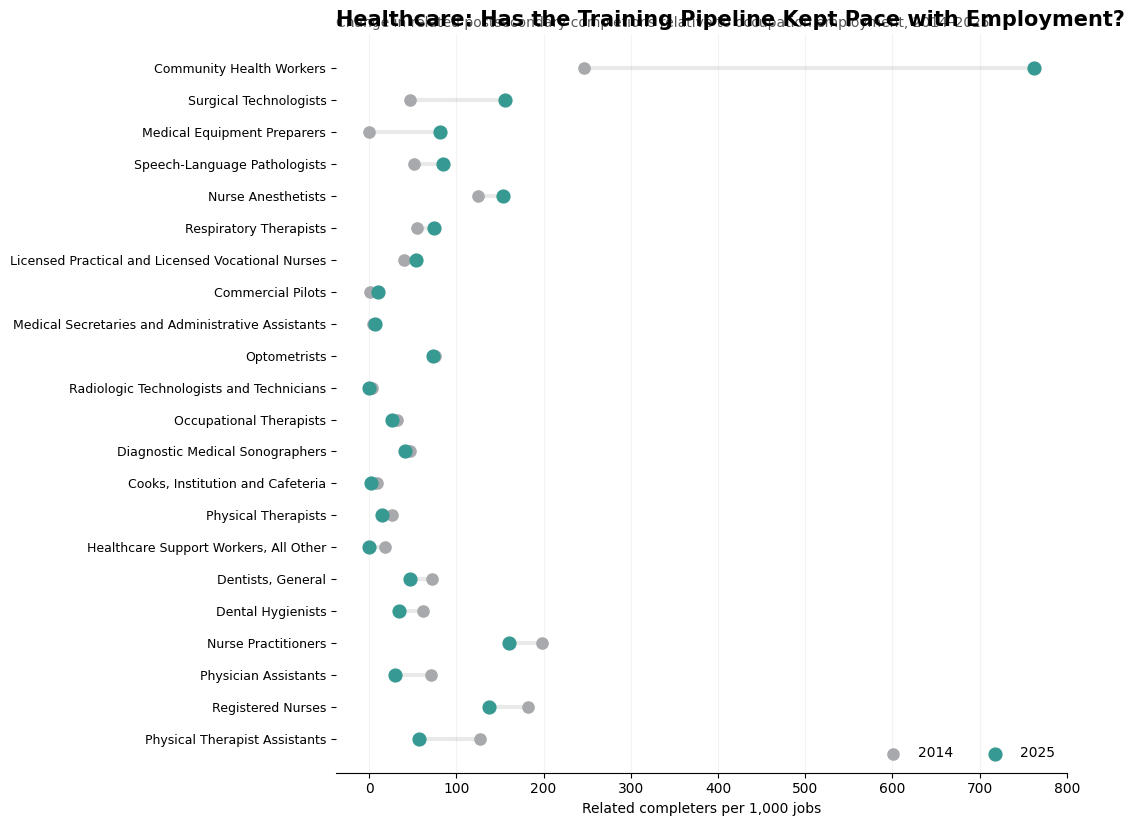

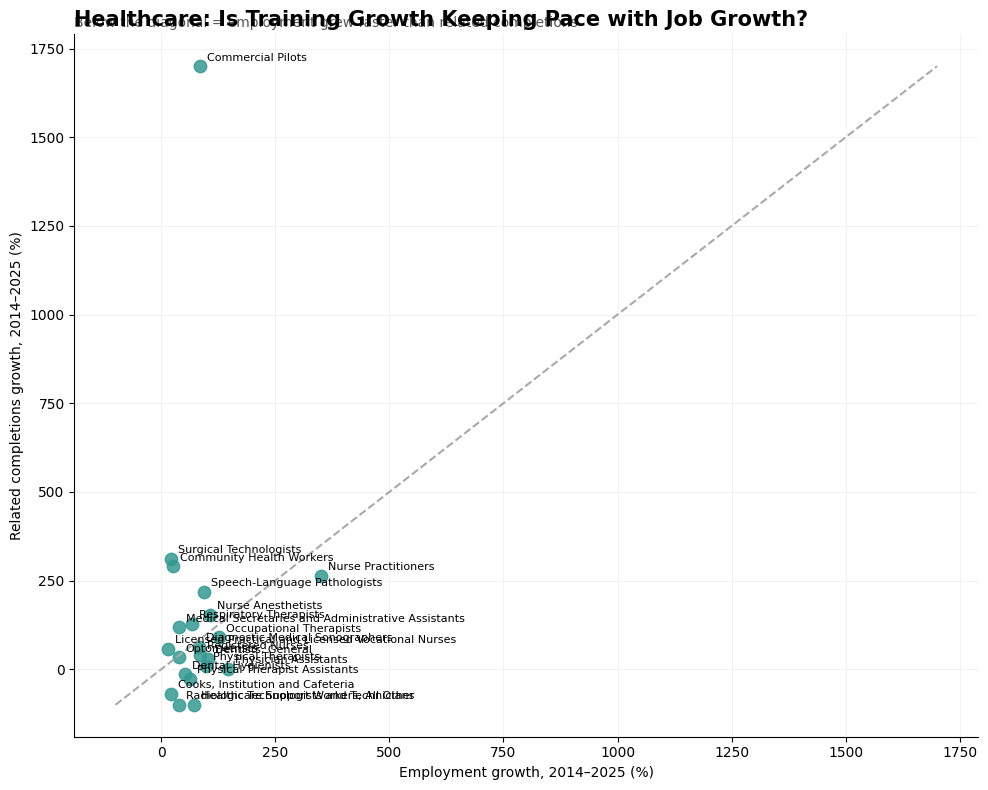

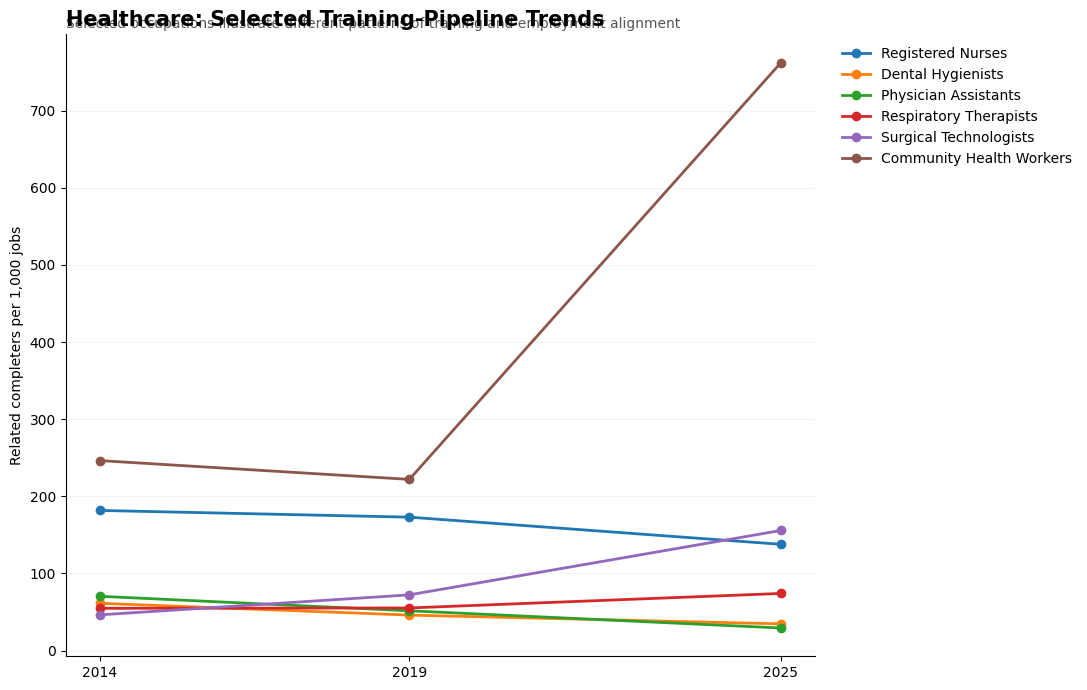

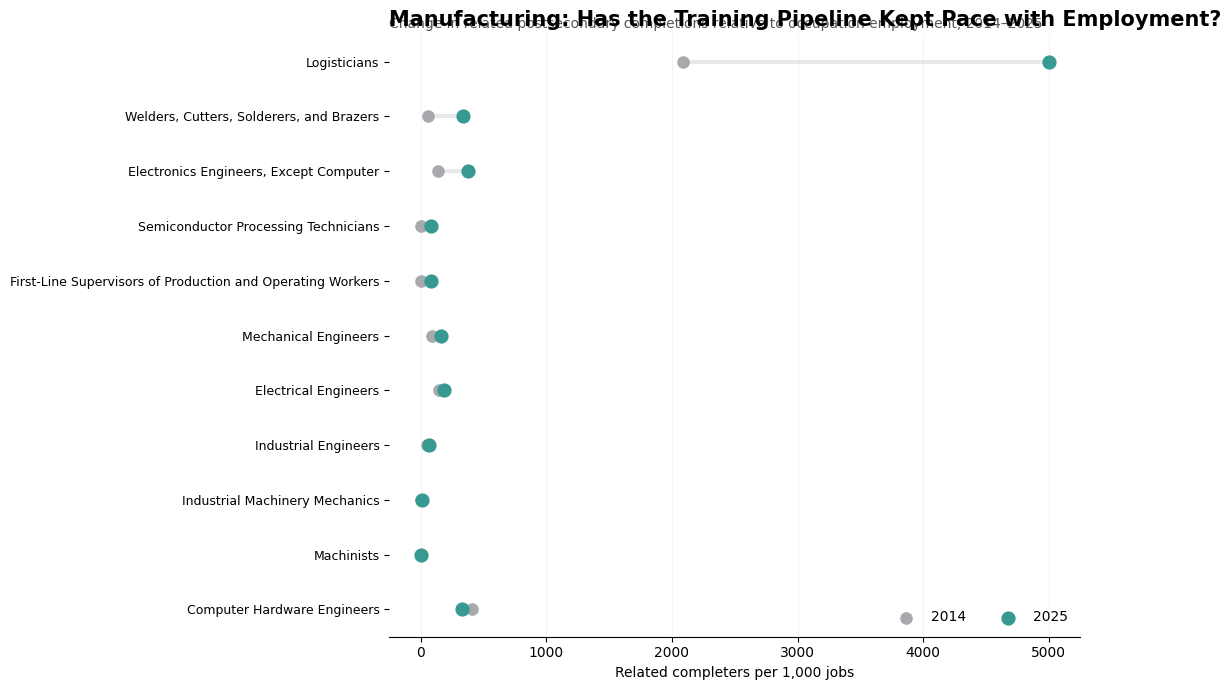

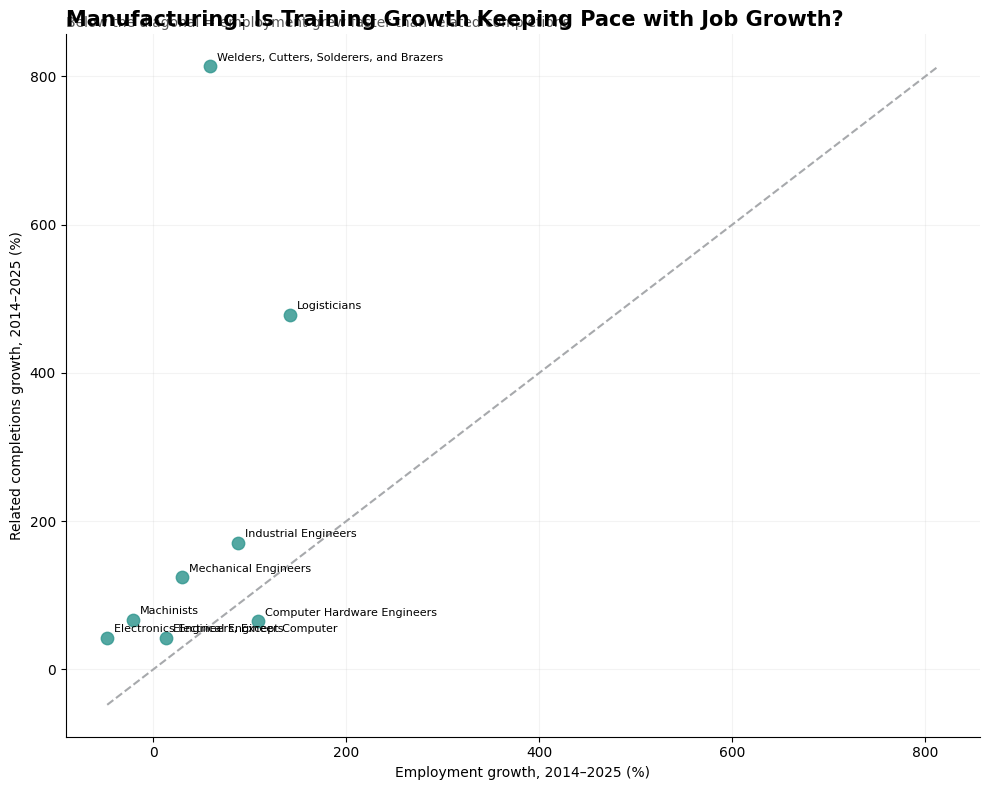

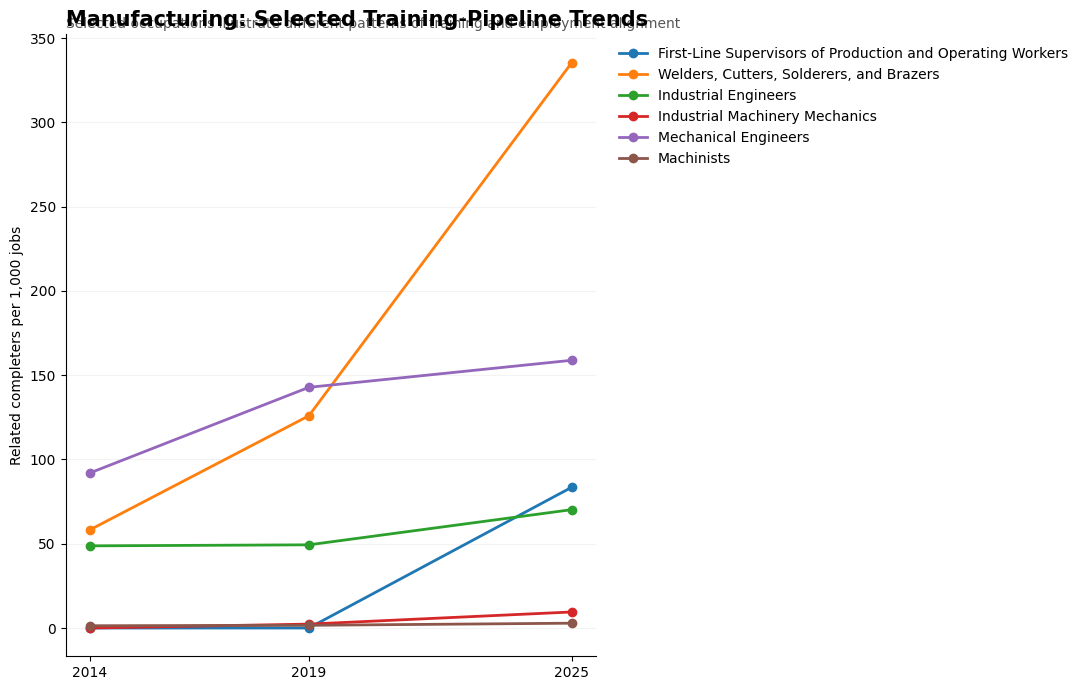


FIGURES CREATED
C:\Users\301533\Downloads\Ferris_Figures


In [30]:
# ============================================================
# CFA / WALMART PRESENTATION FIGURES
# Healthcare + Manufacturing
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


# ------------------------------------------------------------
# COLORS
# ------------------------------------------------------------

TEAL = "#369992"
DARK_TEAL = "#24756F"
LIGHT_TEAL = "#BFEAE5"

BLUSH = "#E79A64"
DARK_BLUSH = "#CC6C20"

GRAY = "#A7A9AC"
LIGHT_GRAY = "#E9E9E9"
DARK_GRAY = "#555555"


FIGURE_FOLDER = OUTPUT_FOLDER / "Ferris_Figures"
FIGURE_FOLDER.mkdir(parents=True, exist_ok=True)


# ============================================================
# HELPER
# ============================================================

def sector_data(sector):

    x = presentation[
        presentation["sector"].eq(sector)
    ].copy()

    return x


# ============================================================
# FIGURE 1
# TRAINING PIPELINE RELATIVE TO EMPLOYMENT
# 2014 vs 2025
# ============================================================

def make_alignment_change_chart(sector):

    df = sector_data(sector)

    df = df[
        (
            df["related_completions_per_1000_jobs_2014"] > 0
        )
        |
        (
            df["related_completions_per_1000_jobs_2025"] > 0
        )
    ].copy()

    df["change"] = (
        df["related_completions_per_1000_jobs_2025"]
        -
        df["related_completions_per_1000_jobs_2014"]
    )

    df = df.sort_values(
        "change"
    )

    fig, ax = plt.subplots(
        figsize=(11, max(7, len(df) * .38))
    )

    y = np.arange(len(df))

    # Connecting line
    for i, (_, r) in enumerate(df.iterrows()):

        ax.plot(
            [
                r["related_completions_per_1000_jobs_2014"],
                r["related_completions_per_1000_jobs_2025"]
            ],
            [i, i],
            color=LIGHT_GRAY,
            linewidth=3,
            zorder=1
        )

    # 2014
    ax.scatter(
        df["related_completions_per_1000_jobs_2014"],
        y,
        s=65,
        color=GRAY,
        label="2014",
        zorder=3
    )

    # 2025
    ax.scatter(
        df["related_completions_per_1000_jobs_2025"],
        y,
        s=85,
        color=TEAL,
        label="2025",
        zorder=4
    )

    ax.set_yticks(y)

    ax.set_yticklabels(
        df["job_title"],
        fontsize=9
    )

    ax.set_xlabel(
        "Related completers per 1,000 jobs",
        fontsize=10
    )

    ax.set_title(
        f"{sector}: Has the Training Pipeline Kept Pace with Employment?",
        fontsize=15,
        fontweight="bold",
        loc="left"
    )

    ax.text(
        0,
        1.01,
        "Change in related postsecondary completions relative to occupation employment, 2014–2025",
        transform=ax.transAxes,
        fontsize=10,
        color=DARK_GRAY
    )

    ax.legend(
        frameon=False,
        ncol=2,
        loc="lower right"
    )

    ax.grid(
        axis="x",
        alpha=.15
    )

    ax.spines[
        ["top", "right", "left"]
    ].set_visible(False)

    plt.tight_layout()

    path = (
        FIGURE_FOLDER
        /
        f"{sector}_01_training_alignment.png"
    )

    plt.savefig(
        path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    return path


# ============================================================
# FIGURE 2
# JOB GROWTH VS TRAINING GROWTH
# ============================================================

def make_growth_scatter(sector):

    df = sector_data(sector)

    # Percentage change only makes sense when
    # 2014 completions > 0.
    df = df[
        df["related_completions_2014"] > 0
    ].copy()

    x = df["jobs_pct_change_2014_2025"]
    y = df["training_pct_change_2014_2025"]

    fig, ax = plt.subplots(
        figsize=(10, 8)
    )

    ax.scatter(
        x,
        y,
        s=80,
        color=TEAL,
        alpha=.85
    )

    # Equal-growth reference line
    minimum = min(
        0,
        x.min(),
        y.min()
    )

    maximum = max(
        x.max(),
        y.max()
    )

    ax.plot(
        [minimum, maximum],
        [minimum, maximum],
        linestyle="--",
        color=GRAY,
        linewidth=1.5
    )

    # Label every point
    for _, r in df.iterrows():

        ax.annotate(
            r["job_title"],
            (
                r["jobs_pct_change_2014_2025"],
                r["training_pct_change_2014_2025"]
            ),
            xytext=(5, 4),
            textcoords="offset points",
            fontsize=8
        )

    ax.set_xlabel(
        "Employment growth, 2014–2025 (%)",
        fontsize=10
    )

    ax.set_ylabel(
        "Related completions growth, 2014–2025 (%)",
        fontsize=10
    )

    ax.set_title(
        f"{sector}: Is Training Growth Keeping Pace with Job Growth?",
        fontsize=15,
        fontweight="bold",
        loc="left"
    )

    ax.text(
        0,
        1.01,
        "Below the diagonal = employment grew faster than related completions",
        transform=ax.transAxes,
        fontsize=10,
        color=DARK_GRAY
    )

    ax.grid(
        alpha=.15
    )

    ax.spines[
        ["top", "right"]
    ].set_visible(False)

    plt.tight_layout()

    path = (
        FIGURE_FOLDER
        /
        f"{sector}_02_jobs_vs_training_growth.png"
    )

    plt.savefig(
        path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    return path


# ============================================================
# FIGURE 3
# SELECTED OCCUPATION TRENDS
# ============================================================

def make_selected_trends(
    sector,
    occupations
):

    df = sector_data(sector)

    df = df[
        df["job_title"].isin(
            occupations
        )
    ].copy()

    years = [
        2014,
        2019,
        2025
    ]

    fig, ax = plt.subplots(
        figsize=(11, 7)
    )

    for _, r in df.iterrows():

        values = [

            r[
                "related_completions_per_1000_jobs_2014"
            ],

            r[
                "related_completions_per_1000_jobs_2019"
            ],

            r[
                "related_completions_per_1000_jobs_2025"
            ]
        ]

        ax.plot(
            years,
            values,
            marker="o",
            linewidth=2,
            label=r["job_title"]
        )

    ax.set_xticks(
        years
    )

    ax.set_ylabel(
        "Related completers per 1,000 jobs"
    )

    ax.set_title(
        f"{sector}: Selected Training-Pipeline Trends",
        fontsize=15,
        fontweight="bold",
        loc="left"
    )

    ax.text(
        0,
        1.01,
        "Selected occupations illustrate different patterns of training and employment alignment",
        transform=ax.transAxes,
        fontsize=10,
        color=DARK_GRAY
    )

    ax.legend(
        frameon=False,
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    ax.grid(
        axis="y",
        alpha=.15
    )

    ax.spines[
        ["top", "right"]
    ].set_visible(False)

    plt.tight_layout()

    path = (
        FIGURE_FOLDER
        /
        f"{sector}_03_selected_trends.png"
    )

    plt.savefig(
        path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    return path


# ============================================================
# HEALTHCARE
# ============================================================

healthcare_fig1 = (
    make_alignment_change_chart(
        "Healthcare"
    )
)

healthcare_fig2 = (
    make_growth_scatter(
        "Healthcare"
    )
)

healthcare_fig3 = (
    make_selected_trends(
        "Healthcare",
        [
            "Registered Nurses",
            "Physician Assistants",
            "Dental Hygienists",
            "Respiratory Therapists",
            "Surgical Technologists",
            "Community Health Workers"
        ]
    )
)


# ============================================================
# MANUFACTURING
# ============================================================

manufacturing_fig1 = (
    make_alignment_change_chart(
        "Manufacturing"
    )
)

manufacturing_fig2 = (
    make_growth_scatter(
        "Manufacturing"
    )
)


# Pick Manufacturing occupations automatically,
# excluding Logisticians because the broad Business
# Administration CIP makes its training measure misleading.

manufacturing_candidates = (
    presentation[
        presentation["sector"].eq(
            "Manufacturing"
        )
        &
        ~presentation["job_title"].eq(
            "Logisticians"
        )
    ]
    .sort_values(
        "jobs_2025",
        ascending=False
    )
    .head(6)["job_title"]
    .tolist()
)


manufacturing_fig3 = (
    make_selected_trends(
        "Manufacturing",
        manufacturing_candidates
    )
)


print()
print("=" * 70)
print("FIGURES CREATED")
print("=" * 70)

print(
    FIGURE_FOLDER
)

In [32]:
# ============================================================
# CFA / WALMART — TRAINING ALIGNMENT VISUALIZATIONS
#
# Creates 3 figures for Healthcare and 3 for Manufacturing:
#
# 1. Training pipeline alignment over time
#    Related completers per 1,000 jobs: 2014 → 2019 → 2025
#
# 2. Training growth vs. employment growth
#    Diverging bar chart
#
# 3. Indexed training vs. employment trends
#    2014 = 100 for selected occupations
#
# Uses existing `presentation` dataframe.
# ============================================================

from pathlib import Path
import textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter


# ============================================================
# 1. COLORS
# ============================================================

TEAL = "#369992"
DARK_TEAL = "#24756F"
LIGHT_TEAL = "#BFEAE5"

BLUSH = "#E79A64"
DARK_BLUSH = "#CC6C20"
LIGHT_BLUSH = "#F7E5DC"

GRAY = "#A7A9AC"
DARK_GRAY = "#555555"
LIGHT_GRAY = "#E9E9E9"
VERY_LIGHT_GRAY = "#F5F5F5"

BLACK = "#222222"
WHITE = "#FFFFFF"


# ============================================================
# 2. OUTPUT FOLDER
# ============================================================

FIGURE_FOLDER = OUTPUT_FOLDER / "CFA_Walmart_Alignment_Figures"

FIGURE_FOLDER.mkdir(
    parents=True,
    exist_ok=True
)

print("Figure folder:")
print(FIGURE_FOLDER)


# ============================================================
# 3. BASIC CLEANING
# ============================================================

plot_df = presentation.copy()

numeric_cols = [
    "related_completions_2014",
    "related_completions_2019",
    "related_completions_2025",
    "jobs_2014",
    "jobs_2019",
    "jobs_2025",
    "related_completions_per_1000_jobs_2014",
    "related_completions_per_1000_jobs_2019",
    "related_completions_per_1000_jobs_2025",
    "training_pct_change_2014_2025",
    "jobs_pct_change_2014_2025"
]

for col in numeric_cols:
    if col in plot_df.columns:
        plot_df[col] = pd.to_numeric(
            plot_df[col],
            errors="coerce"
        )


# ============================================================
# 4. GENERAL FIGURE STYLE
# ============================================================

plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 15,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.facecolor": "white",
    "axes.facecolor": "white"
})


def wrap_label(text, width=32):
    """
    Wrap long occupation labels.
    """
    return "\n".join(
        textwrap.wrap(
            str(text),
            width=width
        )
    )


def clean_axes(ax):
    """
    Remove unnecessary chart borders.
    """
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)


def save_figure(fig, filename):
    """
    Save figure as high-resolution PNG.
    """
    path = FIGURE_FOLDER / filename

    fig.savefig(
        path,
        dpi=300,
        bbox_inches="tight",
        facecolor="white"
    )

    print("Saved:", path)

    return path


# ============================================================
# REVISED FIGURE 1
# TRAINING PIPELINE ALIGNMENT — CLEAN CFA VERSION
# ============================================================

from matplotlib.lines import Line2D


# ------------------------------------------------------------
# CLASSIFICATION THRESHOLD
#
# +/- 15 percentage points means training growth and
# employment growth are considered relatively aligned.
#
# This is a descriptive threshold for visualization,
# not a statistical significance test.
# ------------------------------------------------------------

ALIGNMENT_THRESHOLD = 15


def make_clean_pipeline_flow(
    sector,
    top_n=12
):

    df = (
        plot_df[
            plot_df["sector"].eq(sector)
        ]
        .copy()
    )


    # ========================================================
    # 1. REMOVE CASES THAT CANNOT BE COMPARED CLEANLY
    # ========================================================

    # Need a positive 2014 training baseline to calculate
    # meaningful training percentage growth.

    df = df[
        (df["related_completions_2014"] > 0)
        &
        df["training_pct_change_2014_2025"].notna()
        &
        df["jobs_pct_change_2014_2025"].notna()
    ].copy()


    # ========================================================
    # 2. ALIGNMENT GAP
    #
    # Positive = training grew faster
    # Negative = employment grew faster
    # ========================================================

    df["alignment_gap_pp"] = (
        df["training_pct_change_2014_2025"]
        -
        df["jobs_pct_change_2014_2025"]
    )


    # ========================================================
    # 3. CLASSIFY
    # ========================================================

    df["alignment_category"] = np.select(

        [
            df["alignment_gap_pp"]
            > ALIGNMENT_THRESHOLD,

            df["alignment_gap_pp"]
            < -ALIGNMENT_THRESHOLD
        ],

        [
            "Training outpaced employment",
            "Employment outpaced training"
        ],

        default="Relatively aligned"
    )


    # ========================================================
    # 4. SELECT OCCUPATIONS FOR MAIN FIGURE
    #
    # Select occupations with the largest absolute
    # alignment gaps so the chart tells a clear story.
    #
    # Keep stable occupations too so gray is represented.
    # ========================================================

    df["absolute_gap"] = (
        df["alignment_gap_pp"].abs()
    )


    # Get strongest divergence examples
    divergent = (
        df[
            df["alignment_category"]
            != "Relatively aligned"
        ]
        .nlargest(
            max(top_n - 3, 1),
            "absolute_gap"
        )
    )


    # Get up to 3 stable/aligned examples
    stable = (
        df[
            df["alignment_category"]
            == "Relatively aligned"
        ]
        .nsmallest(
            3,
            "absolute_gap"
        )
    )


    df_plot = (
        pd.concat(
            [
                divergent,
                stable
            ]
        )
        .drop_duplicates(
            subset=["soc"]
        )
    )


    # If fewer than top_n selected,
    # fill with next-largest gaps.

    if len(df_plot) < top_n:

        remaining = (
            df[
                ~df["soc"].isin(
                    df_plot["soc"]
                )
            ]
            .nlargest(
                top_n - len(df_plot),
                "absolute_gap"
            )
        )

        df_plot = pd.concat(
            [
                df_plot,
                remaining
            ]
        )


    # ========================================================
    # 5. SORT BY 2025 RATIO
    #
    # This makes final labels easier to read.
    # ========================================================

    df_plot = (
        df_plot
        .sort_values(
            "related_completions_per_1000_jobs_2025",
            ascending=False
        )
        .reset_index(drop=True)
    )


    # ========================================================
    # 6. COLORS
    # ========================================================

    category_colors = {

        "Training outpaced employment":
            TEAL,

        "Relatively aligned":
            GRAY,

        "Employment outpaced training":
            DARK_BLUSH
    }


    years = [
        2014,
        2019,
        2025
    ]


    ratio_cols = [

        "related_completions_per_1000_jobs_2014",

        "related_completions_per_1000_jobs_2019",

        "related_completions_per_1000_jobs_2025"
    ]


    # ========================================================
    # 7. RANK WITHIN EACH YEAR
    # ========================================================

    rank_df = pd.DataFrame(
        index=df_plot.index
    )


    for year, col in zip(
        years,
        ratio_cols
    ):

        rank_df[year] = (
            df_plot[col]
            .rank(
                method="first",
                ascending=False
            )
        )


    # ========================================================
    # 8. FIGURE
    # ========================================================

    fig_height = max(
        7.5,
        len(df_plot) * 0.55
    )


    fig, ax = plt.subplots(
        figsize=(16, fig_height)
    )


    # ========================================================
    # 9. DRAW LINES
    # ========================================================

    for i, row in df_plot.iterrows():

        color = category_colors[
            row["alignment_category"]
        ]


        ranks = [

            rank_df.loc[i, 2014],

            rank_df.loc[i, 2019],

            rank_df.loc[i, 2025]
        ]


        ax.plot(

            years,
            ranks,

            color=color,

            linewidth=2.3,

            marker="o",

            markersize=7,

            alpha=0.90,

            zorder=3
        )


        # ----------------------------------------------------
        # Add value above EACH point
        # ----------------------------------------------------

        values = [

            row[
                "related_completions_per_1000_jobs_2014"
            ],

            row[
                "related_completions_per_1000_jobs_2019"
            ],

            row[
                "related_completions_per_1000_jobs_2025"
            ]
        ]


        for x, y, value in zip(
            years,
            ranks,
            values
        ):

            ax.text(

                x,

                y - 0.18,

                f"{value:.1f}",

                ha="center",

                va="bottom",

                fontsize=8,

                color=color,

                fontweight="bold"
            )


        # ----------------------------------------------------
        # LEFT LABEL
        # ----------------------------------------------------

        ax.text(

            2014 - 0.28,

            ranks[0],

            row["job_title"],

            ha="right",

            va="center",

            fontsize=9,

            color=BLACK
        )


        # ----------------------------------------------------
        # RIGHT LABEL
        # ----------------------------------------------------

        ax.text(

            2025 + 0.28,

            ranks[2],

            row["job_title"],

            ha="left",

            va="center",

            fontsize=9,

            color=BLACK
        )


    # ========================================================
    # 10. YEAR LINES
    # ========================================================

    for year in years:

        ax.axvline(

            year,

            color=LIGHT_GRAY,

            linewidth=1.2,

            zorder=0
        )


    # ========================================================
    # 11. AXIS
    # ========================================================

    ax.set_xlim(
        2011.5,
        2027.5
    )


    ax.set_ylim(
        len(df_plot) + 0.75,
        0.25
    )


    ax.set_xticks(
        years
    )


    ax.set_xticklabels(

        years,

        fontsize=12,

        fontweight="bold"
    )


    ax.set_yticks([])


    ax.tick_params(
        axis="x",
        length=0
    )


    # ========================================================
    # 12. TITLE
    # ========================================================

    ax.set_title(

        f"{sector}: Is Training Keeping Pace with Employment?",

        loc="left",

        fontsize=17,

        fontweight="bold",

        pad=34
    )


    ax.text(

        0,

        1.025,

        (
            "Related postsecondary completers per 1,000 jobs "
            "at three points in time"
        ),

        transform=ax.transAxes,

        fontsize=10.5,

        color=DARK_GRAY
    )


    # ========================================================
    # 13. LEGEND
    # ========================================================

    legend_elements = [

        Line2D(

            [0],
            [0],

            color=TEAL,

            marker="o",

            linewidth=2.5,

            label="Training outpaced employment"
        ),

        Line2D(

            [0],
            [0],

            color=GRAY,

            marker="o",

            linewidth=2.5,

            label=(
                f"Relatively aligned "
                f"(within ±{ALIGNMENT_THRESHOLD} pp)"
            )
        ),

        Line2D(

            [0],
            [0],

            color=DARK_BLUSH,

            marker="o",

            linewidth=2.5,

            label="Employment outpaced training"
        )
    ]


    ax.legend(

        handles=legend_elements,

        loc="upper center",

        bbox_to_anchor=(
            0.5,
            1.01
        ),

        ncol=3,

        frameon=False,

        fontsize=9
    )


    # ========================================================
    # 14. EXPLANATORY NOTE
    # ========================================================

    fig.text(

        0.5,

        0.015,

        (
            "Classification compares 2014–2025 growth in "
            "related completions with employment growth. "
            f"Within ±{ALIGNMENT_THRESHOLD} percentage points "
            "is shown as relatively aligned. "
            "Related completions are not equivalent to "
            "verified entrants into the occupation."
        ),

        ha="center",

        fontsize=8.5,

        color=DARK_GRAY
    )


    # ========================================================
    # 15. REMOVE BORDERS
    # ========================================================

    for spine in ax.spines.values():

        spine.set_visible(False)


    plt.tight_layout(
        rect=[
            0.03,
            0.055,
            0.97,
            0.94
        ]
    )


    # ========================================================
    # 16. SAVE
    # ========================================================

    path = save_figure(

        fig,

        f"{sector}_01_CLEAN_alignment_flow.png"
    )


    plt.show()


    # ========================================================
    # 17. ALSO RETURN TABLE SO YOU CAN QA THE COLORS
    # ========================================================

    check = df_plot[
        [
            "job_title",
            "training_pct_change_2014_2025",
            "jobs_pct_change_2014_2025",
            "alignment_gap_pp",
            "alignment_category"
        ]
    ].copy()


    display(
        check
        .sort_values(
            "alignment_gap_pp"
        )
    )


    return path, check


# ============================================================
# FIGURE 2
#
# ALIGNMENT GAP
#
# Training growth % minus employment growth %
#
# Negative:
# Employment grew faster than related completions.
#
# Positive:
# Related completions grew faster than employment.
# ============================================================

def make_alignment_gap(sector):

    df = (
        plot_df[
            plot_df["sector"].eq(sector)
        ]
        .copy()
    )


    # --------------------------------------------------------
    # Percentage training growth cannot be calculated when
    # the starting number of completers is zero.
    # --------------------------------------------------------

    df = df[
        (df["related_completions_2014"] > 0)
        &
        df["training_pct_change_2014_2025"].notna()
        &
        df["jobs_pct_change_2014_2025"].notna()
    ].copy()


    df["alignment_gap_pp"] = (
        df["training_pct_change_2014_2025"]
        -
        df["jobs_pct_change_2014_2025"]
    )


    # --------------------------------------------------------
    # For Manufacturing:
    # flag Logisticians rather than silently remove it.
    # --------------------------------------------------------

    df["mapping_flag"] = False

    if sector == "Manufacturing":

        df.loc[
            df["job_title"].eq(
                "Logisticians"
            ),
            "mapping_flag"
        ] = True


    # --------------------------------------------------------
    # Sort
    # --------------------------------------------------------

    df = df.sort_values(
        "alignment_gap_pp",
        ascending=True
    ).reset_index(drop=True)


    # --------------------------------------------------------
    # FIGURE
    # --------------------------------------------------------

    fig_height = max(
        7,
        len(df) * 0.46
    )

    fig, ax = plt.subplots(
        figsize=(12, fig_height)
    )


    y = np.arange(
        len(df)
    )


    colors = [
        DARK_BLUSH if value < 0 else TEAL
        for value in df["alignment_gap_pp"]
    ]


    bars = ax.barh(
        y,
        df["alignment_gap_pp"],
        color=colors,
        height=0.65
    )


    # --------------------------------------------------------
    # Zero line
    # --------------------------------------------------------

    ax.axvline(
        0,
        color=DARK_GRAY,
        linewidth=1.2
    )


    # --------------------------------------------------------
    # Labels
    # --------------------------------------------------------

    ax.set_yticks(
        y
    )

    ax.set_yticklabels(
        [
            wrap_label(x, 30)
            for x in df["job_title"]
        ]
    )


    ax.invert_yaxis()


    # --------------------------------------------------------
    # Value labels
    # --------------------------------------------------------

    for i, (
        bar,
        value,
        flagged
    ) in enumerate(
        zip(
            bars,
            df["alignment_gap_pp"],
            df["mapping_flag"]
        )
    ):

        if value >= 0:

            x_pos = value + (
                max(abs(df["alignment_gap_pp"])) * .015
            )

            ha = "left"

        else:

            x_pos = value - (
                max(abs(df["alignment_gap_pp"])) * .015
            )

            ha = "right"


        label = (
            f"{value:+.0f} pp"
        )


        if flagged:
            label += " *"


        ax.text(
            x_pos,
            bar.get_y() + bar.get_height() / 2,
            label,
            va="center",
            ha=ha,
            fontsize=9,
            fontweight="bold"
        )


    # --------------------------------------------------------
    # Titles
    # --------------------------------------------------------

    ax.set_title(
        f"{sector}: Where Is Employment Growth Outpacing Training Growth?",
        loc="left",
        fontsize=16,
        fontweight="bold",
        pad=22
    )


    ax.text(
        0,
        1.015,
        (
            "Difference between growth in related completions "
            "and growth in employment, 2014–2025"
        ),
        transform=ax.transAxes,
        fontsize=10,
        color=DARK_GRAY
    )


    ax.set_xlabel(
        "Training growth minus employment growth (percentage points)"
    )


    # --------------------------------------------------------
    # Direction labels
    # --------------------------------------------------------

    ax.text(
        0.01,
        -0.09,
        "← Employment grew faster",
        transform=ax.transAxes,
        color=DARK_BLUSH,
        fontsize=10,
        fontweight="bold"
    )


    ax.text(
        0.99,
        -0.09,
        "Training grew faster →",
        transform=ax.transAxes,
        color=TEAL,
        fontsize=10,
        fontweight="bold",
        ha="right"
    )


    if (
        sector == "Manufacturing"
        and df["mapping_flag"].any()
    ):

        ax.text(
            0,
            -0.15,
            (
                "* Logisticians should be interpreted cautiously "
                "because its related training count is driven by "
                "the broad Business Administration CIP mapping."
            ),
            transform=ax.transAxes,
            fontsize=8.5,
            color=DARK_GRAY
        )


    ax.grid(
        axis="x",
        alpha=.15
    )


    clean_axes(ax)

    ax.spines["bottom"].set_visible(False)

    ax.tick_params(
        axis="y",
        length=0
    )


    plt.tight_layout()


    path = save_figure(
        fig,
        f"{sector}_02_alignment_gap.png"
    )

    plt.show()

    return path


# ============================================================
# FIGURE 3
#
# INDEXED TRAINING VS EMPLOYMENT
#
# 2014 = 100
#
# This directly shows whether the training pipeline and
# employment have moved together.
# ============================================================

def make_indexed_trends(
    sector,
    occupations
):

    df = (
        plot_df[
            (
                plot_df["sector"].eq(
                    sector
                )
            )
            &
            (
                plot_df["job_title"].isin(
                    occupations
                )
            )
        ]
        .copy()
    )


    # --------------------------------------------------------
    # Need positive 2014 training and jobs to create index.
    # --------------------------------------------------------

    df = df[
        (df["related_completions_2014"] > 0)
        &
        (df["jobs_2014"] > 0)
    ].copy()


    years = np.array(
        [2014, 2019, 2025]
    )


    # --------------------------------------------------------
    # One mini-chart per occupation.
    # --------------------------------------------------------

    n = len(df)

    if n == 0:

        print(
            f"No valid occupations for {sector} indexed figure."
        )

        return None


    fig, axes = plt.subplots(
        nrows=n,
        ncols=1,
        figsize=(11, max(7, n * 2.0)),
        sharex=True
    )


    if n == 1:
        axes = [axes]


    # Keep requested occupation order
    order_map = {
        occ: i
        for i, occ in enumerate(
            occupations
        )
    }

    df["plot_order"] = (
        df["job_title"]
        .map(order_map)
    )

    df = df.sort_values(
        "plot_order"
    )


    for ax, (_, row) in zip(
        axes,
        df.iterrows()
    ):


        training = np.array(
            [
                row["related_completions_2014"],
                row["related_completions_2019"],
                row["related_completions_2025"]
            ],
            dtype=float
        )


        jobs = np.array(
            [
                row["jobs_2014"],
                row["jobs_2019"],
                row["jobs_2025"]
            ],
            dtype=float
        )


        training_index = (
            training
            /
            training[0]
            *
            100
        )


        jobs_index = (
            jobs
            /
            jobs[0]
            *
            100
        )


        # ----------------------------------------------------
        # Employment
        # ----------------------------------------------------

        ax.plot(
            years,
            jobs_index,
            marker="o",
            markersize=6,
            linewidth=2.5,
            color=DARK_GRAY,
            label="Employment"
        )


        # ----------------------------------------------------
        # Training
        # ----------------------------------------------------

        ax.plot(
            years,
            training_index,
            marker="o",
            markersize=6,
            linewidth=2.5,
            color=TEAL,
            label="Related completions"
        )


        # 2014 baseline
        ax.axhline(
            100,
            color=LIGHT_GRAY,
            linewidth=1,
            zorder=0
        )


        # ----------------------------------------------------
        # Occupation label
        # ----------------------------------------------------

        ax.set_title(
            row["job_title"],
            loc="left",
            fontsize=11,
            fontweight="bold"
        )


        # ----------------------------------------------------
        # End labels
        # ----------------------------------------------------

        ax.text(
            2025.25,
            jobs_index[-1],
            f"Jobs {jobs_index[-1]:.0f}",
            va="center",
            fontsize=9,
            color=DARK_GRAY,
            fontweight="bold"
        )


        ax.text(
            2025.25,
            training_index[-1],
            f"Training {training_index[-1]:.0f}",
            va="center",
            fontsize=9,
            color=TEAL,
            fontweight="bold"
        )


        ax.set_xlim(
            2013.5,
            2027.5
        )


        ax.grid(
            axis="y",
            alpha=.12
        )


        ax.spines[
            ["top", "right", "left"]
        ].set_visible(False)


        ax.tick_params(
            axis="y",
            length=0
        )


    # --------------------------------------------------------
    # Overall title
    # --------------------------------------------------------

    fig.suptitle(
        f"{sector}: How Have Training and Employment Changed?",
        x=0.125,
        ha="left",
        fontsize=17,
        fontweight="bold"
    )


    fig.text(
        0.125,
        0.965,
        (
            "Indexed to 2014 = 100. "
            "A widening gap shows training and employment "
            "moving at different rates."
        ),
        fontsize=10,
        color=DARK_GRAY
    )


    axes[-1].set_xticks(
        years
    )


    axes[-1].set_xticklabels(
        ["2014", "2019", "2025"],
        fontweight="bold"
    )


    axes[-1].set_xlabel(
        "Year"
    )


    # One shared legend
    handles, labels = (
        axes[0].get_legend_handles_labels()
    )


    fig.legend(
        handles,
        labels,
        loc="upper right",
        bbox_to_anchor=(0.92, 0.98),
        frameon=False,
        ncol=2
    )


    plt.tight_layout(
        rect=[
            0.05,
            0.03,
            0.95,
            0.94
        ]
    )


    path = save_figure(
        fig,
        f"{sector}_03_indexed_trends.png"
    )

    plt.show()

    return path


# ============================================================
# 5. HEALTHCARE FIGURES
# ============================================================

print()
print("=" * 70)
print("HEALTHCARE")
print("=" * 70)


healthcare_flow = (
    make_pipeline_flow(
        "Healthcare"
    )
)


healthcare_gap = (
    make_alignment_gap(
        "Healthcare"
    )
)


# These were selected because they demonstrate
# meaningfully different alignment patterns.

HEALTHCARE_EXAMPLES = [

    "Registered Nurses",

    "Physician Assistants",

    "Dental Hygienists",

    "Respiratory Therapists",

    "Surgical Technologists",

    "Community Health Workers"
]


healthcare_index = (
    make_indexed_trends(
        "Healthcare",
        HEALTHCARE_EXAMPLES
    )
)


# ============================================================
# 6. MANUFACTURING FIGURES
# ============================================================

print()
print("=" * 70)
print("MANUFACTURING")
print("=" * 70)


manufacturing_flow = (
    make_pipeline_flow(
        "Manufacturing"
    )
)


manufacturing_gap = (
    make_alignment_gap(
        "Manufacturing"
    )
)


# ------------------------------------------------------------
# Automatically choose six Manufacturing occupations.
#
# Exclude Logisticians from this illustrative figure because
# its training count is driven by broad Business Administration
# mapping.
#
# Must also have >0 training in 2014 for indexing.
# ------------------------------------------------------------

manufacturing_examples = (

    plot_df[
        (
            plot_df["sector"].eq(
                "Manufacturing"
            )
        )
        &
        (
            plot_df["related_completions_2014"] > 0
        )
        &
        ~(
            plot_df["job_title"].eq(
                "Logisticians"
            )
        )
    ]

    .sort_values(
        "jobs_2025",
        ascending=False
    )

    .head(6)

    ["job_title"]

    .tolist()
)


print(
    "Manufacturing occupations selected "
    "for indexed figure:"
)

for occupation in manufacturing_examples:

    print(
        " -",
        occupation
    )


manufacturing_index = (
    make_indexed_trends(
        "Manufacturing",
        manufacturing_examples
    )
)


# ============================================================
# 7. SUMMARY
# ============================================================

print()
print("=" * 70)
print("ALL FIGURES COMPLETE")
print("=" * 70)

print()
print(
    "Saved to:"
)

print(
    FIGURE_FOLDER
)

print()

print(
    "Healthcare:"
)

print(
    "  1.",
    healthcare_flow
)

print(
    "  2.",
    healthcare_gap
)

print(
    "  3.",
    healthcare_index
)

print()

print(
    "Manufacturing:"
)

print(
    "  1.",
    manufacturing_flow
)

print(
    "  2.",
    manufacturing_gap
)

print(
    "  3.",
    manufacturing_index
)

Figure folder:
C:\Users\301533\Downloads\CFA_Walmart_Alignment_Figures

HEALTHCARE


NameError: name 'make_pipeline_flow' is not defined

Saved: C:\Users\301533\Downloads\CFA_Walmart_Final_Figures\Healthcare_01_alignment_matrix.png


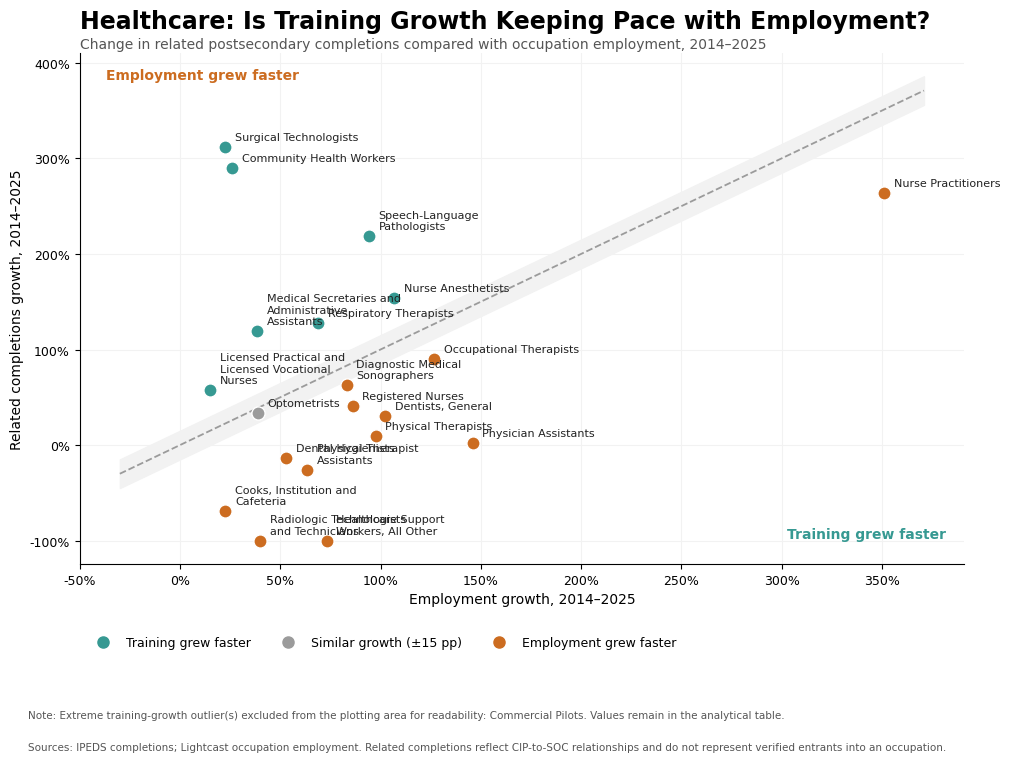

Saved: C:\Users\301533\Downloads\CFA_Walmart_Final_Figures\Healthcare_02_selected_pipeline_shift.png


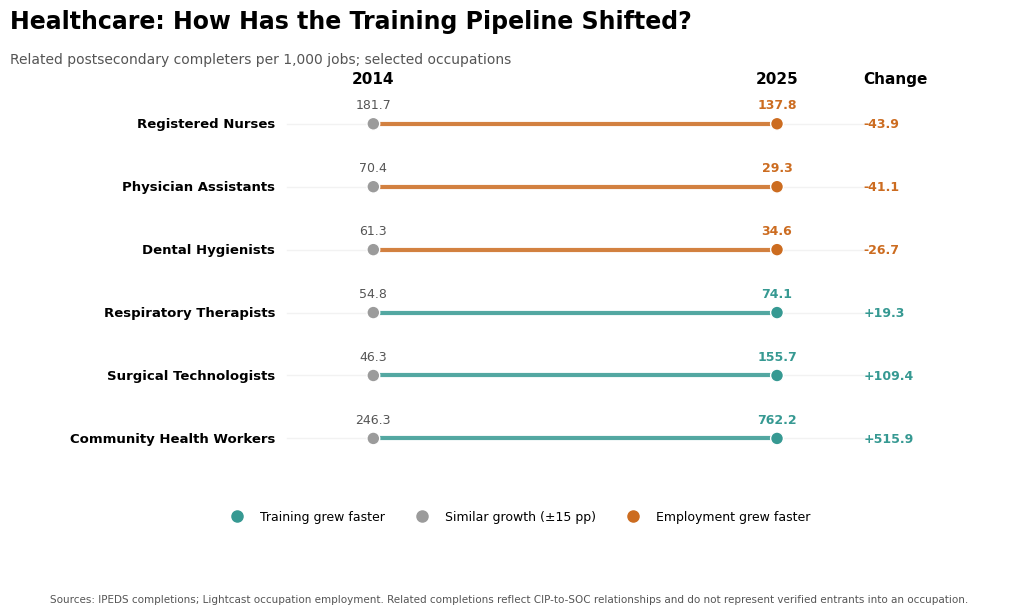

Saved: C:\Users\301533\Downloads\CFA_Walmart_Final_Figures\Healthcare_03_indexed_examples.png


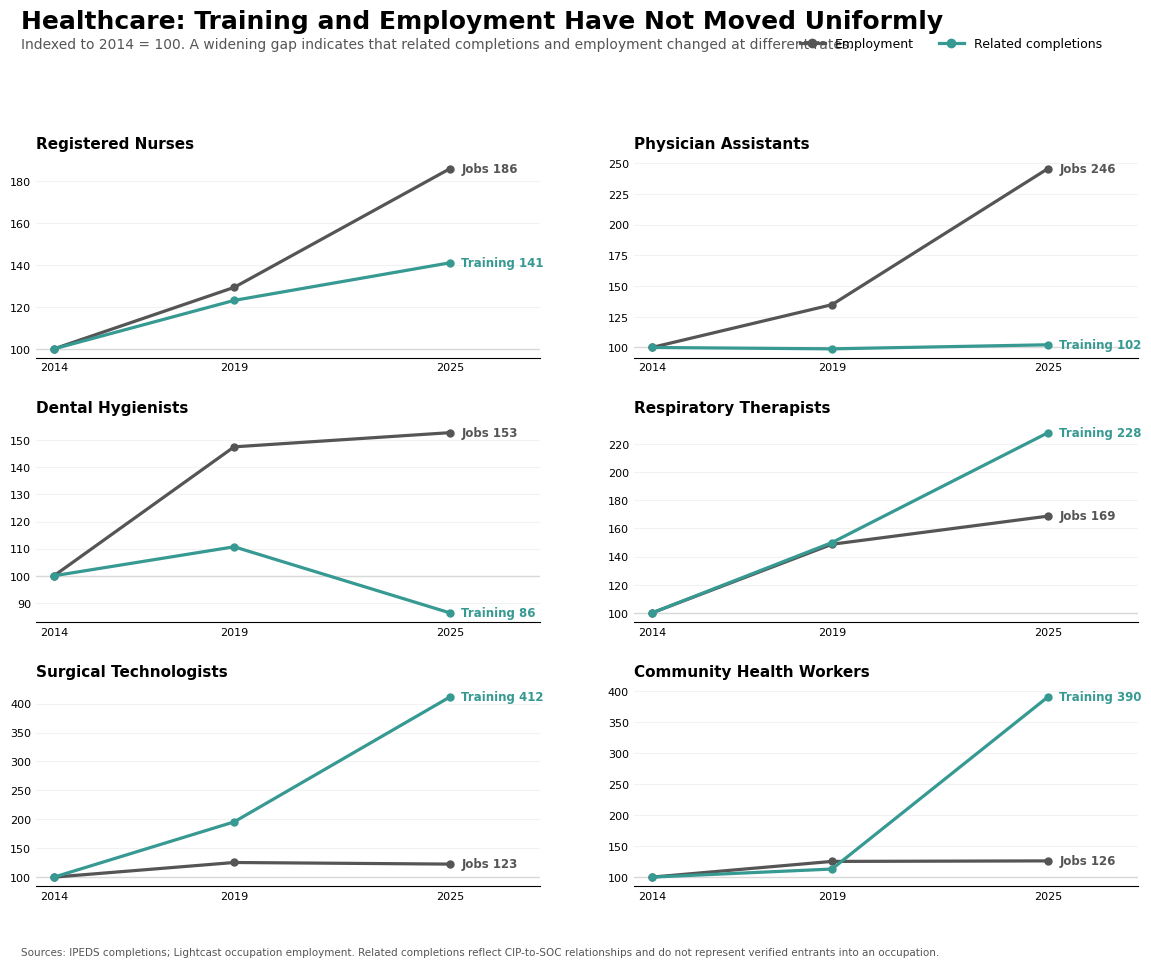

Manufacturing examples:
 - Welders, Cutters, Solderers, and Brazers
 - Mechanical Engineers
 - Electronics Engineers, Except Computer
 - Machinists
 - Industrial Engineers
 - Computer Hardware Engineers
Saved: C:\Users\301533\Downloads\CFA_Walmart_Final_Figures\Manufacturing_01_alignment_matrix.png


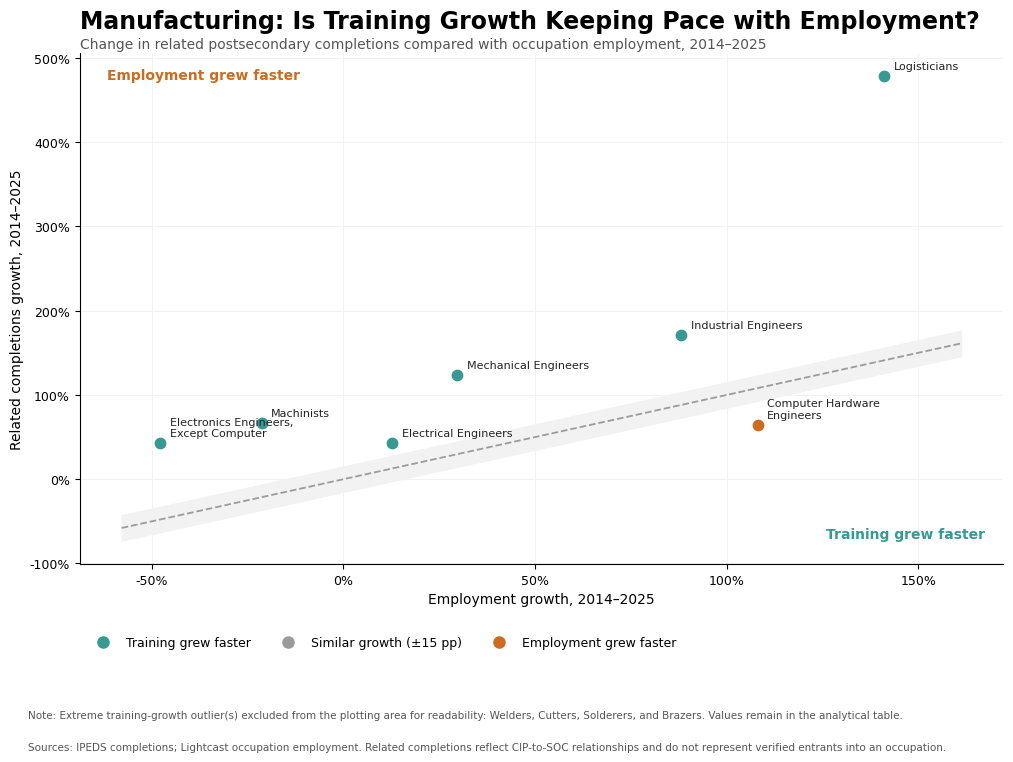

Saved: C:\Users\301533\Downloads\CFA_Walmart_Final_Figures\Manufacturing_02_selected_pipeline_shift.png


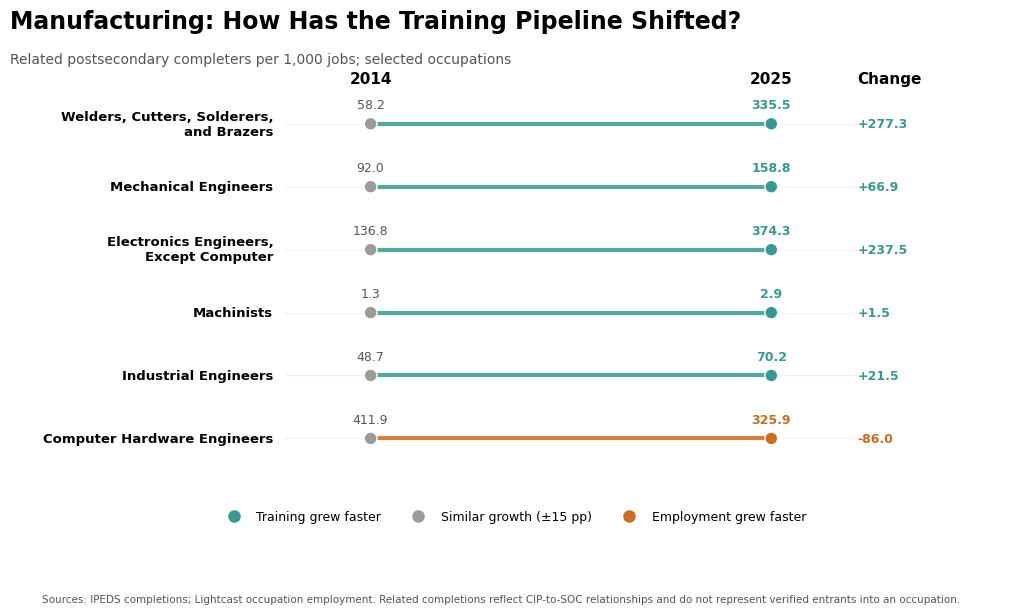

Saved: C:\Users\301533\Downloads\CFA_Walmart_Final_Figures\Manufacturing_03_indexed_examples.png


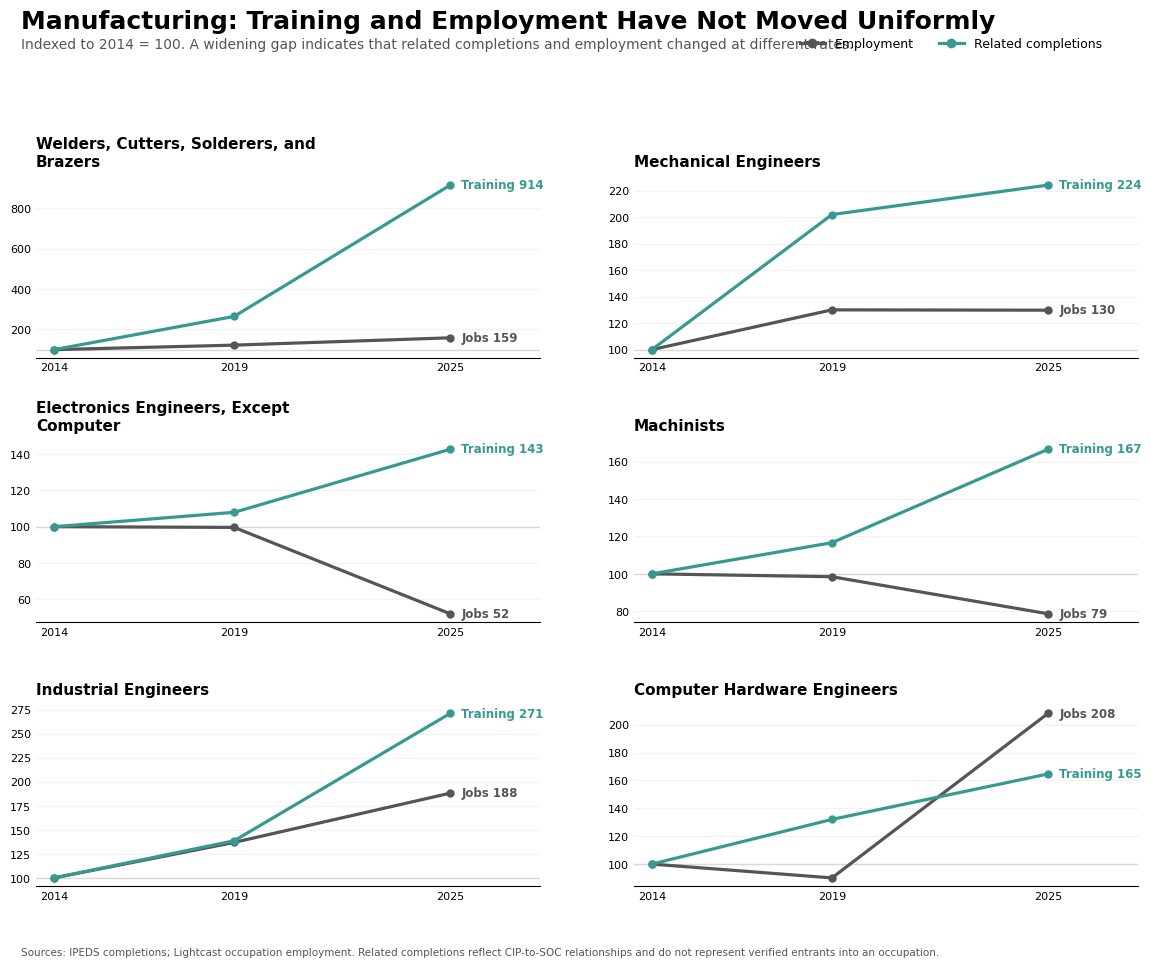


PUBLICATION FIGURES COMPLETE
C:\Users\301533\Downloads\CFA_Walmart_Final_Figures


In [33]:
# ============================================================
# CFA / WALMART — PUBLICATION-READY ALIGNMENT FIGURES
# ============================================================

from pathlib import Path
import textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter


# ============================================================
# 1. COLORS
# ============================================================

TEAL = "#369992"
DARK_TEAL = "#24756F"
LIGHT_TEAL = "#BFEAE5"

BLUSH = "#E79A64"
DARK_BLUSH = "#CC6C20"
LIGHT_BLUSH = "#F7E5DC"

GRAY = "#9B9B9B"
DARK_GRAY = "#555555"
LIGHT_GRAY = "#D9D9D9"
VERY_LIGHT_GRAY = "#F2F2F2"

BLACK = "#222222"
WHITE = "#FFFFFF"


# ============================================================
# 2. OUTPUT FOLDER
# ============================================================

FIGURE_FOLDER = OUTPUT_FOLDER / "CFA_Walmart_Final_Figures"

FIGURE_FOLDER.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 3. DATA
# ============================================================

viz = presentation.copy()

numeric_cols = [
    "related_completions_2014",
    "related_completions_2019",
    "related_completions_2025",
    "jobs_2014",
    "jobs_2019",
    "jobs_2025",
    "related_completions_per_1000_jobs_2014",
    "related_completions_per_1000_jobs_2019",
    "related_completions_per_1000_jobs_2025",
    "training_pct_change_2014_2025",
    "jobs_pct_change_2014_2025"
]

for col in numeric_cols:
    viz[col] = pd.to_numeric(
        viz[col],
        errors="coerce"
    )


# ============================================================
# 4. CLASSIFICATION
# ============================================================

# Descriptive visualization threshold.
# This is NOT a statistical test.
ALIGNMENT_THRESHOLD = 15


def classify_alignment(df):

    x = df.copy()

    x["alignment_gap"] = (
        x["training_pct_change_2014_2025"]
        -
        x["jobs_pct_change_2014_2025"]
    )

    x["alignment_category"] = np.select(
        [
            x["alignment_gap"] > ALIGNMENT_THRESHOLD,
            x["alignment_gap"] < -ALIGNMENT_THRESHOLD
        ],
        [
            "Training grew faster",
            "Employment grew faster"
        ],
        default="Similar growth"
    )

    return x


viz = classify_alignment(viz)


COLOR_MAP = {
    "Training grew faster": TEAL,
    "Similar growth": GRAY,
    "Employment grew faster": DARK_BLUSH
}


# ============================================================
# 5. HELPERS
# ============================================================

def wrap(text, width=26):
    return "\n".join(
        textwrap.wrap(
            str(text),
            width=width
        )
    )


def remove_frame(ax):

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)

    ax.tick_params(
        axis="y",
        length=0
    )


def save_fig(fig, name):

    path = FIGURE_FOLDER / name

    fig.savefig(
        path,
        dpi=300,
        bbox_inches="tight",
        facecolor=WHITE
    )

    print("Saved:", path)

    return path


def add_source_note(fig):

    fig.text(
        0.08,
        0.015,
        (
            "Sources: IPEDS completions; Lightcast occupation employment. "
            "Related completions reflect CIP-to-SOC relationships and do not "
            "represent verified entrants into an occupation."
        ),
        fontsize=7.5,
        color=DARK_GRAY
    )


def legend_handles():

    return [
        Line2D(
            [0], [0],
            marker="o",
            linestyle="",
            markerfacecolor=TEAL,
            markeredgecolor=TEAL,
            markersize=8,
            label="Training grew faster"
        ),

        Line2D(
            [0], [0],
            marker="o",
            linestyle="",
            markerfacecolor=GRAY,
            markeredgecolor=GRAY,
            markersize=8,
            label=f"Similar growth (±{ALIGNMENT_THRESHOLD} pp)"
        ),

        Line2D(
            [0], [0],
            marker="o",
            linestyle="",
            markerfacecolor=DARK_BLUSH,
            markeredgecolor=DARK_BLUSH,
            markersize=8,
            label="Employment grew faster"
        )
    ]


# ============================================================
# FIGURE 1
# ALIGNMENT MATRIX
#
# X = employment growth
# Y = training growth
#
# Diagonal = training and employment grew at same rate
# ============================================================

def make_alignment_matrix(sector):

    df = viz[
        viz["sector"].eq(sector)
    ].copy()

    # Need valid percentage growth.
    df = df[
        (df["related_completions_2014"] > 0)
        &
        df["training_pct_change_2014_2025"].notna()
        &
        df["jobs_pct_change_2014_2025"].notna()
    ].copy()


    # --------------------------------------------------------
    # Remove extreme visualization outliers from main figure.
    # They remain in the underlying table.
    # --------------------------------------------------------

    main = df[
        df["training_pct_change_2014_2025"] <= 500
    ].copy()

    excluded = df[
        df["training_pct_change_2014_2025"] > 500
    ].copy()


    fig, ax = plt.subplots(
        figsize=(11, 8)
    )


    # --------------------------------------------------------
    # Background alignment band
    # --------------------------------------------------------

    xmin = min(
        -30,
        main["jobs_pct_change_2014_2025"].min() - 10
    )

    xmax = (
        main["jobs_pct_change_2014_2025"].max()
        + 20
    )

    diagonal_x = np.linspace(
        xmin,
        xmax,
        300
    )


    # Similar-growth band
    ax.fill_between(
        diagonal_x,
        diagonal_x - ALIGNMENT_THRESHOLD,
        diagonal_x + ALIGNMENT_THRESHOLD,
        color=VERY_LIGHT_GRAY,
        alpha=1,
        zorder=0
    )


    ax.plot(
        diagonal_x,
        diagonal_x,
        color=GRAY,
        linestyle="--",
        linewidth=1.3,
        zorder=1
    )


    # --------------------------------------------------------
    # Points
    # --------------------------------------------------------

    for category, group in main.groupby(
        "alignment_category"
    ):

        ax.scatter(
            group["jobs_pct_change_2014_2025"],
            group["training_pct_change_2014_2025"],
            s=90,
            color=COLOR_MAP[category],
            edgecolor=WHITE,
            linewidth=1,
            zorder=3
        )


    # --------------------------------------------------------
    # Labels
    # --------------------------------------------------------

    for _, row in main.iterrows():

        ax.annotate(
            wrap(row["job_title"], 24),
            (
                row["jobs_pct_change_2014_2025"],
                row["training_pct_change_2014_2025"]
            ),
            xytext=(7, 5),
            textcoords="offset points",
            fontsize=8,
            color=BLACK
        )


    # --------------------------------------------------------
    # Titles
    # --------------------------------------------------------

    ax.set_title(
        f"{sector}: Is Training Growth Keeping Pace with Employment?",
        loc="left",
        fontsize=17,
        fontweight="bold",
        pad=18
    )

    ax.text(
        0,
        1.01,
        "Change in related postsecondary completions compared with occupation employment, 2014–2025",
        transform=ax.transAxes,
        fontsize=10,
        color=DARK_GRAY
    )


    ax.set_xlabel(
        "Employment growth, 2014–2025",
        fontsize=10
    )

    ax.set_ylabel(
        "Related completions growth, 2014–2025",
        fontsize=10
    )


    ax.xaxis.set_major_formatter(
        FuncFormatter(
            lambda x, pos: f"{x:.0f}%"
        )
    )

    ax.yaxis.set_major_formatter(
        FuncFormatter(
            lambda x, pos: f"{x:.0f}%"
        )
    )


    # --------------------------------------------------------
    # Interpretation labels
    # --------------------------------------------------------

    ax.text(
        0.98,
        0.05,
        "Training grew faster",
        transform=ax.transAxes,
        ha="right",
        color=TEAL,
        fontsize=10,
        fontweight="bold"
    )

    ax.text(
        0.03,
        0.95,
        "Employment grew faster",
        transform=ax.transAxes,
        color=DARK_BLUSH,
        fontsize=10,
        fontweight="bold"
    )


    # --------------------------------------------------------
    # Legend
    # --------------------------------------------------------

    ax.legend(
        handles=legend_handles(),
        loc="upper left",
        bbox_to_anchor=(0, -0.12),
        frameon=False,
        ncol=3
    )


    ax.grid(
        color=VERY_LIGHT_GRAY,
        linewidth=0.8
    )

    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


    # --------------------------------------------------------
    # Outlier note
    # --------------------------------------------------------

    if len(excluded) > 0:

        names = ", ".join(
            excluded["job_title"].tolist()
        )

        fig.text(
            0.08,
            0.055,
            (
                f"Note: Extreme training-growth outlier(s) excluded from "
                f"the plotting area for readability: {names}. "
                f"Values remain in the analytical table."
            ),
            fontsize=7.5,
            color=DARK_GRAY
        )


    add_source_note(fig)

    plt.tight_layout(
        rect=[0.05, 0.10, 0.98, 0.96]
    )


    path = save_fig(
        fig,
        f"{sector}_01_alignment_matrix.png"
    )

    plt.show()

    return path


# ============================================================
# FIGURE 2
# SELECTED ALIGNMENT SLOPE CHART
#
# 2014 vs 2025
# Completers per 1,000 jobs
# ============================================================

def make_slope_chart(
    sector,
    occupations
):

    df = viz[
        (viz["sector"].eq(sector))
        &
        (viz["job_title"].isin(occupations))
    ].copy()


    # Keep requested order
    order = {
        name: i
        for i, name in enumerate(occupations)
    }

    df["order"] = df["job_title"].map(order)

    df = df.sort_values("order")


    n = len(df)

    fig, ax = plt.subplots(
        figsize=(11, max(6.5, n * 0.75))
    )


    # Give each occupation its own row.
    y_positions = np.arange(
        n,
        0,
        -1
    )


    for y, (_, row) in zip(
        y_positions,
        df.iterrows()
    ):

        v14 = row[
            "related_completions_per_1000_jobs_2014"
        ]

        v25 = row[
            "related_completions_per_1000_jobs_2025"
        ]

        category = row[
            "alignment_category"
        ]

        color = COLOR_MAP[
            category
        ]


        # Baseline
        ax.plot(
            [0, 1],
            [y, y],
            color=VERY_LIGHT_GRAY,
            linewidth=1,
            zorder=0
        )


        # Change line
        ax.plot(
            [0.15, 0.85],
            [y, y],
            color=color,
            linewidth=3,
            alpha=.85,
            zorder=2
        )


        # Points
        ax.scatter(
            [0.15, 0.85],
            [y, y],
            s=85,
            color=[
                GRAY,
                color
            ],
            edgecolor=WHITE,
            linewidth=1,
            zorder=3
        )


        # Occupation
        ax.text(
            -0.02,
            y,
            wrap(
                row["job_title"],
                28
            ),
            ha="right",
            va="center",
            fontsize=9.5,
            fontweight="bold"
        )


        # 2014 value
        ax.text(
            0.15,
            y + 0.20,
            f"{v14:.1f}",
            ha="center",
            va="bottom",
            fontsize=9,
            color=DARK_GRAY
        )


        # 2025 value
        ax.text(
            0.85,
            y + 0.20,
            f"{v25:.1f}",
            ha="center",
            va="bottom",
            fontsize=9,
            color=color,
            fontweight="bold"
        )


        # Direction/change
        change = v25 - v14

        ax.text(
            1.00,
            y,
            f"{change:+.1f}",
            ha="left",
            va="center",
            fontsize=9,
            color=color,
            fontweight="bold"
        )


    # --------------------------------------------------------
    # Headers
    # --------------------------------------------------------

    ax.text(
        0.15,
        n + 0.65,
        "2014",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

    ax.text(
        0.85,
        n + 0.65,
        "2025",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

    ax.text(
        1.00,
        n + 0.65,
        "Change",
        ha="left",
        fontsize=11,
        fontweight="bold"
    )


    ax.set_title(
        f"{sector}: How Has the Training Pipeline Shifted?",
        loc="left",
        fontsize=17,
        fontweight="bold",
        pad=28
    )

    ax.text(
        0,
        1.01,
        "Related postsecondary completers per 1,000 jobs; selected occupations",
        transform=ax.transAxes,
        fontsize=10,
        color=DARK_GRAY
    )


    ax.set_xlim(
        -0.48,
        1.28
    )

    ax.set_ylim(
        0.3,
        n + 0.9
    )

    ax.axis("off")


    ax.legend(
        handles=legend_handles(),
        loc="upper center",
        bbox_to_anchor=(0.5, -0.04),
        frameon=False,
        ncol=3
    )


    add_source_note(fig)

    plt.tight_layout(
        rect=[0.03, 0.10, 0.98, 0.95]
    )


    path = save_fig(
        fig,
        f"{sector}_02_selected_pipeline_shift.png"
    )

    plt.show()

    return path


# ============================================================
# FIGURE 3
# INDEXED SMALL MULTIPLES
#
# Training and employment each begin at 100 in 2014.
# ============================================================

def make_small_multiples(
    sector,
    occupations
):

    df = viz[
        (viz["sector"].eq(sector))
        &
        (viz["job_title"].isin(occupations))
        &
        (viz["related_completions_2014"] > 0)
        &
        (viz["jobs_2014"] > 0)
    ].copy()


    order = {
        name: i
        for i, name in enumerate(occupations)
    }

    df["order"] = (
        df["job_title"].map(order)
    )

    df = df.sort_values("order")


    # --------------------------------------------------------
    # 2-column layout
    # --------------------------------------------------------

    n = len(df)

    ncols = 2

    nrows = int(
        np.ceil(n / ncols)
    )


    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(13, nrows * 3.25)
    )


    axes = np.array(
        axes
    ).reshape(-1)


    years = np.array(
        [2014, 2019, 2025]
    )


    for ax, (_, row) in zip(
        axes,
        df.iterrows()
    ):

        training = np.array(
            [
                row["related_completions_2014"],
                row["related_completions_2019"],
                row["related_completions_2025"]
            ],
            dtype=float
        )

        jobs = np.array(
            [
                row["jobs_2014"],
                row["jobs_2019"],
                row["jobs_2025"]
            ],
            dtype=float
        )


        training_index = (
            training
            /
            training[0]
            *
            100
        )

        job_index = (
            jobs
            /
            jobs[0]
            *
            100
        )


        # Baseline
        ax.axhline(
            100,
            color=LIGHT_GRAY,
            linewidth=1
        )


        # Employment
        ax.plot(
            years,
            job_index,
            marker="o",
            markersize=5,
            linewidth=2.3,
            color=DARK_GRAY
        )


        # Training
        ax.plot(
            years,
            training_index,
            marker="o",
            markersize=5,
            linewidth=2.3,
            color=TEAL
        )


        ax.set_title(
            wrap(
                row["job_title"],
                32
            ),
            loc="left",
            fontsize=11,
            fontweight="bold",
            pad=8
        )


        # ----------------------------------------------------
        # End labels
        # ----------------------------------------------------

        ax.annotate(
            f"Jobs {job_index[-1]:.0f}",
            (
                2025,
                job_index[-1]
            ),
            xytext=(8, 0),
            textcoords="offset points",
            va="center",
            fontsize=8.5,
            color=DARK_GRAY,
            fontweight="bold"
        )


        ax.annotate(
            f"Training {training_index[-1]:.0f}",
            (
                2025,
                training_index[-1]
            ),
            xytext=(8, 0),
            textcoords="offset points",
            va="center",
            fontsize=8.5,
            color=TEAL,
            fontweight="bold"
        )


        ax.set_xticks(
            years
        )

        ax.set_xticklabels(
            ["2014", "2019", "2025"]
        )


        ax.set_xlim(
            2013.5,
            2027.5
        )


        ax.grid(
            axis="y",
            color=VERY_LIGHT_GRAY,
            linewidth=.8
        )


        ax.set_axisbelow(True)


        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_visible(False)

        ax.tick_params(
            axis="y",
            length=0,
            labelsize=8
        )

        ax.tick_params(
            axis="x",
            length=0,
            labelsize=8
        )


    # Hide unused panels
    for ax in axes[n:]:
        ax.axis("off")


    # --------------------------------------------------------
    # Figure title — FIXED so it does not overlap!
    # --------------------------------------------------------

    fig.suptitle(
        f"{sector}: Training and Employment Have Not Moved Uniformly",
        x=0.08,
        y=0.985,
        ha="left",
        fontsize=18,
        fontweight="bold"
    )


    fig.text(
        0.08,
        0.945,
        (
            "Indexed to 2014 = 100. "
            "A widening gap indicates that related completions "
            "and employment changed at different rates."
        ),
        fontsize=10,
        color=DARK_GRAY
    )


    # --------------------------------------------------------
    # Shared legend
    # --------------------------------------------------------

    custom_legend = [

        Line2D(
            [0], [0],
            color=DARK_GRAY,
            marker="o",
            linewidth=2.3,
            label="Employment"
        ),

        Line2D(
            [0], [0],
            color=TEAL,
            marker="o",
            linewidth=2.3,
            label="Related completions"
        )
    ]


    fig.legend(
        handles=custom_legend,
        loc="upper right",
        bbox_to_anchor=(0.92, 0.968),
        frameon=False,
        ncol=2
    )


    add_source_note(fig)


    plt.tight_layout(
        rect=[
            0.06,
            0.055,
            0.96,
            0.91
        ],
        h_pad=2.0,
        w_pad=4.0
    )


    path = save_fig(
        fig,
        f"{sector}_03_indexed_examples.png"
    )

    plt.show()

    return path


# ============================================================
# HEALTHCARE
# ============================================================

HEALTHCARE_EXAMPLES = [
    "Registered Nurses",
    "Physician Assistants",
    "Dental Hygienists",
    "Respiratory Therapists",
    "Surgical Technologists",
    "Community Health Workers"
]


healthcare_1 = make_alignment_matrix(
    "Healthcare"
)

healthcare_2 = make_slope_chart(
    "Healthcare",
    HEALTHCARE_EXAMPLES
)

healthcare_3 = make_small_multiples(
    "Healthcare",
    HEALTHCARE_EXAMPLES
)


# ============================================================
# MANUFACTURING
# ============================================================

# Automatically select Manufacturing occupations with
# meaningful 2014 training baselines.
#
# Logisticians is excluded from illustrative figures because
# the broad Business Administration mapping makes its
# training measure difficult to interpret.

MANUFACTURING_EXAMPLES = (
    viz[
        (viz["sector"].eq("Manufacturing"))
        &
        (viz["related_completions_2014"] > 0)
        &
        ~viz["job_title"].eq("Logisticians")
    ]
    .assign(
        abs_gap=lambda x:
        x["alignment_gap"].abs()
    )
    .sort_values(
        "abs_gap",
        ascending=False
    )
    .head(6)
    ["job_title"]
    .tolist()
)


print(
    "Manufacturing examples:"
)

for x in MANUFACTURING_EXAMPLES:
    print(" -", x)


manufacturing_1 = make_alignment_matrix(
    "Manufacturing"
)

manufacturing_2 = make_slope_chart(
    "Manufacturing",
    MANUFACTURING_EXAMPLES
)

manufacturing_3 = make_small_multiples(
    "Manufacturing",
    MANUFACTURING_EXAMPLES
)


print()
print("=" * 70)
print("PUBLICATION FIGURES COMPLETE")
print("=" * 70)
print(FIGURE_FOLDER)

# ACS Portion!!!!

In [34]:
COMPUTER = "W"   # P = personal, W = work

if COMPUTER.upper() in {"P", "PERSONAL", "HOME", "2"}:
    ACS_FILE = Path(
        r"C:\Users\Arielle\Desktop\Desktop\New folder\Walmart\usa_00003.csv"
    )
elif COMPUTER.upper() in {"W", "WORK", "1"}:
    ACS_FILE = Path(
        r"C:\Users\301533\Documents\Walmart\IPEDS\Files\usa_00003.csv"
    )
else:
    raise ValueError("COMPUTER must be P/PERSONAL or W/WORK")

print("ACS file:", ACS_FILE)
print("Exists:", ACS_FILE.exists())

ACS file: C:\Users\301533\Documents\Walmart\IPEDS\Files\usa_00003.csv
Exists: True


In [35]:
from pathlib import Path
import pandas as pd

# ============================================================
# COMPUTER
# ============================================================
COMPUTER = "W"   # P = PERSONAL, W = WORK

if str(COMPUTER).strip().upper() in {"P", "PERSONAL", "HOME", "2"}:
    ACS_FILE = Path(
        r"C:\Users\Arielle\Desktop\Desktop\New folder\Walmart\usa_00003.csv"
    )
elif str(COMPUTER).strip().upper() in {"W", "WORK", "1"}:
    ACS_FILE = Path(
        r"C:\Users\301533\Documents\Walmart\IPEDS\Files\usa_00003.csv"
    )
else:
    raise ValueError("COMPUTER must be P/PERSONAL or W/WORK")

print("=" * 70)
print("ACS FILE")
print("=" * 70)
print(ACS_FILE)
print("Exists:", ACS_FILE.exists())

if not ACS_FILE.exists():
    raise FileNotFoundError(f"Cannot find:\n{ACS_FILE}")

# ============================================================
# READ DATA — SMALL SAMPLE FOR INSPECTION
# ============================================================
print("\nReading a small sample of the ACS file...")

acs = pd.read_csv(
    ACS_FILE,
    nrows=10_000,
    low_memory=False
)

acs.columns = acs.columns.str.strip().str.upper()

print("Done!")
print(f"Rows loaded: {len(acs):,}")

# ============================================================
# BASIC INSPECTION
# ============================================================
print("\n" + "=" * 70)
print("1. SIZE")
print("=" * 70)

print(f"Rows:    {len(acs):,}")
print(f"Columns: {len(acs.columns):,}")


print("\n" + "=" * 70)
print("2. COLUMNS")
print("=" * 70)

print(acs.columns.tolist())


# ============================================================
# CHECK REQUIRED VARIABLES
# ============================================================
required = [
    "YEAR",
    "MULTYEAR",
    "STATEFIP",
    "PERWT",
    "AGE",
    "EMPSTAT",
    "OCCSOC",
    "MIGRATE1",
    "MIGPLAC1"
]

print("\n" + "=" * 70)
print("3. REQUIRED VARIABLES")
print("=" * 70)

for col in required:
    if col in acs.columns:
        print(f"PASS  {col}")
    else:
        print(f"MISSING  {col}")


# ============================================================
# YEARS
# ============================================================
print("\n" + "=" * 70)
print("4. YEAR")
print("=" * 70)

if "YEAR" in acs.columns:
    print(acs["YEAR"].value_counts(dropna=False).sort_index())


print("\n" + "=" * 70)
print("5. MULTYEAR")
print("=" * 70)

if "MULTYEAR" in acs.columns:
    print(acs["MULTYEAR"].value_counts(dropna=False).sort_index())


# ============================================================
# ARIZONA CHECK
# ============================================================
print("\n" + "=" * 70)
print("6. CURRENT STATE — STATEFIP")
print("=" * 70)

if "STATEFIP" in acs.columns:
    print("Unique STATEFIP values:", acs["STATEFIP"].nunique())
    print("\nArizona (FIPS 04) records by YEAR:")

    az = acs[acs["STATEFIP"] == 4]

    print(
        az.groupby("YEAR")
          .size()
          .rename("unweighted_records")
    )


# ============================================================
# MIGRATION VARIABLES
# ============================================================
print("\n" + "=" * 70)
print("7. MIGRATE1 VALUES")
print("=" * 70)

if "MIGRATE1" in acs.columns:
    print(acs["MIGRATE1"].value_counts(dropna=False).sort_index())


print("\n" + "=" * 70)
print("8. MIGPLAC1 — MOST COMMON VALUES")
print("=" * 70)

if "MIGPLAC1" in acs.columns:
    print(acs["MIGPLAC1"].value_counts(dropna=False).head(25))


# ============================================================
# EMPLOYMENT
# ============================================================
print("\n" + "=" * 70)
print("9. EMPSTAT VALUES")
print("=" * 70)

if "EMPSTAT" in acs.columns:
    print(acs["EMPSTAT"].value_counts(dropna=False).sort_index())


# ============================================================
# OCCUPATION
# ============================================================
print("\n" + "=" * 70)
print("10. OCCSOC EXAMPLES")
print("=" * 70)

if "OCCSOC" in acs.columns:
    print("Unique OCCSOC values:", acs["OCCSOC"].nunique())
    print("\nFirst 30 occupation codes:")
    print(
        acs["OCCSOC"]
        .dropna()
        .astype(str)
        .value_counts()
        .head(30)
    )


# ============================================================
# RN TEST — DO NOT INTERPRET YET
# ============================================================
print("\n" + "=" * 70)
print("11. SEARCH OCCSOC FOR RN SOC 29-1141")
print("=" * 70)

if "OCCSOC" in acs.columns:
    occ_text = acs["OCCSOC"].astype(str)

    rn_test = acs[
        occ_text.str.replace("-", "", regex=False)
                .str.contains("291141", na=False)
    ]

    print(f"Rows matching 29-1141: {len(rn_test):,}")

    if len(rn_test) > 0:
        cols = [
            c for c in
            ["YEAR", "MULTYEAR", "STATEFIP", "MIGPLAC1",
             "MIGRATE1", "EMPSTAT", "OCCSOC", "PERWT"]
            if c in rn_test.columns
        ]

        print("\nExample RN records:")
        print(rn_test[cols].head(20).to_string(index=False))


print("\n" + "=" * 70)
print("INSPECTION COMPLETE")
print("=" * 70)
print("Do not calculate migration rates yet.")

ACS FILE
C:\Users\301533\Documents\Walmart\IPEDS\Files\usa_00003.csv
Exists: True

Reading a small sample of the ACS file...
Done!
Rows loaded: 10,000

1. SIZE
Rows:    10,000
Columns: 19

2. COLUMNS
['YEAR', 'MULTYEAR', 'SAMPLE', 'SERIAL', 'CBSERIAL', 'HHWT', 'CLUSTER', 'STATEFIP', 'STRATA', 'GQ', 'PERNUM', 'PERWT', 'AGE', 'EMPSTAT', 'EMPSTATD', 'OCCSOC', 'MIGRATE1', 'MIGRATE1D', 'MIGPLAC1']

3. REQUIRED VARIABLES
PASS  YEAR
PASS  MULTYEAR
PASS  STATEFIP
PASS  PERWT
PASS  AGE
PASS  EMPSTAT
PASS  OCCSOC
PASS  MIGRATE1
PASS  MIGPLAC1

4. YEAR
YEAR
2014    10000
Name: count, dtype: int64

5. MULTYEAR
MULTYEAR
2010    10000
Name: count, dtype: int64

6. CURRENT STATE — STATEFIP
Unique STATEFIP values: 1

Arizona (FIPS 04) records by YEAR:
Series([], Name: unweighted_records, dtype: int64)

7. MIGRATE1 VALUES
MIGRATE1
0      95
1    8650
2    1063
3     169
4      23
Name: count, dtype: int64

8. MIGPLAC1 — MOST COMMON VALUES
MIGPLAC1
0      8745
1      1063
12       33
13       26
26     

In [37]:
print("YEAR:")
print(acs["YEAR"].value_counts(dropna=False).sort_index())

print("\nMULTYEAR:")
print(acs["MULTYEAR"].value_counts(dropna=False).sort_index())

print("\nSTATEFIP examples:")
print(acs["STATEFIP"].value_counts(dropna=False).head(15))

print("\nMIGRATE1:")
print(acs["MIGRATE1"].value_counts(dropna=False).sort_index())

print("\nMIGPLAC1:")
print(acs["MIGPLAC1"].value_counts(dropna=False).head(20))

print("\nEMPSTAT:")
print(acs["EMPSTAT"].value_counts(dropna=False).sort_index())

print("\nOCCSOC examples:")
print(acs["OCCSOC"].dropna().astype(str).value_counts().head(20))

print("\nRN 29-1141 matches:")
rn = (
    acs["OCCSOC"]
    .astype(str)
    .str.replace("-", "", regex=False)
    .str.contains("291141", na=False)
)
print("RN rows:", rn.sum())

YEAR:
YEAR
2014    10000
Name: count, dtype: int64

MULTYEAR:
MULTYEAR
2010    10000
Name: count, dtype: int64

STATEFIP examples:
STATEFIP
1    10000
Name: count, dtype: int64

MIGRATE1:
MIGRATE1
0      95
1    8650
2    1063
3     169
4      23
Name: count, dtype: int64

MIGPLAC1:
MIGPLAC1
0      8745
1      1063
12       33
13       26
26        9
48        9
39        7
21        7
28        7
9         6
49        6
47        6
453       5
20        5
25        4
17        4
37        4
523       4
8         4
5         3
Name: count, dtype: int64

EMPSTAT:
EMPSTAT
0    1896
1    4150
2     455
3    3499
Name: count, dtype: int64

OCCSOC examples:
OCCSOC
     0    4397
412010     179
436010     178
252020     137
412031     136
533030     135
411011     120
291141     119
537062     117
119XXX     107
37201X     105
352010      97
353031      87
434051      86
311010      77
512090      71
132011      68
999920      65
372012      64
5191XX      64
Name: count, dtype: int64

RN 29

In [38]:
import pandas as pd

# ============================================================
# FULL-FILE QA — MEMORY EFFICIENT
# ============================================================

USECOLS = [
    "YEAR",
    "MULTYEAR",
    "STATEFIP",
    "PERWT",
    "AGE",
    "EMPSTAT",
    "OCCSOC",
    "MIGRATE1",
    "MIGPLAC1"
]

year_counts = {}
az_counts = {}

print("Reading full ACS file in chunks...")

for i, chunk in enumerate(
    pd.read_csv(
        ACS_FILE,
        usecols=USECOLS,
        chunksize=250_000,
        low_memory=False
    ),
    start=1
):
    
    # Count records by YEAR
    counts = chunk["YEAR"].value_counts()
    
    for year, n in counts.items():
        year_counts[year] = year_counts.get(year, 0) + n

    # Count CURRENT Arizona residents
    az = chunk[chunk["STATEFIP"] == 4]
    
    counts = az["YEAR"].value_counts()
    
    for year, n in counts.items():
        az_counts[year] = az_counts.get(year, 0) + n

    print(f"Finished chunk {i:,}", end="\r")


print("\n\nFULL FILE RESULTS")
print("=" * 60)

print("\nRecords by YEAR:")
for year in sorted(year_counts):
    print(f"{year}: {year_counts[year]:,}")

print("\nCurrent Arizona records by YEAR:")
for year in sorted(az_counts):
    print(f"{year}: {az_counts[year]:,}")

Reading full ACS file in chunks...
Finished chunk 191

FULL FILE RESULTS

Records by YEAR:
2014: 15,552,144
2019: 15,947,624
2024: 16,095,728

Current Arizona records by YEAR:
2014: 327,123
2019: 345,137
2024: 351,919


In [39]:
# ============================================================
# BUILD SMALL ARIZONA MIGRATION DATASET
# ============================================================

import pandas as pd

USECOLS = [
    "YEAR",
    "STATEFIP",
    "PERWT",
    "AGE",
    "EMPSTAT",
    "OCCSOC",
    "MIGRATE1",
    "MIGPLAC1"
]

az_parts = []

print("Scanning ACS file for Arizona migration records...")

for i, chunk in enumerate(
    pd.read_csv(
        ACS_FILE,
        usecols=USECOLS,
        chunksize=250_000,
        low_memory=False
    ),
    start=1
):

    # Keep anyone who:
    # 1. currently lives in Arizona, OR
    # 2. lived in Arizona one year ago
    keep = (
        (chunk["STATEFIP"] == 4) |
        (chunk["MIGPLAC1"] == 4)
    )

    az_parts.append(chunk.loc[keep].copy())

    print(f"Finished chunk {i}", end="\r")


az_migration = pd.concat(
    az_parts,
    ignore_index=True
)

print("\n\nDONE")
print("=" * 60)

print(f"Rows retained: {len(az_migration):,}")

print("\nRows by year:")
print(
    az_migration["YEAR"]
    .value_counts()
    .sort_index()
)

print("\nCurrent AZ residents:")
print(
    az_migration.loc[
        az_migration["STATEFIP"] == 4
    ]
    .groupby("YEAR")
    .size()
)

print("\nCurrently outside AZ but lived in AZ one year ago:")
print(
    az_migration.loc[
        (az_migration["STATEFIP"] != 4) &
        (az_migration["MIGPLAC1"] == 4)
    ]
    .groupby("YEAR")
    .size()
)

Scanning ACS file for Arizona migration records...
Finished chunk 191

DONE
Rows retained: 1,050,251

Rows by year:
YEAR
2014    335893
2019    353561
2024    360797
Name: count, dtype: int64

Current AZ residents:
YEAR
2014    327123
2019    345137
2024    351919
dtype: int64

Currently outside AZ but lived in AZ one year ago:
YEAR
2014    8770
2019    8424
2024    8878
dtype: int64


In [40]:
# ============================================================
# CORRECTED RN MIGRATION
# EMPLOYED RNs ONLY
# ============================================================

import pandas as pd
import numpy as np

RN_SOC = "291141"

rn_emp = az_migration[
    (
        az_migration["OCCSOC"]
        .astype(str)
        .str.strip()
        .str.replace("-", "", regex=False)
        == RN_SOC
    )
    &
    (az_migration["EMPSTAT"] == 1)
].copy()


# ------------------------------------------------------------
# Migration definitions
# ------------------------------------------------------------

rn_emp["current_az"] = (
    rn_emp["STATEFIP"] == 4
)

# Currently employed as RN in AZ
# and lived in another U.S. state one year ago
rn_emp["domestic_in"] = (
    (rn_emp["STATEFIP"] == 4)
    &
    (rn_emp["MIGPLAC1"].between(1, 56))
    &
    (rn_emp["MIGPLAC1"] != 4)
)

# Currently employed as RN outside AZ
# and lived in AZ one year ago
rn_emp["domestic_out"] = (
    (rn_emp["STATEFIP"] != 4)
    &
    (rn_emp["MIGPLAC1"] == 4)
)


# ------------------------------------------------------------
# Calculate results
# ------------------------------------------------------------

results = []

for year in sorted(rn_emp["YEAR"].unique()):

    d = rn_emp[rn_emp["YEAR"] == year]

    current_az = d.loc[
        d["current_az"], "PERWT"
    ].sum()

    inflow = d.loc[
        d["domestic_in"], "PERWT"
    ].sum()

    outflow = d.loc[
        d["domestic_out"], "PERWT"
    ].sum()

    inflow_pct = (
        inflow / current_az * 100
        if current_az > 0
        else np.nan
    )

    net = inflow - outflow

    results.append({

        "year": int(year),

        "employed_AZ_RNs":
            round(current_az),

        "RNs_moved_into_AZ":
            round(inflow),

        "pct_current_RNs_moved_into_AZ":
            round(inflow_pct, 2),

        "current_RNs_elsewhere_who_lived_in_AZ":
            round(outflow),

        "net_RN_migration":
            round(net),

        # Unweighted ACS observations
        "AZ_RN_sample_n":
            int(d["current_az"].sum()),

        "inflow_sample_n":
            int(d["domestic_in"].sum()),

        "outflow_sample_n":
            int(d["domestic_out"].sum())
    })


rn_migration_corrected = pd.DataFrame(results)

display(rn_migration_corrected)

,year,employed_AZ_RNs,RNs_moved_into_AZ,pct_current_RNs_moved_into_AZ,current_RNs_elsewhere_who_lived_in_AZ,net_RN_migration,AZ_RN_sample_n,inflow_sample_n,outflow_sample_n
0,2014,52238,2084,3.99,1570,514,2659,100,67
1,2019,60200,2465,4.09,1689,776,2976,119,67
2,2024,69258,3200,4.62,2475,725,3254,119,107


In [46]:
print("Columns in df:", df.columns.tolist())

Columns in df: ['YEAR', 'MULTYEAR', 'SAMPLE', 'SERIAL', 'CBSERIAL', 'HHWT', 'CLUSTER', 'STATEFIP', 'STRATA', 'GQ', 'PERNUM', 'PERWT', 'AGE', 'EMPSTAT', 'EMPSTATD', 'OCC2010', 'OCCSOC', 'MIGRATE1', 'MIGRATE1D', 'MIGPLAC1']


In [48]:
# Filter for Registered Nurses using OCC2010
rn = df[df["OCC2010"] == 3255].copy()

# Alternative if OCC2010 isn't available:
# rn = df[df["OCCSOC"].astype(str).str.replace("-", "").str.startswith("291141")].copy()

print("EMPSTAT values among RN records:")
print(
    rn.groupby(["YEAR", "EMPSTAT"])
      .size()
      .unstack(fill_value=0)
)

print("\nWeighted RN totals by YEAR and EMPSTAT:")
print(
    rn.groupby(["YEAR", "EMPSTAT"])["PERWT"]
      .sum()
      .unstack(fill_value=0)
)

EMPSTAT values among RN records:
Empty DataFrame
Columns: []
Index: []

Weighted RN totals by YEAR and EMPSTAT:
Empty DataFrame
Columns: []
Index: []


In [49]:
# ============================================================
# ACS OCCUPATIONAL MIGRATION ANALYSIS
# ALL 36 SELECTED 5-STAR OCCUPATIONS
#
# Geography: Arizona
# Years: 2014, 2019, 2024
# Population: EMPLOYED people only
#
# IMPORTANT:
# - Migration is supporting context for the Maricopa analysis.
# - It is NOT added mathematically to IPEDS completions.
# - Inflow = currently employed in AZ and lived in another
#   U.S. state one year earlier.
# - Outflow = currently employed elsewhere and lived in AZ
#   one year earlier.
# ============================================================

# ============================================================
# 1. LOAD THE 36 OCCUPATIONS FROM MASTER WORKBOOK
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import re


# ------------------------------------------------------------
# COMPUTER SWITCH
# ------------------------------------------------------------

COMPUTER = "W"     # P = personal, W = work


if str(COMPUTER).strip().upper() in {"P", "PERSONAL", "HOME", "2"}:

    BASE = Path(
        r"C:\Users\Arielle\Desktop\Desktop\New folder\Walmart"
    )

elif str(COMPUTER).strip().upper() in {"W", "WORK", "1"}:

    BASE = Path(
        r"C:\Users\301533\Documents\Walmart\IPEDS\Files"
    )

else:
    raise ValueError(
        "COMPUTER must be P/PERSONAL or W/WORK"
    )


# ------------------------------------------------------------
# FIND MASTER WORKBOOK
# ------------------------------------------------------------

master_candidates = list(
    BASE.glob("Master_CIP_SOC_Matched_Output_2*.xlsx")
)

if len(master_candidates) == 0:
    raise FileNotFoundError(
        f"No Master_CIP_SOC_Matched_Output_2 workbook found in:\n{BASE}"
    )


# Use newest matching version
MASTER_FILE = max(
    master_candidates,
    key=lambda p: p.stat().st_mtime
)

print("Using Master workbook:")
print(MASTER_FILE)


# ------------------------------------------------------------
# READ MASTER DATA
# ------------------------------------------------------------

xls = pd.ExcelFile(MASTER_FILE)

print("\nSheets:")
print(xls.sheet_names)


# Master_Matched_Data is the sheet we used previously
master = pd.read_excel(
    MASTER_FILE,
    sheet_name="Master_Matched_Data"
)

print("\nMaster columns:")
print(master.columns.tolist())


# ============================================================
# 2. AUTOMATICALLY IDENTIFY REQUIRED COLUMNS
# ============================================================

def find_col(df, possibilities):

    # Exact match first
    for c in possibilities:
        if c in df.columns:
            return c

    # Case-insensitive match
    lookup = {
        str(c).strip().lower(): c
        for c in df.columns
    }

    for c in possibilities:
        if c.lower() in lookup:
            return lookup[c.lower()]

    return None


soc_col = find_col(
    master,
    [
        "SOC_Code",
        "SOC Code",
        "soc",
        "SOC"
    ]
)

title_col = find_col(
    master,
    [
        "SOC_Title",
        "SOC Title",
        "job_title",
        "Occupation Title",
        "Occupation"
    ]
)

sector_col = find_col(
    master,
    [
        "Industry",
        "sector",
        "Sector"
    ]
)


print("\nDetected columns:")
print("SOC:", soc_col)
print("Title:", title_col)
print("Sector:", sector_col)


if soc_col is None:
    raise ValueError("Could not identify SOC column.")

if title_col is None:
    raise ValueError("Could not identify occupation title column.")

if sector_col is None:
    raise ValueError("Could not identify Healthcare/Manufacturing column.")


# ============================================================
# 3. FIND THE CORRECT 5-STAR RATING COLUMN
# ============================================================
#
# IMPORTANT:
# In our earlier QA, the obvious rating field was incomplete.
# The populated field was:
# "Sum of Occupation Rating by Ed Lvl1"
#
# Try that first.
# ============================================================

rating_candidates = [
    "Sum of Occupation Rating by Ed Lvl1",
    "Occupation Rating (1-5 Stars)",
    "Occupation Rating",
    "Rating"
]

rating_col = find_col(
    master,
    rating_candidates
)

if rating_col is None:

    # Last-resort search for rating-like columns
    possible = [
        c for c in master.columns
        if "rating" in str(c).lower()
    ]

    print("\nPossible rating columns:")
    print(possible)

    raise ValueError(
        "Could not automatically identify the rating column."
    )


print("Rating:", rating_col)


# ============================================================
# 4. CLEAN SOC
# ============================================================

def clean_soc(x):

    if pd.isna(x):
        return np.nan

    digits = re.sub(
        r"[^0-9]",
        "",
        str(x)
    )

    if len(digits) >= 6:
        return digits[:6]

    return np.nan


# ============================================================
# 5. CREATE SELECTED OCCUPATION UNIVERSE
# ============================================================

temp = master.copy()

temp["rating_numeric"] = pd.to_numeric(
    temp[rating_col],
    errors="coerce"
)

temp["sector_clean"] = (
    temp[sector_col]
    .astype(str)
    .str.strip()
)


selected_occ = (
    temp[
        (temp["rating_numeric"] == 5)
        &
        (
            temp["sector_clean"]
            .isin(
                [
                    "Healthcare",
                    "Manufacturing"
                ]
            )
        )
    ][
        [
            sector_col,
            soc_col,
            title_col
        ]
    ]
    .drop_duplicates()
    .rename(
        columns={
            sector_col: "sector",
            soc_col: "soc",
            title_col: "job_title"
        }
    )
    .copy()
)


selected_occ["soc_clean"] = (
    selected_occ["soc"]
    .apply(clean_soc)
)


# ============================================================
# 6. FINAL QA — THIS MUST BE 36 / 25 / 11
# ============================================================

print("\n" + "=" * 70)
print("SELECTED OCCUPATION UNIVERSE")
print("=" * 70)

print(
    "Total unique occupations:",
    selected_occ["soc"].nunique()
)

print("\nBy sector:")

print(
    selected_occ
    .groupby("sector")["soc"]
    .nunique()
)

print("\nFirst occupations:")

display(
    selected_occ
    .sort_values(
        ["sector", "job_title"]
    )
    .head(20)
)
# ============================================================
# 2. KEEP EMPLOYED PEOPLE ONLY
# ============================================================

acs_emp = az_migration[
    az_migration["EMPSTAT"] == 1
].copy()

print("\nEmployed ACS records retained:")
print(f"{len(acs_emp):,}")


# ============================================================
# 3. IDENTIFY MIGRATION STATUS
# ============================================================

# Currently lives in Arizona
acs_emp["current_az"] = (
    acs_emp["STATEFIP"] == 4
)


# Domestic in-migrant:
# currently AZ, lived in another U.S. state one year ago
acs_emp["domestic_in"] = (
    (acs_emp["STATEFIP"] == 4)
    &
    (acs_emp["MIGPLAC1"].between(1, 56))
    &
    (acs_emp["MIGPLAC1"] != 4)
)


# Domestic out-migrant:
# currently outside AZ, lived in AZ one year ago
acs_emp["domestic_out"] = (
    (acs_emp["STATEFIP"] != 4)
    &
    (acs_emp["MIGPLAC1"] == 4)
)


# ============================================================
# 4. CALCULATE OCCUPATION × YEAR MIGRATION
# ============================================================

rows = []

for _, occ in selected_occ.iterrows():

    sector = occ["sector"]
    soc = occ["soc"]
    soc_clean = occ["soc_clean"]
    title = occ["job_title"]

    d_occ = acs_emp[
        acs_emp["soc_clean"] == soc_clean
    ].copy()

    for year in [2014, 2019, 2024]:

        d = d_occ[
            d_occ["YEAR"] == year
        ].copy()

        # ---------------------------------------------
        # Weighted population estimates
        # ---------------------------------------------

        current_workers = d.loc[
            d["current_az"],
            "PERWT"
        ].sum()

        inflow = d.loc[
            d["domestic_in"],
            "PERWT"
        ].sum()

        outflow = d.loc[
            d["domestic_out"],
            "PERWT"
        ].sum()

        net_migration = inflow - outflow


        # ---------------------------------------------
        # Inflow share
        # ---------------------------------------------

        if current_workers > 0:
            inflow_pct = (
                inflow /
                current_workers *
                100
            )
        else:
            inflow_pct = np.nan


        # ---------------------------------------------
        # Unweighted ACS sample counts
        # ---------------------------------------------

        current_n = int(
            d["current_az"].sum()
        )

        inflow_n = int(
            d["domestic_in"].sum()
        )

        outflow_n = int(
            d["domestic_out"].sum()
        )


        rows.append({

            "sector": sector,
            "soc": soc,
            "soc_clean": soc_clean,
            "job_title": title,
            "year": year,

            "AZ_employed_workers":
                current_workers,

            "moved_into_AZ":
                inflow,

            "pct_current_workers_moved_into_AZ":
                inflow_pct,

            "current_workers_elsewhere_who_lived_in_AZ":
                outflow,

            "net_migration":
                net_migration,

            "AZ_worker_sample_n":
                current_n,

            "inflow_sample_n":
                inflow_n,

            "outflow_sample_n":
                outflow_n
        })


migration_long = pd.DataFrame(rows)


# ============================================================
# 5. RELIABILITY FLAG
# ============================================================
#
# These are descriptive screening flags,
# NOT formal Census statistical significance tests.
#
# We especially care about mover sample sizes.
# ============================================================

def migration_reliability(row):

    mover_n = min(
        row["inflow_sample_n"],
        row["outflow_sample_n"]
    )

    current_n = row["AZ_worker_sample_n"]

    if current_n == 0:
        return "NO ACS MATCH"

    elif mover_n < 20:
        return "LOW — use caution"

    elif mover_n < 50:
        return "MODERATE"

    else:
        return "STRONGER"


migration_long["migration_reliability"] = (
    migration_long.apply(
        migration_reliability,
        axis=1
    )
)


# ============================================================
# 6. ROUND DISPLAY VALUES
# ============================================================

migration_display = migration_long.copy()

count_cols = [
    "AZ_employed_workers",
    "moved_into_AZ",
    "current_workers_elsewhere_who_lived_in_AZ",
    "net_migration"
]

migration_display[count_cols] = (
    migration_display[count_cols]
    .round(0)
    .astype("Int64")
)

migration_display[
    "pct_current_workers_moved_into_AZ"
] = (
    migration_display[
        "pct_current_workers_moved_into_AZ"
    ]
    .round(2)
)


# ============================================================
# 7. MATCHING QA
# ============================================================

print("\n" + "=" * 70)
print("ACS SOC MATCHING QA")
print("=" * 70)

match_qa = (
    migration_long
    .groupby(
        ["sector", "soc", "job_title"],
        as_index=False
    )
    .agg(
        years_with_AZ_workers=(
            "AZ_employed_workers",
            lambda x: (x > 0).sum()
        ),
        total_AZ_sample_n=(
            "AZ_worker_sample_n",
            "sum"
        )
    )
)

match_qa["match_status"] = np.where(
    match_qa["years_with_AZ_workers"] == 3,
    "MATCHED ALL 3 YEARS",
    np.where(
        match_qa["years_with_AZ_workers"] > 0,
        "PARTIAL MATCH",
        "NO MATCH"
    )
)

print(
    match_qa["match_status"]
    .value_counts()
)

print("\nOccupations NOT matched in all 3 years:")

display(
    match_qa[
        match_qa["match_status"]
        != "MATCHED ALL 3 YEARS"
    ]
)


# ============================================================
# 8. 2024 CURRENT MIGRATION SNAPSHOT
# ============================================================

migration_2024 = (
    migration_display[
        migration_display["year"] == 2024
    ]
    .copy()
    .sort_values(
        "pct_current_workers_moved_into_AZ",
        ascending=False
    )
)

print("\n" + "=" * 70)
print("2024 ARIZONA OCCUPATIONAL MIGRATION")
print("=" * 70)

display(
    migration_2024[
        [
            "sector",
            "soc",
            "job_title",
            "AZ_employed_workers",
            "moved_into_AZ",
            "pct_current_workers_moved_into_AZ",
            "current_workers_elsewhere_who_lived_in_AZ",
            "net_migration",
            "inflow_sample_n",
            "outflow_sample_n",
            "migration_reliability"
        ]
    ]
)


# ============================================================
# 9. WIDE MIGRATION TABLE
# ============================================================

def wide_migration(metric, prefix):

    x = (
        migration_long
        .pivot_table(
            index=[
                "sector",
                "soc",
                "job_title"
            ],
            columns="year",
            values=metric,
            aggfunc="first"
        )
        .reset_index()
    )

    x.columns = (
        ["sector", "soc", "job_title"]
        +
        [
            f"{prefix}_{int(c)}"
            for c in x.columns[3:]
        ]
    )

    return x


mig_in_pct = wide_migration(
    "pct_current_workers_moved_into_AZ",
    "inmigration_pct"
)

mig_in_count = wide_migration(
    "moved_into_AZ",
    "inmigration"
)

mig_out_count = wide_migration(
    "current_workers_elsewhere_who_lived_in_AZ",
    "outmigration"
)

mig_net = wide_migration(
    "net_migration",
    "net_migration"
)

mig_sample = wide_migration(
    "inflow_sample_n",
    "inflow_sample_n"
)


migration_wide = (
    mig_in_pct
    .merge(
        mig_in_count,
        on=["sector", "soc", "job_title"],
        how="outer"
    )
    .merge(
        mig_out_count,
        on=["sector", "soc", "job_title"],
        how="outer"
    )
    .merge(
        mig_net,
        on=["sector", "soc", "job_title"],
        how="outer"
    )
    .merge(
        mig_sample,
        on=["sector", "soc", "job_title"],
        how="outer"
    )
)


# ============================================================
# 10. MIGRATION CHANGE 2014 → 2024
# ============================================================

migration_wide["change_inmigration_pct_2014_2024"] = (
    migration_wide["inmigration_pct_2024"]
    -
    migration_wide["inmigration_pct_2014"]
)

migration_wide["change_net_migration_2014_2024"] = (
    migration_wide["net_migration_2024"]
    -
    migration_wide["net_migration_2014"]
)


# ============================================================
# 11. DISPLAY FINAL MIGRATION TREND TABLE
# ============================================================

migration_trend_table = (
    migration_wide[
        [
            "sector",
            "soc",
            "job_title",

            "inmigration_pct_2014",
            "inmigration_pct_2019",
            "inmigration_pct_2024",

            "inmigration_2014",
            "inmigration_2019",
            "inmigration_2024",

            "outmigration_2014",
            "outmigration_2019",
            "outmigration_2024",

            "net_migration_2014",
            "net_migration_2019",
            "net_migration_2024",

            "change_inmigration_pct_2014_2024",

            "inflow_sample_n_2014",
            "inflow_sample_n_2019",
            "inflow_sample_n_2024"
        ]
    ]
    .sort_values(
        ["sector", "inmigration_pct_2024"],
        ascending=[True, False]
    )
)

print("\n" + "=" * 70)
print("FINAL MIGRATION TREND TABLE")
print("=" * 70)

display(migration_trend_table)

Using Master workbook:
C:\Users\301533\Documents\Walmart\IPEDS\Files\Master_CIP_SOC_Matched_Output_2 (3).xlsx

Sheets:
['Master_Matched_Data', 'Healthcare_Summary', 'Manufacturing_Summary']

Master columns:
['Occupation Rating by Ed Lvl1', 'SOC_Code', 'Job Title', "Employment ('25)", 'Education Level', "Projected Ann. Job Openings ('25 - '27)", "Projected Ann. Job Chg. ('25-'27)", "Average Wage ('25)", 'Sum of Occupation Rating by Ed Lvl1', 'Industry', 'SOC_Title', 'CIP4_Code', 'CIP_Code', 'CIP_Title']

Detected columns:
SOC: SOC_Code
Title: SOC_Title
Sector: Industry
Rating: Sum of Occupation Rating by Ed Lvl1

SELECTED OCCUPATION UNIVERSE
Total unique occupations: 36

By sector:
sector
Healthcare       25
Manufacturing    11
Name: soc, dtype: int64

First occupations:


,sector,soc,job_title,soc_clean
40,Healthcare,53-2012,Commercial Pilots,532012
0,Healthcare,21-1094,Community Health Workers,211094
35,Healthcare,35-2012,"Cooks, Institution and Cafeteria",352012
22,Healthcare,29-1292,Dental Hygienists,291292
5,Healthcare,29-1021,"Dentists, General",291021
23,Healthcare,29-2032,Diagnostic Medical Sonographers,292032
19,Healthcare,29-1215,Family Medicine Physicians,291215
37,Healthcare,35-3041,"Food Servers, Nonrestaurant",353041
32,Healthcare,31-9099,"Healthcare Support Workers, All Other",319099
29,Healthcare,29-2061,Licensed Practical and Licensed Vocational Nurses,292061



Employed ACS records retained:
443,037


KeyError: 'soc_clean'

In [ ]:
# ============================================================
# DIAGNOSTIC: SEE ACTUAL IPUMS OCCSOC CODES
# ============================================================

# Employed people only
test = az_migration[
    az_migration["EMPSTAT"] == 1
].copy()

test["OCCSOC_text"] = (
    test["OCCSOC"]
    .astype(str)
    .str.strip()
)

# Look at occupation codes beginning with the major groups
# relevant to our 36 occupations
prefixes = (
    "13",   # business/logistics
    "17",   # engineering
    "21",   # community/social
    "29",   # healthcare practitioners
    "31",   # healthcare support
    "35",   # food
    "43",   # admin
    "49",   # installation/maintenance
    "51",   # production
    "53"    # transportation
)

diag = (
    test[
        test["OCCSOC_text"].str.startswith(
            prefixes,
            na=False
        )
    ]
    .groupby(
        ["YEAR", "OCCSOC_text"],
        as_index=False
    )
    .agg(
        sample_n=("PERWT", "size"),
        weighted_people=("PERWT", "sum")
    )
    .sort_values(
        ["YEAR", "OCCSOC_text"]
    )
)

print("Unique OCCSOC codes by year:")
print(
    diag.groupby("YEAR")["OCCSOC_text"]
        .nunique()
)

print("\nRelevant OCCSOC codes:")
display(diag)

Unique OCCSOC codes by year:
YEAR
2014    290
2019    307
2024    307
Name: OCCSOC_text, dtype: int64

Relevant OCCSOC codes:


,YEAR,OCCSOC_text,sample_n,weighted_people
0,2014,131011,30,650.0
1,2014,131021,7,89.0
2,2014,131022,209,3967.0
3,2014,131023,251,5586.0
4,2014,131030,305,6935.0
...,...,...,...,...
899,2024,537065,1632,38574.0
900,2024,537070,14,192.0
901,2024,537081,80,1733.0
902,2024,5370XX,15,465.0


In [ ]:
# ============================================================
# FAILED-OCCUPATION CODE CHECK
# ============================================================

search_terms = [
    "211",   # Community Health Workers area
    "291",   # healthcare practitioners
    "312",   # PTA area
    "172",   # engineers
    "499",   # industrial machinery
    "514",   # welders
    "519"    # semiconductor/production
]

for year in [2014, 2019, 2024]:

    print("\n" + "=" * 70)
    print(f"YEAR {year}")
    print("=" * 70)

    codes = sorted(
        test.loc[
            test["YEAR"] == year,
            "OCCSOC_text"
        ]
        .dropna()
        .unique()
    )

    found = [
        c for c in codes
        if any(
            c.startswith(x)
            for x in search_terms
        )
    ]

    print(found)


YEAR 2014
['172011', '172041', '172051', '172061', '172070', '172081', '1720XX', '172110', '172121', '172131', '172141', '1721XX', '1721YY', '211010', '211020', '211092', '211093', '21109X', '291011', '291020', '291031', '291041', '291051', '291060', '291071', '291081', '291122', '291123', '291124', '291125', '291126', '291127', '29112X', '291131', '291141', '291151', '291181', '291199', '2911XX', '312010', '312020', '499010', '499021', '499031', '499043', '499044', '49904X', '499051', '499052', '499060', '499071', '499091', '499094', '499095', '499096', '499098', '49909X', '4990XX', '514010', '514021', '514022', '514023', '514030', '514031', '514033', '514041', '514050', '514070', '5140XX', '514111', '514120', '514193', '514194', '514XXX', '519010', '519020', '519030', '519041', '519051', '519061', '519071', '519080', '519111', '519120', '519151', '519191', '519194', '519195', '519196', '519197', '519198', '5191XX']

YEAR 2019
['172011', '172041', '172051', '172061', '172070', '17208

In [ ]:
# ============================================================
# CHECK NEW OCC2010 ACS EXTRACT
# ============================================================

from pathlib import Path
import pandas as pd

# Change ONLY this
COMPUTER = "W"   # W = work, P = personal


if str(COMPUTER).strip().upper() in {"W", "WORK", "1"}:
    ACS_FILE = Path(
        r"C:\Users\301533\Documents\Walmart\IPEDS\Files\usa_00004.csv"
    )

elif str(COMPUTER).strip().upper() in {"P", "PERSONAL", "HOME", "2"}:
    ACS_FILE = Path(
        r"C:\Users\Arielle\Desktop\Desktop\New folder\Walmart\usa_00004.csv"
    )

else:
    raise ValueError("COMPUTER must be W/WORK or P/PERSONAL")


print("Using:")
print(ACS_FILE)
print("\nFile exists:", ACS_FILE.exists())


# Read only a small sample first
check = pd.read_csv(
    ACS_FILE,
    nrows=10000,
    low_memory=False
)

print("\nColumns:")
print(check.columns.tolist())

print("\nYears:")
print(check["YEAR"].value_counts().sort_index())

print("\nOCC2010 examples:")
print(
    check["OCC2010"]
    .value_counts(dropna=False)
    .head(20)
)

print("\nOCCSOC examples:")
print(
    check["OCCSOC"]
    .value_counts(dropna=False)
    .head(20)
)

Using:
C:\Users\Arielle\Desktop\Desktop\New folder\Walmart\usa_00004.csv

File exists: True

Columns:
['YEAR', 'MULTYEAR', 'SAMPLE', 'SERIAL', 'CBSERIAL', 'HHWT', 'CLUSTER', 'STATEFIP', 'STRATA', 'GQ', 'PERNUM', 'PERWT', 'AGE', 'EMPSTAT', 'EMPSTATD', 'OCC2010', 'OCCSOC', 'MIGRATE1', 'MIGRATE1D', 'MIGPLAC1']

Years:
YEAR
2014    10000
Name: count, dtype: int64

OCC2010 examples:
OCC2010
9999    4397
4720     179
5700     178
2310     137
4760     136
9130     135
4700     120
3255     119
9620     117
430      107
4220     105
4020      97
4110      87
5240      86
3600      77
7750      71
800       68
8965      65
9920      65
4230      64
Name: count, dtype: int64

OCCSOC examples:
OCCSOC
     0    4397
412010     179
436010     178
252020     137
412031     136
533030     135
411011     120
291141     119
537062     117
119XXX     107
37201X     105
352010      97
353031      87
434051      86
311010      77
512090      71
132011      68
999920      65
5191XX      64
372012      64


In [ ]:
# ============================================================
# BUILD OCCSOC -> OCC2010 CROSSWALK FROM IPUMS
# ============================================================

import pandas as pd
import numpy as np
import re


def clean_soc(x):
    if pd.isna(x):
        return np.nan

    x = str(x).strip().upper()

    # Keep IPUMS aggregated SOC codes such as 2912XX
    x = x.replace("-", "").replace(".", "")

    return x


mapping_parts = []

for chunk in pd.read_csv(
    ACS_FILE,
    usecols=[
        "YEAR",
        "OCCSOC",
        "OCC2010",
        "PERWT"
    ],
    chunksize=500_000,
    low_memory=False
):

    chunk["OCCSOC_clean"] = (
        chunk["OCCSOC"]
        .apply(clean_soc)
    )

    # Remove people without a usable occupation
    chunk = chunk[
        chunk["OCC2010"].notna()
        &
        chunk["OCCSOC_clean"].notna()
    ].copy()

    mapping_parts.append(
        chunk.groupby(
            ["YEAR", "OCCSOC_clean", "OCC2010"],
            as_index=False
        ).agg(
            sample_n=("PERWT", "size"),
            weighted_n=("PERWT", "sum")
        )
    )


crosswalk_raw = pd.concat(
    mapping_parts,
    ignore_index=True
)

crosswalk = (
    crosswalk_raw
    .groupby(
        ["YEAR", "OCCSOC_clean", "OCC2010"],
        as_index=False
    )
    .agg(
        sample_n=("sample_n", "sum"),
        weighted_n=("weighted_n", "sum")
    )
)


print("Crosswalk rows:", len(crosswalk))

print("\nYears:")
print(
    crosswalk.groupby("YEAR")
    ["OCCSOC_clean"]
    .nunique()
)

Crosswalk rows: 1561

Years:
YEAR
2014    499
2019    531
2024    531
Name: OCCSOC_clean, dtype: int64


In [50]:
# ============================================================
# BUILD OUR 36-OCCUPATION UNIVERSE + CHECK OCC2010 MATCHES
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np


# ------------------------------------------------------------
# 1. COMPUTER PATH
# ------------------------------------------------------------

COMPUTER = "W"   # P = personal, W = work

if str(COMPUTER).strip().upper() in {"P", "PERSONAL", "HOME", "2"}:
    BASE = Path(
        r"C:\Users\Arielle\Desktop\Desktop\New folder\Walmart"
    )

elif str(COMPUTER).strip().upper() in {"W", "WORK", "1"}:
    BASE = Path(
        r"C:\Users\301533\Documents\Walmart\IPEDS\Files"
    )

else:
    raise ValueError("COMPUTER must be P/PERSONAL or W/WORK")


# ------------------------------------------------------------
# 2. FIND MASTER WORKBOOK
# ------------------------------------------------------------

master_candidates = list(
    BASE.glob("Master_CIP_SOC_Matched_Output_2*.xlsx")
)

if len(master_candidates) == 0:
    raise FileNotFoundError(
        f"No Master workbook found in:\n{BASE}"
    )

MASTER_FILE = max(
    master_candidates,
    key=lambda p: p.stat().st_mtime
)

print("Using Master:")
print(MASTER_FILE)


# ------------------------------------------------------------
# 3. LOAD MASTER
# ------------------------------------------------------------

master = pd.read_excel(
    MASTER_FILE,
    sheet_name="Master_Matched_Data"
)


# ------------------------------------------------------------
# 4. CREATE THE SAME 36-OCCUPATION UNIVERSE
# ------------------------------------------------------------

master["rating_numeric"] = pd.to_numeric(
    master["Sum of Occupation Rating by Ed Lvl1"],
    errors="coerce"
)

selected_occ = (
    master[
        (master["rating_numeric"] == 5)
        &
        (master["Industry"].isin(
            ["Healthcare", "Manufacturing"]
        ))
    ][
        [
            "Industry",
            "SOC_Code",
            "SOC_Title"
        ]
    ]
    .drop_duplicates()
    .rename(
        columns={
            "Industry": "sector",
            "SOC_Code": "soc",
            "SOC_Title": "job_title"
        }
    )
    .copy()
)


selected_occ["soc_clean"] = (
    selected_occ["soc"]
    .astype(str)
    .str.replace("-", "", regex=False)
    .str.strip()
)


print("\nOccupation universe:")
print(
    "Total:",
    selected_occ["soc"].nunique()
)

print(
    selected_occ
    .groupby("sector")["soc"]
    .nunique()
)


# ------------------------------------------------------------
# 5. MATCH OUR SOCs TO OCC2010 USING CROSSWALK
# ------------------------------------------------------------

results = []

for _, occ in selected_occ.iterrows():

    soc = occ["soc_clean"]

    for year in [2014, 2019, 2024]:

        matches = crosswalk[
            (crosswalk["YEAR"] == year)
            &
            (crosswalk["OCCSOC_clean"] == soc)
        ].copy()

        if len(matches) == 0:

            results.append({
                "sector": occ["sector"],
                "soc": occ["soc"],
                "job_title": occ["job_title"],
                "year": year,
                "OCC2010": np.nan,
                "sample_n": 0,
                "status": "NO DIRECT SOC MATCH"
            })

        else:

            matches = matches.sort_values(
                "sample_n",
                ascending=False
            )

            best = matches.iloc[0]

            results.append({
                "sector": occ["sector"],
                "soc": occ["soc"],
                "job_title": occ["job_title"],
                "year": year,
                "OCC2010": best["OCC2010"],
                "sample_n": best["sample_n"],
                "status": "DIRECT SOC MATCH"
            })


soc_occ2010_check = pd.DataFrame(results)


# ------------------------------------------------------------
# 6. QA
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("DIRECT MATCH STATUS")
print("=" * 70)

print(
    soc_occ2010_check
    .groupby(["year", "status"])
    .size()
)


print("\n" + "=" * 70)
print("OCCUPATIONS WITHOUT DIRECT SOC MATCH")
print("=" * 70)

no_match = (
    soc_occ2010_check[
        soc_occ2010_check["status"]
        == "NO DIRECT SOC MATCH"
    ]
    .sort_values(
        ["sector", "job_title", "year"]
    )
)

display(no_match)


print("\n" + "=" * 70)
print("DIRECT MATCHES")
print("=" * 70)

display(
    soc_occ2010_check[
        soc_occ2010_check["status"]
        == "DIRECT SOC MATCH"
    ]
    .sort_values(
        ["sector", "job_title", "year"]
    )
)

Using Master:
C:\Users\301533\Documents\Walmart\IPEDS\Files\Master_CIP_SOC_Matched_Output_2 (3).xlsx

Occupation universe:
Total: 36
sector
Healthcare       25
Manufacturing    11
Name: soc, dtype: int64


KeyError: 'YEAR'

In [51]:
# =====================================================================
# ARIZONA OCCUPATIONAL MIGRATION ANALYSIS
# Harmonized ACS/IPUMS OCC2010 approach
#
# Purpose:
#   Add Arizona statewide occupational migration context to the
#   Maricopa County IPEDS + Lightcast workforce alignment analysis.
#
# Years:
#   2014, 2019, 2024 ACS 5-year samples
#
# IMPORTANT:
#   - Core workforce analysis = Maricopa County
#   - Migration analysis = Arizona STATEWIDE
#   - Migration is supporting context, NOT added to IPEDS completions
#   - OCC2010 is used to harmonize occupation classifications
# =====================================================================


from pathlib import Path
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 200)


# =====================================================================
# 1. CHOOSE COMPUTER
# =====================================================================

# Change ONLY this value when switching computers:
#
#   "W" = work
#   "P" = personal

COMPUTER = "W"


def get_paths(computer):

    key = str(computer).strip().upper()

    if key in {"1", "W", "WORK"}:

        base = Path(
            r"C:\Users\301533\Documents\Walmart\IPEDS\Files"
        )

        label = "WORK"

    elif key in {"2", "P", "PERSONAL", "HOME"}:

        base = Path(
            r"C:\Users\Arielle\Desktop\Desktop\New folder\Walmart"
        )

        label = "PERSONAL"

    else:

        raise ValueError(
            "COMPUTER must be W/WORK/1 or P/PERSONAL/2"
        )

    return base, label


BASE, COMPUTER_LABEL = get_paths(COMPUTER)

ACS_FILE = BASE / "usa_00004.csv"

OUTPUT_FILE = (
    BASE /
    "Arizona_Occupational_Migration_OCC2010.xlsx"
)


print("=" * 75)
print("COMPUTER / FILE SETUP")
print("=" * 75)

print("Computer:", COMPUTER_LABEL)
print("Base:", BASE)
print("ACS:", ACS_FILE)
print("ACS exists:", ACS_FILE.exists())


if not ACS_FILE.exists():

    raise FileNotFoundError(
        f"\nCould not find:\n{ACS_FILE}"
    )


# =====================================================================
# 2. FIND MASTER WORKBOOK
# =====================================================================

master_candidates = list(
    BASE.glob("Master_CIP_SOC_Matched_Output_2*.xlsx")
)


if len(master_candidates) == 0:

    raise FileNotFoundError(
        f"No Master_CIP_SOC_Matched_Output_2 workbook found in:\n{BASE}"
    )


# Use most recently modified version
MASTER_FILE = max(
    master_candidates,
    key=lambda p: p.stat().st_mtime
)


print("\nMaster workbook:")
print(MASTER_FILE)


# =====================================================================
# 3. LOAD MASTER WORKBOOK
# =====================================================================

master = pd.read_excel(
    MASTER_FILE,
    sheet_name="Master_Matched_Data"
)


print("\nMaster rows:", len(master))


# =====================================================================
# 4. CREATE THE 36-OCCUPATION UNIVERSE
# =====================================================================

# IMPORTANT:
# Use the SUM rating field because the other rating field was
# incomplete in the source workbook.

master["rating_numeric"] = pd.to_numeric(
    master["Sum of Occupation Rating by Ed Lvl1"],
    errors="coerce"
)


selected_occ = (
    master[
        (master["rating_numeric"] == 5)
        &
        (master["Industry"].isin(
            ["Healthcare", "Manufacturing"]
        ))
    ][
        [
            "Industry",
            "SOC_Code",
            "SOC_Title"
        ]
    ]
    .drop_duplicates()
    .rename(
        columns={
            "Industry": "sector",
            "SOC_Code": "soc",
            "SOC_Title": "job_title"
        }
    )
    .copy()
)


selected_occ["soc"] = (
    selected_occ["soc"]
    .astype(str)
    .str.strip()
)


print("\n" + "=" * 75)
print("SELECTED OCCUPATION UNIVERSE")
print("=" * 75)

print("Total occupations:", selected_occ["soc"].nunique())

print(
    selected_occ
    .groupby("sector")["soc"]
    .nunique()
)


if selected_occ["soc"].nunique() != 36:

    raise ValueError(
        "\nSTOP: Expected exactly 36 occupations."
        f"\nFound {selected_occ['soc'].nunique()}."
    )


# =====================================================================
# 5. SOC -> HARMONIZED OCC2010 CROSSWALK
# =====================================================================
#
# OCC2010 is a Census occupation classification.
# It is NOT the same thing as the six-digit SOC.
#
# Some detailed SOC occupations therefore share one OCC2010 group.
#
# This is intentional.
# =====================================================================


OCC2010_MAP = {

    # -----------------------------------------------------------------
    # HEALTHCARE
    # -----------------------------------------------------------------

    "21-1094": {
        "occ2010": 2025,
        "acs_group":
            "Miscellaneous community and social service specialists, "
            "including health educators and community health workers",
        "match_type": "BROADER GROUP"
    },

    "29-1021": {
        "occ2010": 3010,
        "acs_group": "Dentists",
        "match_type": "BROADER GROUP"
    },

    "29-1041": {
        "occ2010": 3040,
        "acs_group": "Optometrists",
        "match_type": "DIRECT"
    },

    "29-1071": {
        "occ2010": 3110,
        "acs_group": "Physician assistants",
        "match_type": "DIRECT"
    },

    "29-1122": {
        "occ2010": 3150,
        "acs_group": "Occupational therapists",
        "match_type": "DIRECT"
    },

    "29-1123": {
        "occ2010": 3160,
        "acs_group": "Physical therapists",
        "match_type": "DIRECT"
    },

    "29-1126": {
        "occ2010": 3220,
        "acs_group": "Respiratory therapists",
        "match_type": "DIRECT"
    },

    "29-1127": {
        "occ2010": 3230,
        "acs_group": "Speech-language pathologists",
        "match_type": "DIRECT"
    },

    "29-1141": {
        "occ2010": 3255,
        "acs_group": "Registered nurses",
        "match_type": "DIRECT"
    },

    "29-1151": {
        "occ2010": 3256,
        "acs_group": "Nurse anesthetists",
        "match_type": "DIRECT"
    },

    "29-1171": {
        "occ2010": 3258,
        "acs_group": "Nurse practitioners",
        "match_type": "DIRECT / HARMONIZED"
    },

    # 2018 SOC Family Medicine Physicians.
    # OCC2010 represents the broader physicians/surgeons category.
    "29-1215": {
        "occ2010": 3060,
        "acs_group": "Physicians and surgeons",
        "match_type": "BROADER GROUP"
    },

    "29-1292": {
        "occ2010": 3310,
        "acs_group": "Dental hygienists",
        "match_type": "DIRECT / HARMONIZED"
    },

    "29-2032": {
        "occ2010": 3320,
        "acs_group": "Diagnostic related technologists and technicians",
        "match_type": "BROADER GROUP"
    },

    "29-2034": {
        "occ2010": 3320,
        "acs_group": "Diagnostic related technologists and technicians",
        "match_type": "BROADER GROUP"
    },

    "29-2035": {
        "occ2010": 3320,
        "acs_group": "Diagnostic related technologists and technicians",
        "match_type": "BROADER GROUP"
    },

    "29-2055": {
        "occ2010": 3420,
        "acs_group":
            "Health practitioner support technologists and technicians",
        "match_type": "BROADER GROUP"
    },

    "29-2061": {
        "occ2010": 3500,
        "acs_group":
            "Licensed practical and licensed vocational nurses",
        "match_type": "DIRECT"
    },

    "31-2021": {
        "occ2010": 3620,
        "acs_group":
            "Physical therapist assistants and aides",
        "match_type": "BROADER GROUP"
    },

    "31-9093": {
        "occ2010": 3655,
        "acs_group":
            "Miscellaneous healthcare support occupations, "
            "including medical equipment preparers",
        "match_type": "BROADER GROUP"
    },

    "31-9099": {
        "occ2010": 3655,
        "acs_group":
            "Miscellaneous healthcare support occupations, "
            "including medical equipment preparers",
        "match_type": "BROADER GROUP"
    },

    "35-2012": {
        "occ2010": 4020,
        "acs_group": "Cooks",
        "match_type": "BROADER GROUP"
    },

    "35-3041": {
        "occ2010": 4120,
        "acs_group": "Food servers, nonrestaurant",
        "match_type": "DIRECT"
    },

    "43-6013": {
        "occ2010": 5700,
        "acs_group": "Medical secretaries",
        "match_type": "DIRECT / HARMONIZED"
    },

    "53-2012": {
        "occ2010": 9030,
        "acs_group": "Aircraft pilots and flight engineers",
        "match_type": "BROADER GROUP"
    },


    # -----------------------------------------------------------------
    # MANUFACTURING
    # -----------------------------------------------------------------

    "13-1081": {
        "occ2010": 700,
        "acs_group": "Logisticians",
        "match_type": "DIRECT"
    },

    "17-2061": {
        "occ2010": 1400,
        "acs_group": "Computer hardware engineers",
        "match_type": "DIRECT"
    },

    "17-2071": {
        "occ2010": 1410,
        "acs_group": "Electrical and electronics engineers",
        "match_type": "BROADER GROUP"
    },

    "17-2072": {
        "occ2010": 1410,
        "acs_group": "Electrical and electronics engineers",
        "match_type": "BROADER GROUP"
    },

    "17-2112": {
        "occ2010": 1430,
        "acs_group":
            "Industrial engineers, including health and safety",
        "match_type": "BROADER GROUP"
    },

    "17-2141": {
        "occ2010": 1460,
        "acs_group": "Mechanical engineers",
        "match_type": "DIRECT"
    },

    "49-9041": {
        "occ2010": 7330,
        "acs_group":
            "Industrial and refractory machinery mechanics",
        "match_type": "BROADER GROUP"
    },

    "51-1011": {
        "occ2010": 7700,
        "acs_group":
            "First-line supervisors of production and operating workers",
        "match_type": "DIRECT"
    },

    "51-4041": {
        "occ2010": 8030,
        "acs_group": "Machinists",
        "match_type": "DIRECT"
    },

    "51-4121": {
        "occ2010": 8140,
        "acs_group":
            "Welding, soldering, and brazing workers",
        "match_type": "BROADER GROUP"
    },

    "51-9141": {
        "occ2010": 8840,
        "acs_group": "Semiconductor processors",
        "match_type": "DIRECT / HARMONIZED"
    }
}


# =====================================================================
# 6. ATTACH OCC2010 MAPPING TO OUR 36 OCCUPATIONS
# =====================================================================

map_rows = []

for soc, info in OCC2010_MAP.items():

    map_rows.append({
        "soc": soc,
        "OCC2010": info["occ2010"],
        "acs_group": info["acs_group"],
        "acs_match_type": info["match_type"]
    })


mapping_df = pd.DataFrame(map_rows)


selected_occ = selected_occ.merge(
    mapping_df,
    on="soc",
    how="left"
)


print("\n" + "=" * 75)
print("OCC2010 MAPPING QA")
print("=" * 75)

print("\nMatch type:")
print(
    selected_occ["acs_match_type"]
    .value_counts(dropna=False)
)


unmapped = selected_occ[
    selected_occ["OCC2010"].isna()
]


if len(unmapped) > 0:

    print("\nUNMAPPED:")
    display(unmapped)

    raise ValueError(
        "\nSTOP: At least one selected occupation has no OCC2010 mapping."
    )


print("\nAll 36 occupations have an OCC2010 mapping.")


# =====================================================================
# 7. FLAG SHARED OCC2010 GROUPS
# =====================================================================
#
# IMPORTANT:
# Multiple selected SOCs can legitimately map to the SAME Census
# occupation group.
#
# Example:
#
#   Diagnostic Medical Sonographers
#   Radiologic Technologists
#   MRI Technologists
#
# all use OCC2010 = 3320.
#
# Therefore they receive the SAME ACS migration estimate.
# =====================================================================


shared_counts = (
    selected_occ
    .groupby("OCC2010")["soc"]
    .nunique()
    .rename("selected_socs_in_acs_group")
    .reset_index()
)


selected_occ = selected_occ.merge(
    shared_counts,
    on="OCC2010",
    how="left"
)


selected_occ["shared_acs_group"] = (
    selected_occ["selected_socs_in_acs_group"] > 1
)


print("\nShared ACS groups:")

display(
    selected_occ[
        selected_occ["shared_acs_group"]
    ][
        [
            "sector",
            "soc",
            "job_title",
            "OCC2010",
            "acs_group",
            "selected_socs_in_acs_group"
        ]
    ]
    .sort_values(
        ["OCC2010", "job_title"]
    )
)


# =====================================================================
# 8. READ ACS FILE IN CHUNKS
# =====================================================================
#
# Keep only:
#
#   YEAR
#   STATEFIP
#   PERWT
#   EMPSTAT
#   OCC2010
#   MIGRATE1
#   MIGPLAC1
#
# We retain:
#
#   A. people currently living in Arizona
#
# OR
#
#   B. people living elsewhere whose residence one year earlier
#      was Arizona
#
# This allows both inflow and outflow.
# =====================================================================


ACS_COLUMNS = [
    "YEAR",
    "STATEFIP",
    "PERWT",
    "EMPSTAT",
    "OCC2010",
    "MIGRATE1",
    "MIGPLAC1"
]


needed_occ2010 = set(
    selected_occ["OCC2010"]
    .dropna()
    .astype(int)
)


acs_parts = []


print("\n" + "=" * 75)
print("READING ACS/IPUMS FILE")
print("=" * 75)


for i, chunk in enumerate(
    pd.read_csv(
        ACS_FILE,
        usecols=ACS_COLUMNS,
        chunksize=500_000,
        low_memory=False
    ),
    start=1
):

    # Numeric cleanup
    for col in ACS_COLUMNS:

        chunk[col] = pd.to_numeric(
            chunk[col],
            errors="coerce"
        )


    # Only requested sample years
    chunk = chunk[
        chunk["YEAR"].isin(
            [2014, 2019, 2024]
        )
    ].copy()


    # Employed people only
    #
    # IPUMS EMPSTAT:
    # 1 = employed
    chunk = chunk[
        chunk["EMPSTAT"] == 1
    ].copy()


    # Only occupation groups relevant to our 36 occupations
    chunk = chunk[
        chunk["OCC2010"].isin(
            needed_occ2010
        )
    ].copy()


    # Current Arizona OR lived in Arizona one year ago
    #
    # STATEFIP 4 = Arizona
    # MIGPLAC1 4 = Arizona
    chunk = chunk[
        (chunk["STATEFIP"] == 4)
        |
        (chunk["MIGPLAC1"] == 4)
    ].copy()


    if len(chunk) > 0:
        acs_parts.append(chunk)


    if i % 5 == 0:
        print(f"Processed {i:,} chunks...")


acs = pd.concat(
    acs_parts,
    ignore_index=True
)


print("\nRetained ACS records:", f"{len(acs):,}")

print("\nRecords by year:")

print(
    acs["YEAR"]
    .value_counts()
    .sort_index()
)


# =====================================================================
# 9. MIGRATION DEFINITIONS
# =====================================================================
#
# CURRENT EMPLOYMENT:
#
#   Employed person currently living in Arizona.
#
#
# INFLOW:
#
#   Employed person currently living in Arizona,
#   lived in a DIFFERENT U.S. state one year earlier.
#
#
# OUTFLOW:
#
#   Employed person currently living outside Arizona,
#   lived in Arizona one year earlier.
#
#
# IMPORTANT:
#
# OCC2010 describes CURRENT occupation.
#
# Therefore an out-mover should be interpreted as:
#
#   "A worker currently employed in this occupation elsewhere
#    who lived in Arizona one year earlier."
#
# NOT:
#
#   "A person who worked in this occupation in Arizona and left."
#
# Prior occupation is not observed.
# =====================================================================


# Valid state FIPS codes for the 50 states + DC
US_STATE_FIPS = {
    1, 2, 4, 5, 6, 8, 9, 10, 11, 12, 13, 15, 16, 17,
    18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30,
    31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 44,
    45, 46, 47, 48, 49, 50, 51, 53, 54, 55, 56
}


acs["current_az"] = (
    acs["STATEFIP"] == 4
)


# Domestic interstate inflow:
#
# Current AZ + prior residence in another U.S. state/DC.
#
# Using explicit state FIPS codes avoids treating foreign-country
# MIGPLAC1 codes as domestic migration.

acs["inflow"] = (
    (acs["STATEFIP"] == 4)
    &
    (acs["MIGPLAC1"].isin(
        US_STATE_FIPS - {4}
    ))
)


# Out-migration context:
#
# Currently not residing in Arizona and lived in Arizona
# one year earlier.
#
# IMPORTANT:
# OCC2010 is the person's CURRENT occupation.
# Therefore this does NOT prove they held the same occupation
# while living in Arizona one year earlier.

acs["outflow"] = (
    (acs["STATEFIP"] != 4)
    &
    (acs["MIGPLAC1"] == 4)
)


# =====================================================================
# 10. CALCULATE MIGRATION BY OCC2010 + YEAR
# =====================================================================


results = []


for (year, occ), g in acs.groupby(
    ["YEAR", "OCC2010"]
):

    current = g[
        g["current_az"]
    ]

    inflow = g[
        g["inflow"]
    ]

    outflow = g[
        g["outflow"]
    ]


    current_weighted = current["PERWT"].sum()

    inflow_weighted = inflow["PERWT"].sum()

    outflow_weighted = outflow["PERWT"].sum()


    current_n = len(current)

    inflow_n = len(inflow)

    outflow_n = len(outflow)


    inflow_rate = (
        inflow_weighted / current_weighted * 100
        if current_weighted > 0
        else np.nan
    )


    net_migration = (
        inflow_weighted - outflow_weighted
    )


    results.append({

        "year": int(year),

        "OCC2010": int(occ),

        "AZ_current_employed":
            round(current_weighted),

        "AZ_domestic_inflow":
            round(inflow_weighted),

        "inflow_pct_current_AZ":
            inflow_rate,

        "current_elsewhere_prior_AZ":
            round(outflow_weighted),

        "net_domestic_migration_context":
            round(net_migration),

        "current_sample_n":
            current_n,

        "inflow_sample_n":
            inflow_n,

        "outflow_sample_n":
            outflow_n

    })


migration_group = pd.DataFrame(results)


# =====================================================================
# 11. RELIABILITY / SAMPLE SIZE FLAG
# =====================================================================
#
# This is a descriptive QA flag.
#
# IT IS NOT a Census MOE or formal statistical reliability measure.
# =====================================================================


def reliability_flag(row):

    if row["current_sample_n"] == 0:
        return "NO ACS MATCH"

    minimum_flow_n = min(
        row["inflow_sample_n"],
        row["outflow_sample_n"]
    )

    if minimum_flow_n < 20:
        return "LOW - use caution"

    elif minimum_flow_n < 50:
        return "MODERATE"

    else:
        return "STRONGER"


migration_group["reliability"] = (
    migration_group.apply(
        reliability_flag,
        axis=1
    )
)


# =====================================================================
# 12. CREATE COMPLETE YEAR GRID
# =====================================================================
#
# This ensures missing occupation/year combinations appear explicitly.
# =====================================================================


occ_groups = (
    selected_occ[
        [
            "OCC2010",
            "acs_group"
        ]
    ]
    .drop_duplicates()
)


grid = (
    occ_groups.assign(key=1)
    .merge(
        pd.DataFrame({
            "year": [2014, 2019, 2024],
            "key": 1
        }),
        on="key"
    )
    .drop(columns="key")
)


migration_group = grid.merge(
    migration_group,
    on=[
        "year",
        "OCC2010"
    ],
    how="left"
)


migration_group["reliability"] = (
    migration_group["reliability"]
    .fillna("NO ACS MATCH")
)


# =====================================================================
# 13. MERGE MIGRATION BACK TO OUR 36 OCCUPATIONS
# =====================================================================


final_long = (
    selected_occ
    .merge(
        migration_group.drop(
            columns=["acs_group"],
            errors="ignore"
        ),
        on="OCC2010",
        how="left"
    )
)


final_long = final_long[
    [
        "sector",
        "soc",
        "job_title",

        "year",

        "OCC2010",
        "acs_group",
        "acs_match_type",
        "shared_acs_group",

        "AZ_current_employed",
        "AZ_domestic_inflow",
        "inflow_pct_current_AZ",
        "current_elsewhere_prior_AZ",
        "net_domestic_migration_context",

        "current_sample_n",
        "inflow_sample_n",
        "outflow_sample_n",

        "reliability"
    ]
].sort_values(
    [
        "sector",
        "job_title",
        "year"
    ]
)


# =====================================================================
# 14. CREATE INTERPRETATION FLAG
# =====================================================================


def interpretation_note(row):

    if row["reliability"] == "NO ACS MATCH":

        return (
            "No usable ACS estimate."
        )

    if row["shared_acs_group"]:

        return (
            "ACS estimate represents a shared Census occupation group; "
            "do not interpret as unique to this detailed SOC."
        )

    if "BROADER" in str(row["acs_match_type"]):

        return (
            "ACS estimate represents a broader Census occupation group; "
            "use as contextual evidence only."
        )

    if row["reliability"] == "LOW - use caution":

        return (
            "Occupation-specific ACS estimate, but migration sample is small; "
            "use cautiously."
        )

    return (
        "Occupation-level ACS migration context."
    )


final_long["interpretation_note"] = (
    final_long.apply(
        interpretation_note,
        axis=1
    )
)


# =====================================================================
# 15. QA CHECK — REGISTERED NURSES
# =====================================================================
#
# This should be close to the RN pilot we already validated.
#
# Expected approximately:
#
# 2014:
#   current = 52,238
#   inflow  = 2,084
#   inflow rate = 3.99%
#
# 2019:
#   current = 60,200
#   inflow  = 2,465
#   inflow rate = 4.09%
#
# 2024:
#   current = 69,258
#   inflow  = 3,200
#   inflow rate = 4.62%
# =====================================================================


print("\n" + "=" * 75)
print("REGISTERED NURSE QA")
print("=" * 75)


rn_check = final_long[
    final_long["soc"] == "29-1141"
][
    [
        "year",
        "AZ_current_employed",
        "AZ_domestic_inflow",
        "inflow_pct_current_AZ",
        "current_elsewhere_prior_AZ",
        "net_domestic_migration_context",
        "inflow_sample_n",
        "outflow_sample_n",
        "reliability"
    ]
]


display(rn_check)


# =====================================================================
# 16. CREATE WIDE PRESENTATION TABLE
# =====================================================================


wide = final_long.pivot_table(

    index=[
        "sector",
        "soc",
        "job_title",
        "OCC2010",
        "acs_group",
        "acs_match_type",
        "shared_acs_group"
    ],

    columns="year",

    values=[
        "AZ_current_employed",
        "AZ_domestic_inflow",
        "inflow_pct_current_AZ",
        "current_elsewhere_prior_AZ",
        "net_domestic_migration_context",
        "inflow_sample_n",
        "outflow_sample_n"
    ],

    aggfunc="first"
)


wide.columns = [
    f"{metric}_{year}"
    for metric, year in wide.columns
]


wide = (
    wide
    .reset_index()
)


# =====================================================================
# 17. ADD 2014 -> 2024 CHANGE METRICS
# =====================================================================


wide["inflow_rate_change_pp_2014_2024"] = (
    wide["inflow_pct_current_AZ_2024"]
    -
    wide["inflow_pct_current_AZ_2014"]
)


wide["AZ_employment_change_pct_2014_2024"] = (
    (
        wide["AZ_current_employed_2024"]
        -
        wide["AZ_current_employed_2014"]
    )
    /
    wide["AZ_current_employed_2014"]
    * 100
)


wide["domestic_inflow_change_pct_2014_2024"] = (
    np.where(
        wide["AZ_domestic_inflow_2014"] > 0,

        (
            wide["AZ_domestic_inflow_2024"]
            -
            wide["AZ_domestic_inflow_2014"]
        )
        /
        wide["AZ_domestic_inflow_2014"]
        * 100,

        np.nan
    )
)


# =====================================================================
# 18. ROUND DISPLAY VALUES
# =====================================================================


for col in final_long.columns:

    if (
        "pct" in col.lower()
        or "rate" in col.lower()
    ):

        if pd.api.types.is_numeric_dtype(
            final_long[col]
        ):

            final_long[col] = (
                final_long[col].round(2)
            )


for col in wide.columns:

    if (
        "pct" in col.lower()
        or "_pp_" in col.lower()
    ):

        if pd.api.types.is_numeric_dtype(
            wide[col]
        ):

            wide[col] = wide[col].round(2)


# =====================================================================
# 19. FINAL QA SUMMARY
# =====================================================================


print("\n" + "=" * 75)
print("FINAL QA")
print("=" * 75)


print(
    "\nDetailed occupations:",
    final_long["soc"].nunique()
)


print(
    "ACS OCC2010 groups:",
    final_long["OCC2010"].nunique()
)


print("\nRows by year:")

print(
    final_long
    .groupby("year")["soc"]
    .nunique()
)


print("\nReliability by year:")

print(
    final_long
    .groupby(
        ["year", "reliability"]
    )
    .size()
)


print("\nMatch types:")

print(
    selected_occ[
        "acs_match_type"
    ].value_counts()
)


# =====================================================================
# 20. SHOW 2024 RESULTS
# =====================================================================


print("\n" + "=" * 75)
print("2024 ARIZONA MIGRATION CONTEXT")
print("=" * 75)


display(
    final_long[
        final_long["year"] == 2024
    ][
        [
            "sector",
            "soc",
            "job_title",

            "acs_group",
            "acs_match_type",

            "AZ_current_employed",
            "AZ_domestic_inflow",
            "inflow_pct_current_AZ",

            "current_elsewhere_prior_AZ",
            "net_domestic_migration_context",

            "inflow_sample_n",
            "outflow_sample_n",

            "reliability",
            "interpretation_note"
        ]
    ]
    .sort_values(
        [
            "sector",
            "inflow_pct_current_AZ"
        ],
        ascending=[
            True,
            False
        ]
    )
)


# =====================================================================
# 21. SAVE EXCEL OUTPUT
# =====================================================================


method_notes = pd.DataFrame({

    "Topic": [

        "Core geography",

        "Migration geography",

        "ACS samples",

        "Occupation harmonization",

        "Current employment",

        "Domestic inflow",

        "Outflow interpretation",

        "Broader ACS groups",

        "IPEDS relationship",

        "Reliability flag"
    ],

    "Method / interpretation": [

        "The core IPEDS/Lightcast workforce analysis is Maricopa County.",

        "ACS migration estimates are Arizona statewide and should not "
        "be presented as Maricopa County migration estimates.",

        "2014, 2019, and 2024 ACS 5-year IPUMS USA samples.",

        "OCC2010 is used to harmonize occupation classifications onto "
        "a consistent 2010 Census occupation basis.",

        "Weighted employed persons currently residing in Arizona.",

        "Weighted employed persons currently in Arizona whose residence "
        "one year earlier was another U.S. state or DC.",

        "Outflow represents workers currently employed in the occupation "
        "outside Arizona who lived in Arizona one year earlier. "
        "Prior occupation is not observed.",

        "Some detailed SOCs map to broader or shared Census occupation "
        "groups. Those estimates are contextual and should not be "
        "described as unique estimates for the detailed SOC.",

        "Migration is an additional workforce context measure. "
        "Do not add migration counts to IPEDS completions or interpret "
        "them as equivalent measures.",

        "LOW/MODERATE/STRONGER is a descriptive sample-size QA flag "
        "based on unweighted migration observations. It is not an ACS "
        "margin of error or formal statistical significance test."
    ]
})


with pd.ExcelWriter(
    OUTPUT_FILE,
    engine="openpyxl"
) as writer:

    final_long.to_excel(
        writer,
        sheet_name="Migration_Long",
        index=False
    )

    wide.to_excel(
        writer,
        sheet_name="Migration_Wide",
        index=False
    )

    selected_occ.to_excel(
        writer,
        sheet_name="SOC_OCC2010_Map",
        index=False
    )

    migration_group.to_excel(
        writer,
        sheet_name="ACS_Group_Results",
        index=False
    )

    method_notes.to_excel(
        writer,
        sheet_name="Method_Notes",
        index=False
    )


print("\n" + "=" * 75)
print("DONE")
print("=" * 75)

print("\nSaved to:")
print(OUTPUT_FILE)

COMPUTER / FILE SETUP
Computer: WORK
Base: C:\Users\301533\Documents\Walmart\IPEDS\Files
ACS: C:\Users\301533\Documents\Walmart\IPEDS\Files\usa_00004.csv
ACS exists: True

Master workbook:
C:\Users\301533\Documents\Walmart\IPEDS\Files\Master_CIP_SOC_Matched_Output_2 (3).xlsx

Master rows: 234

SELECTED OCCUPATION UNIVERSE
Total occupations: 36
sector
Healthcare       25
Manufacturing    11
Name: soc, dtype: int64

OCC2010 MAPPING QA

Match type:
acs_match_type
BROADER GROUP          17
DIRECT                 15
DIRECT / HARMONIZED     4
Name: count, dtype: int64

All 36 occupations have an OCC2010 mapping.

Shared ACS groups:


,sector,soc,job_title,OCC2010,acs_group,selected_socs_in_acs_group
27,Manufacturing,17-2071,Electrical Engineers,1410,Electrical and electronics engineers,2
28,Manufacturing,17-2072,"Electronics Engineers, Except Computer",1410,Electrical and electronics engineers,2
13,Healthcare,29-2032,Diagnostic Medical Sonographers,3320,Diagnostic related technologists and technicians,3
15,Healthcare,29-2035,Magnetic Resonance Imaging Technologists,3320,Diagnostic related technologists and technicians,3
14,Healthcare,29-2034,Radiologic Technologists and Technicians,3320,Diagnostic related technologists and technicians,3
20,Healthcare,31-9099,"Healthcare Support Workers, All Other",3655,"Miscellaneous healthcare support occupations, ...",2
19,Healthcare,31-9093,Medical Equipment Preparers,3655,"Miscellaneous healthcare support occupations, ...",2



READING ACS/IPUMS FILE
Processed 5 chunks...
Processed 10 chunks...
Processed 15 chunks...
Processed 20 chunks...
Processed 25 chunks...
Processed 30 chunks...
Processed 35 chunks...
Processed 40 chunks...
Processed 45 chunks...
Processed 50 chunks...
Processed 55 chunks...
Processed 60 chunks...
Processed 65 chunks...
Processed 70 chunks...
Processed 75 chunks...
Processed 80 chunks...
Processed 85 chunks...
Processed 90 chunks...
Processed 95 chunks...

Retained ACS records: 45,691

Records by year:
YEAR
2014    13957
2019    15442
2024    16292
Name: count, dtype: int64

REGISTERED NURSE QA


,year,AZ_current_employed,AZ_domestic_inflow,inflow_pct_current_AZ,current_elsewhere_prior_AZ,net_domestic_migration_context,inflow_sample_n,outflow_sample_n,reliability
24,2014,52238.0,2084.0,3.989433,1570.0,514.0,100.0,67.0,STRONGER
25,2019,60200.0,2465.0,4.094684,1689.0,776.0,119.0,67.0,STRONGER
26,2024,69258.0,3200.0,4.620405,2475.0,725.0,119.0,107.0,STRONGER



FINAL QA

Detailed occupations: 36
ACS OCC2010 groups: 32

Rows by year:
year
2014    36
2019    36
2024    36
Name: soc, dtype: int64

Reliability by year:
year  reliability      
2014  LOW - use caution    31
      MODERATE              1
      NO ACS MATCH          1
      STRONGER              3
2019  LOW - use caution    30
      MODERATE              1
      NO ACS MATCH          1
      STRONGER              4
2024  LOW - use caution    29
      MODERATE              3
      NO ACS MATCH          1
      STRONGER              3
dtype: int64

Match types:
acs_match_type
BROADER GROUP          17
DIRECT                 15
DIRECT / HARMONIZED     4
Name: count, dtype: int64

2024 ARIZONA MIGRATION CONTEXT


,sector,soc,job_title,acs_group,acs_match_type,AZ_current_employed,AZ_domestic_inflow,inflow_pct_current_AZ,current_elsewhere_prior_AZ,net_domestic_migration_context,inflow_sample_n,outflow_sample_n,reliability,interpretation_note
14,Healthcare,29-1122,Occupational Therapists,Occupational therapists,DIRECT,2729.0,315.0,11.54,115.0,200.0,12.0,6.0,LOW - use caution,"Occupation-specific ACS estimate, but migratio..."
56,Healthcare,31-2021,Physical Therapist Assistants,Physical therapist assistants and aides,BROADER GROUP,2901.0,261.0,9.00,140.0,121.0,11.0,3.0,LOW - use caution,ACS estimate represents a broader Census occup...
74,Healthcare,53-2012,Commercial Pilots,Aircraft pilots and flight engineers,BROADER GROUP,9375.0,705.0,7.52,367.0,338.0,30.0,22.0,MODERATE,ACS estimate represents a broader Census occup...
35,Healthcare,29-1215,Family Medicine Physicians,Physicians and surgeons,BROADER GROUP,18628.0,1365.0,7.33,1413.0,-48.0,62.0,59.0,STRONGER,ACS estimate represents a broader Census occup...
2,Healthcare,21-1094,Community Health Workers,Miscellaneous community and social service spe...,BROADER GROUP,2572.0,170.0,6.61,107.0,63.0,5.0,5.0,LOW - use caution,ACS estimate represents a broader Census occup...
26,Healthcare,29-1141,Registered Nurses,Registered nurses,DIRECT,69258.0,3200.0,4.62,2475.0,725.0,119.0,107.0,STRONGER,Occupation-level ACS migration context.
11,Healthcare,29-1071,Physician Assistants,Physician assistants,DIRECT,4277.0,196.0,4.58,270.0,-74.0,13.0,6.0,LOW - use caution,"Occupation-specific ACS estimate, but migratio..."
8,Healthcare,29-1041,Optometrists,Optometrists,DIRECT,1000.0,44.0,4.40,79.0,-35.0,2.0,4.0,LOW - use caution,"Occupation-specific ACS estimate, but migratio..."
71,Healthcare,43-6013,Medical Secretaries and Administrative Assistants,Medical secretaries,DIRECT / HARMONIZED,49150.0,2040.0,4.15,1192.0,848.0,88.0,45.0,MODERATE,Occupation-level ACS migration context.
41,Healthcare,29-2032,Diagnostic Medical Sonographers,Diagnostic related technologists and technicians,BROADER GROUP,8681.0,345.0,3.97,342.0,3.0,21.0,15.0,LOW - use caution,ACS estimate represents a shared Census occupa...



DONE

Saved to:
C:\Users\301533\Documents\Walmart\IPEDS\Files\Arizona_Occupational_Migration_OCC2010.xlsx


In [52]:
# ============================================================
# DIAGNOSE 2024 RN OUTFLOW DIFFERENCE
# ============================================================

import pandas as pd

rn_parts = []

for chunk in pd.read_csv(
    ACS_FILE,
    usecols=[
        "YEAR",
        "STATEFIP",
        "MIGPLAC1",
        "EMPSTAT",
        "PERWT",
        "OCCSOC",
        "OCC2010"
    ],
    chunksize=500_000,
    low_memory=False
):

    # Only 2024
    chunk = chunk[
        chunk["YEAR"] == 2024
    ].copy()

    # Employed only
    chunk = chunk[
        chunk["EMPSTAT"] == 1
    ].copy()

    # Lived in Arizona one year earlier,
    # but currently lives outside Arizona
    chunk = chunk[
        (chunk["MIGPLAC1"] == 4)
        &
        (chunk["STATEFIP"] != 4)
    ].copy()

    # Keep records identified as RN by EITHER system
    occsoc_clean = (
        chunk["OCCSOC"]
        .astype(str)
        .str.replace("-", "", regex=False)
        .str.strip()
    )

    mask = (
        (occsoc_clean == "291141")
        |
        (pd.to_numeric(
            chunk["OCC2010"],
            errors="coerce"
        ) == 3255)
    )

    chunk = chunk[mask].copy()

    chunk["OCCSOC_clean"] = occsoc_clean[mask]

    rn_parts.append(chunk)


rn_diag = pd.concat(
    rn_parts,
    ignore_index=True
)


print("=" * 70)
print("2024 RN OUTFLOW DIAGNOSTIC")
print("=" * 70)

print("\nTotal records:", len(rn_diag))
print("Total weighted:", rn_diag["PERWT"].sum())


print("\n--- BY OCCSOC + OCC2010 ---")

display(
    rn_diag.groupby(
        ["OCCSOC_clean", "OCC2010"],
        dropna=False
    ).agg(
        sample_n=("PERWT", "size"),
        weighted_n=("PERWT", "sum")
    )
    .reset_index()
    .sort_values(
        "weighted_n",
        ascending=False
    )
)


print("\n--- RN ACCORDING TO OCCSOC ---")

soc_rn = rn_diag[
    rn_diag["OCCSOC_clean"] == "291141"
]

print("Sample n:", len(soc_rn))
print("Weighted:", soc_rn["PERWT"].sum())


print("\n--- RN ACCORDING TO OCC2010 ---")

occ2010_rn = rn_diag[
    pd.to_numeric(
        rn_diag["OCC2010"],
        errors="coerce"
    ) == 3255
]

print("Sample n:", len(occ2010_rn))
print("Weighted:", occ2010_rn["PERWT"].sum())


print("\n--- OCC2010 VALUES AMONG SOC 29-1141 ---")

display(
    soc_rn.groupby(
        "OCC2010",
        dropna=False
    ).agg(
        sample_n=("PERWT", "size"),
        weighted_n=("PERWT", "sum")
    )
    .reset_index()
    .sort_values(
        "weighted_n",
        ascending=False
    )
)

2024 RN OUTFLOW DIAGNOSTIC

Total records: 107
Total weighted: 2475.0

--- BY OCCSOC + OCC2010 ---


,OCCSOC_clean,OCC2010,sample_n,weighted_n
0,291141,3255,107,2475.0



--- RN ACCORDING TO OCCSOC ---
Sample n: 107
Weighted: 2475.0

--- RN ACCORDING TO OCC2010 ---
Sample n: 107
Weighted: 2475.0

--- OCC2010 VALUES AMONG SOC 29-1141 ---


,OCC2010,sample_n,weighted_n
0,3255,107,2475.0


In [53]:
# =====================================================================
# CFA / WALMART WORKFORCE LANDSCAPE
# EDUCATION + EMPLOYMENT + MIGRATION ALIGNMENT
#
# FULL STANDALONE NOTEBOOK
#
# Geography:
#   IPEDS education supply = Maricopa County institutions
#   Lightcast employment   = Maricopa County
#   ACS migration context  = Arizona statewide
#
# Main years:
#   Education: 2014, 2019, 2025
#   Employment: 2014, 2019, 2025
#   ACS migration: 2014, 2019, 2024 ACS 5-year samples
#
# Occupation universe:
#   5-star Healthcare + Manufacturing occupations from Master workbook
#
# IMPORTANT:
#   Related IPEDS completions are NOT the same as workers entering
#   an occupation.
#
#   ACS migration is contextual and should NOT be added to completions.
# =====================================================================


from pathlib import Path
import pandas as pd
import numpy as np
import re
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 250)


# =====================================================================
# 1. CHOOSE COMPUTER
# =====================================================================

# Change ONLY this:
COMPUTER = "W"


def get_paths(computer):

    key = str(computer).strip().upper()

    if key in {"1", "W", "WORK"}:

        base = Path(
            r"C:\Users\301533\Documents\Walmart\IPEDS\Files"
        )

        output = Path(
            r"C:\Users\301533\Downloads"
        )

        label = "WORK"

    elif key in {"2", "P", "PERSONAL", "HOME"}:

        base = Path(
            r"C:\Users\Arielle\Desktop\Desktop\New folder\Walmart"
        )

        output = base

        label = "PERSONAL"

    else:

        raise ValueError(
            "COMPUTER must be W/WORK/1 or P/PERSONAL/2"
        )

    return base, output, label


BASE, OUTPUT_DIR, COMPUTER_LABEL = get_paths(COMPUTER)


print("=" * 80)
print("COMPUTER SETUP")
print("=" * 80)

print("Computer:", COMPUTER_LABEL)
print("Base:", BASE)
print("Output:", OUTPUT_DIR)


# =====================================================================
# 2. HELPER FUNCTIONS
# =====================================================================

def clean_soc(x):

    if pd.isna(x):
        return np.nan

    s = str(x).strip()

    # Excel sometimes turns codes into weird strings
    s = s.replace(".0", "")

    digits = re.sub(r"[^0-9]", "", s)

    if len(digits) == 6:
        return digits[:2] + "-" + digits[2:]

    return s


def clean_cip(x):

    if pd.isna(x):
        return np.nan

    s = str(x).strip()

    s = s.replace("'", "")
    s = s.replace('"', "")

    # Keep digits only
    digits = re.sub(r"[^0-9]", "", s)

    if len(digits) >= 6:
        digits = digits[:6]
        return digits[:2] + "." + digits[2:]

    return np.nan


def pct_change(old, new):

    if pd.isna(old) or pd.isna(new) or old == 0:
        return np.nan

    return (new - old) / old * 100


def first_existing(columns, candidates):

    for c in candidates:
        if c in columns:
            return c

    return None


# =====================================================================
# 3. FIND MASTER WORKBOOK
# =====================================================================

master_candidates = list(
    BASE.glob("Master_CIP_SOC_Matched_Output_2*.xlsx")
)


if not master_candidates:

    raise FileNotFoundError(
        f"No Master_CIP_SOC_Matched_Output_2*.xlsx found in:\n{BASE}"
    )


MASTER_FILE = max(
    master_candidates,
    key=lambda p: p.stat().st_mtime
)


print("\nMaster:")
print(MASTER_FILE)


# =====================================================================
# 4. LOAD MASTER
# =====================================================================

master = pd.read_excel(
    MASTER_FILE,
    sheet_name="Master_Matched_Data"
)


master["rating_numeric"] = pd.to_numeric(
    master["Sum of Occupation Rating by Ed Lvl1"],
    errors="coerce"
)


master["SOC_clean"] = master["SOC_Code"].apply(clean_soc)


# =====================================================================
# 5. DEFINE 36-OCCUPATION UNIVERSE
# =====================================================================

selected_occ = (
    master[
        (master["rating_numeric"] == 5)
        &
        (master["Industry"].isin(
            ["Healthcare", "Manufacturing"]
        ))
    ][
        [
            "Industry",
            "SOC_clean",
            "SOC_Title"
        ]
    ]
    .drop_duplicates()
    .rename(
        columns={
            "Industry": "sector",
            "SOC_clean": "soc",
            "SOC_Title": "job_title"
        }
    )
    .copy()
)


print("\n" + "=" * 80)
print("OCCUPATION UNIVERSE")
print("=" * 80)

print("Total:", selected_occ["soc"].nunique())

print(
    selected_occ
    .groupby("sector")["soc"]
    .nunique()
)


if selected_occ["soc"].nunique() != 36:

    raise ValueError(
        f"STOP: Expected 36 occupations, "
        f"found {selected_occ['soc'].nunique()}."
    )


# =====================================================================
# 6. CREATE CIP -> SOC RELATIONSHIPS FROM MASTER
# =====================================================================

cip_soc = master[
    (master["rating_numeric"] == 5)
    &
    (master["Industry"].isin(
        ["Healthcare", "Manufacturing"]
    ))
][
    [
        "Industry",
        "SOC_clean",
        "SOC_Title",
        "CIP_Code",
        "CIP_Title"
    ]
].copy()


cip_soc = cip_soc.rename(
    columns={
        "Industry": "sector",
        "SOC_clean": "soc",
        "SOC_Title": "job_title",
        "CIP_Title": "cip_title"
    }
)


cip_soc["cip"] = cip_soc["CIP_Code"].apply(clean_cip)


cip_soc = (
    cip_soc[
        cip_soc["cip"].notna()
    ]
    .drop_duplicates(
        subset=[
            "sector",
            "soc",
            "cip"
        ]
    )
)


print("\nCIP-SOC relationships:", len(cip_soc))

print(
    "Unique CIPs:",
    cip_soc["cip"].nunique()
)


# =====================================================================
# 7. FIND IPEDS FILES
# =====================================================================

csv_files = list(BASE.glob("*.csv"))


print("\n" + "=" * 80)
print("CSV FILE INVENTORY")
print("=" * 80)

for f in csv_files:
    print(f.name)


# Known IPEDS files from this project
IPEDS_FILE_NAMES = {

    2014: "CSV_9242026-348.csv",

    # 150 / 307 / 710 were previously confirmed identical.
    # Use one only.
    2019: "CSV_9242026-710.csv",

    2025: "CSV_9202026-120.csv"
}


IPEDS_FILES = {}


for year, name in IPEDS_FILE_NAMES.items():

    path = BASE / name

    if not path.exists():

        raise FileNotFoundError(
            f"\nSTOP: Missing {year} IPEDS file:\n{path}"
        )

    IPEDS_FILES[year] = path


print("\nIPEDS files:")

for year, path in IPEDS_FILES.items():
    print(year, "->", path.name)


# =====================================================================
# 8. IPEDS COLUMN DETECTION
# =====================================================================

def detect_ipeds_columns(df):

    cols = list(df.columns)

    cip_col = first_existing(
        cols,
        [
            "C2025_A.CIP Code -  2020 Classification",
            "C2019_A.CIP Code -  2010 Classification",
            "C2014_A.CIP Code -  2010 Classification",
            "CIP Code",
            "CIPCODE",
            "CIP"
        ]
    )

    if cip_col is None:

        # fallback search
        possible = [
            c for c in cols
            if "cip" in c.lower()
            and "title" not in c.lower()
        ]

        if possible:
            cip_col = possible[0]


    major_col = first_existing(
        cols,
        [
            "C2025_A.First or Second Major",
            "C2019_A.First or Second Major",
            "C2014_A.First or Second Major",
            "First or Second Major"
        ]
    )


    award_col = first_existing(
        cols,
        [
            "C2025_A.Award Level code",
            "C2019_A.Award Level code",
            "C2014_A.Award Level code",
            "Award Level code"
        ]
    )


    institution_col = first_existing(
        cols,
        [
            "institution name",
            "Institution Name",
            "INSTNM"
        ]
    )


    # Find numeric completion column
    excluded_words = [
        "unitid",
        "year",
        "award",
        "cip",
        "idx"
    ]

    numeric_candidates = []

    for c in cols:

        if any(
            word in c.lower()
            for word in excluded_words
        ):
            continue

        converted = pd.to_numeric(
            df[c],
            errors="coerce"
        )

        if converted.notna().sum() > 0:

            numeric_candidates.append(
                (
                    c,
                    converted.notna().sum(),
                    converted.sum()
                )
            )


    # Prefer a column mentioning grand total
    total_cols = [
        c for c in cols
        if "grand total" in c.lower()
    ]

    if total_cols:
        completions_col = total_cols[0]

    elif numeric_candidates:

        # choose numeric candidate with greatest total
        completions_col = sorted(
            numeric_candidates,
            key=lambda x: x[2],
            reverse=True
        )[0][0]

    else:
        completions_col = None


    return {
        "cip": cip_col,
        "major": major_col,
        "award": award_col,
        "institution": institution_col,
        "completions": completions_col
    }


# =====================================================================
# 9. LOAD + STANDARDIZE IPEDS
# =====================================================================

ipeds_parts = []


print("\n" + "=" * 80)
print("IPEDS LOAD")
print("=" * 80)


for year, path in IPEDS_FILES.items():

    df = pd.read_csv(
        path,
        low_memory=False
    )

    detected = detect_ipeds_columns(df)


    print(f"\n{year}")
    print("Rows:", len(df))
    print("Detected:", detected)


    if detected["cip"] is None:
        raise ValueError(
            f"STOP: Could not identify CIP column for {year}."
        )

    if detected["completions"] is None:
        raise ValueError(
            f"STOP: Could not identify completions column for {year}."
        )


    # ---------------------------------------------------------------
    # First major only
    # ---------------------------------------------------------------

    if detected["major"] is not None:

        major_text = (
            df[detected["major"]]
            .astype(str)
            .str.strip()
            .str.lower()
        )

        df = df[
            major_text.str.contains(
                "first",
                na=False
            )
        ].copy()


    df["cip"] = df[detected["cip"]].apply(clean_cip)

    df["completers"] = pd.to_numeric(
        df[detected["completions"]],
        errors="coerce"
    ).fillna(0)


    df["year"] = year


    keep = [
        "year",
        "cip",
        "completers"
    ]


    if detected["institution"] is not None:

        df["institution"] = (
            df[detected["institution"]]
            .astype(str)
            .str.strip()
        )

        keep.append("institution")


    if detected["award"] is not None:

        df["award_level"] = df[
            detected["award"]
        ]

        keep.append("award_level")


    df = df[keep].copy()


    # Remove missing CIPs
    df = df[
        df["cip"].notna()
    ].copy()


    ipeds_parts.append(df)


ipeds = pd.concat(
    ipeds_parts,
    ignore_index=True
)


print("\nIPEDS standardized rows:", len(ipeds))

print("\nTotals:")

print(
    ipeds.groupby("year")["completers"].sum()
)


# =====================================================================
# 10. AGGREGATE IPEDS TO CIP/YEAR
# =====================================================================
#
# This gives total completions associated with each CIP.
#
# NOTE:
# Some 2025 certificate categories may overlap in the raw export.
# We are preserving the same cleaned workflow used in the prior
# analysis and will QA totals below.
# =====================================================================

ipeds_cip = (
    ipeds
    .groupby(
        [
            "year",
            "cip"
        ],
        as_index=False
    )["completers"]
    .sum()
)


# =====================================================================
# 11. MAP IPEDS CIPS TO SELECTED SOCS
# =====================================================================

ipeds_soc = cip_soc.merge(
    ipeds_cip,
    on="cip",
    how="left"
)


ipeds_soc["completers"] = (
    ipeds_soc["completers"]
    .fillna(0)
)


# Create complete occupation-year grid
occ_year_grid = (
    selected_occ.assign(key=1)
    .merge(
        pd.DataFrame({
            "year": [2014, 2019, 2025],
            "key": 1
        }),
        on="key"
    )
    .drop(columns="key")
)


# =====================================================================
# 12. RAW RELATED COMPLETIONS
# =====================================================================
#
# PRIMARY DESCRIPTIVE MEASURE:
#
# Sum completions from every CIP related to each occupation.
#
# IMPORTANT:
# This should be called "related completions."
#
# Do NOT call this:
#   - workers trained for the occupation
#   - unique workforce supply
#   - graduates entering the occupation
#
# A CIP may map to multiple occupations.
# =====================================================================

raw_related = (
    ipeds_soc
    .groupby(
        [
            "sector",
            "soc",
            "job_title",
            "year"
        ],
        as_index=False
    )["completers"]
    .sum()
    .rename(
        columns={
            "completers":
                "related_completions_raw"
        }
    )
)


# =====================================================================
# 13. EQUAL-ALLOCATION SENSITIVITY
# =====================================================================
#
# If a CIP maps to N selected occupations, divide its completions by N.
#
# This does NOT make it a true worker-flow measure.
# It is simply a sensitivity test against duplicated CIP supply.
# =====================================================================

cip_soc_count = (
    cip_soc
    .groupby("cip")["soc"]
    .nunique()
    .rename("selected_soc_count")
    .reset_index()
)


allocated = ipeds_soc.merge(
    cip_soc_count,
    on="cip",
    how="left"
)


allocated["allocated_completions"] = (
    allocated["completers"]
    /
    allocated["selected_soc_count"]
)


allocated_soc = (
    allocated
    .groupby(
        [
            "sector",
            "soc",
            "job_title",
            "year"
        ],
        as_index=False
    )["allocated_completions"]
    .sum()
)


# =====================================================================
# 14. BUILD EDUCATION TABLE
# =====================================================================

education = (
    occ_year_grid
    .merge(
        raw_related,
        on=[
            "sector",
            "soc",
            "job_title",
            "year"
        ],
        how="left"
    )
    .merge(
        allocated_soc,
        on=[
            "sector",
            "soc",
            "job_title",
            "year"
        ],
        how="left"
    )
)


education[
    [
        "related_completions_raw",
        "allocated_completions"
    ]
] = education[
    [
        "related_completions_raw",
        "allocated_completions"
    ]
].fillna(0)


# =====================================================================
# 15. FIND LIGHTCAST OCCUPATION FILES
# =====================================================================
#
# Expected:
#   one file with 2013 + 2014 Jobs
#   one with 2018 + 2019 Jobs
#   one with 2024 + 2025 Jobs
#
# We identify them by their columns rather than filenames.
# =====================================================================

lightcast_files = {}


for path in csv_files:

    # Skip known IPEDS and huge ACS file
    if path in IPEDS_FILES.values():
        continue

    if path.name.lower().startswith("usa_"):
        continue

    try:

        sample = pd.read_csv(
            path,
            nrows=5,
            low_memory=False
        )

    except Exception:
        continue


    cols = set(sample.columns)


    if "2014 Jobs" in cols:
        lightcast_files[2014] = path

    if "2019 Jobs" in cols:
        lightcast_files[2019] = path

    if "2025 Jobs" in cols:
        lightcast_files[2025] = path


print("\n" + "=" * 80)
print("LIGHTCAST FILES")
print("=" * 80)

for year in [2014, 2019, 2025]:

    print(
        year,
        "->",
        lightcast_files.get(year)
    )


missing_lc = [
    y for y in [2014, 2019, 2025]
    if y not in lightcast_files
]


if missing_lc:

    raise FileNotFoundError(
        "\nSTOP: Could not identify Lightcast files "
        f"for years: {missing_lc}"
    )


# =====================================================================
# 16. LOAD LIGHTCAST
# =====================================================================

employment_parts = []


for year, path in lightcast_files.items():

    df = pd.read_csv(
        path,
        low_memory=False
    )


    soc_col = first_existing(
        list(df.columns),
        [
            "SOC",
            "SOC Code",
            "SOC_Code",
            "Occupation Code"
        ]
    )


    if soc_col is None:

        # Search for likely SOC column
        possible = [
            c for c in df.columns
            if "soc" in c.lower()
            and "title" not in c.lower()
        ]

        if possible:
            soc_col = possible[0]


    if soc_col is None:

        raise ValueError(
            f"STOP: Could not find SOC column in {path.name}"
        )


    jobs_col = f"{year} Jobs"


    df["soc"] = df[soc_col].apply(clean_soc)

    df["employment"] = pd.to_numeric(
        df[jobs_col],
        errors="coerce"
    )


    temp = (
        df[
            [
                "soc",
                "employment"
            ]
        ]
        .dropna(subset=["soc"])
        .drop_duplicates(subset=["soc"])
    )


    temp["year"] = year

    employment_parts.append(temp)


employment = pd.concat(
    employment_parts,
    ignore_index=True
)


# Only selected occupations
employment = employment[
    employment["soc"].isin(
        selected_occ["soc"]
    )
].copy()


print("\nLightcast match QA:")

print(
    employment.groupby("year")["soc"].nunique()
)


for year in [2014, 2019, 2025]:

    n = employment.loc[
        employment["year"] == year,
        "soc"
    ].nunique()

    if n != 36:

        raise ValueError(
            f"STOP: Lightcast {year} matched {n}/36 occupations."
        )


# =====================================================================
# 17. COMBINE EDUCATION + EMPLOYMENT
# =====================================================================

alignment_long = education.merge(
    employment,
    on=[
        "soc",
        "year"
    ],
    how="left"
)


# =====================================================================
# 18. COMPLETERS PER 1,000 JOBS
# =====================================================================
#
# Descriptive pipeline-intensity measure.
#
# NOT a shortage metric.
# =====================================================================

alignment_long["related_completers_per_1000_jobs"] = np.where(

    alignment_long["employment"] > 0,

    (
        alignment_long["related_completions_raw"]
        /
        alignment_long["employment"]
        * 1000
    ),

    np.nan
)


alignment_long["allocated_completers_per_1000_jobs"] = np.where(

    alignment_long["employment"] > 0,

    (
        alignment_long["allocated_completions"]
        /
        alignment_long["employment"]
        * 1000
    ),

    np.nan
)


# =====================================================================
# 19. WIDE EDUCATION + EMPLOYMENT TABLE
# =====================================================================

alignment_wide = alignment_long.pivot_table(

    index=[
        "sector",
        "soc",
        "job_title"
    ],

    columns="year",

    values=[
        "related_completions_raw",
        "allocated_completions",
        "employment",
        "related_completers_per_1000_jobs",
        "allocated_completers_per_1000_jobs"
    ],

    aggfunc="first"
)


alignment_wide.columns = [
    f"{metric}_{year}"
    for metric, year in alignment_wide.columns
]


alignment_wide = (
    alignment_wide
    .reset_index()
)


# =====================================================================
# 20. GROWTH METRICS
# =====================================================================

alignment_wide[
    "training_growth_pct_2014_2025"
] = alignment_wide.apply(

    lambda r: pct_change(
        r["related_completions_raw_2014"],
        r["related_completions_raw_2025"]
    ),

    axis=1
)


alignment_wide[
    "employment_growth_pct_2014_2025"
] = alignment_wide.apply(

    lambda r: pct_change(
        r["employment_2014"],
        r["employment_2025"]
    ),

    axis=1
)


alignment_wide[
    "training_minus_employment_growth_pp"
] = (

    alignment_wide[
        "training_growth_pct_2014_2025"
    ]

    -

    alignment_wide[
        "employment_growth_pct_2014_2025"
    ]
)


# =====================================================================
# 21. DESCRIPTIVE ALIGNMENT FLAG
# =====================================================================
#
# ±15 percentage-point screen.
#
# This is NOT statistical significance.
# =====================================================================

def alignment_flag(row):

    training = row[
        "training_growth_pct_2014_2025"
    ]

    employment = row[
        "employment_growth_pct_2014_2025"
    ]


    if pd.isna(training) or pd.isna(employment):

        return "Insufficient baseline"


    gap = training - employment


    if gap > 15:

        return "Training grew faster"

    elif gap < -15:

        return "Employment grew faster"

    else:

        return "Similar growth"


alignment_wide["alignment_flag"] = (
    alignment_wide.apply(
        alignment_flag,
        axis=1
    )
)


# =====================================================================
# 22. LOAD ACS MIGRATION OUTPUT
# =====================================================================
#
# This uses the workbook we just validated.
# =====================================================================

MIGRATION_FILE = (
    BASE /
    "Arizona_Occupational_Migration_OCC2010.xlsx"
)


if not MIGRATION_FILE.exists():

    raise FileNotFoundError(
        "\nSTOP: Migration workbook not found:\n"
        f"{MIGRATION_FILE}"
    )


migration = pd.read_excel(
    MIGRATION_FILE,
    sheet_name="Migration_Long"
)


migration["soc"] = (
    migration["soc"]
    .apply(clean_soc)
)


# =====================================================================
# 23. USE 2024 ACS MIGRATION AS CURRENT CONTEXT
# =====================================================================

migration_current = migration[
    migration["year"] == 2024
].copy()


migration_current = migration_current[
    [
        "soc",
        "OCC2010",
        "acs_group",
        "acs_match_type",
        "shared_acs_group",

        "AZ_current_employed",
        "AZ_domestic_inflow",
        "inflow_pct_current_AZ",

        "current_elsewhere_prior_AZ",
        "net_domestic_migration_context",

        "current_sample_n",
        "inflow_sample_n",
        "outflow_sample_n",

        "reliability",
        "interpretation_note"
    ]
]


# =====================================================================
# 24. MERGE ACS INTO ALIGNMENT TABLE
# =====================================================================

final = alignment_wide.merge(
    migration_current,
    on="soc",
    how="left"
)


# =====================================================================
# 25. ADD MIGRATION INTERPRETATION CATEGORY
# =====================================================================
#
# This is intentionally conservative.
#
# We do NOT label occupations as having a "migration shortage"
# or say migration "solves" a training gap.
# =====================================================================

def migration_use(row):

    if pd.isna(row["OCC2010"]):

        return "No usable ACS migration estimate"


    if row["reliability"] == "NO ACS MATCH":

        return "No usable ACS migration estimate"


    if row["shared_acs_group"] == True:

        return "Use only as broader/shared migration context"


    if "BROADER" in str(row["acs_match_type"]).upper():

        return "Use only as broader migration context"


    if row["reliability"] == "LOW - use caution":

        return "Occupation estimate available; small migration sample"


    return "Occupation migration context usable"


final["migration_use"] = (
    final.apply(
        migration_use,
        axis=1
    )
)


# =====================================================================
# 26. CREATE FERRIS PRESENTATION TABLE
# =====================================================================
#
# Keeps the most decision-useful variables together.
# =====================================================================

ferris_table = final[
    [
        "sector",
        "soc",
        "job_title",

        # Training
        "related_completions_raw_2014",
        "related_completions_raw_2019",
        "related_completions_raw_2025",
        "training_growth_pct_2014_2025",

        # Employment
        "employment_2014",
        "employment_2019",
        "employment_2025",
        "employment_growth_pct_2014_2025",

        # Alignment
        "related_completers_per_1000_jobs_2014",
        "related_completers_per_1000_jobs_2019",
        "related_completers_per_1000_jobs_2025",

        "training_minus_employment_growth_pp",
        "alignment_flag",

        # Migration context
        "OCC2010",
        "acs_group",
        "acs_match_type",

        "AZ_domestic_inflow",
        "inflow_pct_current_AZ",
        "current_elsewhere_prior_AZ",
        "net_domestic_migration_context",

        "inflow_sample_n",
        "outflow_sample_n",
        "reliability",

        "migration_use"
    ]
].copy()


# =====================================================================
# 27. ADD EXPLICIT GEOGRAPHY LABELS
# =====================================================================

ferris_table[
    "training_employment_geography"
] = "Maricopa County"


ferris_table[
    "migration_geography"
] = "Arizona statewide"


ferris_table[
    "migration_period"
] = "2020-2024 ACS 5-year"


# =====================================================================
# 28. ROUND PRESENTATION VALUES
# =====================================================================

percent_cols = [
    "training_growth_pct_2014_2025",
    "employment_growth_pct_2014_2025",
    "training_minus_employment_growth_pp",
    "inflow_pct_current_AZ"
]


for col in percent_cols:

    if col in ferris_table.columns:

        ferris_table[col] = (
            ferris_table[col]
            .round(1)
        )


ratio_cols = [
    "related_completers_per_1000_jobs_2014",
    "related_completers_per_1000_jobs_2019",
    "related_completers_per_1000_jobs_2025"
]


for col in ratio_cols:

    ferris_table[col] = (
        ferris_table[col]
        .round(1)
    )


# =====================================================================
# 29. QA — REGISTERED NURSES
# =====================================================================

print("\n" + "=" * 80)
print("REGISTERED NURSE FINAL QA")
print("=" * 80)


rn = ferris_table[
    ferris_table["soc"] == "29-1141"
]


display(rn.T)


# Expected education/employment from prior validated analysis:
#
# 2014:
#   related completions = 5,281
#   employment = 29,067
#   related completers / 1,000 jobs = 181.68
#
# 2019:
#   related completions = 6,502
#   employment = 37,591
#   ratio = 172.97
#
# 2025:
#   related completions = 7,451
#   employment = 54,082
#   ratio = 137.77
#
# Growth:
#   training ~ +41.1%
#   employment ~ +86.1%
#
# ACS 2024:
#   AZ current employed = 69,258
#   interstate inflow = 3,200
#   inflow rate = 4.62%
#   current elsewhere / prior AZ = 1,002
#   net migration context = +2,198


# =====================================================================
# 30. AUTOMATIC RN QA
# =====================================================================

if len(rn) != 1:

    raise ValueError(
        "STOP: Registered Nurse row is missing or duplicated."
    )


rn_row = rn.iloc[0]


rn_expected = {
    "related_completions_raw_2014": 5281,
    "related_completions_raw_2019": 6502,
    "related_completions_raw_2025": 7451,
    "employment_2014": 29067,
    "employment_2019": 37591,
    "employment_2025": 54082,
    "AZ_domestic_inflow": 3200
}


rn_problems = []


for col, expected in rn_expected.items():

    actual = rn_row[col]

    if pd.isna(actual):

        rn_problems.append(
            f"{col}: missing"
        )

    elif abs(actual - expected) > 2:

        rn_problems.append(
            f"{col}: expected about {expected}, got {actual}"
        )


if rn_problems:

    print("\nSTOP — RN QA DID NOT MATCH:")

    for p in rn_problems:
        print(" -", p)

else:

    print("\nKEEP GOING — RN QA matches the validated workflow.")


# =====================================================================
# 31. QA — ZERO / MISSING COMPLETIONS
# =====================================================================

print("\n" + "=" * 80)
print("ZERO COMPLETION QA")
print("=" * 80)


zero_2025 = ferris_table[
    ferris_table[
        "related_completions_raw_2025"
    ] == 0
][
    [
        "sector",
        "soc",
        "job_title",
        "related_completions_raw_2014",
        "related_completions_raw_2019",
        "related_completions_raw_2025"
    ]
]


display(zero_2025)


# =====================================================================
# 32. QA — BIGGEST TRAINING / EMPLOYMENT DIFFERENCES
# =====================================================================

print("\n" + "=" * 80)
print("LARGEST TRAINING VS EMPLOYMENT GROWTH DIFFERENCES")
print("=" * 80)


display(
    ferris_table[
        [
            "sector",
            "soc",
            "job_title",
            "training_growth_pct_2014_2025",
            "employment_growth_pct_2014_2025",
            "training_minus_employment_growth_pp",
            "alignment_flag"
        ]
    ]
    .sort_values(
        "training_minus_employment_growth_pp"
    )
)


# =====================================================================
# 33. QA — MIGRATION
# =====================================================================

print("\n" + "=" * 80)
print("MIGRATION QA")
print("=" * 80)


display(
    ferris_table[
        [
            "sector",
            "soc",
            "job_title",
            "acs_match_type",
            "inflow_pct_current_AZ",
            "inflow_sample_n",
            "outflow_sample_n",
            "reliability",
            "migration_use"
        ]
    ]
    .sort_values(
        "inflow_pct_current_AZ",
        ascending=False
    )
)


# =====================================================================
# 34. CREATE METHOD NOTES
# =====================================================================

method_notes = pd.DataFrame({

    "Topic": [

        "Occupation universe",

        "Core geography",

        "Education supply",

        "Related completions",

        "Allocation sensitivity",

        "Employment",

        "Training/employment ratio",

        "Growth comparison",

        "Alignment flag",

        "Migration geography",

        "Migration period",

        "Migration inflow",

        "Migration outflow context",

        "Occupation harmonization",

        "Broader/shared ACS groups",

        "Migration reliability",

        "Interpretation"
    ],

    "Method": [

        "36 five-star occupations from the project Master workbook: "
        "25 Healthcare and 11 Manufacturing.",

        "IPEDS education supply and Lightcast employment are analyzed "
        "for Maricopa County.",

        "IPEDS completions for 2014, 2019, and 2025 are mapped from "
        "CIP programs to selected SOC occupations using the project "
        "CIP-SOC relationships.",

        "Raw related completions sum completions from all CIPs related "
        "to an occupation. Because CIP-SOC relationships are many-to-many, "
        "this is a descriptive measure and not unique worker supply.",

        "Equal-allocation sensitivity divides each CIP's completions "
        "equally across the selected occupations to which it maps. "
        "This is a sensitivity test, not a true worker-flow estimate.",

        "Maricopa County Lightcast detailed occupation employment is "
        "used for 2014, 2019, and 2025.",

        "Related completions per 1,000 jobs is a descriptive measure of "
        "education-pipeline intensity relative to occupation employment. "
        "It is not a shortage measure.",

        "Training and employment growth compare 2014 with 2025.",

        "The descriptive alignment screen uses a +/-15 percentage-point "
        "difference between training growth and employment growth. "
        "It is not a statistical significance test.",

        "Migration measures are Arizona statewide and are supporting "
        "context only; they are not Maricopa County migration estimates.",

        "Current migration context uses the 2024 ACS 5-year IPUMS sample, "
        "representing the 2020-2024 period.",

        "Inflow is the weighted count of currently employed Arizona "
        "residents who lived in another U.S. state/DC one year earlier.",

        "Current-elsewhere/prior-Arizona represents workers currently "
        "employed outside Arizona who lived in Arizona one year earlier. "
        "ACS observes current occupation, not prior occupation.",

        "IPUMS OCC2010 is used to harmonize occupation classification "
        "across ACS samples.",

        "Some detailed SOCs map to broader or shared Census occupation "
        "groups. Their ACS estimates should be described as contextual "
        "group estimates rather than detailed-SOC estimates.",

        "LOW/MODERATE/STRONGER is a descriptive sample-size QA flag "
        "based on unweighted migration observations and is not a formal "
        "Census margin-of-error or statistical significance measure.",

        "IPEDS completions, employment, and migration measure different "
        "parts of the workforce system. Migration should not be added "
        "to completions, and differences should not be labeled definitive "
        "labor shortages."
    ]
})


# =====================================================================
# 35. CREATE DATA-DICTIONARY / COLUMN NOTES
# =====================================================================

column_notes = pd.DataFrame({

    "Column": [

        "related_completions_raw_2014/2019/2025",
        "allocated_completions_2014/2019/2025",
        "employment_2014/2019/2025",
        "related_completers_per_1000_jobs",
        "training_growth_pct_2014_2025",
        "employment_growth_pct_2014_2025",
        "training_minus_employment_growth_pp",
        "alignment_flag",
        "AZ_domestic_inflow",
        "inflow_pct_current_AZ",
        "current_elsewhere_prior_AZ",
        "net_domestic_migration_context",
        "acs_match_type",
        "reliability"
    ],

    "Meaning": [

        "IPEDS completions from all CIPs related to the occupation.",

        "Sensitivity estimate dividing each CIP's completions equally "
        "among selected occupations linked to that CIP.",

        "Maricopa County Lightcast occupation employment.",

        "Raw related IPEDS completions divided by employment x 1,000.",

        "Percent change in raw related completions from 2014 to 2025.",

        "Percent change in Maricopa employment from 2014 to 2025.",

        "Training growth minus employment growth in percentage points.",

        "Descriptive +/-15 percentage-point growth comparison.",

        "Arizona statewide weighted interstate inflow for the ACS "
        "occupation group.",

        "Arizona interstate inflow divided by current Arizona employment.",

        "Workers currently elsewhere who lived in Arizona one year "
        "earlier; occupation refers to current occupation.",

        "Inflow minus current-elsewhere/prior-Arizona. Contextual only.",

        "Whether ACS represents the detailed occupation directly or a "
        "broader/shared Census occupation group.",

        "Descriptive ACS migration sample-size warning."
    ]
})


# =====================================================================
# 36. SAVE FINAL WORKBOOK
# =====================================================================

FINAL_OUTPUT = (
    OUTPUT_DIR /
    "CFA_IPEDS_Lightcast_ACS_Alignment_FINAL.xlsx"
)


with pd.ExcelWriter(
    FINAL_OUTPUT,
    engine="openpyxl"
) as writer:

    ferris_table.to_excel(
        writer,
        sheet_name="Ferris_Table",
        index=False
    )

    alignment_long.to_excel(
        writer,
        sheet_name="Alignment_Long",
        index=False
    )

    alignment_wide.to_excel(
        writer,
        sheet_name="Alignment_Wide",
        index=False
    )

    final.to_excel(
        writer,
        sheet_name="Full_Analysis",
        index=False
    )

    raw_related.to_excel(
        writer,
        sheet_name="IPEDS_Raw_Related",
        index=False
    )

    allocated_soc.to_excel(
        writer,
        sheet_name="IPEDS_Allocated",
        index=False
    )

    cip_soc.to_excel(
        writer,
        sheet_name="CIP_SOC_Map",
        index=False
    )

    migration_current.to_excel(
        writer,
        sheet_name="ACS_2024_Context",
        index=False
    )

    method_notes.to_excel(
        writer,
        sheet_name="Method_Notes",
        index=False
    )

    column_notes.to_excel(
        writer,
        sheet_name="Column_Notes",
        index=False
    )


print("\n" + "=" * 80)
print("DONE")
print("=" * 80)

print("\nFinal workbook:")
print(FINAL_OUTPUT)

COMPUTER SETUP
Computer: WORK
Base: C:\Users\301533\Documents\Walmart\IPEDS\Files
Output: C:\Users\301533\Downloads

Master:
C:\Users\301533\Documents\Walmart\IPEDS\Files\Master_CIP_SOC_Matched_Output_2 (3).xlsx

OCCUPATION UNIVERSE
Total: 36
sector
Healthcare       25
Manufacturing    11
Name: soc, dtype: int64

CIP-SOC relationships: 58
Unique CIPs: 53

CSV FILE INVENTORY
Crosswalk.csv
CSV_9202026-120.csv
CSV_9242026-150.csv
CSV_9242026-307.csv
CSV_9242026-348.csv
CSV_9242026-710.csv
Occupation_Table_All_Occupations_in_Maricopa_County_AZ_4402233c8b58b288.csv
Occupation_Table_All_Occupations_in_Maricopa_County_AZ_7e7eb84eaeb1b487.csv
Occupation_Table_All_Occupations_in_Maricopa_County_AZ_ba900d2d102f02f1.csv
usa_00003.csv
usa_00004.csv

IPEDS files:
2014 -> CSV_9242026-348.csv
2019 -> CSV_9242026-710.csv
2025 -> CSV_9202026-120.csv

IPEDS LOAD

2014
Rows: 1555
Detected: {'cip': 'C2014_A.CIP Code -  2010 Classification', 'major': 'C2014_A.First or Second Major', 'award': 'C2014_A.Award

,8
sector,Healthcare
soc,29-1141
job_title,Registered Nurses
related_completions_raw_2014,5281.0
related_completions_raw_2019,6502.0
related_completions_raw_2025,7451.0
training_growth_pct_2014_2025,41.1
employment_2014,29067.449404
employment_2019,37590.919629
employment_2025,54082.018669



KEEP GOING — RN QA matches the validated workflow.

ZERO COMPLETION QA


,sector,soc,job_title,related_completions_raw_2014,related_completions_raw_2019,related_completions_raw_2025
11,Healthcare,29-1215,Family Medicine Physicians,0.0,0.0,0.0
13,Healthcare,29-2032,Diagnostic Medical Sonographers,0.0,0.0,0.0
14,Healthcare,29-2034,Radiologic Technologists and Technicians,9.0,0.0,0.0
15,Healthcare,29-2035,Magnetic Resonance Imaging Technologists,0.0,0.0,0.0
20,Healthcare,31-9099,"Healthcare Support Workers, All Other",24.0,16.0,0.0
22,Healthcare,35-3041,"Food Servers, Nonrestaurant",0.0,0.0,0.0
23,Healthcare,43-6013,Medical Secretaries and Administrative Assistants,0.0,0.0,0.0



LARGEST TRAINING VS EMPLOYMENT GROWTH DIFFERENCES


,sector,soc,job_title,training_growth_pct_2014_2025,employment_growth_pct_2014_2025,training_minus_employment_growth_pp,alignment_flag
20,Healthcare,31-9099,"Healthcare Support Workers, All Other",-100.0,73.1,-173.1,Employment grew faster
3,Healthcare,29-1071,Physician Assistants,2.2,145.9,-143.7,Employment grew faster
14,Healthcare,29-2034,Radiologic Technologists and Technicians,-100.0,39.9,-139.9,Employment grew faster
18,Healthcare,31-2021,Physical Therapist Assistants,-26.1,63.5,-89.6,Employment grew faster
5,Healthcare,29-1123,Physical Therapists,10.0,97.6,-87.6,Employment grew faster
10,Healthcare,29-1171,Nurse Practitioners,263.8,351.0,-87.2,Employment grew faster
21,Healthcare,35-2012,"Cooks, Institution and Cafeteria",-56.0,22.7,-78.7,Employment grew faster
1,Healthcare,29-1021,"Dentists, General",30.3,102.2,-71.9,Employment grew faster
12,Healthcare,29-1292,Dental Hygienists,-13.7,52.9,-66.6,Employment grew faster
8,Healthcare,29-1141,Registered Nurses,41.1,86.1,-45.0,Employment grew faster



MIGRATION QA


,sector,soc,job_title,acs_match_type,inflow_pct_current_AZ,inflow_sample_n,outflow_sample_n,reliability,migration_use
4,Healthcare,29-1122,Occupational Therapists,DIRECT,11.5,12.0,6.0,LOW - use caution,Occupation estimate available; small migration...
30,Manufacturing,17-2141,Mechanical Engineers,DIRECT,11.4,26.0,12.0,LOW - use caution,Occupation estimate available; small migration...
18,Healthcare,31-2021,Physical Therapist Assistants,BROADER GROUP,9.0,11.0,3.0,LOW - use caution,Use only as broader migration context
24,Healthcare,53-2012,Commercial Pilots,BROADER GROUP,7.5,30.0,22.0,MODERATE,Use only as broader migration context
11,Healthcare,29-1215,Family Medicine Physicians,BROADER GROUP,7.3,62.0,59.0,STRONGER,Use only as broader migration context
0,Healthcare,21-1094,Community Health Workers,BROADER GROUP,6.6,5.0,5.0,LOW - use caution,Use only as broader migration context
29,Manufacturing,17-2112,Industrial Engineers,BROADER GROUP,5.4,11.0,10.0,LOW - use caution,Use only as broader migration context
25,Manufacturing,13-1081,Logisticians,DIRECT,4.6,7.0,6.0,LOW - use caution,Occupation estimate available; small migration...
3,Healthcare,29-1071,Physician Assistants,DIRECT,4.6,13.0,6.0,LOW - use caution,Occupation estimate available; small migration...
8,Healthcare,29-1141,Registered Nurses,DIRECT,4.6,119.0,107.0,STRONGER,Occupation migration context usable



DONE

Final workbook:
C:\Users\301533\Downloads\CFA_IPEDS_Lightcast_ACS_Alignment_FINAL.xlsx


In [54]:
# =====================================================================
# 37. PRESENTATION-READY EXCEL FORMATTING + VISUALS
# =====================================================================
#
# Run this AFTER the analysis code has successfully created:
#
# CFA_IPEDS_Lightcast_ACS_Alignment_FINAL.xlsx
#
# This does NOT recalculate the analysis.
# It formats the workbook and creates an Executive Summary dashboard.
# =====================================================================

from pathlib import Path
import math

import openpyxl

from openpyxl import load_workbook
from openpyxl.styles import (
    Font,
    PatternFill,
    Border,
    Side,
    Alignment
)
from openpyxl.chart import (
    BarChart,
    ScatterChart,
    Reference,
    Series
)
from openpyxl.chart.label import DataLabelList
from openpyxl.chart.marker import DataPoint
from openpyxl.chart.shapes import GraphicalProperties
from openpyxl.formatting.rule import (
    ColorScaleRule,
    CellIsRule
)
from openpyxl.utils import get_column_letter


# =====================================================================
# 38. FILE
# =====================================================================

PRESENTATION_FILE = (
    OUTPUT_DIR /
    "CFA_IPEDS_Lightcast_ACS_Alignment_FINAL.xlsx"
)

if not PRESENTATION_FILE.exists():
    raise FileNotFoundError(
        f"STOP: Workbook not found:\n{PRESENTATION_FILE}"
    )


# =====================================================================
# 39. PROJECT COLOR PALETTE
# =====================================================================

# Existing project colors
TEAL_LIGHT = "BFEAE5"
TEAL = "7CCBC4"
TEAL_DARK = "369992"

ORANGE = "E79A64"
ORANGE_DARK = "CC6C20"

# Supporting colors
NAVY = "23404A"
DARK_TEXT = "263238"
MEDIUM_TEXT = "5F6B70"
LIGHT_GRAY = "F3F5F6"
MEDIUM_GRAY = "D9E0E2"
WHITE = "FFFFFF"

GREEN_LIGHT = "DDEFE6"
RED_LIGHT = "F7DDD6"
YELLOW_LIGHT = "FFF1CC"

HEALTHCARE_COLOR = TEAL_DARK
MANUFACTURING_COLOR = ORANGE_DARK


# =====================================================================
# 40. BASIC STYLE OBJECTS
# =====================================================================

thin_gray = Side(
    style="thin",
    color=MEDIUM_GRAY
)

border_bottom = Border(
    bottom=thin_gray
)

all_thin_border = Border(
    left=thin_gray,
    right=thin_gray,
    top=thin_gray,
    bottom=thin_gray
)


title_font = Font(
    name="Aptos Display",
    size=22,
    bold=True,
    color=WHITE
)

subtitle_font = Font(
    name="Aptos",
    size=11,
    color=WHITE
)

section_font = Font(
    name="Aptos Display",
    size=14,
    bold=True,
    color=WHITE
)

header_font = Font(
    name="Aptos",
    size=10,
    bold=True,
    color=WHITE
)

body_font = Font(
    name="Aptos",
    size=10,
    color=DARK_TEXT
)

small_font = Font(
    name="Aptos",
    size=9,
    color=MEDIUM_TEXT
)


# =====================================================================
# 41. LOAD WORKBOOK
# =====================================================================

wb = load_workbook(PRESENTATION_FILE)


# =====================================================================
# 42. REMOVE OLD DASHBOARD IF IT EXISTS
# =====================================================================

if "Executive Summary" in wb.sheetnames:
    del wb["Executive Summary"]


# =====================================================================
# 43. CREATE EXECUTIVE SUMMARY FIRST
# =====================================================================

dashboard = wb.create_sheet(
    "Executive Summary",
    0
)

dashboard.sheet_view.showGridLines = False


# Set widths
dashboard.column_dimensions["A"].width = 3
dashboard.column_dimensions["B"].width = 23
dashboard.column_dimensions["C"].width = 18
dashboard.column_dimensions["D"].width = 18
dashboard.column_dimensions["E"].width = 18
dashboard.column_dimensions["F"].width = 4
dashboard.column_dimensions["G"].width = 23
dashboard.column_dimensions["H"].width = 18
dashboard.column_dimensions["I"].width = 18
dashboard.column_dimensions["J"].width = 18
dashboard.column_dimensions["K"].width = 3


# =====================================================================
# 44. DASHBOARD TITLE
# =====================================================================

dashboard.merge_cells("B2:J3")

dashboard["B2"] = (
    "Education, Employment & Migration Alignment"
)

dashboard["B2"].font = title_font
dashboard["B2"].fill = PatternFill(
    "solid",
    fgColor=NAVY
)
dashboard["B2"].alignment = Alignment(
    vertical="center",
    horizontal="left"
)

for row in dashboard["B2:J3"]:
    for cell in row:
        cell.fill = PatternFill(
            "solid",
            fgColor=NAVY
        )


dashboard.merge_cells("B4:J4")

dashboard["B4"] = (
    "Healthcare and Manufacturing | "
    "Maricopa County training & employment | "
    "Arizona statewide migration context"
)

dashboard["B4"].font = subtitle_font
dashboard["B4"].fill = PatternFill(
    "solid",
    fgColor=NAVY
)
dashboard["B4"].alignment = Alignment(
    horizontal="left"
)

for cell in dashboard["B4:J4"][0]:
    cell.fill = PatternFill(
        "solid",
        fgColor=NAVY
    )


# =====================================================================
# 45. CREATE KPI CARDS
# =====================================================================

# Get key counts directly from final dataframe
n_occ = len(ferris_table)

n_health = (
    ferris_table["sector"]
    .eq("Healthcare")
    .sum()
)

n_manu = (
    ferris_table["sector"]
    .eq("Manufacturing")
    .sum()
)

employment_faster = (
    ferris_table["alignment_flag"]
    .eq("Employment grew faster")
    .sum()
)


def make_card(
    ws,
    cell_range,
    value,
    label,
    fill_color
):

    start_cell = cell_range.split(":")[0]
    end_cell = cell_range.split(":")[1]

    ws.merge_cells(cell_range)

    c = ws[start_cell]

    c.value = f"{value}\n{label}"

    c.font = Font(
        name="Aptos Display",
        size=16,
        bold=True,
        color=WHITE
    )

    c.fill = PatternFill(
        "solid",
        fgColor=fill_color
    )

    c.alignment = Alignment(
        horizontal="center",
        vertical="center",
        wrap_text=True
    )

    # Apply fill to every merged cell
    min_col = openpyxl.utils.column_index_from_string(
        re.sub(r"\d", "", start_cell)
    )
    max_col = openpyxl.utils.column_index_from_string(
        re.sub(r"\d", "", end_cell)
    )

    min_row = int(
        re.sub(r"\D", "", start_cell)
    )
    max_row = int(
        re.sub(r"\D", "", end_cell)
    )

    for row in ws.iter_rows(
        min_row=min_row,
        max_row=max_row,
        min_col=min_col,
        max_col=max_col
    ):
        for cell in row:
            cell.fill = PatternFill(
                "solid",
                fgColor=fill_color
            )


make_card(
    dashboard,
    "B6:C8",
    n_occ,
    "5-Star Occupations",
    NAVY
)

make_card(
    dashboard,
    "D6:E8",
    n_health,
    "Healthcare",
    HEALTHCARE_COLOR
)

make_card(
    dashboard,
    "G6:H8",
    n_manu,
    "Manufacturing",
    MANUFACTURING_COLOR
)

make_card(
    dashboard,
    "I6:J8",
    employment_faster,
    "Employment Grew Faster",
    ORANGE
)


dashboard.row_dimensions[6].height = 22
dashboard.row_dimensions[7].height = 22
dashboard.row_dimensions[8].height = 22


# =====================================================================
# 46. DASHBOARD SECTION HEADER FUNCTION
# =====================================================================

def section_header(
    ws,
    row,
    text,
    start_col=2,
    end_col=10,
    color=NAVY
):

    start = get_column_letter(start_col)
    end = get_column_letter(end_col)

    ws.merge_cells(
        f"{start}{row}:{end}{row}"
    )

    cell = ws[f"{start}{row}"]

    cell.value = text
    cell.font = section_font

    cell.fill = PatternFill(
        "solid",
        fgColor=color
    )

    cell.alignment = Alignment(
        vertical="center"
    )

    for c in ws[
        f"{start}{row}:{end}{row}"
    ][0]:
        c.fill = PatternFill(
            "solid",
            fgColor=color
        )

    ws.row_dimensions[row].height = 24


# =====================================================================
# 47. EXECUTIVE TAKEAWAY TABLE
# =====================================================================

section_header(
    dashboard,
    10,
    "Where Training and Employment Growth Diverge Most"
)


dashboard["B11"] = "Occupation"
dashboard["C11"] = "Sector"
dashboard["D11"] = "Training Growth"
dashboard["E11"] = "Employment Growth"
dashboard["F11"] = "Difference"
dashboard["G11"] = "2025 Related Completers"
dashboard["H11"] = "2025 Jobs"
dashboard["I11"] = "Completers / 1,000 Jobs"
dashboard["J11"] = "Alignment"


for cell in dashboard[11][1:10]:

    cell.font = header_font

    cell.fill = PatternFill(
        "solid",
        fgColor=TEAL_DARK
    )

    cell.alignment = Alignment(
        horizontal="center",
        vertical="center",
        wrap_text=True
    )

    cell.border = all_thin_border


# Sort by absolute growth difference
summary_data = ferris_table.copy()

summary_data[
    "abs_growth_difference"
] = (
    summary_data[
        "training_minus_employment_growth_pp"
    ]
    .abs()
)


summary_data = (
    summary_data
    .sort_values(
        "abs_growth_difference",
        ascending=False
    )
    .head(10)
)


for excel_row, (_, r) in enumerate(
    summary_data.iterrows(),
    start=12
):

    values = [

        r["job_title"],
        r["sector"],

        r[
            "training_growth_pct_2014_2025"
        ],

        r[
            "employment_growth_pct_2014_2025"
        ],

        r[
            "training_minus_employment_growth_pp"
        ],

        r[
            "related_completions_raw_2025"
        ],

        r[
            "employment_2025"
        ],

        r[
            "related_completers_per_1000_jobs_2025"
        ],

        r[
            "alignment_flag"
        ]
    ]


    for col_num, value in enumerate(
        values,
        start=2
    ):

        cell = dashboard.cell(
            row=excel_row,
            column=col_num
        )

        cell.value = value
        cell.font = body_font
        cell.border = border_bottom

        cell.alignment = Alignment(
            vertical="center",
            wrap_text=True
        )


    # Sector highlight
    sector_cell = dashboard.cell(
        excel_row,
        3
    )

    if r["sector"] == "Healthcare":

        sector_cell.fill = PatternFill(
            "solid",
            fgColor=TEAL_LIGHT
        )

    else:

        sector_cell.fill = PatternFill(
            "solid",
            fgColor="F9E0D0"
        )


    # Alignment flag
    align_cell = dashboard.cell(
        excel_row,
        10
    )

    if r["alignment_flag"] == "Employment grew faster":

        align_cell.fill = PatternFill(
            "solid",
            fgColor=YELLOW_LIGHT
        )

    elif r["alignment_flag"] == "Training grew faster":

        align_cell.fill = PatternFill(
            "solid",
            fgColor=TEAL_LIGHT
        )


# Percent formats
for row in range(
    12,
    12 + len(summary_data)
):

    for col in [4, 5, 6]:

        dashboard.cell(
            row=row,
            column=col
        ).number_format = '0.0"%"'

    for col in [7, 8]:

        dashboard.cell(
            row=row,
            column=col
        ).number_format = '#,##0'

    dashboard.cell(
        row=row,
        column=9
    ).number_format = '#,##0.0'


dashboard.freeze_panes = "B11"


# =====================================================================
# 48. CREATE CHART DATA SHEET
# =====================================================================

if "_ChartData" in wb.sheetnames:
    del wb["_ChartData"]

chart_data = wb.create_sheet(
    "_ChartData"
)

chart_data.sheet_state = "hidden"


# =====================================================================
# 49. SCATTERPLOT DATA
# TRAINING GROWTH VS EMPLOYMENT GROWTH
# =====================================================================

chart_data[
    "A1"
] = "Healthcare Training Growth"

chart_data[
    "B1"
] = "Healthcare Employment Growth"

chart_data[
    "C1"
] = "Manufacturing Training Growth"

chart_data[
    "D1"
] = "Manufacturing Employment Growth"


health = ferris_table[
    ferris_table["sector"] == "Healthcare"
].copy()

manu = ferris_table[
    ferris_table["sector"] == "Manufacturing"
].copy()


health = health[
    health[
        "training_growth_pct_2014_2025"
    ].notna()
    &
    health[
        "employment_growth_pct_2014_2025"
    ].notna()
]


manu = manu[
    manu[
        "training_growth_pct_2014_2025"
    ].notna()
    &
    manu[
        "employment_growth_pct_2014_2025"
    ].notna()
]


for i, (_, r) in enumerate(
    health.iterrows(),
    start=2
):

    chart_data.cell(
        i,
        1,
        r["training_growth_pct_2014_2025"]
    )

    chart_data.cell(
        i,
        2,
        r["employment_growth_pct_2014_2025"]
    )


for i, (_, r) in enumerate(
    manu.iterrows(),
    start=2
):

    chart_data.cell(
        i,
        3,
        r["training_growth_pct_2014_2025"]
    )

    chart_data.cell(
        i,
        4,
        r["employment_growth_pct_2014_2025"]
    )


scatter = ScatterChart()

scatter.title = (
    "Training Growth vs. Employment Growth, 2014–2025"
)

scatter.style = 13

scatter.x_axis.title = (
    "Related Completions Growth (%)"
)

scatter.y_axis.title = (
    "Employment Growth (%)"
)

scatter.height = 9
scatter.width = 17

scatter.legend.position = "b"


# Healthcare series
xvalues = Reference(
    chart_data,
    min_col=1,
    min_row=2,
    max_row=1 + len(health)
)

yvalues = Reference(
    chart_data,
    min_col=2,
    min_row=2,
    max_row=1 + len(health)
)

series = Series(
    yvalues,
    xvalues,
    title="Healthcare"
)

series.marker.symbol = "circle"
series.marker.size = 7

series.graphicalProperties.line.noFill = True

series.marker.graphicalProperties.solidFill = (
    HEALTHCARE_COLOR
)

series.marker.graphicalProperties.line.solidFill = (
    HEALTHCARE_COLOR
)

scatter.series.append(series)


# Manufacturing series
xvalues = Reference(
    chart_data,
    min_col=3,
    min_row=2,
    max_row=1 + len(manu)
)

yvalues = Reference(
    chart_data,
    min_col=4,
    min_row=2,
    max_row=1 + len(manu)
)

series = Series(
    yvalues,
    xvalues,
    title="Manufacturing"
)

series.marker.symbol = "diamond"
series.marker.size = 8

series.graphicalProperties.line.noFill = True

series.marker.graphicalProperties.solidFill = (
    MANUFACTURING_COLOR
)

series.marker.graphicalProperties.line.solidFill = (
    MANUFACTURING_COLOR
)

scatter.series.append(series)


section_header(
    dashboard,
    24,
    "Training and Employment Growth"
)

dashboard.add_chart(
    scatter,
    "B25"
)


# =====================================================================
# 50. PIPELINE INTENSITY CHANGE CHART
# =====================================================================
#
# Show occupations with largest absolute change in
# related completers per 1,000 jobs.
# =====================================================================

pipeline = ferris_table.copy()

pipeline[
    "pipeline_change"
] = (
    pipeline[
        "related_completers_per_1000_jobs_2025"
    ]
    -
    pipeline[
        "related_completers_per_1000_jobs_2014"
    ]
)


pipeline[
    "abs_pipeline_change"
] = pipeline[
    "pipeline_change"
].abs()


pipeline = (
    pipeline
    .dropna(
        subset=[
            "pipeline_change"
        ]
    )
    .sort_values(
        "abs_pipeline_change",
        ascending=False
    )
    .head(10)
)


chart_data["F1"] = "Occupation"
chart_data["G1"] = "2014"
chart_data["H1"] = "2025"


for i, (_, r) in enumerate(
    pipeline.iterrows(),
    start=2
):

    chart_data.cell(
        i,
        6,
        r["job_title"]
    )

    chart_data.cell(
        i,
        7,
        r[
            "related_completers_per_1000_jobs_2014"
        ]
    )

    chart_data.cell(
        i,
        8,
        r[
            "related_completers_per_1000_jobs_2025"
        ]
    )


bar = BarChart()

bar.type = "bar"

bar.style = 10

bar.title = (
    "Largest Changes in Related Completers per 1,000 Jobs"
)

bar.y_axis.title = "Occupation"
bar.x_axis.title = "Related Completers per 1,000 Jobs"

bar.height = 10
bar.width = 17

bar.legend.position = "b"


data = Reference(
    chart_data,
    min_col=7,
    max_col=8,
    min_row=1,
    max_row=1 + len(pipeline)
)

cats = Reference(
    chart_data,
    min_col=6,
    min_row=2,
    max_row=1 + len(pipeline)
)

bar.add_data(
    data,
    titles_from_data=True
)

bar.set_categories(cats)


# Set series colors
if len(bar.series) >= 1:

    bar.series[
        0
    ].graphicalProperties.solidFill = TEAL_LIGHT

    bar.series[
        0
    ].graphicalProperties.line.solidFill = TEAL_LIGHT


if len(bar.series) >= 2:

    bar.series[
        1
    ].graphicalProperties.solidFill = TEAL_DARK

    bar.series[
        1
    ].graphicalProperties.line.solidFill = TEAL_DARK


section_header(
    dashboard,
    44,
    "Education Pipeline Intensity"
)

dashboard.add_chart(
    bar,
    "B45"
)


# =====================================================================
# 51. MIGRATION CHART
# =====================================================================

migration_chart_df = ferris_table.copy()

migration_chart_df = migration_chart_df[
    migration_chart_df[
        "inflow_pct_current_AZ"
    ].notna()
].copy()


# Only use estimates that are not NO ACS MATCH
migration_chart_df = migration_chart_df[
    migration_chart_df[
        "reliability"
    ] != "NO ACS MATCH"
]


migration_chart_df = (
    migration_chart_df
    .sort_values(
        "inflow_pct_current_AZ",
        ascending=False
    )
    .head(10)
)


chart_data["J1"] = "Occupation"
chart_data["K1"] = "AZ Inflow Rate"


for i, (_, r) in enumerate(
    migration_chart_df.iterrows(),
    start=2
):

    chart_data.cell(
        i,
        10,
        r["job_title"]
    )

    chart_data.cell(
        i,
        11,
        r["inflow_pct_current_AZ"]
    )


migration_bar = BarChart()

migration_bar.type = "bar"

migration_bar.style = 10

migration_bar.title = (
    "Highest Arizona Interstate Inflow Rates"
)

migration_bar.y_axis.title = "Occupation"

migration_bar.x_axis.title = (
    "Inflow as % of Current Arizona Employment"
)

migration_bar.height = 10
migration_bar.width = 17

migration_bar.legend = None


data = Reference(
    chart_data,
    min_col=11,
    min_row=1,
    max_row=1 + len(migration_chart_df)
)

cats = Reference(
    chart_data,
    min_col=10,
    min_row=2,
    max_row=1 + len(migration_chart_df)
)

migration_bar.add_data(
    data,
    titles_from_data=True
)

migration_bar.set_categories(cats)


if migration_bar.series:

    migration_bar.series[
        0
    ].graphicalProperties.solidFill = ORANGE_DARK

    migration_bar.series[
        0
    ].graphicalProperties.line.solidFill = ORANGE_DARK


section_header(
    dashboard,
    65,
    "Arizona Migration Context"
)

dashboard.add_chart(
    migration_bar,
    "B66"
)


# =====================================================================
# 52. DASHBOARD FOOTNOTE
# =====================================================================

dashboard.merge_cells(
    "B86:J89"
)

dashboard["B86"] = (
    "How to read this page: Training and employment measures refer to "
    "Maricopa County. Migration measures are Arizona statewide context. "
    "IPEDS values represent completions from programs related to each "
    "occupation and should not be interpreted as the number of workers "
    "entering that occupation. ACS broader/shared occupation estimates "
    "and small migration samples should be interpreted cautiously."
)

dashboard["B86"].font = small_font

dashboard["B86"].alignment = Alignment(
    wrap_text=True,
    vertical="top"
)

dashboard["B86"].fill = PatternFill(
    "solid",
    fgColor=LIGHT_GRAY
)


# =====================================================================
# 53. GENERAL WORKSHEET FORMATTING FUNCTION
# =====================================================================

def format_data_sheet(
    ws,
    freeze="A2",
    autofilter=True
):

    ws.sheet_view.showGridLines = False

    ws.freeze_panes = freeze


    max_row = ws.max_row
    max_col = ws.max_column


    # Header
    for cell in ws[1]:

        cell.font = header_font

        cell.fill = PatternFill(
            "solid",
            fgColor=NAVY
        )

        cell.alignment = Alignment(
            horizontal="center",
            vertical="center",
            wrap_text=True
        )

        cell.border = all_thin_border


    ws.row_dimensions[1].height = 42


    # Body
    for row in ws.iter_rows(
        min_row=2,
        max_row=max_row
    ):

        for cell in row:

            cell.font = body_font

            cell.alignment = Alignment(
                vertical="top",
                wrap_text=False
            )

            cell.border = Border(
                bottom=thin_gray
            )


    if autofilter:

        ws.auto_filter.ref = (
            f"A1:"
            f"{get_column_letter(max_col)}"
            f"{max_row}"
        )


# =====================================================================
# 54. FORMAT FERRIS TABLE
# =====================================================================

ws = wb["Ferris_Table"]

format_data_sheet(
    ws,
    freeze="D2"
)


# Find columns by header name
headers = {
    cell.value: cell.column
    for cell in ws[1]
}


# Widths
for col_num in range(
    1,
    ws.max_column + 1
):

    header = ws.cell(
        1,
        col_num
    ).value

    letter = get_column_letter(
        col_num
    )


    if header == "job_title":

        ws.column_dimensions[
            letter
        ].width = 38

    elif header in {
        "sector",
        "alignment_flag",
        "acs_match_type",
        "reliability",
        "migration_use"
    }:

        ws.column_dimensions[
            letter
        ].width = 24

    elif header in {
        "acs_group"
    }:

        ws.column_dimensions[
            letter
        ].width = 36

    elif header in {
        "training_employment_geography",
        "migration_geography",
        "migration_period"
    }:

        ws.column_dimensions[
            letter
        ].width = 22

    else:

        ws.column_dimensions[
            letter
        ].width = 15


# =====================================================================
# 55. COLOR-CODE FERRIS TABLE HEADERS BY SECTION
# =====================================================================

training_keywords = [
    "related_completions",
    "training_growth"
]

employment_keywords = [
    "employment_"
]

alignment_keywords = [
    "completers_per_1000",
    "training_minus",
    "alignment_flag"
]

migration_keywords = [
    "OCC2010",
    "acs_",
    "AZ_domestic",
    "inflow",
    "current_elsewhere",
    "net_domestic",
    "reliability",
    "migration_"
]


for cell in ws[1]:

    header = str(cell.value)

    if any(
        k in header
        for k in training_keywords
    ):

        cell.fill = PatternFill(
            "solid",
            fgColor=TEAL_DARK
        )

    elif any(
        k in header
        for k in employment_keywords
    ):

        cell.fill = PatternFill(
            "solid",
            fgColor=ORANGE_DARK
        )

    elif any(
        k in header
        for k in alignment_keywords
    ):

        cell.fill = PatternFill(
            "solid",
            fgColor=NAVY
        )

    elif any(
        k in header
        for k in migration_keywords
    ):

        cell.fill = PatternFill(
            "solid",
            fgColor=ORANGE
        )


# =====================================================================
# 56. NUMBER FORMATTING IN FERRIS TABLE
# =====================================================================

for header, col_num in headers.items():

    header_text = str(header)

    for row in range(
        2,
        ws.max_row + 1
    ):

        cell = ws.cell(
            row=row,
            column=col_num
        )


        if (
            "growth_pct" in header_text
            or
            "growth_pp" in header_text
            or
            "inflow_pct" in header_text
        ):

            cell.number_format = '0.0"%"'


        elif any(
            word in header_text
            for word in [
                "completions",
                "employment",
                "inflow",
                "prior_AZ",
                "migration_context",
                "sample_n"
            ]
        ):

            cell.number_format = '#,##0'


        elif "per_1000" in header_text:

            cell.number_format = '#,##0.0'


# =====================================================================
# 57. SECTOR SHADING
# =====================================================================

if "sector" in headers:

    sector_col = headers["sector"]


    for row in range(
        2,
        ws.max_row + 1
    ):

        value = ws.cell(
            row,
            sector_col
        ).value


        if value == "Healthcare":

            ws.cell(
                row,
                sector_col
            ).fill = PatternFill(
                "solid",
                fgColor=TEAL_LIGHT
            )


        elif value == "Manufacturing":

            ws.cell(
                row,
                sector_col
            ).fill = PatternFill(
                "solid",
                fgColor="F9E0D0"
            )


# =====================================================================
# 58. ALIGNMENT CONDITIONAL FORMATTING
# =====================================================================

if "training_minus_employment_growth_pp" in headers:

    col = get_column_letter(
        headers[
            "training_minus_employment_growth_pp"
        ]
    )

    rng = (
        f"{col}2:"
        f"{col}{ws.max_row}"
    )


    ws.conditional_formatting.add(

        rng,

        ColorScaleRule(
            start_type="min",
            start_color=ORANGE_DARK,

            mid_type="percentile",
            mid_value=50,
            mid_color=WHITE,

            end_type="max",
            end_color=TEAL_DARK
        )
    )


# =====================================================================
# 59. ALIGNMENT FLAG SHADING
# =====================================================================

if "alignment_flag" in headers:

    col_num = headers[
        "alignment_flag"
    ]


    for row in range(
        2,
        ws.max_row + 1
    ):

        cell = ws.cell(
            row,
            col_num
        )

        if cell.value == "Employment grew faster":

            cell.fill = PatternFill(
                "solid",
                fgColor=YELLOW_LIGHT
            )

        elif cell.value == "Training grew faster":

            cell.fill = PatternFill(
                "solid",
                fgColor=TEAL_LIGHT
            )

        elif cell.value == "Similar growth":

            cell.fill = PatternFill(
                "solid",
                fgColor=LIGHT_GRAY
            )


# =====================================================================
# 60. ACS RELIABILITY SHADING
# =====================================================================

if "reliability" in headers:

    col_num = headers[
        "reliability"
    ]


    for row in range(
        2,
        ws.max_row + 1
    ):

        cell = ws.cell(
            row,
            col_num
        )

        value = str(
            cell.value
        )


        if "LOW" in value:

            cell.fill = PatternFill(
                "solid",
                fgColor=RED_LIGHT
            )


        elif "MODERATE" in value:

            cell.fill = PatternFill(
                "solid",
                fgColor=YELLOW_LIGHT
            )


        elif "STRONGER" in value:

            cell.fill = PatternFill(
                "solid",
                fgColor=GREEN_LIGHT
            )


        elif "NO ACS" in value:

            cell.fill = PatternFill(
                "solid",
                fgColor=MEDIUM_GRAY
            )


# =====================================================================
# 61. ACS MATCH-TYPE SHADING
# =====================================================================

if "acs_match_type" in headers:

    col_num = headers[
        "acs_match_type"
    ]


    for row in range(
        2,
        ws.max_row + 1
    ):

        cell = ws.cell(
            row,
            col_num
        )

        value = str(
            cell.value
        ).upper()


        if "BROADER" in value:

            cell.fill = PatternFill(
                "solid",
                fgColor=YELLOW_LIGHT
            )


# =====================================================================
# 62. FORMAT OTHER DATA SHEETS
# =====================================================================

data_sheets = [

    "Alignment_Long",
    "Alignment_Wide",
    "Full_Analysis",
    "IPEDS_Raw_Related",
    "IPEDS_Allocated",
    "CIP_SOC_Map",
    "ACS_2024_Context"
]


for sheet_name in data_sheets:

    if sheet_name not in wb.sheetnames:
        continue

    sheet = wb[sheet_name]

    format_data_sheet(
        sheet,
        freeze="A2"
    )


    # Sensible automatic widths
    for col_num in range(
        1,
        sheet.max_column + 1
    ):

        letter = get_column_letter(
            col_num
        )

        header = str(
            sheet.cell(
                1,
                col_num
            ).value
        )


        if any(
            x in header.lower()
            for x in [
                "title",
                "note",
                "group"
            ]
        ):

            width = 35

        elif any(
            x in header.lower()
            for x in [
                "sector",
                "reliability",
                "match"
            ]
        ):

            width = 22

        else:

            width = 15


        sheet.column_dimensions[
            letter
        ].width = width


# =====================================================================
# 63. FORMAT METHOD NOTES
# =====================================================================

for sheet_name in [
    "Method_Notes",
    "Column_Notes"
]:

    if sheet_name not in wb.sheetnames:
        continue

    sheet = wb[sheet_name]

    sheet.sheet_view.showGridLines = False

    sheet.freeze_panes = "A2"


    for cell in sheet[1]:

        cell.font = header_font

        cell.fill = PatternFill(
            "solid",
            fgColor=NAVY
        )

        cell.alignment = Alignment(
            vertical="center",
            wrap_text=True
        )


    sheet.row_dimensions[
        1
    ].height = 28


    sheet.column_dimensions[
        "A"
    ].width = 34

    sheet.column_dimensions[
        "B"
    ].width = 100


    for row in range(
        2,
        sheet.max_row + 1
    ):

        sheet.cell(
            row,
            1
        ).font = Font(
            name="Aptos",
            size=10,
            bold=True,
            color=TEAL_DARK
        )

        sheet.cell(
            row,
            2
        ).font = body_font


        for col in [1, 2]:

            sheet.cell(
                row,
                col
            ).alignment = Alignment(
                vertical="top",
                wrap_text=True
            )

            sheet.cell(
                row,
                col
            ).border = border_bottom


        sheet.row_dimensions[
            row
        ].height = 45


# =====================================================================
# 64. TAB COLORS
# =====================================================================

tab_colors = {

    "Executive Summary": NAVY,

    "Ferris_Table": TEAL_DARK,

    "Alignment_Long": TEAL,

    "Alignment_Wide": TEAL,

    "Full_Analysis": NAVY,

    "IPEDS_Raw_Related": TEAL_LIGHT,

    "IPEDS_Allocated": TEAL_LIGHT,

    "CIP_SOC_Map": TEAL_LIGHT,

    "ACS_2024_Context": ORANGE,

    "Method_Notes": ORANGE_DARK,

    "Column_Notes": ORANGE_DARK
}


for sheet_name, color in tab_colors.items():

    if sheet_name in wb.sheetnames:

        wb[
            sheet_name
        ].sheet_properties.tabColor = color


# =====================================================================
# 65. PAGE SETUP
# =====================================================================

for sheet_name in wb.sheetnames:

    if sheet_name == "_ChartData":
        continue

    sheet = wb[sheet_name]

    sheet.sheet_properties.pageSetUpPr.fitToPage = True

    sheet.page_setup.fitToWidth = 1
    sheet.page_setup.fitToHeight = 0

    sheet.page_margins.left = 0.25
    sheet.page_margins.right = 0.25
    sheet.page_margins.top = 0.5
    sheet.page_margins.bottom = 0.5


# =====================================================================
# 66. SAVE PRESENTATION VERSION
# =====================================================================

PRETTY_OUTPUT = (
    OUTPUT_DIR /
    "CFA_Workforce_Alignment_PRESENTATION_READY.xlsx"
)


wb.save(
    PRETTY_OUTPUT
)


print("\n" + "=" * 80)
print("PRESENTATION WORKBOOK CREATED")
print("=" * 80)

print("\nSaved to:")
print(PRETTY_OUTPUT)

print("\nKEEP GOING — formatting and dashboard complete.")


PRESENTATION WORKBOOK CREATED

Saved to:
C:\Users\301533\Downloads\CFA_Workforce_Alignment_PRESENTATION_READY.xlsx

KEEP GOING — formatting and dashboard complete.


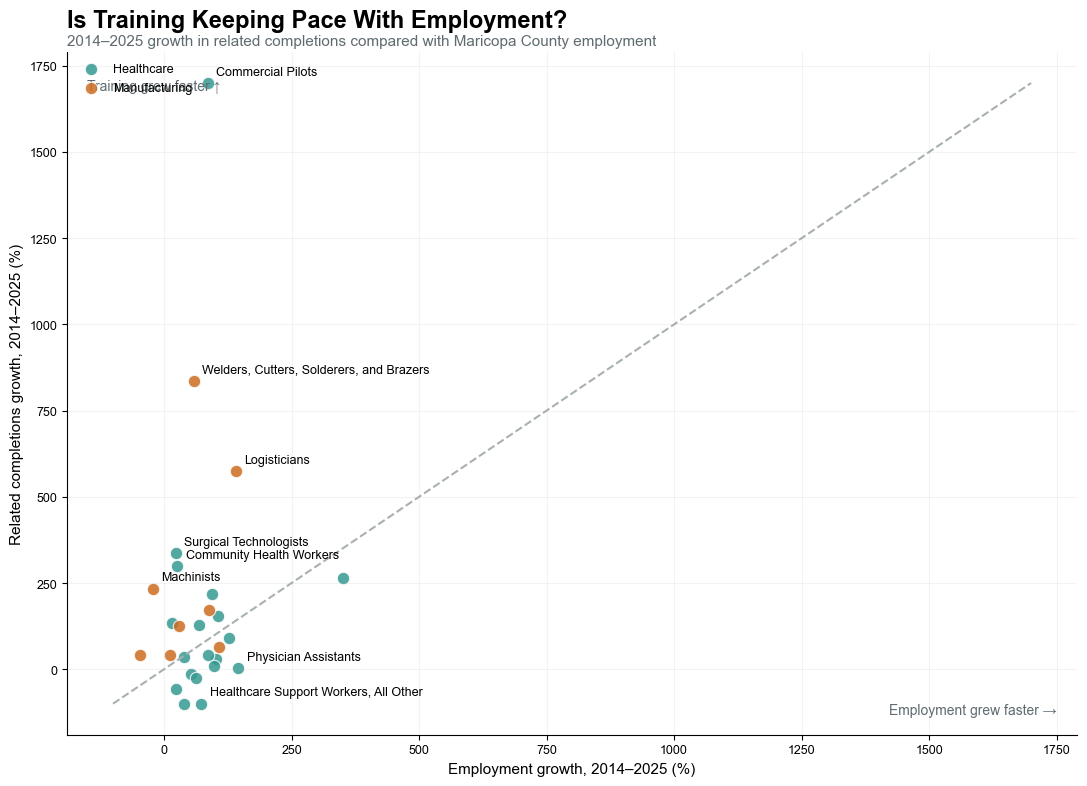

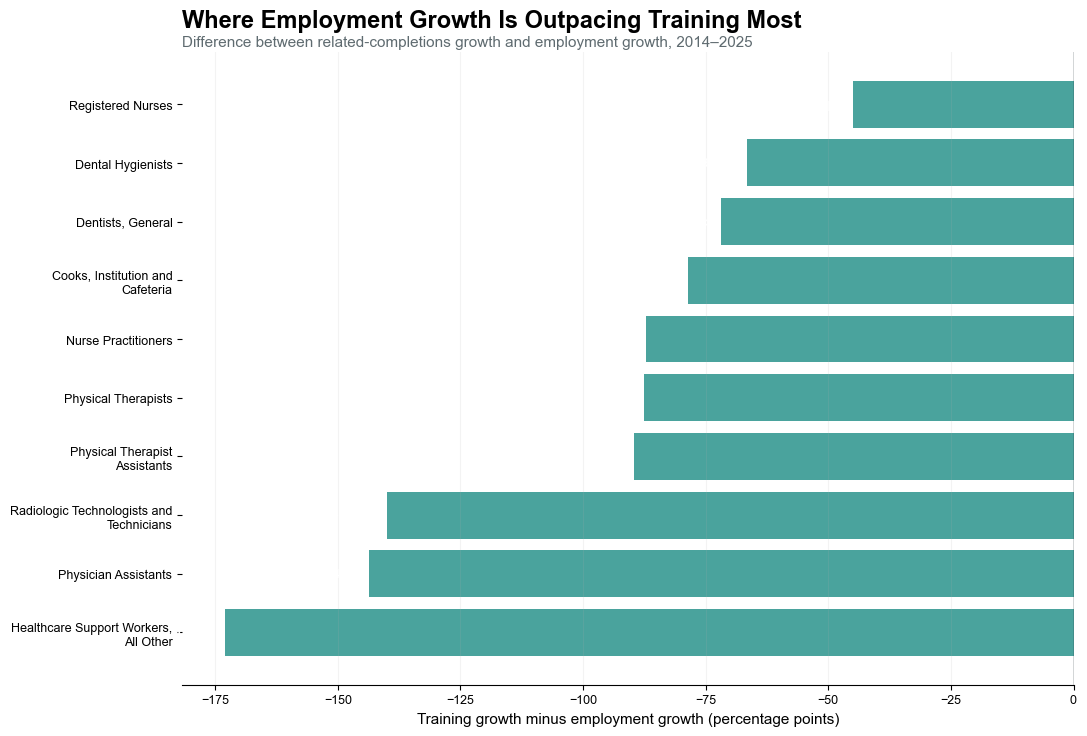

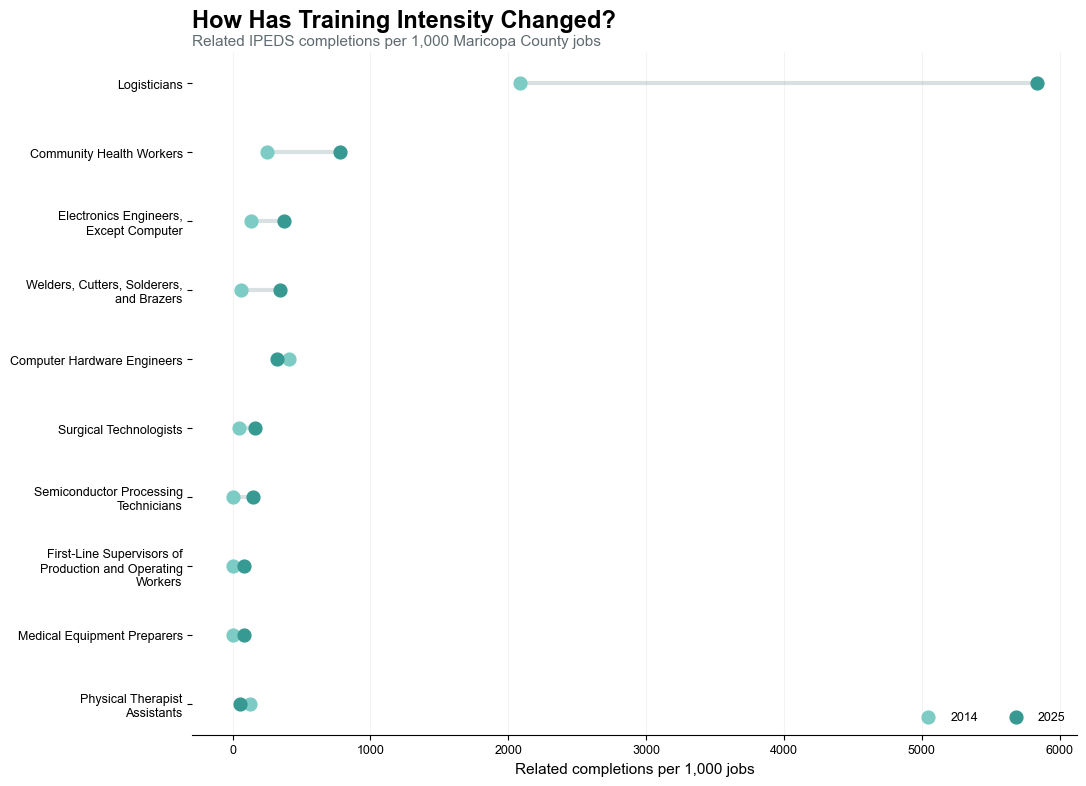

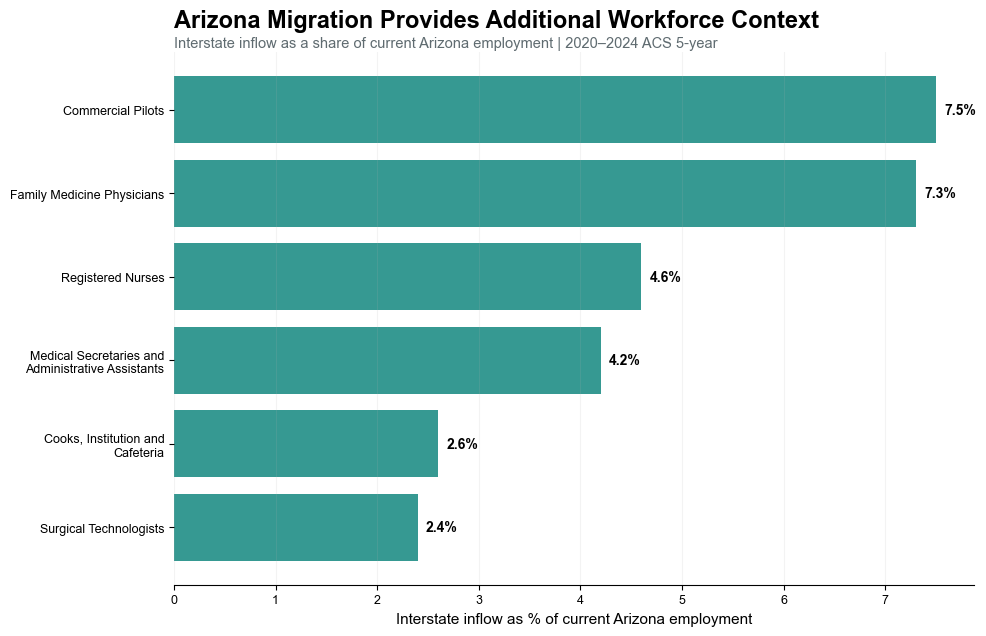


DONE — STANDALONE VISUALS CREATED

Saved in:
C:\Users\301533\Downloads\Visuals

1. 01_Training_vs_Employment_Growth.png
2. 02_Employment_Outpacing_Training.png
3. 03_Pipeline_Intensity_2014_2025.png
4. 04_Arizona_Migration_Context.png


In [55]:
# =====================================================================
# STANDALONE PRESENTATION VISUALS
# =====================================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import textwrap

# ---------------------------------------------------------------------
# OUTPUT FOLDER
# ---------------------------------------------------------------------

VISUAL_DIR = OUTPUT_DIR / "Visuals"
VISUAL_DIR.mkdir(parents=True, exist_ok=True)

# Project colors
TEAL = "#369992"
TEAL_LIGHT = "#7CCBC4"
ORANGE = "#CC6C20"
ORANGE_LIGHT = "#E79A64"
GRAY = "#A9B0B3"
DARK = "#263238"

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 11,
    "axes.titlesize": 17,
    "axes.titleweight": "bold",
    "axes.labelsize": 11
})


def wrap(text, width=28):
    return "\n".join(textwrap.wrap(str(text), width))


# =====================================================================
# VISUAL 1
# IS TRAINING KEEPING PACE WITH EMPLOYMENT?
# =====================================================================

plot_df = ferris_table[
    ferris_table["training_growth_pct_2014_2025"].notna()
    &
    ferris_table["employment_growth_pct_2014_2025"].notna()
].copy()


fig, ax = plt.subplots(figsize=(11, 8))


# Plot sectors separately
for sector, color in [
    ("Healthcare", TEAL),
    ("Manufacturing", ORANGE)
]:

    temp = plot_df[
        plot_df["sector"] == sector
    ]

    ax.scatter(
        temp["employment_growth_pct_2014_2025"],
        temp["training_growth_pct_2014_2025"],
        s=80,
        alpha=.85,
        label=sector,
        color=color,
        edgecolor="white",
        linewidth=.8
    )


# 45-degree reference line
all_values = pd.concat([
    plot_df["employment_growth_pct_2014_2025"],
    plot_df["training_growth_pct_2014_2025"]
])

low = min(all_values.min(), 0)
high = all_values.max()

ax.plot(
    [low, high],
    [low, high],
    linestyle="--",
    color=GRAY,
    linewidth=1.5
)


# Label only the strongest divergences
plot_df["gap_abs"] = (
    plot_df["training_growth_pct_2014_2025"]
    -
    plot_df["employment_growth_pct_2014_2025"]
).abs()

labels = plot_df.nlargest(
    8,
    "gap_abs"
)

for _, row in labels.iterrows():

    ax.annotate(
        row["job_title"],
        (
            row["employment_growth_pct_2014_2025"],
            row["training_growth_pct_2014_2025"]
        ),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=9
    )


ax.set_title(
    "Is Training Keeping Pace With Employment?",
    loc="left",
    pad=18
)

ax.text(
    0,
    1.01,
    "2014–2025 growth in related completions compared with Maricopa County employment",
    transform=ax.transAxes,
    fontsize=11,
    color="#5F6B70"
)

ax.set_xlabel("Employment growth, 2014–2025 (%)")
ax.set_ylabel("Related completions growth, 2014–2025 (%)")

ax.legend(
    frameon=False,
    loc="upper left"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="both",
    alpha=.15
)

# Helpful interpretation labels
ax.text(
    .98,
    .03,
    "Employment grew faster →",
    transform=ax.transAxes,
    ha="right",
    color="#5F6B70",
    fontsize=10
)

ax.text(
    .02,
    .96,
    "Training grew faster ↑",
    transform=ax.transAxes,
    va="top",
    color="#5F6B70",
    fontsize=10
)

fig.tight_layout()

file1 = VISUAL_DIR / "01_Training_vs_Employment_Growth.png"

fig.savefig(
    file1,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# =====================================================================
# VISUAL 2
# WHERE IS EMPLOYMENT OUTPACING TRAINING MOST?
# =====================================================================

pressure = ferris_table.copy()

pressure["growth_gap"] = (
    pressure["training_growth_pct_2014_2025"]
    -
    pressure["employment_growth_pct_2014_2025"]
)

# Negative = employment grew faster
pressure = (
    pressure[
        pressure["growth_gap"].notna()
    ]
    .nsmallest(
        10,
        "growth_gap"
    )
    .sort_values(
        "growth_gap",
        ascending=True
    )
)


fig, ax = plt.subplots(figsize=(11, 7.5))


colors = [
    TEAL if s == "Healthcare"
    else ORANGE
    for s in pressure["sector"]
]


ax.barh(
    range(len(pressure)),
    pressure["growth_gap"],
    color=colors,
    alpha=.9
)


ax.set_yticks(
    range(len(pressure))
)

ax.set_yticklabels(
    [
        wrap(x, 28)
        for x in pressure["job_title"]
    ]
)


ax.axvline(
    0,
    color=DARK,
    linewidth=1
)


for i, value in enumerate(
    pressure["growth_gap"]
):

    ax.text(
        value - 2,
        i,
        f"{value:.0f} pp",
        va="center",
        ha="right",
        color="white",
        fontweight="bold",
        fontsize=9
    )


ax.set_title(
    "Where Employment Growth Is Outpacing Training Most",
    loc="left",
    pad=18
)

ax.text(
    0,
    1.01,
    "Difference between related-completions growth and employment growth, 2014–2025",
    transform=ax.transAxes,
    fontsize=11,
    color="#5F6B70"
)

ax.set_xlabel(
    "Training growth minus employment growth (percentage points)"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.grid(
    axis="x",
    alpha=.15
)

fig.tight_layout()

file2 = VISUAL_DIR / "02_Employment_Outpacing_Training.png"

fig.savefig(
    file2,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# =====================================================================
# VISUAL 3
# PIPELINE INTENSITY: 2014 VS 2025
# =====================================================================

pipeline = ferris_table.copy()

pipeline["pipeline_change"] = (
    pipeline["related_completers_per_1000_jobs_2025"]
    -
    pipeline["related_completers_per_1000_jobs_2014"]
)

# Show the occupations with the largest absolute changes
pipeline = (
    pipeline[
        pipeline["pipeline_change"].notna()
    ]
    .assign(
        abs_change=lambda x:
        x["pipeline_change"].abs()
    )
    .nlargest(
        10,
        "abs_change"
    )
    .sort_values(
        "related_completers_per_1000_jobs_2025"
    )
)


fig, ax = plt.subplots(figsize=(11, 8))


y = np.arange(
    len(pipeline)
)


# Connecting line
for i, (_, row) in enumerate(
    pipeline.iterrows()
):

    ax.plot(
        [
            row["related_completers_per_1000_jobs_2014"],
            row["related_completers_per_1000_jobs_2025"]
        ],
        [i, i],
        color="#D9E0E2",
        linewidth=3,
        zorder=1
    )


ax.scatter(
    pipeline["related_completers_per_1000_jobs_2014"],
    y,
    s=85,
    color=TEAL_LIGHT,
    label="2014",
    zorder=2
)

ax.scatter(
    pipeline["related_completers_per_1000_jobs_2025"],
    y,
    s=85,
    color=TEAL,
    label="2025",
    zorder=3
)


ax.set_yticks(y)

ax.set_yticklabels(
    [
        wrap(x, 28)
        for x in pipeline["job_title"]
    ]
)


ax.set_title(
    "How Has Training Intensity Changed?",
    loc="left",
    pad=18
)

ax.text(
    0,
    1.01,
    "Related IPEDS completions per 1,000 Maricopa County jobs",
    transform=ax.transAxes,
    fontsize=11,
    color="#5F6B70"
)

ax.set_xlabel(
    "Related completions per 1,000 jobs"
)

ax.legend(
    frameon=False,
    ncol=2,
    loc="lower right"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.grid(
    axis="x",
    alpha=.15
)

fig.tight_layout()

file3 = VISUAL_DIR / "03_Pipeline_Intensity_2014_2025.png"

fig.savefig(
    file3,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# =====================================================================
# VISUAL 4
# ARIZONA MIGRATION CONTEXT
# =====================================================================

migration_viz = ferris_table.copy()

# Only stronger/moderate estimates
migration_viz = migration_viz[
    migration_viz["reliability"].isin(
        [
            "STRONGER",
            "MODERATE"
        ]
    )
    &
    migration_viz["inflow_pct_current_AZ"].notna()
].copy()


migration_viz = (
    migration_viz
    .sort_values(
        "inflow_pct_current_AZ",
        ascending=True
    )
)


fig, ax = plt.subplots(
    figsize=(10, 6.5)
)


colors = [
    TEAL if s == "Healthcare"
    else ORANGE
    for s in migration_viz["sector"]
]


ax.barh(
    range(len(migration_viz)),
    migration_viz["inflow_pct_current_AZ"],
    color=colors
)


ax.set_yticks(
    range(len(migration_viz))
)

ax.set_yticklabels(
    [
        wrap(x, 28)
        for x in migration_viz["job_title"]
    ]
)


for i, value in enumerate(
    migration_viz["inflow_pct_current_AZ"]
):

    ax.text(
        value + .08,
        i,
        f"{value:.1f}%",
        va="center",
        fontsize=10,
        fontweight="bold"
    )


ax.set_title(
    "Arizona Migration Provides Additional Workforce Context",
    loc="left",
    pad=18
)

ax.text(
    0,
    1.01,
    "Interstate inflow as a share of current Arizona employment | 2020–2024 ACS 5-year",
    transform=ax.transAxes,
    fontsize=10.5,
    color="#5F6B70"
)

ax.set_xlabel(
    "Interstate inflow as % of current Arizona employment"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.grid(
    axis="x",
    alpha=.15
)

fig.tight_layout()

file4 = VISUAL_DIR / "04_Arizona_Migration_Context.png"

fig.savefig(
    file4,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# =====================================================================
# DONE
# =====================================================================

print("\n" + "=" * 70)
print("DONE — STANDALONE VISUALS CREATED")
print("=" * 70)

print("\nSaved in:")
print(VISUAL_DIR)

print("\n1.", file1.name)
print("2.", file2.name)
print("3.", file3.name)
print("4.", file4.name)

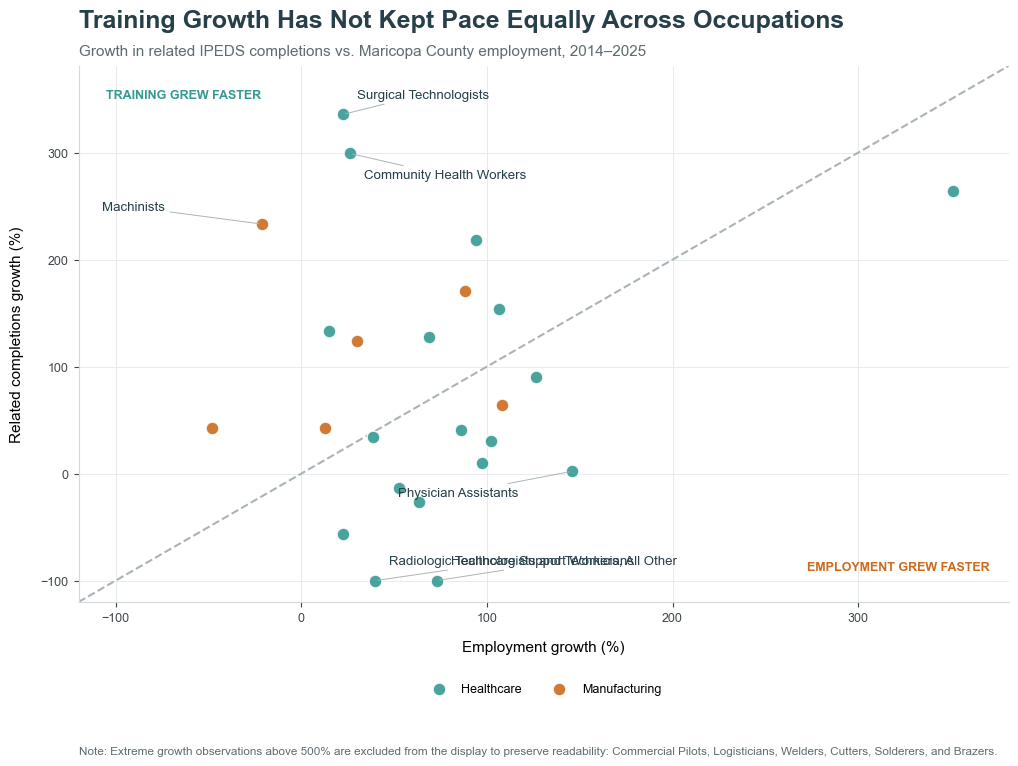

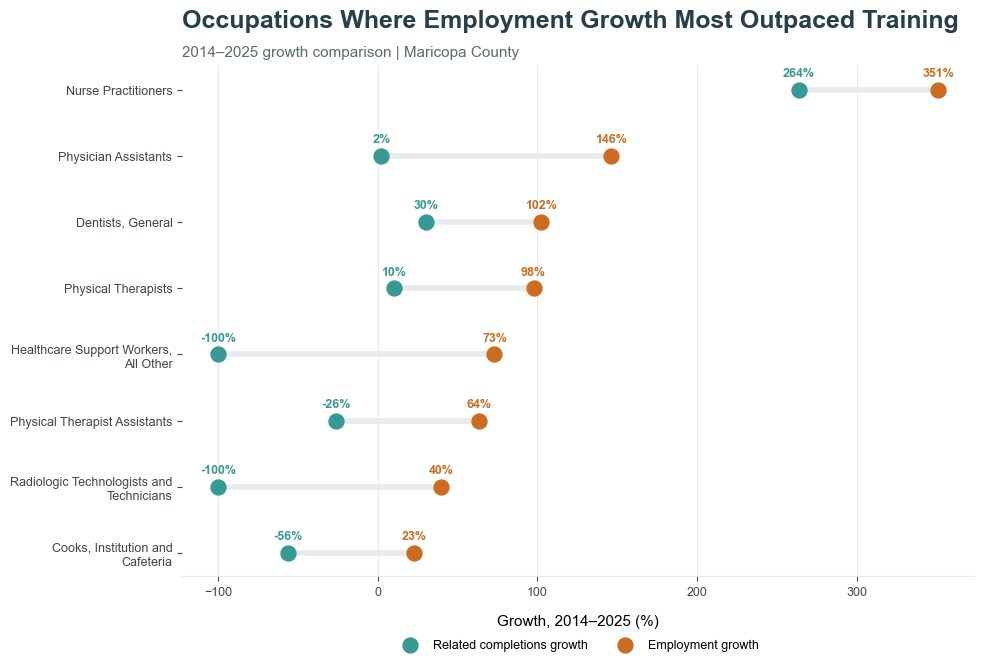

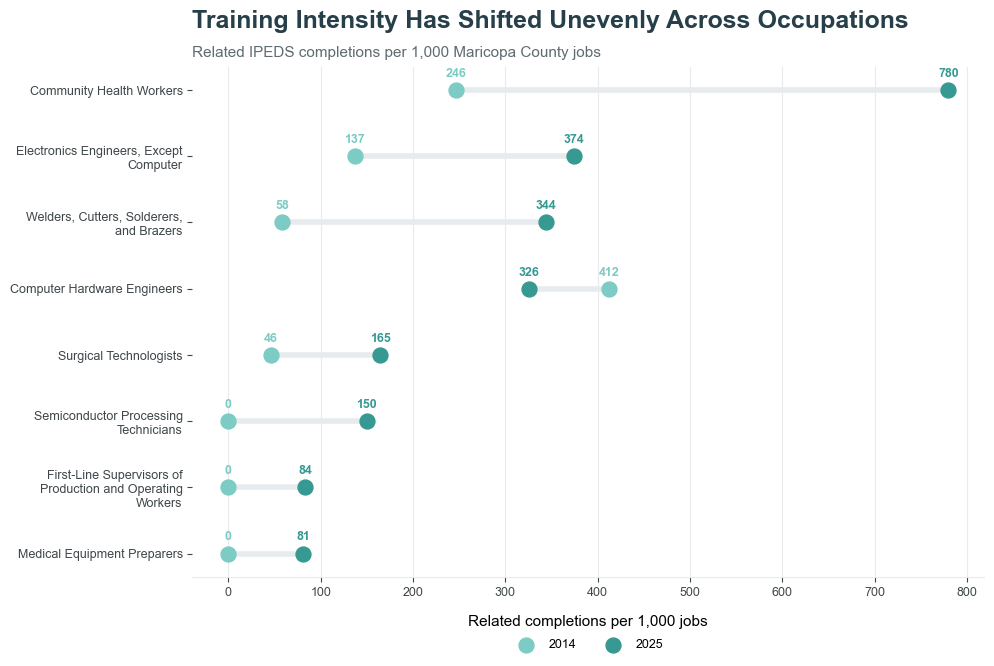

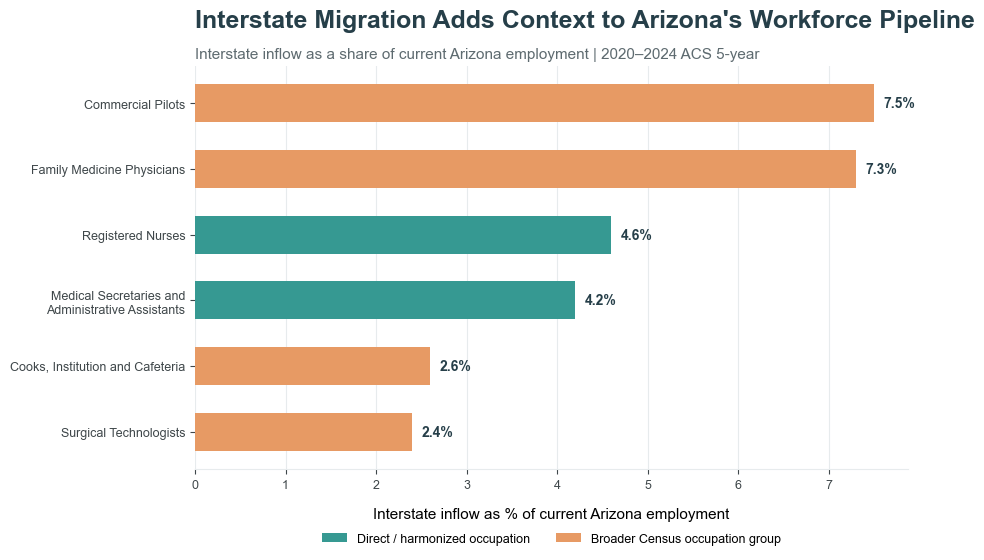


PROFESSIONAL VISUALS COMPLETE

Saved to:
C:\Users\301533\Downloads\Visuals_Professional

01 — Training vs Employment Growth
02 — Employment Outpacing Training
03 — Pipeline Intensity
04 — Arizona Migration Context


In [ ]:
# =====================================================================
# PROFESSIONAL STANDALONE FIGURES — REPLACEMENT VERSION
# =====================================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import textwrap
from adjustText import adjust_text

# =====================================================================
# SETTINGS
# =====================================================================

VISUAL_DIR = OUTPUT_DIR / "Visuals_Professional"
VISUAL_DIR.mkdir(parents=True, exist_ok=True)

# Project palette
TEAL = "#369992"
TEAL_LIGHT = "#7CCBC4"
TEAL_PALE = "#BFEAE5"

ORANGE = "#CC6C20"
ORANGE_LIGHT = "#E79A64"

NAVY = "#263F49"
GRAY = "#AAB4B8"
LIGHT_GRAY = "#E7EBED"
TEXT_GRAY = "#5E6B70"
WHITE = "#FFFFFF"


plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 11,
    "axes.titlesize": 18,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.edgecolor": "#D4DADC",
    "xtick.color": "#3F474A",
    "ytick.color": "#3F474A",
    "figure.facecolor": "white",
    "axes.facecolor": "white"
})


def wrap_label(text, width=26):
    return "\n".join(
        textwrap.wrap(
            str(text),
            width=width
        )
    )


def clean_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_color(LIGHT_GRAY)

    ax.grid(
        axis="x",
        color=LIGHT_GRAY,
        linewidth=.8
    )

    ax.set_axisbelow(True)


def save_chart(fig, filename):
    fig.savefig(
        VISUAL_DIR / filename,
        dpi=300,
        bbox_inches="tight",
        facecolor="white"
    )
    plt.show()


# =====================================================================
# FIGURE 1
# TRAINING VS EMPLOYMENT GROWTH
#
# IMPORTANT CHANGE:
# Exclude extreme >500% growth observations from the main figure.
# List them separately underneath instead of letting them destroy scale.
# =====================================================================

df = ferris_table.copy()

df = df[
    df["training_growth_pct_2014_2025"].notna()
    &
    df["employment_growth_pct_2014_2025"].notna()
].copy()


# Main readable range
main = df[
    (df["training_growth_pct_2014_2025"].abs() <= 500)
    &
    (df["employment_growth_pct_2014_2025"].abs() <= 500)
].copy()


# Extreme observations
outliers = df.drop(
    main.index
).copy()


fig, ax = plt.subplots(
    figsize=(12, 8)
)


# ---------------------------------------------------------------
# 45-degree reference line
# ---------------------------------------------------------------

minimum = min(
    main["training_growth_pct_2014_2025"].min(),
    main["employment_growth_pct_2014_2025"].min()
) - 25

maximum = max(
    main["training_growth_pct_2014_2025"].max(),
    main["employment_growth_pct_2014_2025"].max()
) + 35


ax.plot(
    [minimum, maximum],
    [minimum, maximum],
    color=GRAY,
    linewidth=1.5,
    linestyle="--",
    zorder=1
)


# ---------------------------------------------------------------
# Points
# ---------------------------------------------------------------

for sector, color in [
    ("Healthcare", TEAL),
    ("Manufacturing", ORANGE)
]:

    temp = main[
        main["sector"] == sector
    ]

    ax.scatter(
        temp["employment_growth_pct_2014_2025"],
        temp["training_growth_pct_2014_2025"],
        s=85,
        color=color,
        edgecolor=WHITE,
        linewidth=1,
        alpha=.9,
        label=sector,
        zorder=3
    )


# ---------------------------------------------------------------
# Label ONLY important divergences
# ---------------------------------------------------------------

main["difference"] = (
    main["training_growth_pct_2014_2025"]
    -
    main["employment_growth_pct_2014_2025"]
)

label_df = (
    main
    .assign(
        abs_difference=lambda x:
        x["difference"].abs()
    )
    .nlargest(
        6,
        "abs_difference"
    )
)


# Manually stagger labels
offsets = [
    (10, 12),
    (10, -18),
    (-115, 10),
    (10, 12),
    (-125, -18),
    (10, 12)
]


for (
    (_, row),
    offset
) in zip(
    label_df.iterrows(),
    offsets
):

    ax.annotate(
        row["job_title"],
        xy=(
            row["employment_growth_pct_2014_2025"],
            row["training_growth_pct_2014_2025"]
        ),
        xytext=offset,
        textcoords="offset points",
        fontsize=9.5,
        color=NAVY,
        arrowprops=dict(
            arrowstyle="-",
            color=GRAY,
            linewidth=.7
        ),
        zorder=5
    )


# ---------------------------------------------------------------
# Titles
# ---------------------------------------------------------------

ax.set_title(
    "Training Growth Has Not Kept Pace Equally Across Occupations",
    loc="left",
    pad=28,
    color=NAVY
)

ax.text(
    0,
    1.02,
    "Growth in related IPEDS completions vs. Maricopa County employment, 2014–2025",
    transform=ax.transAxes,
    fontsize=11,
    color=TEXT_GRAY
)


ax.set_xlabel(
    "Employment growth (%)",
    labelpad=12
)

ax.set_ylabel(
    "Related completions growth (%)",
    labelpad=12
)


# ---------------------------------------------------------------
# Interpretation areas
# ---------------------------------------------------------------

ax.text(
    .98,
    .06,
    "EMPLOYMENT GREW FASTER",
    transform=ax.transAxes,
    ha="right",
    fontsize=9,
    fontweight="bold",
    color=ORANGE
)

ax.text(
    .03,
    .94,
    "TRAINING GREW FASTER",
    transform=ax.transAxes,
    fontsize=9,
    fontweight="bold",
    color=TEAL
)


# ---------------------------------------------------------------
# Legend — outside plotting area
# ---------------------------------------------------------------

ax.legend(
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(.5, -0.13),
    ncol=2
)


ax.set_xlim(
    minimum,
    maximum
)

ax.set_ylim(
    minimum,
    maximum
)

ax.grid(
    color=LIGHT_GRAY,
    linewidth=.7
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


# ---------------------------------------------------------------
# Outlier footnote
# ---------------------------------------------------------------

if len(outliers) > 0:

    outlier_names = ", ".join(
        outliers["job_title"].tolist()
    )

    fig.text(
        .125,
        .01,
        "Note: Extreme growth observations above 500% are excluded "
        "from the display to preserve readability: "
        + outlier_names
        + ".",
        fontsize=8.5,
        color=TEXT_GRAY,
        wrap=True
    )


fig.subplots_adjust(
    bottom=.20,
    top=.87
)

save_chart(
    fig,
    "01_Training_vs_Employment_Growth.png"
)


# =====================================================================
# FIGURE 2
# TRAINING VS EMPLOYMENT — TOP ALIGNMENT PRESSURES
#
# REPLACEMENT for the ugly single-color negative bars.
#
# Teal = training growth
# Orange = employment growth
# =====================================================================

pressure = ferris_table.copy()

pressure["gap"] = (
    pressure["training_growth_pct_2014_2025"]
    -
    pressure["employment_growth_pct_2014_2025"]
)


pressure = (
    pressure[
        pressure["gap"].notna()
    ]
    .nsmallest(
        8,
        "gap"
    )
    .sort_values(
        "employment_growth_pct_2014_2025",
        ascending=True
    )
)


fig, ax = plt.subplots(
    figsize=(12, 7.5)
)


y = np.arange(
    len(pressure)
)


# Connecting lines
for i, (_, row) in enumerate(
    pressure.iterrows()
):

    ax.plot(
        [
            row["training_growth_pct_2014_2025"],
            row["employment_growth_pct_2014_2025"]
        ],
        [i, i],
        color=LIGHT_GRAY,
        linewidth=4,
        zorder=1
    )


# Training
ax.scatter(
    pressure["training_growth_pct_2014_2025"],
    y,
    s=115,
    color=TEAL,
    label="Related completions growth",
    zorder=3
)


# Employment
ax.scatter(
    pressure["employment_growth_pct_2014_2025"],
    y,
    s=115,
    color=ORANGE,
    label="Employment growth",
    zorder=4
)


# Value labels
for i, (_, row) in enumerate(
    pressure.iterrows()
):

    training = row[
        "training_growth_pct_2014_2025"
    ]

    employment = row[
        "employment_growth_pct_2014_2025"
    ]


    ax.text(
        training,
        i + .20,
        f"{training:.0f}%",
        ha="center",
        fontsize=9,
        color=TEAL,
        fontweight="bold"
    )


    ax.text(
        employment,
        i + .20,
        f"{employment:.0f}%",
        ha="center",
        fontsize=9,
        color=ORANGE,
        fontweight="bold"
    )


ax.set_yticks(y)

ax.set_yticklabels(
    [
        wrap_label(
            x,
            30
        )
        for x in pressure["job_title"]
    ]
)


ax.set_title(
    "Occupations Where Employment Growth Most Outpaced Training",
    loc="left",
    pad=28,
    color=NAVY
)

ax.text(
    0,
    1.02,
    "2014–2025 growth comparison | Maricopa County",
    transform=ax.transAxes,
    fontsize=11,
    color=TEXT_GRAY
)


ax.set_xlabel(
    "Growth, 2014–2025 (%)",
    labelpad=12
)


ax.legend(
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(.5, -0.10),
    ncol=2
)


clean_axes(ax)


fig.subplots_adjust(
    left=.30,
    right=.96,
    bottom=.18,
    top=.86
)


save_chart(
    fig,
    "02_Employment_Outpacing_Training.png"
)


# =====================================================================
# FIGURE 3
# PIPELINE INTENSITY
#
# Remove extreme Logisticians from main figure because it destroys
# the scale. Show 8 readable occupations instead.
# =====================================================================

pipeline = ferris_table.copy()

pipeline["change"] = (
    pipeline["related_completers_per_1000_jobs_2025"]
    -
    pipeline["related_completers_per_1000_jobs_2014"]
)


# Remove extreme ratios for readable presentation
readable_pipeline = pipeline[
    (
        pipeline[
            "related_completers_per_1000_jobs_2014"
        ] <= 1000
    )
    &
    (
        pipeline[
            "related_completers_per_1000_jobs_2025"
        ] <= 1000
    )
].copy()


readable_pipeline["abs_change"] = (
    readable_pipeline["change"].abs()
)


readable_pipeline = (
    readable_pipeline
    .nlargest(
        8,
        "abs_change"
    )
    .sort_values(
        "related_completers_per_1000_jobs_2025"
    )
)


fig, ax = plt.subplots(
    figsize=(12, 7.5)
)


y = np.arange(
    len(readable_pipeline)
)


# Lines
for i, (_, row) in enumerate(
    readable_pipeline.iterrows()
):

    ax.plot(
        [
            row[
                "related_completers_per_1000_jobs_2014"
            ],
            row[
                "related_completers_per_1000_jobs_2025"
            ]
        ],
        [i, i],
        color=LIGHT_GRAY,
        linewidth=4,
        zorder=1
    )


# 2014 = light teal
ax.scatter(
    readable_pipeline[
        "related_completers_per_1000_jobs_2014"
    ],
    y,
    s=115,
    color=TEAL_LIGHT,
    label="2014",
    zorder=3
)


# 2025 = dark teal
ax.scatter(
    readable_pipeline[
        "related_completers_per_1000_jobs_2025"
    ],
    y,
    s=115,
    color=TEAL,
    label="2025",
    zorder=4
)


# Direct values
for i, (_, row) in enumerate(
    readable_pipeline.iterrows()
):

    old = row[
        "related_completers_per_1000_jobs_2014"
    ]

    new = row[
        "related_completers_per_1000_jobs_2025"
    ]


    ax.text(
        old,
        i + .20,
        f"{old:.0f}",
        ha="center",
        fontsize=9,
        color=TEAL_LIGHT,
        fontweight="bold"
    )


    ax.text(
        new,
        i + .20,
        f"{new:.0f}",
        ha="center",
        fontsize=9,
        color=TEAL,
        fontweight="bold"
    )


ax.set_yticks(y)

ax.set_yticklabels(
    [
        wrap_label(
            x,
            30
        )
        for x in readable_pipeline[
            "job_title"
        ]
    ]
)


ax.set_title(
    "Training Intensity Has Shifted Unevenly Across Occupations",
    loc="left",
    pad=28,
    color=NAVY
)

ax.text(
    0,
    1.02,
    "Related IPEDS completions per 1,000 Maricopa County jobs",
    transform=ax.transAxes,
    fontsize=11,
    color=TEXT_GRAY
)


ax.set_xlabel(
    "Related completions per 1,000 jobs",
    labelpad=12
)


ax.legend(
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(.5, -0.10),
    ncol=2
)


clean_axes(ax)


fig.subplots_adjust(
    left=.30,
    right=.96,
    bottom=.18,
    top=.86
)


save_chart(
    fig,
    "03_Pipeline_Intensity.png"
)


# =====================================================================
# FIGURE 4
# MIGRATION CONTEXT
#
# Direct ACS = dark teal
# Broader ACS group = orange
#
# This color now communicates DATA QUALITY / SPECIFICITY.
# =====================================================================

migration = ferris_table.copy()


migration = migration[
    migration["reliability"].isin(
        [
            "STRONGER",
            "MODERATE"
        ]
    )
    &
    migration["inflow_pct_current_AZ"].notna()
].copy()


migration = migration.sort_values(
    "inflow_pct_current_AZ",
    ascending=True
)


fig, ax = plt.subplots(
    figsize=(11.5, 6.5)
)


colors = []

for _, row in migration.iterrows():

    match_type = str(
        row["acs_match_type"]
    ).upper()

    if "BROADER" in match_type:

        colors.append(
            ORANGE_LIGHT
        )

    else:

        colors.append(
            TEAL
        )


bars = ax.barh(
    np.arange(
        len(migration)
    ),
    migration[
        "inflow_pct_current_AZ"
    ],
    color=colors,
    height=.58
)


ax.set_yticks(
    np.arange(
        len(migration)
    )
)

ax.set_yticklabels(
    [
        wrap_label(
            x,
            32
        )
        for x in migration["job_title"]
    ]
)


# Values
for bar, value in zip(
    bars,
    migration[
        "inflow_pct_current_AZ"
    ]
):

    ax.text(
        value + .10,
        bar.get_y()
        +
        bar.get_height() / 2,
        f"{value:.1f}%",
        va="center",
        fontsize=10,
        fontweight="bold",
        color=NAVY
    )


ax.set_title(
    "Interstate Migration Adds Context to Arizona's Workforce Pipeline",
    loc="left",
    pad=28,
    color=NAVY
)

ax.text(
    0,
    1.02,
    "Interstate inflow as a share of current Arizona employment | 2020–2024 ACS 5-year",
    transform=ax.transAxes,
    fontsize=11,
    color=TEXT_GRAY
)


ax.set_xlabel(
    "Interstate inflow as % of current Arizona employment",
    labelpad=12
)


# Custom legend
from matplotlib.patches import Patch

legend_elements = [

    Patch(
        facecolor=TEAL,
        label="Direct / harmonized occupation"
    ),

    Patch(
        facecolor=ORANGE_LIGHT,
        label="Broader Census occupation group"
    )
]


ax.legend(
    handles=legend_elements,
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(.5, -0.13),
    ncol=2
)


clean_axes(ax)


fig.subplots_adjust(
    left=.31,
    right=.93,
    bottom=.22,
    top=.84
)


save_chart(
    fig,
    "04_Arizona_Migration_Context.png"
)


# =====================================================================
# DONE
# =====================================================================

print("\n" + "=" * 70)
print("PROFESSIONAL VISUALS COMPLETE")
print("=" * 70)

print("\nSaved to:")
print(VISUAL_DIR)

print("\n01 — Training vs Employment Growth")
print("02 — Employment Outpacing Training")
print("03 — Pipeline Intensity")
print("04 — Arizona Migration Context")

In [58]:
!pip install adjustText


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Figure 1: 24 occupation dots displayed; 24 occupations labeled; 0 dots intentionally unlabeled.


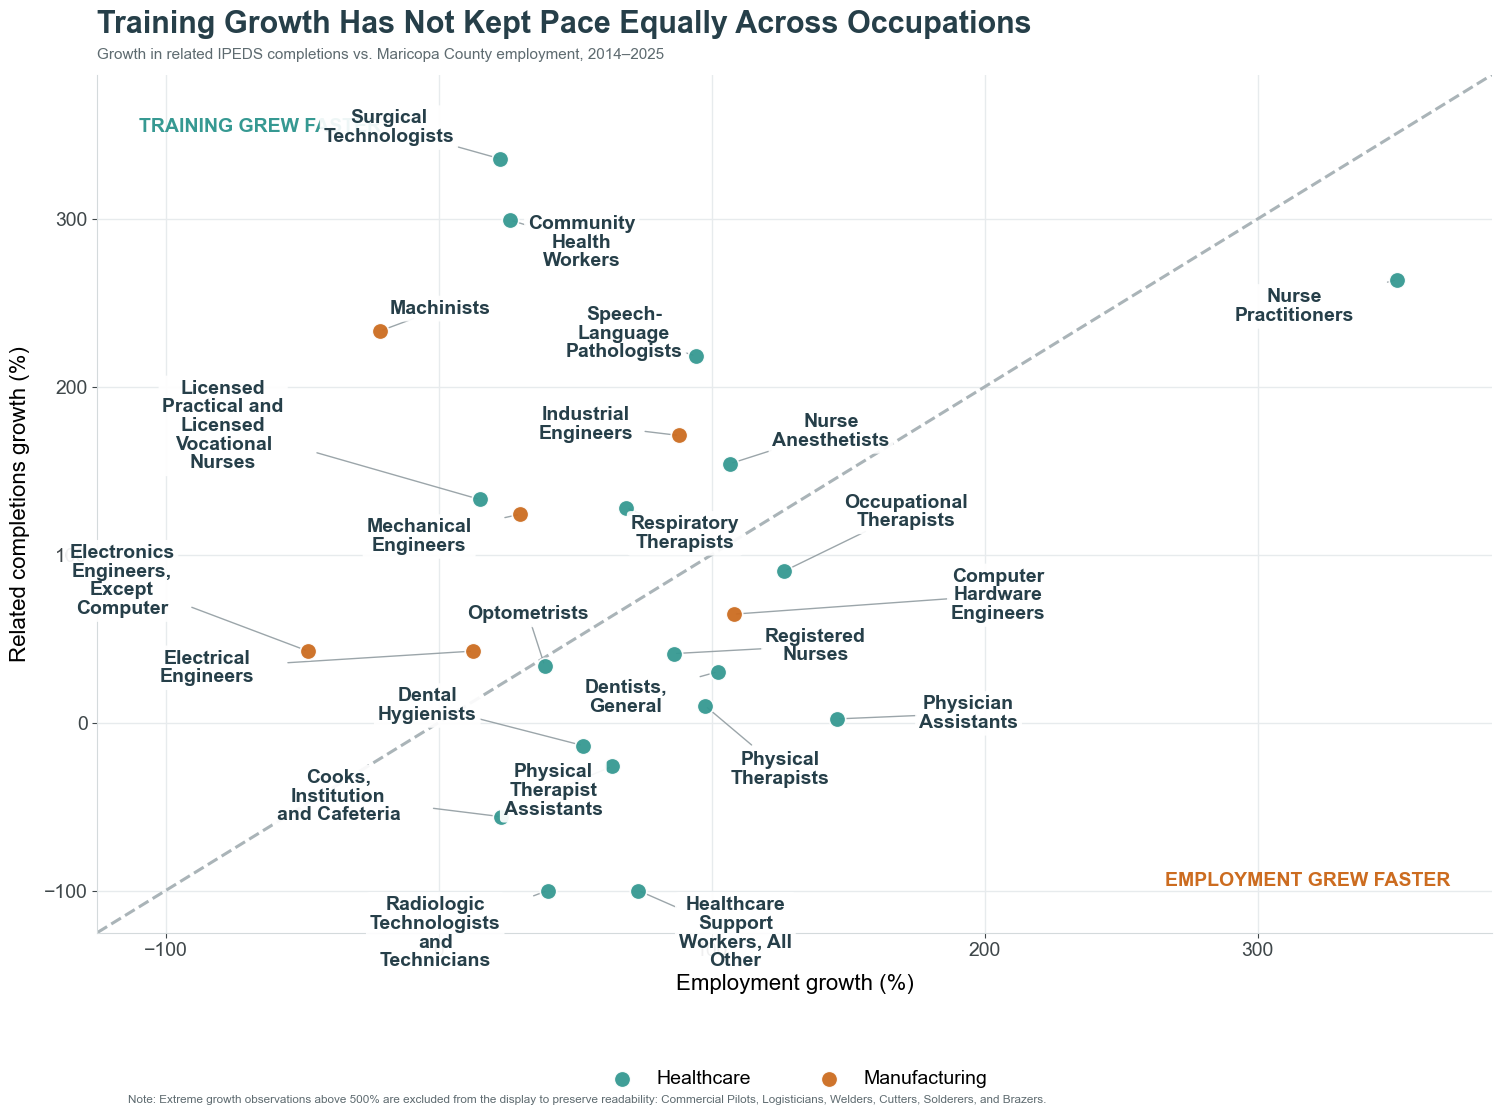

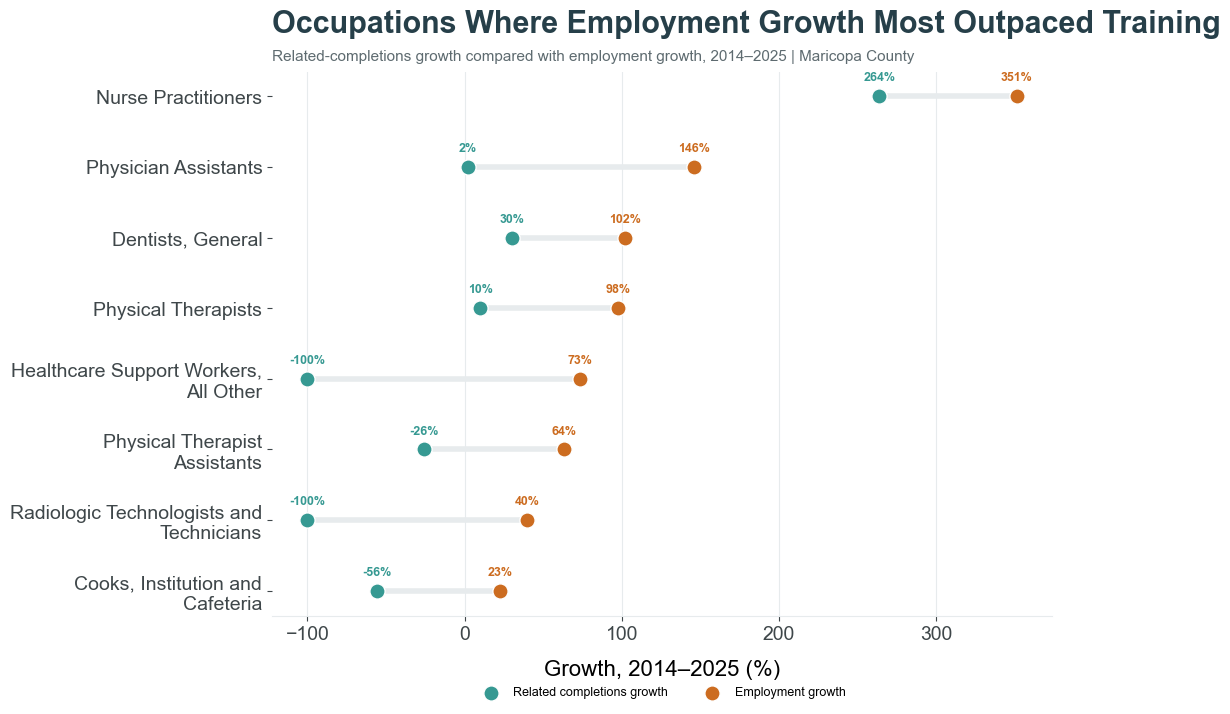

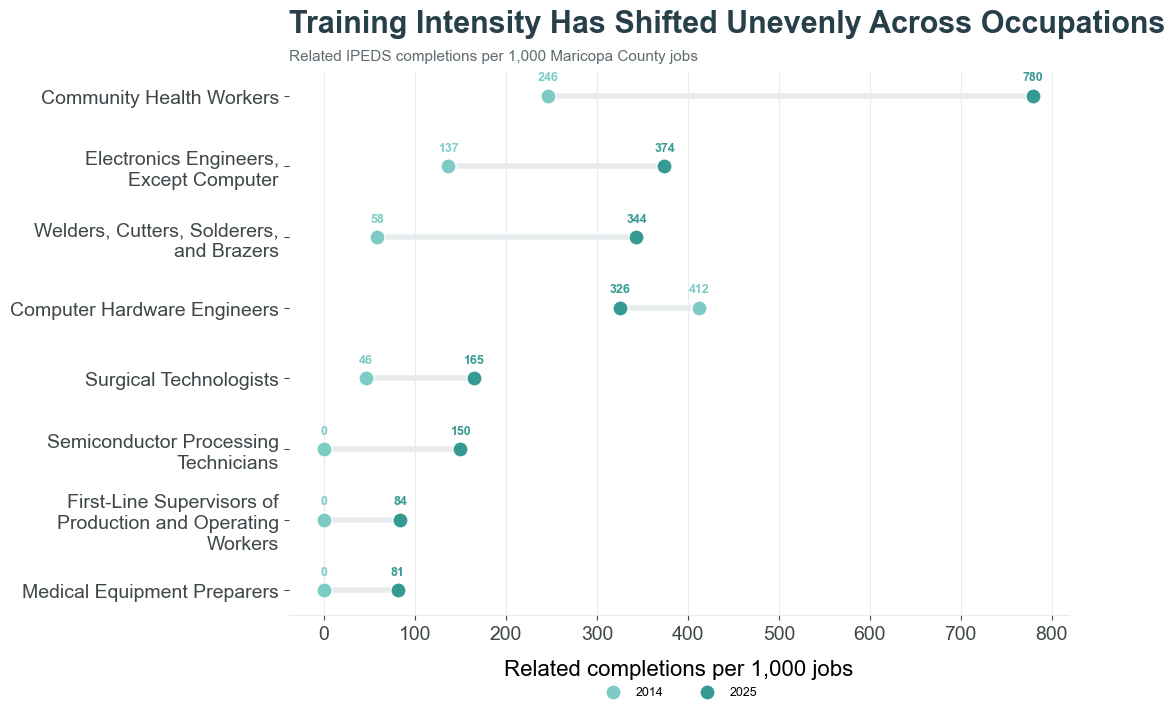

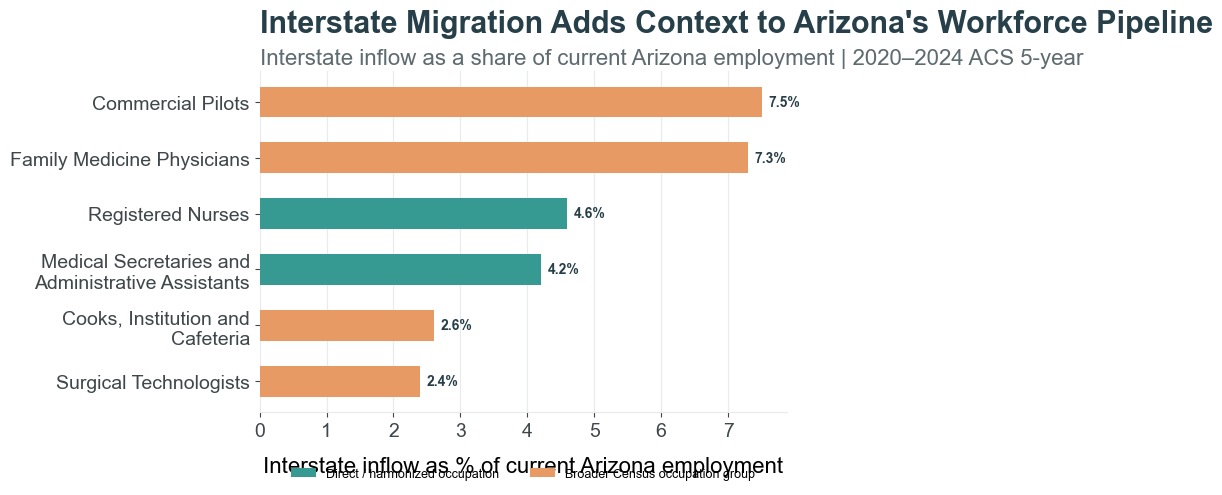


PROFESSIONAL VISUALS COMPLETE

Saved to:
C:\Users\301533\Downloads\Visuals_Professional

Created:
01 — Training vs Employment Growth
02 — Employment Outpacing Training
03 — Pipeline Intensity
04 — Arizona Migration Context


In [71]:
# =====================================================================
# PROFESSIONAL STANDALONE FIGURES — FINAL CLEAN VERSION
# =====================================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import textwrap

# If this import fails, run once:
# %pip install adjustText
from adjustText import adjust_text

# =====================================================================
# SETTINGS
# =====================================================================

VISUAL_DIR = OUTPUT_DIR / "Visuals_Professional"
VISUAL_DIR.mkdir(parents=True, exist_ok=True)

# Project palette
TEAL = "#369992"
TEAL_LIGHT = "#7CCBC4"
TEAL_PALE = "#BFEAE5"

ORANGE = "#CC6C20"
ORANGE_LIGHT = "#E79A64"

NAVY = "#263F49"
GRAY = "#AAB4B8"
LIGHT_GRAY = "#E7EBED"
TEXT_GRAY = "#5E6B70"
WHITE = "#FFFFFF"

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 14,               # Base font size
    "axes.labelsize": 16,          # Axis labels
    "xtick.labelsize": 14,         # Axis numbers
    "ytick.labelsize": 14,         # Axis numbers
    "axes.edgecolor": "#D4DADC",
    "xtick.color": "#3F474A",
    "ytick.color": "#3F474A",
    "figure.facecolor": "white",
    "axes.facecolor": "white"
})


# =====================================================================
# HELPERS
# =====================================================================

def wrap_label(text, width=26):
    return "\n".join(
        textwrap.wrap(
            str(text),
            width=width
        )
    )


def clean_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_color(LIGHT_GRAY)

    ax.grid(
        axis="x",
        color=LIGHT_GRAY,
        linewidth=.8
    )

    ax.set_axisbelow(True)


def save_chart(fig, filename):
    fig.savefig(
        VISUAL_DIR / filename,
        dpi=300,
        bbox_inches="tight",
        facecolor="white"
    )
    plt.show()


# =====================================================================
# FIGURE 1
# TRAINING VS EMPLOYMENT GROWTH
#
# KEY FIX:
# Labels are automatically repositioned to avoid overlap.
# =====================================================================

df = ferris_table.copy()

df = df[
    df["training_growth_pct_2014_2025"].notna()
    &
    df["employment_growth_pct_2014_2025"].notna()
].copy()


# ---------------------------------------------------------------------
# Keep extreme observations out of main plot so they do not destroy scale
# ---------------------------------------------------------------------

main = df[
    (df["training_growth_pct_2014_2025"].abs() <= 500)
    &
    (df["employment_growth_pct_2014_2025"].abs() <= 500)
].copy()

outliers = df.drop(
    main.index
).copy()


# ---------------------------------------------------------------------
# Figure
# ---------------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(15.5, 11)
)


# ---------------------------------------------------------------------
# Determine plot limits
# ---------------------------------------------------------------------

minimum = min(
    main["training_growth_pct_2014_2025"].min(),
    main["employment_growth_pct_2014_2025"].min()
) - 25

maximum = max(
    main["training_growth_pct_2014_2025"].max(),
    main["employment_growth_pct_2014_2025"].max()
) + 35


# ---------------------------------------------------------------------
# 45-degree line = equal growth
# ---------------------------------------------------------------------

ax.plot(
    [minimum, maximum],
    [minimum, maximum],
    color=GRAY,
    linewidth=2.2,
    linestyle="--",
    zorder=1
)


# ---------------------------------------------------------------------
# Points
# Healthcare = teal
# Manufacturing = orange
# ---------------------------------------------------------------------

for sector, color in [
    ("Healthcare", TEAL),
    ("Manufacturing", ORANGE)
]:
    temp = main[main["sector"] == sector]
    ax.scatter(
        temp["employment_growth_pct_2014_2025"],
        temp["training_growth_pct_2014_2025"],
        s=140,                     # Solid, visible dots
        color=color,
        edgecolor=WHITE,
        linewidth=1.2,
        alpha=.95,
        label=sector,
        zorder=3
    )


# =====================================================================
# LABELS
# =====================================================================
#
# Label the most informative observations rather than putting 30+
# occupation names directly on one scatterplot.
#
# We include:
#   1. Largest absolute divergences
#   2. Registered Nurses as a key occupation
#
# adjustText then automatically separates the labels.
# =====================================================================

# =====================================================================
# LABELS — LABEL MOST OCCUPATIONS
# =====================================================================

main["difference"] = (
    main["training_growth_pct_2014_2025"]
    -
    main["employment_growth_pct_2014_2025"]
)

main["abs_difference"] = main["difference"].abs()


# ---------------------------------------------------------------------
# LABEL MOST OCCUPATIONS
#
# Instead of limiting to 10, label up to 28 occupations.
# Priority goes to:
#   1. Biggest training/employment divergences
#   2. Then remaining occupations
#
# This keeps almost the entire chart identified without forcing
# every single dot to have text.
# ---------------------------------------------------------------------

label_df = (
    main
    .sort_values(
        "abs_difference",
        ascending=False
    )
    .head(28)
    .copy()
)


print(
    f"Figure 1: {len(main)} occupation dots displayed; "
    f"{len(label_df)} occupations labeled; "
    f"{len(main) - len(label_df)} dots intentionally unlabeled."
)


# =====================================================================
# CREATE LABELS
# =====================================================================

texts = []

for _, row in label_df.iterrows():
    x = row["employment_growth_pct_2014_2025"]
    y = row["training_growth_pct_2014_2025"]

    txt = ax.text(
        x,
        y,
        wrap_label(row["job_title"], width=13),
        fontsize=14,               # Scaled uniformly with axes
        fontweight="bold",
        color=NAVY,
        ha="center",
        va="center",
        linespacing=1.05,
        zorder=5,
        bbox=dict(
            boxstyle="round,pad=0.2",
            facecolor=WHITE,
            edgecolor="none",
            alpha=.92
        )
    )
    texts.append(txt)


# =====================================================================
# AUTOMATIC LABEL POSITIONING
# =====================================================================

adjust_text(
    texts,
    x=main["employment_growth_pct_2014_2025"].to_numpy(),
    y=main["training_growth_pct_2014_2025"].to_numpy(),
    ax=ax,
    only_move={"text": "xy", "static": "xy", "explode": "xy", "pull": "xy"},
    force_text=(2.0, 2.5),
    force_static=(1.2, 1.5),
    force_explode=(1.6, 2.0),
    force_pull=(0.005, 0.005),
    expand=(1.35, 1.55),
    ensure_inside_axes=True,
    arrowprops=dict(
        arrowstyle="-",
        color="#8A969B",
        linewidth=1.0,
        alpha=.85
    ),
    iter_lim=5000
)

# =====================================================================
# TITLE / SUBTITLE
# =====================================================================

ax.set_title(
    "Training Growth Has Not Kept Pace Equally Across Occupations",
    loc="left",
    pad=30,
    color=NAVY
)

ax.text(
    0,
    1.018,
    "Growth in related IPEDS completions vs. Maricopa County employment, 2014–2025",
    transform=ax.transAxes,
    fontsize=11,
    color=TEXT_GRAY
)


# =====================================================================
# AXES
# =====================================================================

ax.set_xlabel("Employment growth (%)", labelpad=10, fontsize=16)
ax.set_ylabel("Related completions growth (%)", labelpad=10, fontsize=16)

ax.set_xlim(minimum, maximum)
ax.set_ylim(minimum, maximum)

# =====================================================================
# INTERPRETATION LABELS
# =====================================================================

ax.text(
    .03,
    .95,
    "TRAINING GREW FASTER",
    transform=ax.transAxes,
    fontsize=14,
    fontweight="bold",
    color=TEAL,
    va="top"
)

ax.text(
    .97, .05,
    "EMPLOYMENT GREW FASTER",
    transform=ax.transAxes,
    fontsize=14,
    fontweight="bold",
    color=ORANGE,
    ha="right",
    va="bottom"
)


# =====================================================================
# GRID / SPINES
# =====================================================================
ax.grid(color=LIGHT_GRAY, linewidth=1.0)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#D4DADC")
ax.spines["bottom"].set_color("#D4DADC")

# Legend (Uniform 14pt)
ax.legend(
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(.5, -0.14),
    ncol=2,
    columnspacing=3.0,
    fontsize=14,
    handletextpad=.8
)


# =====================================================================
# OUTLIER NOTE
# =====================================================================

if len(outliers) > 0:

    outlier_names = ", ".join(
        outliers["job_title"]
        .astype(str)
        .tolist()
    )

    fig.text(
        .10,
        .025,
        "Note: Extreme growth observations above 500% are excluded "
        "from the display to preserve readability: "
        + outlier_names
        + ".",
        fontsize=8.5,
        color=TEXT_GRAY,
        wrap=True
    )


# TIGHT MARGINS TO REMOVE WHITE SPACE
fig.subplots_adjust(left=.08, right=.98, top=.96, bottom=.18)

save_chart(
    fig,
    "01_Training_vs_Employment_Growth.png"
)


# =====================================================================
# FIGURE 2
# OCCUPATIONS WHERE EMPLOYMENT GROWTH MOST OUTPACED TRAINING
#
# Teal = related completions
# Orange = employment
# =====================================================================

pressure = ferris_table.copy()

pressure["gap"] = (
    pressure["training_growth_pct_2014_2025"]
    -
    pressure["employment_growth_pct_2014_2025"]
)


pressure = (
    pressure[
        pressure["gap"].notna()
    ]
    .nsmallest(
        8,
        "gap"
    )
    .sort_values(
        "employment_growth_pct_2014_2025",
        ascending=True
    )
)


fig, ax = plt.subplots(
    figsize=(12, 8)
)


y = np.arange(
    len(pressure)
)


# ---------------------------------------------------------------------
# Connecting lines
# ---------------------------------------------------------------------

for i, (_, row) in enumerate(
    pressure.iterrows()
):

    ax.plot(
        [
            row["training_growth_pct_2014_2025"],
            row["employment_growth_pct_2014_2025"]
        ],
        [i, i],
        color=LIGHT_GRAY,
        linewidth=4,
        zorder=1
    )


# ---------------------------------------------------------------------
# Training
# ---------------------------------------------------------------------

ax.scatter(
    pressure["training_growth_pct_2014_2025"],
    y,
    s=120,
    color=TEAL,
    edgecolor=WHITE,
    linewidth=1,
    label="Related completions growth",
    zorder=3
)


# ---------------------------------------------------------------------
# Employment
# ---------------------------------------------------------------------

ax.scatter(
    pressure["employment_growth_pct_2014_2025"],
    y,
    s=120,
    color=ORANGE,
    edgecolor=WHITE,
    linewidth=1,
    label="Employment growth",
    zorder=4
)


# ---------------------------------------------------------------------
# Values
# ---------------------------------------------------------------------

for i, (_, row) in enumerate(
    pressure.iterrows()
):

    training = row[
        "training_growth_pct_2014_2025"
    ]

    employment = row[
        "employment_growth_pct_2014_2025"
    ]


    ax.annotate(
        f"{training:.0f}%",
        (training, i),
        xytext=(0, 11),
        textcoords="offset points",
        ha="center",
        fontsize=9,
        color=TEAL,
        fontweight="bold"
    )


    ax.annotate(
        f"{employment:.0f}%",
        (employment, i),
        xytext=(0, 11),
        textcoords="offset points",
        ha="center",
        fontsize=9,
        color=ORANGE,
        fontweight="bold"
    )


# ---------------------------------------------------------------------
# Occupation names
# ---------------------------------------------------------------------

ax.set_yticks(y)

ax.set_yticklabels(
    [
        wrap_label(
            x,
            28
        )
        for x in pressure["job_title"]
    ]
)


# ---------------------------------------------------------------------
# Title
# ---------------------------------------------------------------------

ax.set_title(
    "Occupations Where Employment Growth Most Outpaced Training",
    loc="left",
    pad=28,
    color=NAVY
)

ax.text(
    0,
    1.02,
    "Related-completions growth compared with employment growth, 2014–2025 | Maricopa County",
    transform=ax.transAxes,
    fontsize=11,
    color=TEXT_GRAY
)


ax.set_xlabel(
    "Growth, 2014–2025 (%)",
    labelpad=12
)


# ---------------------------------------------------------------------
# Legend
# ---------------------------------------------------------------------

ax.legend(
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(.5, -0.11),
    ncol=2,
    columnspacing=2.5
)


clean_axes(ax)


fig.subplots_adjust(
    left=.31,
    right=.96,
    bottom=.18,
    top=.86
)


save_chart(
    fig,
    "02_Employment_Outpacing_Training.png"
)


# =====================================================================
# FIGURE 3
# TRAINING INTENSITY
# =====================================================================

pipeline = ferris_table.copy()

pipeline["change"] = (
    pipeline["related_completers_per_1000_jobs_2025"]
    -
    pipeline["related_completers_per_1000_jobs_2014"]
)


# ---------------------------------------------------------------------
# Remove extreme values from presentation chart
# ---------------------------------------------------------------------

readable_pipeline = pipeline[
    (
        pipeline[
            "related_completers_per_1000_jobs_2014"
        ] <= 1000
    )
    &
    (
        pipeline[
            "related_completers_per_1000_jobs_2025"
        ] <= 1000
    )
].copy()


readable_pipeline["abs_change"] = (
    readable_pipeline["change"].abs()
)


readable_pipeline = (
    readable_pipeline
    .nlargest(
        8,
        "abs_change"
    )
    .sort_values(
        "related_completers_per_1000_jobs_2025"
    )
)


fig, ax = plt.subplots(
    figsize=(12, 8)
)


y = np.arange(
    len(readable_pipeline)
)


# ---------------------------------------------------------------------
# Connecting lines
# ---------------------------------------------------------------------

for i, (_, row) in enumerate(
    readable_pipeline.iterrows()
):

    ax.plot(
        [
            row[
                "related_completers_per_1000_jobs_2014"
            ],
            row[
                "related_completers_per_1000_jobs_2025"
            ]
        ],
        [i, i],
        color=LIGHT_GRAY,
        linewidth=4,
        zorder=1
    )


# ---------------------------------------------------------------------
# 2014
# ---------------------------------------------------------------------

ax.scatter(
    readable_pipeline[
        "related_completers_per_1000_jobs_2014"
    ],
    y,
    s=120,
    color=TEAL_LIGHT,
    edgecolor=WHITE,
    linewidth=1,
    label="2014",
    zorder=3
)


# ---------------------------------------------------------------------
# 2025
# ---------------------------------------------------------------------

ax.scatter(
    readable_pipeline[
        "related_completers_per_1000_jobs_2025"
    ],
    y,
    s=120,
    color=TEAL,
    edgecolor=WHITE,
    linewidth=1,
    label="2025",
    zorder=4
)


# ---------------------------------------------------------------------
# Values
# ---------------------------------------------------------------------

for i, (_, row) in enumerate(
    readable_pipeline.iterrows()
):

    old = row[
        "related_completers_per_1000_jobs_2014"
    ]

    new = row[
        "related_completers_per_1000_jobs_2025"
    ]


    ax.annotate(
        f"{old:.0f}",
        (old, i),
        xytext=(0, 11),
        textcoords="offset points",
        ha="center",
        fontsize=9,
        color=TEAL_LIGHT,
        fontweight="bold"
    )


    ax.annotate(
        f"{new:.0f}",
        (new, i),
        xytext=(0, 11),
        textcoords="offset points",
        ha="center",
        fontsize=9,
        color=TEAL,
        fontweight="bold"
    )


# ---------------------------------------------------------------------
# Occupations
# ---------------------------------------------------------------------

ax.set_yticks(y)

ax.set_yticklabels(
    [
        wrap_label(
            x,
            28
        )
        for x in readable_pipeline[
            "job_title"
        ]
    ]
)


ax.set_title(
    "Training Intensity Has Shifted Unevenly Across Occupations",
    loc="left",
    pad=28,
    color=NAVY
)

ax.text(
    0,
    1.02,
    "Related IPEDS completions per 1,000 Maricopa County jobs",
    transform=ax.transAxes,
    fontsize=11,
    color=TEXT_GRAY
)


ax.set_xlabel(
    "Related completions per 1,000 jobs",
    labelpad=12
)


ax.legend(
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(.5, -0.11),
    ncol=2,
    columnspacing=2.5
)


clean_axes(ax)


fig.subplots_adjust(
    left=.31,
    right=.96,
    bottom=.18,
    top=.86
)


save_chart(
    fig,
    "03_Pipeline_Intensity.png"
)


# =====================================================================
# FIGURE 4
# ARIZONA MIGRATION CONTEXT
#
# Teal = direct/harmonized ACS occupation
# Orange = broader ACS occupation group
# =====================================================================

migration = ferris_table.copy()


migration = migration[
    migration["reliability"].isin(
        [
            "STRONGER",
            "MODERATE"
        ]
    )
    &
    migration["inflow_pct_current_AZ"].notna()
].copy()


migration = migration.sort_values(
    "inflow_pct_current_AZ",
    ascending=True
)


fig, ax = plt.subplots(
    figsize=(8.5, 5.5)
)


colors = []


for _, row in migration.iterrows():

    match_type = str(
        row["acs_match_type"]
    ).upper()


    if "BROADER" in match_type:

        colors.append(
            ORANGE_LIGHT
        )

    else:

        colors.append(
            TEAL
        )


bars = ax.barh(
    np.arange(
        len(migration)
    ),
    migration[
        "inflow_pct_current_AZ"
    ],
    color=colors,
    height=.55
)


# ---------------------------------------------------------------------
# Occupation names
# ---------------------------------------------------------------------

ax.set_yticks(
    np.arange(
        len(migration)
    )
)

ax.set_yticklabels(
    [
        wrap_label(
            x,
            30
        )
        for x in migration["job_title"]
    ]
)


# ---------------------------------------------------------------------
# Values
# ---------------------------------------------------------------------

for bar, value in zip(
    bars,
    migration[
        "inflow_pct_current_AZ"
    ]
):

    ax.text(
        value + .10,
        bar.get_y()
        +
        bar.get_height() / 2,
        f"{value:.1f}%",
        va="center",
        fontsize=10,
        fontweight="bold",
        color=NAVY
    )


# ---------------------------------------------------------------------
# Titles
# ---------------------------------------------------------------------

ax.set_title(
    "Interstate Migration Adds Context to Arizona's Workforce Pipeline",
    loc="left",
    pad=28,
    color=NAVY
)

ax.text(
    0,
    1.02,
    "Interstate inflow as a share of current Arizona employment | 2020–2024 ACS 5-year",
    transform=ax.transAxes,
    fontsize=16,
    color=TEXT_GRAY
)


ax.set_xlabel(
    "Interstate inflow as % of current Arizona employment",
    labelpad=12
)


# ---------------------------------------------------------------------
# Legend
# ---------------------------------------------------------------------

from matplotlib.patches import Patch


legend_elements = [

    Patch(
        facecolor=TEAL,
        label="Direct / harmonized occupation"
    ),

    Patch(
        facecolor=ORANGE_LIGHT,
        label="Broader Census occupation group"
    )
]


ax.legend(
    handles=legend_elements,
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(.5, -0.13),
    ncol=2,
    columnspacing=2.5
)


clean_axes(ax)


fig.subplots_adjust(
    left=.31,
    right=.93,
    bottom=.22,
    top=.84
)


save_chart(
    fig,
    "04_Arizona_Migration_Context.png"
)


# =====================================================================
# DONE
# =====================================================================

print("\n" + "=" * 70)
print("PROFESSIONAL VISUALS COMPLETE")
print("=" * 70)

print("\nSaved to:")
print(VISUAL_DIR)

print("\nCreated:")
print("01 — Training vs Employment Growth")
print("02 — Employment Outpacing Training")
print("03 — Pipeline Intensity")
print("04 — Arizona Migration Context")

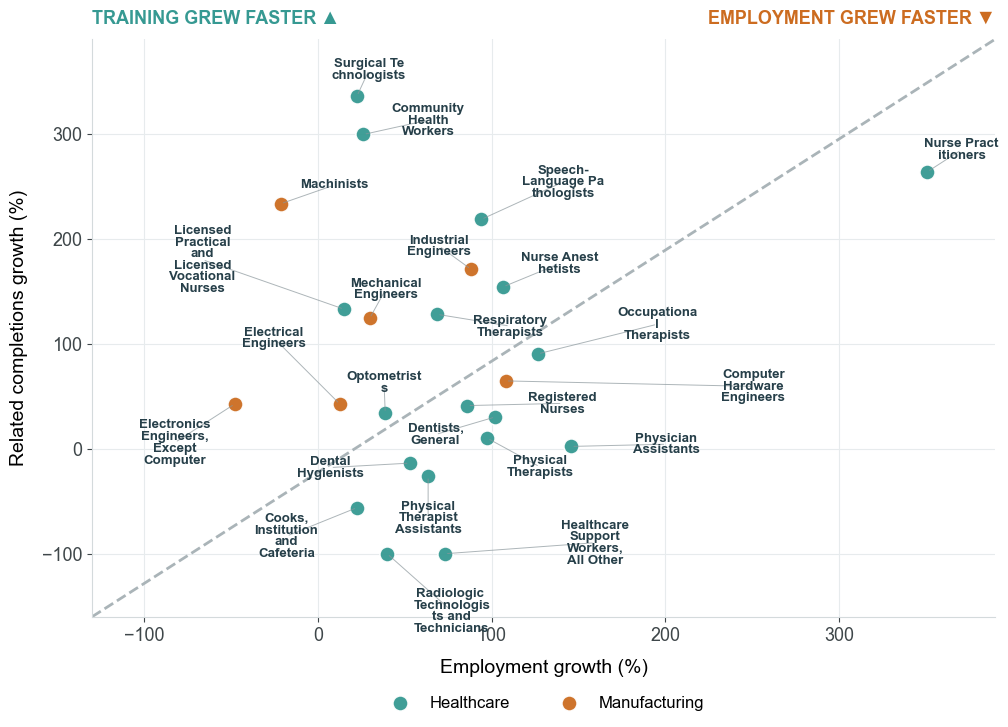

In [77]:
# =====================================================================
# FIGURE 1 (NO AXIS CLIPPING & UNCLUTTERED CENTER)
# =====================================================================

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 12,
    "axes.labelsize": 15,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "axes.edgecolor": "#D4DADC",
    "xtick.color": "#3F474A",
    "ytick.color": "#3F474A",
    "figure.facecolor": "white",
    "axes.facecolor": "white"
})

fig, ax = plt.subplots(figsize=(10.5, 7.5))

# 1. EXPANDED Y-MINIMUM TO FIX BOTTOM CLIPPING
minimum_x = -130
maximum_x = 390

minimum_y = -160  # Dropped from -130 to give Radiologic Technologists full padding
maximum_y = 390

# 45-degree reference line
ax.plot(
    [minimum_x, maximum_x],
    [minimum_y, maximum_y],
    color=GRAY,
    linewidth=2.0,
    linestyle="--",
    zorder=1
)

# Scatter points
for sector, color in [
    ("Healthcare", TEAL),
    ("Manufacturing", ORANGE)
]:
    temp = main[main["sector"] == sector]
    ax.scatter(
        temp["employment_growth_pct_2014_2025"],
        temp["training_growth_pct_2014_2025"],
        s=120,
        color=color,
        edgecolor=WHITE,
        linewidth=1.2,
        alpha=.95,
        label=sector,
        zorder=3
    )

# =====================================================================
# QUADRANT TITLES (SAFELY ABOVE CANVAS)
# =====================================================================
ax.text(
    0.0, 1.02,
    "TRAINING GREW FASTER ▲",
    transform=ax.transAxes,
    fontsize=13,
    fontweight="bold",
    color=TEAL,
    ha="left",
    va="bottom"
)

ax.text(
    1.0, 1.02,
    "EMPLOYMENT GREW FASTER ▼",
    transform=ax.transAxes,
    fontsize=13,
    fontweight="bold",
    color=ORANGE,
    ha="right",
    va="bottom"
)

# =====================================================================
# LABELS (COMPACT FONT & TIGHTER WRAP FOR CENTER UNCLUTTERING)
# =====================================================================
texts = []

for _, row in label_df.iterrows():
    x = row["employment_growth_pct_2014_2025"]
    y = row["training_growth_pct_2014_2025"]
    job_title = str(row["job_title"]).strip()

    txt = ax.text(
        x,
        y,
        wrap_label(job_title, width=11),  # Narrower width stacks text into compact blocks
        fontsize=9.5,                     # Slightly smaller font allows breathing room in center
        fontweight="bold",
        color=NAVY,
        ha="center",
        va="center",
        linespacing=0.95,
        zorder=5
    )
    texts.append(txt)

# Precision positioning
adjust_text(
    texts,
    x=main["employment_growth_pct_2014_2025"].to_numpy(),
    y=main["training_growth_pct_2014_2025"].to_numpy(),
    ax=ax,
    only_move={"text": "xy", "static": "xy"},
    force_text=(1.8, 2.2),           # Pushes text boxes further apart from each other
    force_points=(2.0, 2.5),         # Pushes text away from dots
    force_static=(1.5, 1.8),
    force_pull=(0.0005, 0.0005),     # Minimal pull so labels stay in open whitespace
    expand=(1.35, 1.45),
    ensure_inside_axes=True,         # Keeps text strictly within the frame
    arrowprops=dict(
        arrowstyle="-",
        color="#8A969B",
        linewidth=0.7,
        alpha=.70
    ),
    iter_lim=5000
)

# =====================================================================
# AXES & MARGINS
# =====================================================================
ax.set_xlabel("Employment growth (%)", labelpad=10, fontsize=14)
ax.set_ylabel("Related completions growth (%)", labelpad=10, fontsize=14)

ax.set_xlim(minimum_x, maximum_x)
ax.set_ylim(minimum_y, maximum_y)

# Grid & Spines
ax.grid(color=LIGHT_GRAY, linewidth=0.8)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#D4DADC")
ax.spines["bottom"].set_color("#D4DADC")

# Legend
ax.legend(
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(.5, -0.11),
    ncol=2,
    columnspacing=2.5,
    fontsize=12,
    handletextpad=.8
)

fig.subplots_adjust(left=.10, right=.96, top=.92, bottom=.15)

save_chart(fig, "01_Training_vs_Employment_Growth.png")

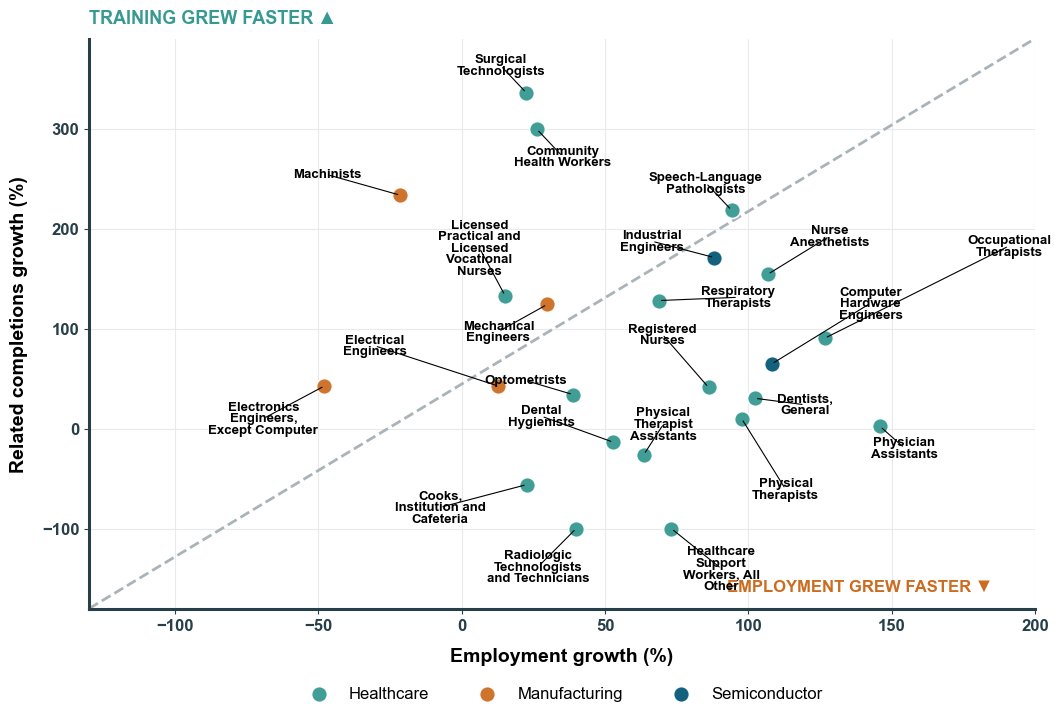

In [86]:
# =====================================================================
# FIGURE 1 (EXCLUDING NURSE PRACTITIONERS FOR MAXIMUM VISUAL SPACE)
# =====================================================================

# Color palette
TEAL = "#369992"
ORANGE = "#CC6C20"
DARK_TURQUOISE = "#075877"  # RGB (7, 88, 119)
BLACK = "#000000"           # Pure Black for text & leader lines
GRAY = "#AAB4B8"
LIGHT_GRAY = "#E7EBED"
WHITE = "#FFFFFF"

TARGET_DARK_TURQUOISE = [
    "Computer Hardware Engineers",
    "Industrial Engineers",
    "Semiconductor Processing Technicians"
]

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 12,
    "axes.labelsize": 15,
    "axes.labelweight": "bold",
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.edgecolor": "#263F49",
    "xtick.color": "#263F49",
    "ytick.color": "#263F49",
    "figure.facecolor": "white",
    "axes.facecolor": "white"
})

# Filter out Nurse Practitioners to widen center scale
main = main[main["job_title"].str.strip() != "Nurse Practitioners"].copy()
label_df = label_df[label_df["job_title"].str.strip() != "Nurse Practitioners"].copy()

fig, ax = plt.subplots(figsize=(11, 7.5))

# Tighter X bounds now that Nurse Practitioners (350%) is removed
minimum_x, maximum_x = -130, 200
minimum_y, maximum_y = -180, 390

# 45-degree reference line
ax.plot(
    [minimum_x, maximum_x],
    [minimum_y, maximum_y],
    color=GRAY,
    linewidth=2.0,
    linestyle="--",
    zorder=1
)

# =====================================================================
# SCATTER POINTS
# =====================================================================

def get_point_color(row):
    title = str(row["job_title"]).strip()
    if title in TARGET_DARK_TURQUOISE:
        return DARK_TURQUOISE
    elif row["sector"] == "Healthcare":
        return TEAL
    else:
        return ORANGE

main["point_color"] = main.apply(get_point_color, axis=1)

for group_name, color in [
    ("Healthcare", TEAL),
    ("Manufacturing", ORANGE),
    ("Semiconductor", DARK_TURQUOISE)
]:
    if group_name == "Semiconductor":
        sub = main[main["job_title"].astype(str).str.strip().isin(TARGET_DARK_TURQUOISE)]
    else:
        sub = main[
            (main["sector"] == group_name) & 
            (~main["job_title"].astype(str).str.strip().isin(TARGET_DARK_TURQUOISE))
        ]
        
    ax.scatter(
        sub["employment_growth_pct_2014_2025"],
        sub["training_growth_pct_2014_2025"],
        s=130,
        color=color,
        edgecolor=WHITE,
        linewidth=1.2,
        alpha=.95,
        label=group_name,
        zorder=3
    )

# =====================================================================
# QUADRANT TITLES
# =====================================================================

# Above top border
ax.text(
    0.0, 1.02,
    "TRAINING GREW FASTER ▲",
    transform=ax.transAxes,
    fontsize=13,
    fontweight="bold",
    color=TEAL,
    ha="left",
    va="bottom"
)

# Anchored directly against bottom X-axis spine at y = -165
ax.text(
    185, -165,
    "EMPLOYMENT GREW FASTER ▼",
    fontsize=12,
    fontweight="bold",
    color=ORANGE,
    ha="right",
    va="bottom",
    zorder=4
)

# =====================================================================
# OCCUPATION LABELS (ALL SOLID BLACK)
# =====================================================================
texts = []

for _, row in label_df.iterrows():
    x = row["employment_growth_pct_2014_2025"]
    y = row["training_growth_pct_2014_2025"]
    job_title = str(row["job_title"]).strip()

    txt = ax.text(
        x,
        y,
        wrap_label(job_title, width=15),
        fontsize=9.5,
        fontweight="bold",
        color=BLACK,                      # SOLID BLACK TEXT
        ha="center",
        va="center",
        linespacing=0.95,
        zorder=5
    )
    texts.append(txt)

# Auto positioning with strong point repulsion
adjust_text(
    texts,
    x=main["employment_growth_pct_2014_2025"].to_numpy(),
    y=main["training_growth_pct_2014_2025"].to_numpy(),
    ax=ax,
    only_move={"text": "xy", "static": "xy"},
    force_text=(2.5, 3.0),             # Strong text-to-text separation
    force_points=(3.5, 4.0),           # Strong point repulsion
    force_static=(2.0, 2.5),
    force_pull=(0.0, 0.0),             # Zero pull-back on top of dots
    expand=(1.4, 1.5),
    ensure_inside_axes=True,           # Strictly keeps text inside X & Y axis limits
    arrowprops=dict(
        arrowstyle="-",
        color=BLACK,                   # SOLID BLACK LEADER LINES
        linewidth=0.8,
        alpha=1.0
    ),
    iter_lim=6000
)

# =====================================================================
# AXES & MARGINS (BOLD SPINES & TICKS)
# =====================================================================
ax.set_xlabel("Employment growth (%)", labelpad=10, fontsize=14, fontweight="bold")
ax.set_ylabel("Related completions growth (%)", labelpad=10, fontsize=14, fontweight="bold")

ax.set_xlim(minimum_x, maximum_x)
ax.set_ylim(minimum_y, maximum_y)

# Grid & Spines
ax.grid(color=LIGHT_GRAY, linewidth=0.8)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Bold Left & Bottom Spines
ax.spines["left"].set_color("#263F49")
ax.spines["left"].set_linewidth(2.2)
ax.spines["bottom"].set_color("#263F49")
ax.spines["bottom"].set_linewidth(2.2)

# Bold Axis Ticks
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight("bold")

# Legend
ax.legend(
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(.5, -0.11),
    ncol=3,
    columnspacing=2.5,
    fontsize=12,
    handletextpad=.8
)

fig.subplots_adjust(left=.10, right=.96, top=.92, bottom=.16)

save_chart(fig, "01_Training_vs_Employment_Growth.png")

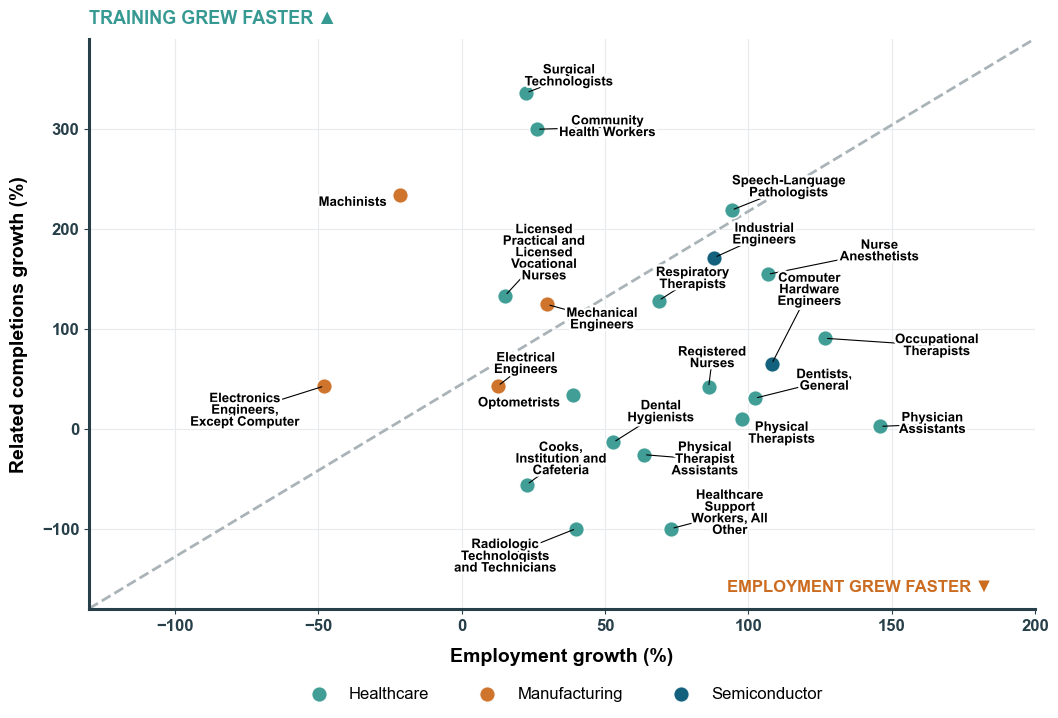

In [88]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
from adjustText import adjust_text

# =====================================================================
# FIGURE 1 (EXCLUDING NURSE PRACTITIONERS FOR MAXIMUM VISUAL SPACE)
# =====================================================================

# Color palette
TEAL = "#369992"
ORANGE = "#CC6C20"
DARK_TURQUOISE = "#075877"  # RGB (7, 88, 119)
BLACK = "#000000"           # Pure Black for text & leader lines
GRAY = "#AAB4B8"
LIGHT_GRAY = "#E7EBED"
WHITE = "#FFFFFF"

TARGET_DARK_TURQUOISE = [
    "Computer Hardware Engineers",
    "Industrial Engineers",
    "Semiconductor Processing Technicians"
]

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 12,
    "axes.labelsize": 15,
    "axes.labelweight": "bold",
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.edgecolor": "#263F49",
    "xtick.color": "#263F49",
    "ytick.color": "#263F49",
    "figure.facecolor": "white",
    "axes.facecolor": "white"
})

# Filter out Nurse Practitioners to widen center scale
main = main[main["job_title"].str.strip() != "Nurse Practitioners"].copy()
label_df = label_df[label_df["job_title"].str.strip() != "Nurse Practitioners"].copy()

fig, ax = plt.subplots(figsize=(11, 7.5))

# Tighter X bounds now that Nurse Practitioners (350%) is removed
minimum_x, maximum_x = -130, 200
minimum_y, maximum_y = -180, 390

# 45-degree reference line
ax.plot(
    [minimum_x, maximum_x],
    [minimum_y, maximum_y],
    color=GRAY,
    linewidth=2.0,
    linestyle="--",
    zorder=1
)

# =====================================================================
# SCATTER POINTS
# =====================================================================

def get_point_color(row):
    title = str(row["job_title"]).strip()
    if title in TARGET_DARK_TURQUOISE:
        return DARK_TURQUOISE
    elif row["sector"] == "Healthcare":
        return TEAL
    else:
        return ORANGE

main["point_color"] = main.apply(get_point_color, axis=1)

for group_name, color in [
    ("Healthcare", TEAL),
    ("Manufacturing", ORANGE),
    ("Semiconductor", DARK_TURQUOISE)
]:
    if group_name == "Semiconductor":
        sub = main[main["job_title"].astype(str).str.strip().isin(TARGET_DARK_TURQUOISE)]
    else:
        sub = main[
            (main["sector"] == group_name) & 
            (~main["job_title"].astype(str).str.strip().isin(TARGET_DARK_TURQUOISE))
        ]
        
    ax.scatter(
        sub["employment_growth_pct_2014_2025"],
        sub["training_growth_pct_2014_2025"],
        s=130,
        color=color,
        edgecolor=WHITE,
        linewidth=1.2,
        alpha=.95,
        label=group_name,
        zorder=3
    )

# =====================================================================
# QUADRANT TITLES
# =====================================================================

# Above top border
ax.text(
    0.0, 1.02,
    "TRAINING GREW FASTER ▲",
    transform=ax.transAxes,
    fontsize=13,
    fontweight="bold",
    color=TEAL,
    ha="left",
    va="bottom"
)

# Anchored directly against bottom X-axis spine at y = -165
ax.text(
    185, -165,
    "EMPLOYMENT GREW FASTER ▼",
    fontsize=12,
    fontweight="bold",
    color=ORANGE,
    ha="right",
    va="bottom",
    zorder=4
)

# =====================================================================
# OCCUPATION LABELS (ORIGINAL FONT SIZE + ZERO OVERLAP FIX)
# =====================================================================
texts = []

for _, row in label_df.iterrows():
    x = row["employment_growth_pct_2014_2025"]
    y = row["training_growth_pct_2014_2025"]
    job_title = str(row["job_title"]).strip()

    txt = ax.text(
        x,
        y,
        wrap_label(job_title, width=15),
        fontsize=9.5,                       # Restored original full text size
        fontweight="bold",
        color=BLACK,
        ha="center",
        va="center",
        linespacing=0.95,
        zorder=5
    )
    # White stroke halo eliminates visual collisions with lines and dots
    txt.set_path_effects([
        path_effects.withStroke(linewidth=3.5, foreground=WHITE)
    ])
    texts.append(txt)

# Controlled text adjustment that preserves spacing and layout
adjust_text(
    texts,
    x=main["employment_growth_pct_2014_2025"].to_numpy(),
    y=main["training_growth_pct_2014_2025"].to_numpy(),
    ax=ax,
    only_move={"text": "xy", "static": "xy"},
    force_text=(1.2, 1.5),                 # Balanced text separation
    force_points=(2.0, 2.5),               # Prevents overlapping dots
    force_static=(1.0, 1.2),
    force_pull=(0.001, 0.001),             # Gentle pull to keep labels near points without collapsing
    expand=(1.15, 1.25),
    ensure_inside_axes=True,
    arrowprops=dict(
        arrowstyle="-",
        color=BLACK,
        linewidth=0.8,
        alpha=1.0,
        zorder=4
    ),
    iter_lim=4000
)

# =====================================================================
# AXES & MARGINS (BOLD SPINES & TICKS)
# =====================================================================
ax.set_xlabel("Employment growth (%)", labelpad=10, fontsize=14, fontweight="bold")
ax.set_ylabel("Related completions growth (%)", labelpad=10, fontsize=14, fontweight="bold")

ax.set_xlim(minimum_x, maximum_x)
ax.set_ylim(minimum_y, maximum_y)

# Grid & Spines
ax.grid(color=LIGHT_GRAY, linewidth=0.8)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Bold Left & Bottom Spines
ax.spines["left"].set_color("#263F49")
ax.spines["left"].set_linewidth(2.2)
ax.spines["bottom"].set_color("#263F49")
ax.spines["bottom"].set_linewidth(2.2)

# Bold Axis Ticks
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight("bold")

# Legend
ax.legend(
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(.5, -0.11),
    ncol=3,
    columnspacing=2.5,
    fontsize=12,
    handletextpad=.8
)

fig.subplots_adjust(left=.10, right=.96, top=.92, bottom=.16)

save_chart(fig, "01_Training_vs_Employment_Growth.png")